In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


In [13]:
data_to_plot = """
SKYWEAVE_GROUP_STATS,timestamp,group_x,g.count,mean_x,var_x,mean_y,var_y,mean_z,var_z,mean_roll,var_roll,mean_pitch,var_pitch,mean_yaw,var_yaw
SKYWEAVE_GROUP_STATS,9.81,-2,5,2.28093,0,-1.96122,0.02,1.29794,0,0,0,0,0,0,0
SKYWEAVE_GROUP_STATS,9.81,0,5,2.48093,0,-1.96122,0.02,1.29794,0,0,0,0,0,0,0
SKYWEAVE_GROUP_STATS,9.81,2,5,2.68093,8.88178e-16,-1.96122,0.02,1.29794,0,0,0,0,0,0,0
SKYWEAVE_GROUP_STATS,9.831,-2,5,2.28247,2.51503e-08,-1.96113,0.0199842,1.28415,7.17987e-07,-0.000766287,0.000574434,-0.188086,1.97541e-06,-0.00164352,8.47998e-07
SKYWEAVE_GROUP_STATS,9.831,0,5,2.48093,3.30401e-09,-1.96129,0.0199902,1.30497,4.62302e-07,-0.000881913,0.000542331,-0.00240471,1.48062e-07,-0.000328082,3.27506e-06
SKYWEAVE_GROUP_STATS,9.831,2,5,2.67941,1.18318e-08,-1.96117,0.019976,1.28414,5.72645e-07,-0.00101091,0.000569054,0.183536,1.96638e-06,0.000855069,1.20844e-06
SKYWEAVE_GROUP_STATS,9.852,-2,5,2.28438,1.61101e-07,-1.96023,0.0199818,1.27453,2.92517e-06,0.00450215,0.00104232,-0.283813,6.83577e-05,-0.00771471,2.2183e-06
SKYWEAVE_GROUP_STATS,9.852,0,5,2.48096,1.32328e-07,-1.96116,0.0199877,1.3048,1.05048e-07,-0.00835442,0.000944217,-0.000273412,6.78832e-05,-0.00303989,1.1653e-05
SKYWEAVE_GROUP_STATS,9.852,2,5,2.6776,2.67769e-08,-1.96157,0.0199777,1.27439,1.83804e-06,-0.0176944,0.00101201,0.278356,3.1173e-05,-0.0022828,1.69123e-06
SKYWEAVE_GROUP_STATS,9.873,-2,5,2.28434,1.38114e-06,-1.95782,0.0199642,1.27303,1.42245e-05,0.0199113,0.000992896,-0.267049,0.000383874,-0.0170524,3.26041e-06
SKYWEAVE_GROUP_STATS,9.873,0,5,2.48118,2.20895e-06,-1.96048,0.0199859,1.30183,2.33299e-07,-0.00920961,0.000892959,0.00105718,0.000384254,-0.0113376,1.02127e-05
SKYWEAVE_GROUP_STATS,9.873,2,5,2.67802,6.85953e-07,-1.96273,0.0199608,1.27227,1.49071e-05,-0.0358891,0.000937601,0.263104,0.000313139,-0.012847,1.58166e-06
SKYWEAVE_GROUP_STATS,9.894,-2,5,2.2823,9.53529e-06,-1.95456,0.0199763,1.27852,9.24151e-06,0.0179829,0.000203096,-0.123119,0.00030242,-0.0248172,3.52015e-07
SKYWEAVE_GROUP_STATS,9.894,0,5,2.48152,1.0663e-05,-1.95934,0.0199857,1.29206,3.08849e-07,-0.00689283,0.000197649,0.00389057,0.000304083,-0.0234224,7.36682e-07
SKYWEAVE_GROUP_STATS,9.894,2,5,2.68066,8.83136e-06,-1.96409,0.0199713,1.27682,1.52398e-05,-0.0313209,0.000199325,0.127313,0.000288526,-0.024612,2.48716e-07
SKYWEAVE_GROUP_STATS,9.915,-2,5,2.28226,2.54672e-05,-1.9507,0.0199155,1.28192,9.99621e-06,0.0138215,0.00157571,-0.0412765,0.000160879,-0.0365242,6.56937e-07
SKYWEAVE_GROUP_STATS,9.915,0,5,2.48189,2.63385e-05,-1.9581,0.0199423,1.2888,6.3046e-06,-0.00503039,0.00147708,0.00963554,0.0001966,-0.0370162,1.91014e-07
SKYWEAVE_GROUP_STATS,9.915,2,5,2.68143,2.46381e-05,-1.96553,0.0199095,1.27942,1.99969e-05,-0.0256911,0.00161595,0.0326002,0.000235412,-0.0366655,3.17527e-07
SKYWEAVE_GROUP_STATS,9.936,-2,5,2.2831,5.04187e-05,-1.94697,0.0199637,1.29521,3.45571e-06,0.00691182,0.00078843,0.14054,8.37372e-05,-0.0498094,3.1704e-06
SKYWEAVE_GROUP_STATS,9.936,0,5,2.48211,4.81126e-05,-1.95687,0.0199285,1.28027,4.16888e-06,-0.00593989,0.00078481,0.0072608,8.27012e-05,-0.0494424,1.14459e-06
SKYWEAVE_GROUP_STATS,9.936,2,5,2.68143,4.98857e-05,-1.9665,0.0199581,1.29146,1.20418e-05,-0.0196519,0.000800723,-0.0922533,9.73407e-05,-0.0482507,1.47598e-06
SKYWEAVE_GROUP_STATS,9.957,-2,5,2.28664,7.36258e-05,-1.94294,0.0198995,1.31366,1.65639e-05,-0.0220474,0.00105171,0.293876,0.000173508,-0.0710779,2.8554e-06
SKYWEAVE_GROUP_STATS,9.957,0,5,2.48261,7.6452e-05,-1.9559,0.0199085,1.2821,2.18985e-06,-0.00179188,0.000962665,0.0101635,0.000174273,-0.0624404,9.40345e-06
SKYWEAVE_GROUP_STATS,9.957,2,5,2.67939,6.90286e-05,-1.96785,0.0199184,1.30939,8.46834e-07,0.0147207,0.00102001,-0.26421,0.000116509,-0.0600743,1.5393e-06
SKYWEAVE_GROUP_STATS,9.978,-2,5,2.28771,0.000115375,-1.93838,0.0198228,1.32164,4.2005e-05,-0.0399119,0.00101491,0.280308,0.000569313,-0.0908838,5.54141e-06
SKYWEAVE_GROUP_STATS,9.978,0,5,2.48345,0.000126554,-1.9551,0.0198593,1.29035,3.291e-06,-0.00408542,0.000908789,0.0116149,0.000568549,-0.080702,9.80903e-06
SKYWEAVE_GROUP_STATS,9.978,2,5,2.68007,0.00011053,-1.97069,0.0198601,1.31721,7.90007e-06,0.0283575,0.000944135,-0.248278,0.000478828,-0.0794057,1.17513e-06
SKYWEAVE_GROUP_STATS,9.999,-2,5,2.2856,0.000201659,-1.93432,0.0197647,1.30639,3.37274e-05,-0.0404685,0.000765155,-0.00161926,0.000344622,-0.100859,2.86835e-07
SKYWEAVE_GROUP_STATS,9.999,0,5,2.48461,0.000201284,-1.9544,0.0197839,1.30797,5.56811e-06,-0.014244,0.000748884,0.0132364,0.000343634,-0.100807,2.04928e-08
SKYWEAVE_GROUP_STATS,9.999,2,5,2.68352,0.000204747,-1.9746,0.0197915,1.30213,5.10814e-06,0.0122301,0.000762921,0.0190259,0.000358087,-0.101594,8.13201e-08
SKYWEAVE_GROUP_STATS,10.02,-2,5,2.28726,0.000291823,-1.93021,0.01971,1.29232,8.20078e-07,-0.00760862,2.05234e-05,-0.105233,4.38358e-05,-0.120765,8.00216e-08
SKYWEAVE_GROUP_STATS,10.02,0,5,2.48544,0.000292769,-1.9543,0.0197015,1.30114,4.84106e-06,-0.0168416,2.32233e-05,0.0133494,4.16513e-05,-0.121441,2.67828e-07
SKYWEAVE_GROUP_STATS,10.02,2,5,2.68338,0.000289157,-1.97864,0.0197044,1.28824,1.19209e-05,-0.0258372,2.56672e-05,0.123735,3.96528e-05,-0.123398,1.73384e-07
SKYWEAVE_GROUP_STATS,10.041,-2,5,2.2885,0.000372907,-1.9256,0.0193263,1.2882,0.00010355,0.0334281,0.0200504,0.00277179,0.00130221,-0.141563,1.22977e-05
SKYWEAVE_GROUP_STATS,10.041,0,5,2.48627,0.000378215,-1.95419,0.0193737,1.28954,7.49957e-05,-0.019344,0.0185157,0.00500136,0.00149517,-0.144024,9.59236e-06
SKYWEAVE_GROUP_STATS,10.041,2,5,2.68395,0.000368862,-1.98311,0.0192461,1.28412,0.000172919,-0.0754452,0.0188663,0.0272105,0.0016502,-0.14457,1.95706e-05
SKYWEAVE_GROUP_STATS,10.062,-2,5,2.28994,0.000443131,-1.92264,0.0190675,1.28716,0.000157463,0.0368427,0.035405,0.0157131,0.0011805,-0.154639,1.95442e-05
SKYWEAVE_GROUP_STATS,10.062,0,5,2.48728,0.000449384,-1.95413,0.0190968,1.28679,0.000126501,-0.0149041,0.033178,0.0136228,0.001567,-0.158736,1.11112e-05
SKYWEAVE_GROUP_STATS,10.062,2,5,2.68446,0.000444104,-1.98622,0.0189674,1.28328,0.000235433,-0.0768453,0.0332332,0.0617318,0.00213282,-0.165138,0.000125061
SKYWEAVE_GROUP_STATS,10.083,-2,5,2.29118,0.000492663,-1.9214,0.0189163,1.28515,0.000161636,0.00901756,0.0437263,0.0184984,0.000192852,-0.16044,1.15645e-05
SKYWEAVE_GROUP_STATS,10.083,0,5,2.48844,0.00050074,-1.95406,0.0189447,1.28434,0.000153951,-0.0137181,0.0410401,0.0174798,0.000384011,-0.165272,7.44039e-06
SKYWEAVE_GROUP_STATS,10.083,2,5,2.6856,0.000501724,-1.98736,0.0188752,1.28166,0.000194386,-0.0474427,0.0410295,0.0496892,0.000716821,-0.170197,8.77911e-05
SKYWEAVE_GROUP_STATS,10.104,-2,5,2.29265,0.000555226,-1.92042,0.0193194,1.28346,3.5367e-05,-0.000811963,0.00928925,0.0151064,9.71806e-05,-0.168361,1.26757e-06
SKYWEAVE_GROUP_STATS,10.104,0,5,2.48978,0.000556267,-1.95407,0.0193121,1.28212,3.94393e-05,-0.0154949,0.00913368,0.0105656,0.000121957,-0.169393,4.04634e-07
SKYWEAVE_GROUP_STATS,10.104,2,5,2.6869,0.00055636,-1.98783,0.0192935,1.28045,5.50319e-05,-0.0320847,0.00911814,0.022797,0.000150028,-0.170235,3.76836e-06
SKYWEAVE_GROUP_STATS,10.125,-2,5,2.29432,0.000592901,-1.91933,0.0193142,1.28103,2.00704e-05,-0.00482019,0.00404831,-0.0119718,6.74869e-06,-0.173363,6.00717e-07
SKYWEAVE_GROUP_STATS,10.125,0,5,2.49123,0.000594259,-1.95389,0.0193411,1.28437,2.10638e-05,-0.00936992,0.00380037,0.00845139,1.75547e-05,-0.174238,2.06178e-07
SKYWEAVE_GROUP_STATS,10.125,2,5,2.68807,0.000591042,-1.98858,0.0193109,1.2787,2.76351e-05,-0.0168629,0.00402005,0.0128217,4.14993e-05,-0.17399,3.57197e-07
SKYWEAVE_GROUP_STATS,10.146,-2,5,2.29621,0.000630209,-1.91809,0.0193592,1.28991,9.39499e-06,-0.0122296,0.0011913,0.108763,3.37657e-07,-0.179867,2.54705e-06
SKYWEAVE_GROUP_STATS,10.146,0,5,2.49262,0.000629757,-1.9537,0.0193319,1.27932,9.37702e-06,-0.0115025,0.00124434,0.00191852,6.20281e-07,-0.178741,1.56372e-07
SKYWEAVE_GROUP_STATS,10.146,2,5,2.68921,0.000631651,-1.98906,0.0193664,1.28788,8.30695e-06,-0.0098141,0.00122172,-0.0821126,2.96043e-06,-0.17773,2.10514e-06
SKYWEAVE_GROUP_STATS,10.167,-2,5,2.29753,0.000646621,-1.91681,0.0190735,1.29145,9.27606e-05,-0.0230958,0.0218373,-0.0154706,3.45801e-05,-0.181236,5.43689e-07
SKYWEAVE_GROUP_STATS,10.167,0,5,2.49418,0.000651277,-1.95323,0.019022,1.29418,8.62328e-05,-0.0129703,0.0219669,0.0168444,7.61063e-05,-0.184653,3.88791e-06
SKYWEAVE_GROUP_STATS,10.167,2,5,2.69078,0.000659766,-1.99008,0.0190555,1.29044,8.29881e-05,0.000331076,0.0219199,-0.000457202,0.000101335,-0.186106,8.18566e-06
SKYWEAVE_GROUP_STATS,10.188,-2,5,2.29949,0.000661058,-1.91515,0.01886,1.30799,0.000160642,-0.0436827,0.0334849,-0.00595091,0.000420584,-0.186486,7.28873e-06
SKYWEAVE_GROUP_STATS,10.188,0,5,2.49585,0.000671337,-1.95285,0.0188975,1.30701,0.000119131,-0.0126733,0.0317301,-0.000824261,0.000590384,-0.190202,4.74898e-06
SKYWEAVE_GROUP_STATS,10.188,2,5,2.69213,0.000675754,-1.991,0.0188678,1.30715,0.000128295,0.0257937,0.0316327,-0.0315978,0.000863131,-0.193548,4.65032e-05
SKYWEAVE_GROUP_STATS,10.209,-2,5,2.30146,0.000693109,-1.91418,0.0190577,1.31382,0.000126024,-0.0662267,0.0125283,0.0191641,0.00131942,-0.192615,6.71253e-06
SKYWEAVE_GROUP_STATS,10.209,0,5,2.49751,0.000705397,-1.95267,0.0191306,1.3101,4.68844e-05,-0.013609,0.0120015,0.00439191,0.00145214,-0.193514,3.30955e-06
SKYWEAVE_GROUP_STATS,10.209,2,5,2.69355,0.00069833,-1.99127,0.0190769,1.31326,8.4059e-05,0.0417459,0.0121363,-0.0461013,0.00157488,-0.195159,1.9419e-05
SKYWEAVE_GROUP_STATS,10.23,-2,5,2.30306,0.00073892,-1.91398,0.0191863,1.30964,8.05189e-05,-0.0580653,0.000495871,0.00167533,0.00139501,-0.193154,3.22253e-06
SKYWEAVE_GROUP_STATS,10.23,0,5,2.4992,0.000744143,-1.95241,0.0192423,1.30878,3.69259e-06,-0.00553606,0.000507868,-0.00122014,0.00136106,-0.193391,6.39987e-07
SKYWEAVE_GROUP_STATS,10.23,2,5,2.6953,0.000743183,-1.99089,0.0192298,1.30916,3.71619e-05,0.0473922,0.000502812,-0.0187675,0.00142936,-0.194591,2.48947e-07
SKYWEAVE_GROUP_STATS,10.251,-2,5,2.30476,0.000745335,-1.91281,0.0188705,1.29776,0.00010636,-0.0100397,0.02913,0.016237,6.35892e-07,-0.194793,8.60265e-07
SKYWEAVE_GROUP_STATS,10.251,0,5,2.50091,0.000754014,-1.95196,0.0188611,1.29651,0.000104011,-0.0115645,0.0283417,-0.00169558,1.03927e-05,-0.198037,4.54598e-06
SKYWEAVE_GROUP_STATS,10.251,2,5,2.69701,0.000760297,-1.9915,0.0188638,1.29742,0.000106149,-0.0179107,0.0281037,-0.00629661,3.17839e-05,-0.199945,3.09586e-06
SKYWEAVE_GROUP_STATS,10.272,-2,5,2.30715,0.000714196,-1.91105,0.018616,1.28158,0.000245223,0.064477,0.0449976,-0.0024584,0.00205928,-0.199819,3.37614e-05
SKYWEAVE_GROUP_STATS,10.272,0,5,2.50268,0.000735281,-1.95166,0.0187062,1.2845,0.000152237,-0.00434038,0.0412202,-0.00149669,0.00279368,-0.205231,2.1955e-05
SKYWEAVE_GROUP_STATS,10.272,2,5,2.69798,0.000725177,-1.99308,0.0185281,1.28157,0.000297581,-0.0869287,0.0415719,0.0632258,0.0037382,-0.213268,0.000209151
SKYWEAVE_GROUP_STATS,10.293,-2,5,2.30896,0.000672868,-1.91196,0.0188282,1.27593,0.000236807,0.0839151,0.0281481,-0.0202336,0.0034088,-0.195617,3.22399e-05
SKYWEAVE_GROUP_STATS,10.293,0,5,2.50456,0.000697772,-1.95139,0.0189414,1.28058,9.74616e-05,-0.00230632,0.0260624,-0.00676914,0.00402408,-0.198633,1.92389e-05
SKYWEAVE_GROUP_STATS,10.293,2,5,2.69995,0.000678598,-1.9914,0.0187434,1.27633,0.000283922,-0.0974485,0.0262681,0.0753974,0.00467963,-0.206071,0.000171585
SKYWEAVE_GROUP_STATS,10.314,-2,5,2.30997,0.000601428,-1.91503,0.0191662,1.27318,0.000113823,0.0589174,0.0125007,-0.0158156,0.00170014,-0.179632,7.57997e-06
SKYWEAVE_GROUP_STATS,10.314,0,5,2.50647,0.000612834,-1.95101,0.0192187,1.2767,4.55868e-05,-0.000872686,0.0119577,-0.0066843,0.00187831,-0.180967,4.16002e-06
SKYWEAVE_GROUP_STATS,10.314,2,5,2.70292,0.000605685,-1.98723,0.0191288,1.27402,0.000128272,-0.0640152,0.0119398,0.0484559,0.00204362,-0.183898,3.26993e-05
SKYWEAVE_GROUP_STATS,10.335,-2,5,2.31109,0.000504259,-1.9183,0.0193867,1.27239,3.90979e-05,0.0315123,0.00602971,-0.0147662,0.000340075,-0.161329,1.22291e-06
SKYWEAVE_GROUP_STATS,10.335,0,5,2.50838,0.000508632,-1.95055,0.0194094,1.27596,2.30576e-05,0.00461852,0.00582831,-0.00681851,0.000388232,-0.162135,4.92515e-07
SKYWEAVE_GROUP_STATS,10.335,2,5,2.70569,0.000506228,-1.98286,0.019379,1.27367,3.8615e-05,-0.0239277,0.00586307,0.0208761,0.000423109,-0.16225,1.89095e-06
SKYWEAVE_GROUP_STATS,10.356,-2,5,2.31235,0.00040957,-1.92156,0.0195635,1.27341,1.03298e-05,0.0102711,0.00324712,-0.0173266,4.23627e-06,-0.143395,3.14104e-07
SKYWEAVE_GROUP_STATS,10.356,0,5,2.51024,0.000410879,-1.95019,0.0195494,1.27817,9.5717e-06,0.00745876,0.00320541,-0.00417591,3.3122e-06,-0.143671,4.44134e-08
SKYWEAVE_GROUP_STATS,10.356,2,5,2.70813,0.000411552,-1.97885,0.0195641,1.27516,9.49456e-06,0.0051889,0.00323216,0.00277254,2.08739e-06,-0.144314,6.95601e-07
SKYWEAVE_GROUP_STATS,10.377,-2,5,2.31365,0.000293595,-1.92452,0.0191265,1.28363,0.000167557,-0.0218555,0.043452,-0.0159668,0.000305577,-0.124009,9.89607e-06
SKYWEAVE_GROUP_STATS,10.377,0,5,2.51198,0.000300031,-1.94998,0.0191498,1.28442,0.000148894,0.00523548,0.040917,-0.0118755,0.00048644,-0.128619,6.80462e-06
SKYWEAVE_GROUP_STATS,10.377,2,5,2.71022,0.000302816,-1.97608,0.0190994,1.28569,0.000182096,0.0422315,0.0407681,-0.044701,0.00084029,-0.133765,9.08159e-05
SKYWEAVE_GROUP_STATS,10.398,-2,5,2.3151,0.00020534,-1.92811,0.0193433,1.29141,0.0001579,-0.0479656,0.0309982,-0.00458751,0.0013891,-0.106692,1.67029e-05
SKYWEAVE_GROUP_STATS,10.398,0,5,2.5137,0.000210546,-1.95002,0.0193933,1.29032,0.000108895,0.00738037,0.0291868,-0.00926427,0.0017135,-0.110054,1.00927e-05
SKYWEAVE_GROUP_STATS,10.398,2,5,2.7122,0.000207432,-1.97244,0.0192679,1.29361,0.0002071,0.0707744,0.0294344,-0.0609281,0.00217574,-0.115683,0.000106084
SKYWEAVE_GROUP_STATS,10.419,-2,5,2.31639,0.000143696,-1.93273,0.0198303,1.29606,4.08682e-05,-0.0418139,0.000734384,0.0694434,0.00161941,-0.0867375,1.92447e-06
SKYWEAVE_GROUP_STATS,10.419,0,5,2.51525,0.000151752,-1.95002,0.0198257,1.28804,6.16943e-06,0.0141241,0.00073967,-0.00996122,0.00148837,-0.0866621,8.16755e-07
SKYWEAVE_GROUP_STATS,10.419,2,5,2.71402,0.000142082,-1.9675,0.0197927,1.29804,9.36408e-05,0.0695922,0.000750235,-0.078843,0.00156546,-0.0891688,4.47222e-07
SKYWEAVE_GROUP_STATS,10.44,-2,5,2.31731,9.40129e-05,-1.93649,0.0198357,1.28896,8.221e-05,0.0645555,1.17175e-05,0.0199099,0.00125817,-0.0672848,2.20109e-06
SKYWEAVE_GROUP_STATS,10.44,0,5,2.51672,9.2636e-05,-1.94999,0.0199002,1.28647,4.05791e-06,0.0145334,1.14111e-05,-0.00414891,0.00123446,-0.0680526,1.06222e-07
SKYWEAVE_GROUP_STATS,10.44,2,5,2.71608,9.59877e-05,-1.96358,0.019894,1.29109,2.50851e-05,-0.0351697,1.07823e-05,-0.0313345,0.0012308,-0.0681601,1.68703e-07
SKYWEAVE_GROUP_STATS,10.461,-2,5,2.32133,3.41286e-05,-1.9384,0.0197244,1.27148,0.000201064,0.0994402,0.00108748,-0.258969,0.00351031,-0.071341,7.49736e-05
SKYWEAVE_GROUP_STATS,10.461,0,5,2.51795,5.32286e-05,-1.95041,0.0199269,1.29819,8.85869e-06,0.0123584,0.000764956,-0.00188497,0.00349157,-0.0540494,1.51408e-05
SKYWEAVE_GROUP_STATS,10.461,2,5,2.71521,3.26272e-05,-1.96114,0.0198492,1.27383,9.086e-05,-0.0718921,0.00103297,0.208812,0.0034149,-0.0561945,1.90607e-05
SKYWEAVE_GROUP_STATS,10.482,-2,5,2.32219,3.34551e-05,-1.9403,0.0198667,1.26882,8.92251e-05,0.0622772,0.000522462,-0.222394,0.00118999,-0.0572615,9.13089e-06
SKYWEAVE_GROUP_STATS,10.482,0,5,2.51965,4.19239e-05,-1.95049,0.0199438,1.2931,7.06149e-06,0.0118351,0.00048746,-0.00340104,0.00118341,-0.0466533,5.32167e-06
SKYWEAVE_GROUP_STATS,10.482,2,5,2.71749,3.16441e-05,-1.9595,0.0199444,1.27052,1.74276e-05,-0.0364903,0.000506898,0.20082,0.00110763,-0.0460722,7.844e-07
SKYWEAVE_GROUP_STATS,10.503,-2,5,2.32612,5.46007e-05,-1.9403,0.0199274,1.25901,2.35577e-06,0.00213729,0.00128006,-0.312684,5.71624e-05,-0.0572282,2.46071e-06
SKYWEAVE_GROUP_STATS,10.503,0,5,2.52168,4.63072e-05,-1.95057,0.0199342,1.29257,7.43256e-06,0.00997901,0.00113444,-0.00269435,4.87477e-05,-0.0485401,1.72084e-05
SKYWEAVE_GROUP_STATS,10.503,2,5,2.71753,4.79821e-05,-1.95897,0.0199041,1.25962,1.86625e-05,0.0234797,0.00125483,0.302259,9.0969e-05,-0.038538,3.66726e-06
SKYWEAVE_GROUP_STATS,10.524,-2,5,2.32483,6.24362e-05,-1.93871,0.0199334,1.26794,7.79217e-07,0.00298531,0.000164288,-0.108529,9.10121e-05,-0.0566297,3.22278e-08
SKYWEAVE_GROUP_STATS,10.524,0,5,2.52392,5.96257e-05,-1.94983,0.0199322,1.28077,7.27656e-06,0.0162041,0.000160292,0.00160846,9.09266e-05,-0.0545567,5.72751e-07
SKYWEAVE_GROUP_STATS,10.524,2,5,2.723,6.12869e-05,-1.96033,0.0199113,1.267,2.12523e-05,0.0301092,0.000163061,0.111711,9.48706e-05,-0.0515765,3.71604e-07
SKYWEAVE_GROUP_STATS,10.545,-2,5,2.32664,7.46502e-05,-1.93701,0.0198579,1.27319,1.0355e-05,0.0102669,0.00196386,-0.0113457,5.3143e-05,-0.060994,1.43921e-07
SKYWEAVE_GROUP_STATS,10.545,0,5,2.52613,7.41529e-05,-1.94927,0.0198834,1.27807,1.511e-05,0.0196415,0.00183309,0.0095616,3.73495e-05,-0.0605447,1.29438e-07
SKYWEAVE_GROUP_STATS,10.545,2,5,2.72556,7.43473e-05,-1.96129,0.0198547,1.2708,2.22456e-05,0.0268663,0.00195283,0.0167265,1.83547e-05,-0.0607195,4.09972e-07
SKYWEAVE_GROUP_STATS,10.566,-2,5,2.32881,8.8839e-05,-1.93537,0.0198671,1.27941,1.51598e-05,0.0090634,0.00331637,0.00378323,3.04281e-05,-0.0668789,2.85154e-07
SKYWEAVE_GROUP_STATS,10.566,0,5,2.52834,8.94102e-05,-1.94876,0.0198619,1.27682,1.96969e-05,0.0168828,0.00329555,0.0168252,3.05459e-05,-0.0670668,1.53718e-07
SKYWEAVE_GROUP_STATS,10.566,2,5,2.72788,8.96817e-05,-1.96222,0.0198496,1.27562,2.69439e-05,0.0247928,0.00330787,-0.00595983,3.24991e-05,-0.0676204,6.43297e-07
SKYWEAVE_GROUP_STATS,10.587,-2,5,2.33186,0.00010578,-1.93405,0.0198865,1.29686,1.90388e-06,0.00203548,0.000870798,0.144398,7.37257e-05,-0.0718538,1.05124e-06
SKYWEAVE_GROUP_STATS,10.587,0,5,2.53056,0.000108287,-1.94851,0.0198732,1.2815,8.16185e-06,0.0142766,0.000863508,0.0162959,8.10307e-05,-0.0736937,2.62776e-07
SKYWEAVE_GROUP_STATS,10.587,2,5,2.72954,0.000106518,-1.96341,0.0198808,1.29137,2.18295e-05,0.0277886,0.000882068,-0.111513,0.000103608,-0.0764741,1.4111e-06
SKYWEAVE_GROUP_STATS,10.608,-2,5,2.33872,0.000138168,-1.93254,0.0198379,1.31698,1.52369e-06,0.0167241,0.0015983,0.349623,6.06949e-05,-0.082874,4.54313e-06
SKYWEAVE_GROUP_STATS,10.608,0,5,2.53279,0.000135885,-1.94846,0.0198422,1.27839,6.43859e-06,0.0280711,0.0013815,0.0173388,5.95336e-05,-0.082984,2.07359e-05
SKYWEAVE_GROUP_STATS,10.608,2,5,2.72815,0.000127844,-1.96506,0.0198277,1.3103,1.33766e-05,0.0366748,0.0015044,-0.305872,1.61753e-05,-0.0875699,2.86224e-06
SKYWEAVE_GROUP_STATS,10.629,-2,5,2.33683,0.000184504,-1.9294,0.0198169,1.30009,2.7508e-07,0.00373534,6.68253e-05,0.0692539,0.000120094,-0.0959101,4.81103e-08
SKYWEAVE_GROUP_STATS,10.629,0,5,2.53563,0.000187173,-1.94858,0.0198041,1.29005,6.55869e-06,0.0191659,6.66061e-05,0.0167818,0.00011831,-0.0965917,3.62639e-08
SKYWEAVE_GROUP_STATS,10.629,2,5,2.73464,0.000186284,-1.968,0.0197951,1.29267,2.22283e-05,0.0344674,6.66505e-05,-0.0353332,0.000116972,-0.0978967,1.9119e-08
SKYWEAVE_GROUP_STATS,10.65,-2,5,2.33973,0.000249216,-1.92659,0.0197391,1.28376,1.26307e-06,0.00224122,0.00031555,-0.0736625,0.000107919,-0.112287,2.34252e-07
SKYWEAVE_GROUP_STATS,10.65,0,5,2.53828,0.000246567,-1.94882,0.0197423,1.28935,7.40274e-06,0.0169512,0.000301721,0.01929,0.000112393,-0.110783,1.00265e-07
SKYWEAVE_GROUP_STATS,10.65,2,5,2.73652,0.000249964,-1.97062,0.0197115,1.27578,2.22587e-05,0.0318475,0.000315279,0.11154,0.000103168,-0.108115,9.04706e-07
SKYWEAVE_GROUP_STATS,10.671,-2,5,2.34505,0.00032812,-1.92378,0.0196591,1.26525,2.33685e-06,0.00367816,0.000849686,-0.246618,3.87279e-05,-0.1324,1.31431e-06
SKYWEAVE_GROUP_STATS,10.671,0,5,2.54102,0.000313982,-1.9491,0.0196721,1.28925,6.61925e-06,0.0108505,0.000774126,0.0199549,3.6203e-05,-0.125503,8.8888e-06
SKYWEAVE_GROUP_STATS,10.671,2,5,2.73602,0.000316868,-1.97284,0.0196443,1.25681,1.48185e-05,0.0215229,0.000837816,0.282412,5.02606e-05,-0.117622,2.11901e-06
SKYWEAVE_GROUP_STATS,10.692,-2,5,2.34833,0.000400207,-1.91974,0.0195536,1.25855,3.19503e-05,0.0339422,0.00088817,-0.236319,0.000267393,-0.153117,3.01118e-06
SKYWEAVE_GROUP_STATS,10.692,0,5,2.54385,0.000406761,-1.94886,0.0195782,1.28191,5.84411e-06,0.00915188,0.000818789,0.0227516,0.000266821,-0.143435,8.4569e-06
SKYWEAVE_GROUP_STATS,10.692,2,5,2.73834,0.000382409,-1.97642,0.0195982,1.24928,4.89212e-07,-0.0120797,0.000860774,0.276743,0.000208885,-0.139832,9.74719e-07
SKYWEAVE_GROUP_STATS,10.713,-2,5,2.35254,0.00052752,-1.9145,0.0193936,1.25356,5.85476e-05,0.048146,0.000986907,-0.243709,0.000771972,-0.178579,7.75299e-06
SKYWEAVE_GROUP_STATS,10.713,0,5,2.54708,0.000548268,-1.94834,0.0194371,1.27749,4.74721e-06,0.00667573,0.000888764,0.0259567,0.000777047,-0.167045,1.05037e-05
SKYWEAVE_GROUP_STATS,10.713,2,5,2.74044,0.000499635,-1.9806,0.0194669,1.24311,1.06669e-05,-0.0317662,0.00093353,0.285808,0.000684924,-0.165663,1.3318e-06
SKYWEAVE_GROUP_STATS,10.734,-2,5,2.35502,0.000745233,-1.90823,0.0192157,1.25861,3.09875e-05,0.0357276,0.000267212,-0.11031,0.000378887,-0.199265,1.2173e-06
SKYWEAVE_GROUP_STATS,10.734,0,5,2.55057,0.000752646,-1.94733,0.0192417,1.26862,2.96195e-06,0.00768725,0.00025723,0.0302381,0.000383792,-0.195372,1.30021e-06
SKYWEAVE_GROUP_STATS,10.734,2,5,2.74532,0.000727151,-1.98571,0.0192583,1.24649,5.27338e-06,-0.0197228,0.000265637,0.161915,0.000368857,-0.194642,2.74953e-07
SKYWEAVE_GROUP_STATS,10.755,-2,5,2.35957,0.000993315,-1.90162,0.0189679,1.2632,1.44908e-05,0.0250001,0.000657786,-0.0386268,0.000137222,-0.226188,6.69982e-07
SKYWEAVE_GROUP_STATS,10.755,0,5,2.55435,0.000995329,-1.94637,0.0189913,1.2657,3.26274e-06,0.00799971,0.000636235,0.0360374,0.000149717,-0.225076,1.67353e-07
SKYWEAVE_GROUP_STATS,10.755,2,5,2.7486,0.000980505,-1.99078,0.0189902,1.24955,4.10003e-06,-0.00963108,0.000680853,0.0847601,0.00016396,-0.224671,2.51681e-07
SKYWEAVE_GROUP_STATS,10.776,-2,5,2.3654,0.00127543,-1.8954,0.0187243,1.27684,8.89367e-06,0.0175992,0.00121373,0.158867,5.59705e-05,-0.252923,3.17197e-06
SKYWEAVE_GROUP_STATS,10.776,0,5,2.55792,0.00126216,-1.94535,0.0187037,1.25708,5.24243e-06,0.00719529,0.00120275,0.0359081,4.88901e-05,-0.254411,5.77954e-07
SKYWEAVE_GROUP_STATS,10.776,2,5,2.75133,0.00126894,-1.99558,0.018742,1.26144,5.32178e-06,-0.00271942,0.0011416,-0.0716782,4.64469e-05,-0.254283,3.41783e-06
SKYWEAVE_GROUP_STATS,10.797,-2,5,2.3746,0.00155118,-1.88988,0.0184362,1.29645,5.94891e-06,-0.01033,0.00102759,0.328271,0.000157971,-0.289763,2.83609e-06
SKYWEAVE_GROUP_STATS,10.797,0,5,2.5619,0.00156587,-1.94498,0.0184252,1.2584,4.81849e-08,0.0088375,0.000933696,0.0411986,0.000162761,-0.284138,1.05758e-05
SKYWEAVE_GROUP_STATS,10.797,2,5,2.7518,0.00153648,-2.00036,0.018446,1.28003,5.47306e-06,0.0250427,0.000986207,-0.237392,0.0001052,-0.284551,1.50842e-06
SKYWEAVE_GROUP_STATS,10.818,-2,5,2.38108,0.00190006,-1.88317,0.0180593,1.30516,2.69895e-05,-0.0313036,0.000862131,0.307238,0.000572753,-0.326779,4.58276e-06
SKYWEAVE_GROUP_STATS,10.818,0,5,2.56654,0.00195532,-1.9451,0.018039,1.26824,3.71544e-07,0.0044762,0.000770092,0.043286,0.000580337,-0.319047,9.42184e-06
SKYWEAVE_GROUP_STATS,10.818,2,5,2.75467,0.00190336,-2.00719,0.0180615,1.28808,1.73079e-05,0.0375022,0.000794207,-0.210089,0.0004874,-0.320179,9.47501e-07
SKYWEAVE_GROUP_STATS,10.839,-2,5,2.38442,0.00240255,-1.87599,0.0175685,1.29255,2.73899e-05,-0.0357562,0.000870814,0.0393119,0.000424056,-0.355945,2.68654e-07
SKYWEAVE_GROUP_STATS,10.839,0,5,2.57183,0.00241735,-1.94562,0.0175694,1.28631,3.11672e-06,-0.00667735,0.000853211,0.0460441,0.000422979,-0.355773,3.06612e-08
SKYWEAVE_GROUP_STATS,10.839,2,5,2.75901,0.00243986,-2.01522,0.0175473,1.2751,1.29173e-05,0.0225677,0.000863176,0.0462355,0.000435317,-0.356378,1.87292e-07
SKYWEAVE_GROUP_STATS,10.86,-2,5,2.3915,0.00292276,-1.86985,0.0170813,1.28099,5.24139e-07,-0.00225926,0.000141528,-0.0583946,1.92141e-05,-0.392225,9.91671e-08
SKYWEAVE_GROUP_STATS,10.86,0,5,2.5762,0.00292126,-1.94627,0.0170735,1.28168,2.27994e-06,-0.00832038,0.000152416,0.0464016,1.73427e-05,-0.392591,2.08033e-07
SKYWEAVE_GROUP_STATS,10.86,2,5,2.76004,0.00291281,-2.0225,0.0170879,1.26337,5.23696e-06,-0.0140545,0.000160467,0.152588,1.63044e-05,-0.393561,5.24212e-07
SKYWEAVE_GROUP_STATS,10.881,-2,5,2.39899,0.00336567,-1.86342,0.0162804,1.27801,0.00011875,0.033134,0.0249632,0.0443758,0.00110885,-0.428614,1.13358e-05
SKYWEAVE_GROUP_STATS,10.881,0,5,2.58049,0.00335917,-1.94685,0.0163309,1.271,8.86445e-05,-0.0154278,0.0234247,0.0394191,0.00126854,-0.431174,9.98767e-06
SKYWEAVE_GROUP_STATS,10.881,2,5,2.76171,0.00330777,-2.03054,0.0162791,1.26014,0.000165177,-0.0672136,0.0236153,0.0565153,0.00139025,-0.432631,2.05254e-05
SKYWEAVE_GROUP_STATS,10.902,-2,5,2.40643,0.00381338,-1.85869,0.0157328,1.27445,0.000145618,0.0347394,0.0328587,0.050063,0.00102829,-0.459271,1.49139e-05
SKYWEAVE_GROUP_STATS,10.902,0,5,2.58517,0.00380645,-1.94781,0.0157694,1.26674,0.000116574,-0.0134754,0.0308734,0.04498,0.00134297,-0.463004,8.40407e-06
SKYWEAVE_GROUP_STATS,10.902,2,5,2.76355,0.00375226,-2.03736,0.0157153,1.25655,0.000205708,-0.0704105,0.0308604,0.0868471,0.00178051,-0.468192,8.81153e-05
SKYWEAVE_GROUP_STATS,10.923,-2,5,2.41355,0.00415714,-1.85552,0.0151944,1.2713,0.000177824,0.0137185,0.047759,0.0499002,0.000259378,-0.482241,1.01615e-05
SKYWEAVE_GROUP_STATS,10.923,0,5,2.59018,0.00417489,-1.94889,0.0152237,1.26348,0.000164827,-0.0127728,0.0444175,0.0467884,0.00050457,-0.487534,8.05864e-06
SKYWEAVE_GROUP_STATS,10.923,2,5,2.76638,0.00414614,-2.04288,0.01518,1.25353,0.00021043,-0.050906,0.0443857,0.0802246,0.000893919,-0.492725,8.4767e-05
SKYWEAVE_GROUP_STATS,10.944,-2,5,2.42097,0.00469412,-1.85298,0.0151975,1.27084,3.1844e-05,0.00720914,0.00799047,0.048197,0.000239412,-0.507779,1.38975e-06
SKYWEAVE_GROUP_STATS,10.944,0,5,2.59549,0.00468106,-1.95025,0.0152037,1.26256,3.46916e-05,-0.015391,0.00784437,0.0432908,0.000274546,-0.508707,4.44291e-07
SKYWEAVE_GROUP_STATS,10.944,2,5,2.76993,0.00465913,-2.04761,0.0151966,1.25335,6.07889e-05,-0.0396326,0.00783525,0.0586037,0.000308224,-0.509569,3.7311e-06
SKYWEAVE_GROUP_STATS,10.965,-2,5,2.42876,0.0050745,-1.85056,0.0148473,1.26961,1.33368e-05,0.000875512,0.00282851,0.0108502,8.85713e-05,-0.529413,1.21419e-06
SKYWEAVE_GROUP_STATS,10.965,0,5,2.60125,0.00507703,-1.95159,0.0148673,1.26613,1.67913e-05,-0.0134237,0.00265776,0.0416338,0.000116311,-0.530288,2.31826e-07
SKYWEAVE_GROUP_STATS,10.965,2,5,2.77329,0.00504479,-2.05257,0.0148578,1.25255,3.26398e-05,-0.029735,0.00282987,0.0610172,0.000153759,-0.530488,5.26701e-07
SKYWEAVE_GROUP_STATS,10.986,-2,5,2.43739,0.00548952,-1.84861,0.0145243,1.28092,2.58274e-06,-0.00640865,0.000460569,0.160341,3.51019e-05,-0.55236,1.55698e-06
SKYWEAVE_GROUP_STATS,10.986,0,5,2.60671,0.00546196,-1.95283,0.0145185,1.26049,6.07367e-06,-0.0146759,0.000465379,0.0384457,3.76971e-05,-0.551094,9.31504e-07
SKYWEAVE_GROUP_STATS,10.986,2,5,2.77714,0.00547381,-2.05723,0.0145327,1.26402,1.30266e-05,-0.0238579,0.000470154,-0.0585402,4.34073e-05,-0.54888,1.15135e-06
SKYWEAVE_GROUP_STATS,11.007,-2,5,2.44525,0.00582007,-1.84633,0.0141018,1.28514,3.25376e-05,-0.0302556,0.00557309,0.0568408,8.87213e-05,-0.573195,2.3932e-06
SKYWEAVE_GROUP_STATS,11.007,0,5,2.61329,0.00582957,-1.95458,0.0140882,1.27968,2.15097e-05,-0.0169877,0.00551148,0.0579048,8.3478e-05,-0.572615,6.16723e-07
SKYWEAVE_GROUP_STATS,11.007,2,5,2.78109,0.00584993,-2.06289,0.0140846,1.26905,1.82533e-05,-0.00420155,0.00563852,0.0189994,8.71026e-05,-0.573339,3.17313e-06
SKYWEAVE_GROUP_STATS,11.028,-2,5,2.45404,0.00587325,-1.84451,0.0132579,1.29407,0.000257527,-0.0436565,0.0617091,0.0378249,0.000221827,-0.589304,9.56627e-06
SKYWEAVE_GROUP_STATS,11.028,0,5,2.61948,0.00596445,-1.95639,0.0132824,1.28472,0.000207705,-0.0190803,0.0560209,0.0377053,0.000485081,-0.596015,1.2766e-05
SKYWEAVE_GROUP_STATS,11.028,2,5,2.78453,0.00600369,-2.06907,0.0132185,1.27808,0.000206963,0.0192285,0.0550365,0.00622911,0.000969369,-0.601113,7.7648e-05
SKYWEAVE_GROUP_STATS,11.049,-2,5,2.46208,0.00656835,-1.84358,0.0133662,1.29016,8.04918e-05,-0.0603687,0.000139698,0.0403956,0.00114074,-0.614025,2.05278e-06
SKYWEAVE_GROUP_STATS,11.049,0,5,2.62529,0.0066276,-1.95869,0.0133677,1.28173,5.24854e-06,-0.012877,0.000142192,0.0400166,0.00111444,-0.614196,3.06361e-07
SKYWEAVE_GROUP_STATS,11.049,2,5,2.7885,0.00666271,-2.07383,0.0133352,1.27429,1.97154e-05,0.0345453,0.000144931,0.0245357,0.00113768,-0.614682,1.56944e-07
SKYWEAVE_GROUP_STATS,11.07,-2,5,2.46996,0.0069164,-1.84261,0.01287,1.28002,7.41288e-05,-0.0377396,0.0135795,0.0389296,0.000200068,-0.63189,1.52735e-06
SKYWEAVE_GROUP_STATS,11.07,0,5,2.63108,0.00695342,-1.96079,0.0128606,1.2717,5.29418e-05,-0.0179818,0.0134071,0.0400402,0.000184091,-0.633428,1.92898e-06
SKYWEAVE_GROUP_STATS,11.07,2,5,2.79213,0.00698204,-2.07911,0.012854,1.26429,4.75851e-05,0.000797338,0.0133518,0.0308175,0.000171371,-0.634148,2.07619e-07
SKYWEAVE_GROUP_STATS,11.091,-2,5,2.47863,0.00716282,-1.84119,0.0123246,1.26928,0.000139818,0.0136194,0.0373066,0.0377722,0.000353674,-0.65244,6.86642e-06
SKYWEAVE_GROUP_STATS,11.091,0,5,2.63706,0.00718074,-1.96298,0.0123405,1.26275,0.000133042,-0.0156319,0.0350607,0.0354608,0.000531342,-0.656281,7.49046e-06
SKYWEAVE_GROUP_STATS,11.091,2,5,2.79509,0.0071424,-2.08517,0.0123117,1.25366,0.000179942,-0.0515906,0.0350068,0.0567742,0.000735783,-0.659369,2.64586e-05
SKYWEAVE_GROUP_STATS,11.112,-2,5,2.48743,0.00747662,-1.84069,0.0120194,1.26517,0.00016458,0.0420141,0.0353625,0.034187,0.00147884,-0.671137,1.88101e-05
SKYWEAVE_GROUP_STATS,11.112,0,5,2.64342,0.00748486,-1.96543,0.0120577,1.25953,0.000125892,-0.0156828,0.0329287,0.0345204,0.00187094,-0.674853,1.198e-05
SKYWEAVE_GROUP_STATS,11.112,2,5,2.79886,0.00738271,-2.09055,0.0120125,1.24987,0.000247584,-0.0819473,0.0327532,0.0835363,0.00234154,-0.680642,0.000107829
SKYWEAVE_GROUP_STATS,11.133,-2,5,2.49496,0.00765363,-1.84195,0.0118264,1.26211,0.000153313,0.0280816,0.0375573,0.0374598,0.0007714,-0.679459,1.24833e-05
SKYWEAVE_GROUP_STATS,11.133,0,5,2.64997,0.00766654,-1.96801,0.0118506,1.25598,0.00013245,-0.014401,0.035046,0.0357225,0.0010664,-0.683387,8.21647e-06
SKYWEAVE_GROUP_STATS,11.133,2,5,2.80449,0.00760114,-2.09448,0.0118176,1.24711,0.000208734,-0.0655951,0.034693,0.0756188,0.00145582,-0.688371,7.95989e-05
SKYWEAVE_GROUP_STATS,11.154,-2,5,2.50206,0.00790907,-1.84421,0.0118765,1.26016,5.72401e-05,0.00175966,0.0152718,0.0369388,9.16109e-05,-0.684832,1.30257e-06
SKYWEAVE_GROUP_STATS,11.154,0,5,2.65671,0.00791201,-1.97081,0.0118797,1.25359,5.90802e-05,-0.0129998,0.0147959,0.0362006,0.000131274,-0.6864,9.38201e-07
SKYWEAVE_GROUP_STATS,11.154,2,5,2.81121,0.00789603,-2.09755,0.0118718,1.24547,7.45105e-05,-0.0306477,0.0147333,0.0515817,0.000176433,-0.687567,4.92818e-06
SKYWEAVE_GROUP_STATS,11.175,-2,5,2.50954,0.00803324,-1.84653,0.0118364,1.26002,3.85633e-05,-0.0186071,0.00765309,0.0285062,5.04051e-05,-0.688926,1.60439e-07
SKYWEAVE_GROUP_STATS,11.175,0,5,2.66379,0.008052,-1.97367,0.0118396,1.25435,3.18578e-05,-0.00927175,0.00752024,0.0357945,3.63803e-05,-0.68979,7.39212e-07
SKYWEAVE_GROUP_STATS,11.175,2,5,2.81789,0.00805921,-2.10084,0.0118278,1.24567,2.96395e-05,-0.00153712,0.00757352,0.0372034,2.43796e-05,-0.690004,2.06585e-07
SKYWEAVE_GROUP_STATS,11.196,-2,5,2.51728,0.00813448,-1.84891,0.0118305,1.26071,3.39951e-05,-0.0346506,0.0021476,0.0101428,0.000390389,-0.693109,1.59943e-07
SKYWEAVE_GROUP_STATS,11.196,0,5,2.67108,0.00814887,-1.9767,0.0118253,1.25808,7.22691e-06,-0.00676924,0.00211526,0.0387699,0.000392015,-0.693589,1.74937e-07
SKYWEAVE_GROUP_STATS,11.196,2,5,2.82452,0.00818654,-2.10438,0.0117971,1.24671,1.2266e-05,0.0218432,0.00215913,0.0458381,0.000423571,-0.694605,6.70328e-07
SKYWEAVE_GROUP_STATS,11.217,-2,5,2.52498,0.0078777,-1.85187,0.0114812,1.271,0.000179257,-0.0245571,0.0467122,0.0302798,7.83836e-05,-0.692034,3.20043e-06
SKYWEAVE_GROUP_STATS,11.217,0,5,2.67839,0.00794114,-1.97996,0.0114735,1.26369,0.000158158,-0.0101935,0.0435412,0.0300061,0.000162921,-0.696763,5.85848e-06
SKYWEAVE_GROUP_STATS,11.217,2,5,2.8314,0.00797649,-2.10855,0.0114367,1.25714,0.000156772,0.0128671,0.0424626,0.00718782,0.00036129,-0.700437,4.5142e-05
SKYWEAVE_GROUP_STATS,11.238,-2,5,2.53259,0.00798977,-1.8552,0.011571,1.27914,0.000131441,-0.0304592,0.0310144,0.031553,0.000234288,-0.695272,3.88292e-06
SKYWEAVE_GROUP_STATS,11.238,0,5,2.6857,0.00804319,-1.9836,0.0115564,1.27168,0.000108159,-0.0071274,0.0294313,0.0340741,0.000333538,-0.698418,4.04264e-06
SKYWEAVE_GROUP_STATS,11.238,2,5,2.83859,0.00806887,-2.11235,0.0115141,1.26544,0.000114891,0.0216062,0.0289905,0.0135847,0.000480191,-0.70085,2.06329e-05
SKYWEAVE_GROUP_STATS,11.259,-2,5,2.54016,0.00821543,-1.85884,0.0117603,1.28515,3.19797e-05,-0.0428041,0.000285756,0.0979174,0.000629871,-0.699832,3.29331e-07
SKYWEAVE_GROUP_STATS,11.259,0,5,2.69283,0.00827281,-1.98722,0.0117256,1.27186,1.15581e-06,-0.00748698,0.000288345,0.0356355,0.000610553,-0.698819,1.91099e-07
SKYWEAVE_GROUP_STATS,11.259,2,5,2.84586,0.0082756,-2.1158,0.0117233,1.27147,1.95199e-05,0.027649,0.000283767,-0.0254657,0.000625619,-0.699138,9.72215e-08
SKYWEAVE_GROUP_STATS,11.28,-2,5,2.54742,0.0083251,-1.86187,0.0116658,1.27903,4.80674e-06,0.00476934,0.00118582,0.0552753,6.6352e-05,-0.701133,4.54729e-08
SKYWEAVE_GROUP_STATS,11.28,0,5,2.70006,0.00831363,-1.99077,0.0116712,1.26956,3.83036e-06,-0.00663361,0.00117508,0.0387175,6.42655e-05,-0.701357,4.88546e-08
SKYWEAVE_GROUP_STATS,11.28,2,5,2.85283,0.00831417,-2.11976,0.0116772,1.26566,7.82225e-06,-0.0176023,0.00116846,-0.00942748,5.69362e-05,-0.700743,5.11266e-07
SKYWEAVE_GROUP_STATS,11.301,-2,5,2.55776,0.00824393,-1.8659,0.0116618,1.25933,9.12252e-05,0.0654891,0.00043066,-0.229474,0.0024943,-0.716885,1.78486e-05
SKYWEAVE_GROUP_STATS,11.301,0,5,2.70768,0.00839421,-1.99486,0.0115995,1.28012,7.88688e-07,-0.00709921,0.000360704,0.0361033,0.00248568,-0.706245,1.38405e-05
SKYWEAVE_GROUP_STATS,11.301,2,5,2.85654,0.00809805,-2.12249,0.0117948,1.24626,0.000102354,-0.0786298,0.000415295,0.283681,0.00237584,-0.71349,1.09193e-05
SKYWEAVE_GROUP_STATS,11.322,-2,5,2.56611,0.00858391,-1.86771,0.0113836,1.25475,3.59021e-05,0.0377948,0.000342666,-0.187062,0.000991906,-0.724027,3.41668e-06
SKYWEAVE_GROUP_STATS,11.322,0,5,2.71525,0.00864472,-1.99868,0.011354,1.2719,2.29168e-07,-0.00814702,0.000323894,0.0355505,0.00102291,-0.718273,5.72908e-06
SKYWEAVE_GROUP_STATS,11.322,2,5,2.86343,0.00847749,-2.12847,0.0114796,1.24141,4.32791e-05,-0.0535541,0.000343298,0.244865,0.00094948,-0.721687,1.13187e-06
SKYWEAVE_GROUP_STATS,11.343,-2,5,2.57816,0.00912763,-1.87024,0.0108757,1.24383,7.31468e-07,-0.0113103,0.000797978,-0.288819,4.64975e-06,-0.742495,3.81229e-06
SKYWEAVE_GROUP_STATS,11.343,0,5,2.72341,0.00905731,-2.00285,0.0109447,1.27129,3.64783e-07,-0.0116562,0.000710807,0.0348014,1.94606e-06,-0.738864,2.15442e-05
SKYWEAVE_GROUP_STATS,11.343,2,5,2.86733,0.00901894,-2.13351,0.0109536,1.23,9.05823e-08,-0.00874682,0.000811229,0.353011,8.9542e-06,-0.736608,2.44262e-06
SKYWEAVE_GROUP_STATS,11.364,-2,5,2.5878,0.00958419,-1.86824,0.0104149,1.25437,8.11328e-08,-0.00265284,9.45492e-05,-0.0723888,1.25098e-05,-0.76477,5.07659e-08
SKYWEAVE_GROUP_STATS,11.364,0,5,2.73195,0.00957831,-2.00653,0.0104221,1.25989,6.67403e-07,-0.007815,9.33651e-05,0.0363636,1.24745e-05,-0.764659,4.95063e-07
SKYWEAVE_GROUP_STATS,11.364,2,5,2.87538,0.00956002,-2.14416,0.0104332,1.23925,2.15577e-06,-0.0125694,9.5387e-05,0.1464,1.0461e-05,-0.765086,6.32593e-08
SKYWEAVE_GROUP_STATS,11.385,-2,5,2.60027,0.0100659,-1.86837,0.00987094,1.26107,1.19367e-05,0.00965238,0.00213241,0.0206012,0.000135814,-0.790367,6.82946e-07
SKYWEAVE_GROUP_STATS,11.385,0,5,2.74083,0.0100724,-2.0105,0.00988739,1.25809,1.03579e-05,-0.00763611,0.00202591,0.0378132,0.000161915,-0.791105,1.98321e-07
SKYWEAVE_GROUP_STATS,11.385,2,5,2.88106,0.0100264,-2.1524,0.00989771,1.24494,2.33401e-05,-0.0263599,0.00215218,0.0535503,0.000192256,-0.790929,2.85848e-07
SKYWEAVE_GROUP_STATS,11.406,-2,5,2.61315,0.010637,-1.86899,0.00932402,1.26786,1.5698e-05,0.0163517,0.00180691,0.052479,0.000417876,-0.816447,3.21743e-07
SKYWEAVE_GROUP_STATS,11.406,0,5,2.7499,0.0106153,-2.01453,0.00935445,1.25789,9.56764e-06,-0.0125262,0.00180484,0.0436873,0.000418824,-0.81668,3.51539e-07
SKYWEAVE_GROUP_STATS,11.406,2,5,2.88673,0.0105834,-2.16015,0.00936336,1.25078,3.6823e-05,-0.0414595,0.00182945,0.0388722,0.000416552,-0.816712,2.80444e-07
SKYWEAVE_GROUP_STATS,11.427,-2,5,2.62737,0.0112189,-1.87147,0.00876642,1.28763,2.08395e-05,0.0290562,0.00059176,0.218498,0.00105222,-0.840035,1.5622e-06
SKYWEAVE_GROUP_STATS,11.427,0,5,2.75916,0.0110877,-2.01874,0.0088919,1.26064,3.03031e-06,-0.0153306,0.000547268,0.0340776,0.000907714,-0.841071,1.72274e-06
SKYWEAVE_GROUP_STATS,11.427,2,5,2.89253,0.0111144,-2.167,0.00884383,1.26944,5.67735e-05,-0.0576267,0.000572401,-0.11365,0.000837043,-0.835792,1.78342e-06
SKYWEAVE_GROUP_STATS,11.448,-2,5,2.64317,0.0114726,-1.87533,0.00851019,1.30882,2.55276e-05,-0.03148,0.00073392,0.360274,0.000228188,-0.87531,4.70269e-06
SKYWEAVE_GROUP_STATS,11.448,0,5,2.76858,0.0115153,-2.02348,0.00848144,1.26653,3.8034e-06,-0.00595232,0.000647395,0.0446973,0.000267775,-0.863,1.85313e-05
SKYWEAVE_GROUP_STATS,11.448,2,5,2.89735,0.011434,-2.17306,0.00855551,1.29048,1.00343e-06,0.0142841,0.000700937,-0.260952,0.000175135,-0.858931,1.73837e-06
SKYWEAVE_GROUP_STATS,11.469,-2,5,2.65395,0.0117754,-1.87408,0.00806678,1.29913,0.000154351,-0.0856941,0.000654138,0.130952,0.00262713,-0.892033,1.40055e-05
SKYWEAVE_GROUP_STATS,11.469,0,5,2.77878,0.0119969,-2.02851,0.00798416,1.27896,7.0519e-06,-0.0127412,0.000661701,0.0444924,0.00259834,-0.888681,2.00199e-06
SKYWEAVE_GROUP_STATS,11.469,2,5,2.90461,0.0119552,-2.18349,0.00797801,1.28045,6.56204e-05,0.0588942,0.000705672,-0.0344847,0.00252507,-0.88897,4.14243e-06
SKYWEAVE_GROUP_STATS,11.49,-2,5,2.6667,0.0124373,-1.87533,0.00747546,1.28889,0.000102927,-0.068318,0.00116899,-0.0129509,0.00145666,-0.911353,4.60914e-07
SKYWEAVE_GROUP_STATS,11.49,0,5,2.78868,0.0125073,-2.03348,0.00746109,1.28251,9.14468e-06,-0.01504,0.00119835,0.0531084,0.00138988,-0.914712,8.82326e-07
SKYWEAVE_GROUP_STATS,11.49,2,5,2.91027,0.0125754,-2.19163,0.00739885,1.27059,2.86771e-05,0.038533,0.00120562,0.0422206,0.00147406,-0.915997,1.43033e-06
SKYWEAVE_GROUP_STATS,11.511,-2,5,2.68144,0.0130489,-1.87818,0.00696116,1.27134,2.29864e-07,-0.000454264,0.000141417,-0.166081,0.000235848,-0.941269,4.86147e-07
SKYWEAVE_GROUP_STATS,11.511,0,5,2.79864,0.0130421,-2.03891,0.00695312,1.28513,7.18463e-06,-0.0226251,0.000134915,0.0438862,0.000239915,-0.94136,4.8897e-06
SKYWEAVE_GROUP_STATS,11.511,2,5,2.91407,0.012944,-2.19813,0.00702455,1.25265,3.18692e-05,-0.045073,0.000145942,0.277354,0.000220299,-0.946688,6.12543e-07
SKYWEAVE_GROUP_STATS,11.532,-2,5,2.69753,0.0135423,-1.88039,0.00642698,1.25617,3.27755e-05,0.0351672,0.00054526,-0.225329,0.00183662,-0.978492,6.35516e-06
SKYWEAVE_GROUP_STATS,11.532,0,5,2.80846,0.0136315,-2.0441,0.00635641,1.27636,9.00114e-06,-0.0279819,0.000494989,0.0485429,0.00195032,-0.974068,1.35688e-05
SKYWEAVE_GROUP_STATS,11.532,2,5,2.91735,0.0133039,-2.20598,0.00656152,1.23764,0.000132109,-0.0922493,0.000585486,0.309344,0.00180827,-0.985054,1.11993e-05
SKYWEAVE_GROUP_STATS,11.553,-2,5,2.71494,0.0143525,-1.88155,0.00564157,1.25087,9.7111e-06,0.0164956,0.00050715,-0.231561,0.00104467,-1.01766,3.41844e-06
SKYWEAVE_GROUP_STATS,11.553,0,5,2.81916,0.0143928,-2.04959,0.0055939,1.27146,1.22879e-05,-0.0313683,0.000459005,0.0499094,0.00112433,-1.01569,1.47736e-05
SKYWEAVE_GROUP_STATS,11.553,2,5,2.92118,0.0141364,-2.21573,0.00575621,1.23174,9.94445e-05,-0.0807126,0.00053171,0.316166,0.00104385,-1.02613,6.31711e-06
SKYWEAVE_GROUP_STATS,11.574,-2,5,2.73292,0.0152423,-1.8808,0.00475381,1.25716,6.75811e-06,-0.0209646,0.000112501,-0.0878605,6.16621e-05,-1.06018,1.02103e-07
SKYWEAVE_GROUP_STATS,11.574,0,5,2.83032,0.0152261,-2.0551,0.00475613,1.26248,1.75252e-05,-0.0323254,0.000111665,0.0505831,6.3585e-05,-1.06288,1.1179e-06
SKYWEAVE_GROUP_STATS,11.574,2,5,2.92632,0.0151854,-2.2284,0.00478014,1.2368,3.28264e-05,-0.0437992,0.000115232,0.185592,5.68396e-05,-1.067,1.72546e-07
SKYWEAVE_GROUP_STATS,11.595,-2,5,2.75311,0.0159612,-1.88193,0.00393341,1.26192,7.14859e-05,-0.0579732,0.00109604,-0.00124073,0.000284187,-1.10939,2.38782e-06
SKYWEAVE_GROUP_STATS,11.595,0,5,2.84203,0.0160138,-2.06091,0.00394982,1.26067,2.73287e-05,-0.0344355,0.00100031,0.0503016,0.000277138,-1.11115,4.71362e-07
SKYWEAVE_GROUP_STATS,11.595,2,5,2.93003,0.016039,-2.23924,0.00391697,1.2406,7.27103e-06,-0.0120765,0.00106994,0.103794,0.000230583,-1.11298,7.41296e-07
SKYWEAVE_GROUP_STATS,11.616,-2,5,2.77514,0.016648,-1.88406,0.00323114,1.27539,0.000127246,-0.0764304,0.00132136,0.139268,0.00083965,-1.16573,2.00699e-06
SKYWEAVE_GROUP_STATS,11.616,0,5,2.85363,0.0167551,-2.06655,0.0031718,1.25327,3.56613e-05,-0.0363013,0.00137238,0.0504656,0.000721696,-1.16176,3.80936e-06
SKYWEAVE_GROUP_STATS,11.616,2,5,2.93342,0.0168381,-2.24972,0.00318651,1.25345,5.44479e-06,0.00224753,0.00138511,-0.0553853,0.000775618,-1.15878,1.24277e-05
SKYWEAVE_GROUP_STATS,11.637,-2,5,2.79927,0.0175907,-1.8898,0.00239858,1.29559,2.42966e-05,-0.0315449,0.000703088,0.361321,6.3894e-05,-1.23239,3.99206e-06
SKYWEAVE_GROUP_STATS,11.637,0,5,2.86532,0.0174933,-2.07237,0.0024532,1.25304,3.92582e-05,-0.0377174,0.000661232,0.0534074,3.87192e-05,-1.21544,1.53965e-05
SKYWEAVE_GROUP_STATS,11.637,2,5,2.93586,0.0174836,-2.2573,0.00245037,1.27327,5.76393e-05,-0.0489598,0.000724978,-0.239,5.16516e-05,-1.19831,2.88599e-06
SKYWEAVE_GROUP_STATS,11.658,-2,5,2.82185,0.0182165,-1.8922,0.00174689,1.30492,4.26603e-05,-0.0439789,0.000496079,0.322456,6.20718e-06,-1.28746,1.26388e-06
SKYWEAVE_GROUP_STATS,11.658,0,5,2.87787,0.0181707,-2.07906,0.00177322,1.26541,4.71824e-05,-0.0431791,0.000470215,0.0559137,2.84079e-06,-1.27129,1.00166e-05
SKYWEAVE_GROUP_STATS,11.658,2,5,2.93804,0.01816,-2.26814,0.00177714,1.28253,5.29976e-05,-0.0474164,0.000506481,-0.203467,6.92121e-06,-1.25614,1.24741e-06
SKYWEAVE_GROUP_STATS,11.679,-2,5,2.84286,0.0186487,-1.89256,0.00120463,1.29514,0.000141342,-0.0831519,0.000733716,0.0763406,0.000475499,-1.32881,3.42387e-06
SKYWEAVE_GROUP_STATS,11.679,0,5,2.89087,0.0187466,-2.0863,0.00119012,1.28262,5.7737e-05,-0.0522172,0.000715844,0.0583739,0.000473028,-1.32751,1.54773e-06
SKYWEAVE_GROUP_STATS,11.679,2,5,2.93904,0.0188032,-2.28016,0.00117894,1.27278,1.20179e-05,-0.0214556,0.000722615,0.038426,0.000474091,-1.32689,3.6228e-07
SKYWEAVE_GROUP_STATS,11.7,-2,5,2.86484,0.019155,-1.89675,0.000724248,1.28534,0.000126674,-0.0729437,0.000964783,-0.0296117,0.000231461,-1.37715,4.30083e-07
SKYWEAVE_GROUP_STATS,11.7,0,5,2.90264,0.0191986,-2.09302,0.000720233,1.28093,6.83074e-05,-0.0515036,0.000983505,0.0548826,0.000231625,-1.38274,8.51114e-07
SKYWEAVE_GROUP_STATS,11.7,2,5,2.93953,0.019264,-2.28872,0.00070761,1.26337,2.78767e-05,-0.0300399,0.00097675,0.127248,0.000241587,-1.38594,2.72521e-06

"""

In [11]:
data_to_plot = """
SKYWEAVE_GROUP_STATS,timestamp,group_x,g.count,mean_x,var_x,mean_y,var_y,mean_z,var_z,mean_roll,var_roll,mean_pitch,var_pitch,mean_yaw,var_yaw
SKYWEAVE_GROUP_STATS,4.812,-2,5,2.77755,0,-1.75374,0.02,1.29794,0,0,0,0,0,0,0
SKYWEAVE_GROUP_STATS,4.812,0,5,2.97755,0,-1.75374,0.02,1.29794,0,0,0,0,0,0,0
SKYWEAVE_GROUP_STATS,4.812,2,5,3.17755,0,-1.75374,0.02,1.29794,0,0,0,0,0,0,0
SKYWEAVE_GROUP_STATS,4.833,-2,5,2.77786,9.49062e-09,-1.75371,0.0199257,1.29083,9.7728e-06,-0.00215647,0.00218864,-0.0539848,8.47149e-06,2.86316e-05,6.9574e-07
SKYWEAVE_GROUP_STATS,4.833,0,5,2.97755,5.47679e-10,-1.75375,0.019964,1.29977,8.42335e-06,0.000171018,0.00195492,0.00330583,8.9204e-07,-9.38949e-05,6.34858e-08
SKYWEAVE_GROUP_STATS,4.833,2,5,3.17727,6.61648e-09,-1.75376,0.0199287,1.29097,9.70506e-06,-0.000508574,0.00219734,0.0370427,7.45849e-06,6.91798e-05,4.20734e-07
SKYWEAVE_GROUP_STATS,4.854,-2,5,2.77871,2.71205e-08,-1.75362,0.0200001,1.28354,4.10755e-07,-0.00733603,0.000268225,-0.153336,1.20174e-05,-0.000888413,1.12461e-07
SKYWEAVE_GROUP_STATS,4.854,0,5,2.97763,1.72966e-09,-1.75373,0.0199945,1.30089,3.22571e-08,-0.00265961,0.000267603,-0.000343407,1.15267e-05,-0.000221085,1.66224e-06
SKYWEAVE_GROUP_STATS,4.854,2,5,3.17656,5.13455e-09,-1.75363,0.0199967,1.28354,6.66503e-07,0.002724,0.000281991,0.154831,1.55401e-05,0.000839681,3.81249e-07
SKYWEAVE_GROUP_STATS,4.875,-2,5,2.78021,7.24533e-08,-1.7531,0.0199898,1.27209,6.74315e-07,-0.00123849,0.00075098,-0.243515,1.07096e-05,-0.00427456,1.00366e-06
SKYWEAVE_GROUP_STATS,4.875,0,5,2.97772,2.2417e-08,-1.75356,0.0199911,1.29793,8.37274e-08,-0.00634408,0.000703052,-4.02016e-05,9.94174e-06,-0.0012574,5.97249e-06
SKYWEAVE_GROUP_STATS,4.875,2,5,3.17531,1.38984e-08,-1.75362,0.0199844,1.27209,1.67898e-07,-0.00923382,0.000742001,0.23639,2.32093e-06,-4.87054e-05,9.76936e-07
SKYWEAVE_GROUP_STATS,4.896,-2,5,2.78098,1.91159e-07,-1.75147,0.0199682,1.26517,1.20121e-05,0.0177656,0.000971336,-0.264229,0.000293011,-0.0110105,2.79009e-06
SKYWEAVE_GROUP_STATS,4.896,0,5,2.97791,4.47576e-07,-1.75297,0.0199882,1.29375,2.0909e-07,-0.00776312,0.000874818,-0.000253832,0.000292382,-0.00547198,9.51049e-06
SKYWEAVE_GROUP_STATS,4.896,2,5,3.17489,3.3746e-08,-1.754,0.0199659,1.26489,1.01716e-05,-0.0307298,0.000918902,0.258425,0.000231388,-0.00623063,1.45285e-06
SKYWEAVE_GROUP_STATS,4.917,-2,5,2.78098,2.90072e-06,-1.74857,0.0199677,1.26273,1.36689e-05,0.0196759,0.000856872,-0.24926,0.000375431,-0.0199799,2.47154e-06
SKYWEAVE_GROUP_STATS,4.917,0,5,2.97824,4.02737e-06,-1.75189,0.0199851,1.28944,1.57536e-07,-0.00888074,0.000787536,0.001718,0.000374838,-0.0148872,7.45497e-06
SKYWEAVE_GROUP_STATS,4.917,2,5,3.17547,1.95468e-06,-1.75487,0.0199657,1.26186,1.47586e-05,-0.0353352,0.000817914,0.246039,0.000309801,-0.0165069,9.92079e-07
SKYWEAVE_GROUP_STATS,4.938,-2,5,2.78224,1.75203e-05,-1.74417,0.0199614,1.25687,3.25146e-06,0.00488927,0.00111221,-0.280883,0.000126399,-0.0348016,2.51653e-06
SKYWEAVE_GROUP_STATS,4.938,0,5,2.97878,1.79692e-05,-1.75046,0.0199692,1.28658,3.80562e-07,-0.0122067,0.00100744,0.00404372,0.000126904,-0.030655,1.18942e-05
SKYWEAVE_GROUP_STATS,4.938,2,5,3.17513,1.44155e-05,-1.75645,0.0199559,1.25501,6.25056e-06,-0.0265001,0.00107471,0.282855,7.86576e-05,-0.0314955,1.623e-06
SKYWEAVE_GROUP_STATS,4.959,-2,5,2.7826,5.39768e-05,-1.73813,0.0199316,1.25485,5.0646e-07,-0.003356,0.000925164,-0.255524,5.72741e-05,-0.0543253,1.5518e-06
SKYWEAVE_GROUP_STATS,4.959,0,5,2.97956,5.33596e-05,-1.74852,0.0199354,1.28164,1.07688e-06,-0.0147889,0.000854693,0.00773587,5.70408e-05,-0.0522523,8.94477e-06
SKYWEAVE_GROUP_STATS,4.959,2,5,3.17611,4.89837e-05,-1.75883,0.0199257,1.25152,5.23249e-06,-0.0240947,0.00090762,0.266083,3.1224e-05,-0.0534584,1.31163e-06
SKYWEAVE_GROUP_STATS,4.98,-2,5,2.78359,0.000119275,-1.73067,0.0198664,1.2525,5.77779e-07,-0.00258979,0.000847616,-0.239935,0.000120118,-0.079644,1.42492e-06
SKYWEAVE_GROUP_STATS,4.98,0,5,2.98055,0.000120329,-1.74615,0.0198678,1.27724,2.63373e-06,-0.0187245,0.000786113,0.0122496,0.000119329,-0.0783495,7.70354e-06
SKYWEAVE_GROUP_STATS,4.98,2,5,3.17686,0.000111556,-1.76176,0.0198567,1.24737,1.28365e-05,-0.0332966,0.000828064,0.259545,8.50339e-05,-0.0811831,1.06545e-06
SKYWEAVE_GROUP_STATS,5.001,-2,5,2.78465,0.000225738,-1.722,0.0197614,1.25204,6.34854e-07,-0.00140909,0.000634799,-0.202789,0.00021751,-0.108422,9.5316e-07
SKYWEAVE_GROUP_STATS,5.001,0,5,2.98174,0.000229643,-1.74333,0.0197582,1.27255,5.43113e-06,-0.0227149,0.000595525,0.0173655,0.000216521,-0.108216,4.97559e-06
SKYWEAVE_GROUP_STATS,5.001,2,5,3.17798,0.000215154,-1.76501,0.0197427,1.24486,2.61658e-05,-0.0433036,0.000618443,0.232262,0.000184877,-0.112416,8.92415e-07
SKYWEAVE_GROUP_STATS,5.022,-2,5,2.78616,0.000383355,-1.7124,0.0196065,1.25318,2.5106e-07,-0.00473411,0.000422511,-0.158579,0.000242386,-0.139678,4.49959e-07
SKYWEAVE_GROUP_STATS,5.022,0,5,2.98313,0.000387941,-1.74011,0.0195981,1.26862,9.76733e-06,-0.0270085,0.000401741,0.0228355,0.000242116,-0.140734,2.71566e-06
SKYWEAVE_GROUP_STATS,5.022,2,5,3.17913,0.000370212,-1.76832,0.0195792,1.24385,3.77177e-05,-0.0491542,0.000414305,0.19835,0.000223729,-0.145352,9.06081e-07
SKYWEAVE_GROUP_STATS,5.043,-2,5,2.78824,0.000591949,-1.70214,0.0193975,1.25596,1.13558e-06,-0.00931548,0.000271763,-0.107724,0.000237373,-0.172785,1.55073e-07
SKYWEAVE_GROUP_STATS,5.043,0,5,2.98471,0.000595476,-1.73654,0.019386,1.26571,1.58869e-05,-0.0312861,0.000260289,0.0283093,0.000239105,-0.17467,1.28993e-06
SKYWEAVE_GROUP_STATS,5.043,2,5,3.18022,0.000576577,-1.7715,0.0193622,1.24445,4.94213e-05,-0.0534414,0.000270844,0.157334,0.000233799,-0.178843,1.11042e-06
SKYWEAVE_GROUP_STATS,5.064,-2,5,2.79095,0.000846584,-1.69148,0.0191378,1.26023,2.62841e-06,-0.0100543,0.000322698,-0.0540084,0.000308066,-0.207173,9.68331e-08
SKYWEAVE_GROUP_STATS,5.064,0,5,2.98647,0.000848123,-1.73272,0.0191223,1.2637,2.41355e-05,-0.0351045,0.000315373,0.0343763,0.0003154,-0.209115,6.54986e-07
SKYWEAVE_GROUP_STATS,5.064,2,5,3.18119,0.000827134,-1.77443,0.0190876,1.2466,7.10211e-05,-0.0604857,0.000333415,0.109866,0.000318247,-0.21209,1.79787e-06
SKYWEAVE_GROUP_STATS,5.085,-2,5,2.79441,0.0011432,-1.68065,0.0188281,1.26428,4.10153e-06,-0.00487275,0.000861786,-0.0144055,0.00059691,-0.242064,3.00442e-07
SKYWEAVE_GROUP_STATS,5.085,0,5,2.98842,0.00113988,-1.7287,0.0188071,1.26275,3.57636e-05,-0.0398293,0.000854753,0.0409681,0.000618929,-0.243865,1.04907e-06
SKYWEAVE_GROUP_STATS,5.085,2,5,3.18186,0.00111112,-1.77711,0.0187474,1.24858,0.00011715,-0.0751528,0.000900638,0.0753746,0.000622712,-0.245374,3.89638e-06
SKYWEAVE_GROUP_STATS,5.106,-2,5,2.79866,0.00147588,-1.66971,0.0184886,1.26414,8.16546e-06,0.00771967,0.00135579,-0.0394675,0.0015637,-0.277282,1.30577e-06
SKYWEAVE_GROUP_STATS,5.106,0,5,2.99073,0.0014728,-1.72448,0.0184616,1.26435,4.79283e-05,-0.0486965,0.00133416,0.0413946,0.00159121,-0.278901,3.55052e-06
SKYWEAVE_GROUP_STATS,5.106,2,5,3.18181,0.00140497,-1.77982,0.0183492,1.2463,0.000214268,-0.105783,0.00146632,0.119988,0.00158947,-0.283881,1.96972e-05
SKYWEAVE_GROUP_STATS,5.127,-2,5,2.80464,0.00183533,-1.65848,0.0181177,1.25704,2.77342e-05,0.0305611,0.000735481,-0.152752,0.00388981,-0.315755,7.45436e-06
SKYWEAVE_GROUP_STATS,5.127,0,5,2.99349,0.00188142,-1.72009,0.0180505,1.26866,5.58334e-05,-0.0582281,0.000807721,0.0536086,0.00384924,-0.317174,1.42668e-05
SKYWEAVE_GROUP_STATS,5.127,2,5,3.17996,0.00168749,-1.78292,0.017914,1.23765,0.00038457,-0.148988,0.00112732,0.222094,0.00378271,-0.331397,6.95047e-05
SKYWEAVE_GROUP_STATS,5.148,-2,5,2.81035,0.00240003,-1.64607,0.0175818,1.25313,3.57828e-06,0.0057186,0.000538157,-0.155036,0.00247925,-0.357248,1.85209e-06
SKYWEAVE_GROUP_STATS,5.148,0,5,2.99648,0.00243182,-1.71579,0.0174918,1.26479,6.99309e-05,-0.0652284,0.000555173,0.0568955,0.00247101,-0.361727,1.2513e-05
SKYWEAVE_GROUP_STATS,5.148,2,5,3.17969,0.00224111,-1.78686,0.0174191,1.23171,0.000327939,-0.138498,0.000722423,0.239203,0.00240454,-0.377091,4.0491e-05
SKYWEAVE_GROUP_STATS,5.169,-2,5,2.81878,0.00317547,-1.63279,0.0167773,1.24691,4.03852e-05,-0.0529753,0.000815631,-0.224964,0.000246036,-0.401831,1.95585e-06
SKYWEAVE_GROUP_STATS,5.169,0,5,3.00062,0.00316607,-1.71118,0.016742,1.26547,8.95398e-05,-0.0750394,0.000759584,0.0589307,0.000245475,-0.414837,1.46886e-05
SKYWEAVE_GROUP_STATS,5.169,2,5,3.17783,0.00307038,-1.79136,0.0167575,1.22346,0.00015305,-0.100519,0.000828174,0.334574,0.000197624,-0.434827,2.2585e-06
SKYWEAVE_GROUP_STATS,5.19,-2,5,2.82778,0.00410878,-1.61739,0.0157589,1.24625,0.000131838,-0.0892096,0.000678838,-0.200741,1.49829e-05,-0.456883,1.93079e-06
SKYWEAVE_GROUP_STATS,5.19,0,5,3.00519,0.00407092,-1.70633,0.0158121,1.26165,0.00011588,-0.0835123,0.000646178,0.0648242,1.52655e-05,-0.474753,8.8575e-06
SKYWEAVE_GROUP_STATS,5.19,2,5,3.17763,0.00407416,-1.79702,0.015811,1.22051,9.78508e-05,-0.080736,0.000713261,0.323928,2.57316e-05,-0.492794,1.96781e-06
SKYWEAVE_GROUP_STATS,5.211,-2,5,2.83938,0.00513829,-1.60135,0.0147584,1.24285,0.000100537,-0.079386,0.000776766,-0.216111,0.000119772,-0.519181,2.09224e-06
SKYWEAVE_GROUP_STATS,5.211,0,5,3.01063,0.00510632,-1.70109,0.0147448,1.25941,0.00014838,-0.0942988,0.000726884,0.0707629,0.000115226,-0.538663,1.51329e-05
SKYWEAVE_GROUP_STATS,5.211,2,5,3.17582,0.00501243,-1.8027,0.0147718,1.21492,0.000197809,-0.113627,0.000801381,0.350707,7.81777e-05,-0.56372,1.54499e-06
SKYWEAVE_GROUP_STATS,5.232,-2,5,2.85247,0.00634025,-1.58373,0.0135856,1.2434,7.07862e-05,-0.0665228,0.000567876,-0.176013,0.00071603,-0.590114,2.61535e-06
SKYWEAVE_GROUP_STATS,5.232,0,5,3.01672,0.00631134,-1.6955,0.0134995,1.25544,0.000188832,-0.104499,0.000535427,0.0770558,0.000711351,-0.60818,1.68477e-05
SKYWEAVE_GROUP_STATS,5.232,2,5,3.17485,0.00609069,-1.80893,0.0135446,1.21312,0.00035398,-0.147359,0.000576843,0.319864,0.000636583,-0.635353,1.19976e-05
SKYWEAVE_GROUP_STATS,5.253,-2,5,2.86805,0.00774626,-1.56579,0.0121351,1.24316,0.000118544,-0.0836228,0.000460937,-0.157177,0.000519192,-0.663086,2.96286e-06
SKYWEAVE_GROUP_STATS,5.253,0,5,3.02375,0.00769614,-1.68961,0.0120665,1.25262,0.000238322,-0.116034,0.000440065,0.0827932,0.000516543,-0.683758,1.46439e-05
SKYWEAVE_GROUP_STATS,5.253,2,5,3.17292,0.00748517,-1.81486,0.0121151,1.21065,0.000390949,-0.153634,0.000475016,0.312425,0.000465642,-0.711884,9.80567e-06
SKYWEAVE_GROUP_STATS,5.274,-2,5,2.88589,0.00925885,-1.54744,0.0105182,1.24429,0.000224984,-0.111633,0.000320584,-0.121902,0.000121408,-0.741368,1.31134e-06
SKYWEAVE_GROUP_STATS,5.274,0,5,3.03158,0.00920625,-1.68346,0.0105004,1.2496,0.000295617,-0.127401,0.00031167,0.0871997,0.000117036,-0.763689,6.79623e-06
SKYWEAVE_GROUP_STATS,5.274,2,5,3.17083,0.00909243,-1.82056,0.0105291,1.20967,0.000369902,-0.147369,0.000332919,0.290427,0.000100371,-0.789708,2.3043e-06
SKYWEAVE_GROUP_STATS,5.295,-2,5,2.90618,0.010797,-1.52922,0.0088811,1.24702,0.000322493,-0.131085,0.0002042,-0.0766102,2.40018e-05,-0.824906,3.43546e-07
SKYWEAVE_GROUP_STATS,5.295,0,5,3.0403,0.0107599,-1.67705,0.00888503,1.2473,0.000357752,-0.138383,0.000198208,0.0905144,2.10275e-05,-0.845712,2.53487e-06
SKYWEAVE_GROUP_STATS,5.295,2,5,3.1686,0.0107028,-1.82553,0.00889769,1.21056,0.000390745,-0.148593,0.000208892,0.255778,1.69882e-05,-0.868365,8.12524e-07
SKYWEAVE_GROUP_STATS,5.316,-2,5,2.92882,0.0123292,-1.51159,0.0072872,1.25138,0.000380353,-0.140296,0.000153134,-0.0233792,2.88697e-05,-0.912421,2.34974e-07
SKYWEAVE_GROUP_STATS,5.316,0,5,3.04993,0.0122924,-1.6704,0.00728747,1.24596,0.00042257,-0.148572,0.000146104,0.0924789,2.62334e-05,-0.928463,1.30191e-06
SKYWEAVE_GROUP_STATS,5.316,2,5,3.1664,0.01223,-1.82947,0.00729572,1.21341,0.00046436,-0.158439,0.000153145,0.209274,2.43299e-05,-0.945973,1.5394e-06
SKYWEAVE_GROUP_STATS,5.337,-2,5,2.95355,0.0138194,-1.49503,0.00576494,1.25639,0.000405007,-0.142746,0.00032848,0.0240328,9.77304e-05,-1.00094,1.06366e-06
SKYWEAVE_GROUP_STATS,5.337,0,5,3.0605,0.0137499,-1.66358,0.00575967,1.24565,0.000488352,-0.157627,0.000321626,0.0941545,9.77545e-05,-1.01153,2.64825e-06
SKYWEAVE_GROUP_STATS,5.337,2,5,3.1642,0.0136366,-1.83213,0.00576891,1.2173,0.000578774,-0.173185,0.000337037,0.160413,9.79075e-05,-1.0224,5.17707e-06
SKYWEAVE_GROUP_STATS,5.358,-2,5,2.97991,0.0152342,-1.47978,0.00434996,1.26048,0.000401415,-0.141342,0.000529832,0.0572106,0.000298549,-1.08832,5.38901e-06
SKYWEAVE_GROUP_STATS,5.358,0,5,3.07201,0.0150923,-1.65668,0.00434615,1.24632,0.00055234,-0.166822,0.000531249,0.0975158,0.000305373,-1.09512,8.74145e-06
SKYWEAVE_GROUP_STATS,5.358,2,5,3.16185,0.0148969,-1.83343,0.00436032,1.22063,0.000726173,-0.192481,0.000543208,0.132002,0.000301227,-1.10117,1.32345e-05
SKYWEAVE_GROUP_STATS,5.379,-2,5,3.00739,0.0164972,-1.46592,0.00307765,1.26194,0.000423046,-0.143301,0.00088664,0.0572938,0.000468787,-1.17086,1.18103e-05
SKYWEAVE_GROUP_STATS,5.379,0,5,3.08483,0.0162961,-1.64983,0.00307049,1.2494,0.000616744,-0.174595,0.000845942,0.0961071,0.000437965,-1.17818,1.45591e-05
SKYWEAVE_GROUP_STATS,5.379,2,5,3.15908,0.0160746,-1.83331,0.00309948,1.22148,0.000833746,-0.205585,0.000844929,0.162329,0.000410101,-1.19085,1.36528e-05
SKYWEAVE_GROUP_STATS,5.4,-2,5,3.03678,0.0172733,-1.45324,0.0019821,1.26605,0.000708009,-0.181406,0.00574611,0.0552488,2.13713e-06,-1.25437,6.28979e-07
SKYWEAVE_GROUP_STATS,5.4,0,5,3.09808,0.0172765,-1.64311,0.00197247,1.25119,0.000690622,-0.179865,0.0055871,0.0997365,5.31914e-06,-1.2636,4.36368e-07
SKYWEAVE_GROUP_STATS,5.4,2,5,3.15697,0.0173468,-1.83247,0.00196964,1.22552,0.00066242,-0.177498,0.00556703,0.168636,8.7075e-06,-1.27664,1.10424e-05
SKYWEAVE_GROUP_STATS,5.421,-2,5,3.07281,0.017752,-1.44516,0.00115063,1.28808,0.0011119,-0.250594,0.000171666,0.314616,0.00108502,-1.40119,5.4891e-05
SKYWEAVE_GROUP_STATS,5.421,0,5,3.11024,0.0181742,-1.63607,0.00108314,1.24512,0.000723472,-0.191508,0.000194332,0.0855934,0.0011263,-1.34811,6.0869e-05
SKYWEAVE_GROUP_STATS,5.421,2,5,3.15803,0.0185311,-1.82966,0.0011142,1.24837,0.000403365,-0.142721,0.000244924,-0.101279,0.0011919,-1.31452,6.62817e-05
SKYWEAVE_GROUP_STATS,5.442,-2,5,3.10863,0.0186869,-1.43742,0.000427058,1.30453,0.000887683,-0.220877,0.000494951,0.346452,8.56435e-05,-1.50018,5.24539e-06
SKYWEAVE_GROUP_STATS,5.442,0,5,3.12782,0.0187981,-1.6304,0.000419091,1.25938,0.000771849,-0.192896,0.000473332,0.0927078,0.00012617,-1.44161,9.01747e-06
SKYWEAVE_GROUP_STATS,5.442,2,5,3.1587,0.0189229,-1.82711,0.000428237,1.26669,0.000654157,-0.178335,0.00050445,-0.146548,0.000115362,-1.39357,9.34455e-06
SKYWEAVE_GROUP_STATS,5.463,-2,5,3.14489,0.0192339,-1.43242,4.22947e-05,1.31508,0.000722857,-0.202749,0.000852533,0.401001,8.10983e-05,-1.60859,6.67527e-06
SKYWEAVE_GROUP_STATS,5.463,0,5,3.14427,0.0191277,-1.62456,5.28582e-05,1.26473,0.000804026,-0.196074,0.000797156,0.0889616,4.89406e-05,-1.53717,2.87966e-05
SKYWEAVE_GROUP_STATS,5.463,2,5,3.15829,0.0190471,-1.82222,5.26106e-05,1.28038,0.000889257,-0.211155,0.000891521,-0.21497,6.21284e-05,-1.46984,3.23775e-06
SKYWEAVE_GROUP_STATS,5.484,-2,5,3.17936,0.0190815,-1.42481,4.15173e-05,1.31052,0.000875321,-0.216197,0.000450229,0.299773,1.63735e-05,-1.68475,1.18429e-06
SKYWEAVE_GROUP_STATS,5.484,0,5,3.16187,0.0191248,-1.61951,4.18153e-05,1.27162,0.000821635,-0.199707,0.000441561,0.0752883,2.79238e-05,-1.63335,4.01791e-06
SKYWEAVE_GROUP_STATS,5.484,2,5,3.15428,0.0192004,-1.81862,4.07406e-05,1.27955,0.000765579,-0.193872,0.000477089,-0.136063,2.27513e-05,-1.58885,3.77933e-06
SKYWEAVE_GROUP_STATS,5.505,-2,5,3.21282,0.0184247,-1.41883,0.000374048,1.29963,0.00114272,-0.239461,0.00716416,0.0755773,0.00058359,-1.73239,4.31723e-05
SKYWEAVE_GROUP_STATS,5.505,0,5,3.1813,0.0186912,-1.61591,0.000393964,1.28725,0.000842639,-0.204595,0.00703634,0.085032,0.000590854,-1.73426,4.2469e-05
SKYWEAVE_GROUP_STATS,5.505,2,5,3.14935,0.0189272,-1.81283,0.000414109,1.27344,0.000586804,-0.168929,0.00691399,0.0583646,0.000605345,-1.72968,1.55188e-05
SKYWEAVE_GROUP_STATS,5.526,-2,5,3.24827,0.017613,-1.41807,0.00104328,1.29975,0.0010389,-0.220792,0.0325614,0.0596051,0.000104411,-1.82272,1.09637e-05
SKYWEAVE_GROUP_STATS,5.526,0,5,3.19815,0.0177312,-1.61136,0.00106842,1.28827,0.000906573,-0.205198,0.0309031,0.058803,0.000147406,-1.8254,1.64022e-05
SKYWEAVE_GROUP_STATS,5.526,2,5,3.14786,0.017816,-1.80468,0.00109006,1.27815,0.000760033,-0.185614,0.0305266,0.0316381,0.000232452,-1.82276,4.76715e-06
SKYWEAVE_GROUP_STATS,5.547,-2,5,3.2828,0.0170435,-1.41894,0.00209064,1.29538,0.000798982,-0.197442,0.00734581,0.0398138,2.24384e-06,-1.91516,8.0902e-08
SKYWEAVE_GROUP_STATS,5.547,0,5,3.2152,0.0170251,-1.60702,0.00209102,1.28722,0.000814896,-0.199632,0.00728838,0.0437831,1.67757e-06,-1.91662,2.55355e-07
SKYWEAVE_GROUP_STATS,5.547,2,5,3.1474,0.0170085,-1.79499,0.00209054,1.2784,0.000827774,-0.201343,0.00728386,0.0424658,9.09248e-07,-1.91691,3.4348e-07
SKYWEAVE_GROUP_STATS,5.568,-2,5,3.31698,0.0159453,-1.42167,0.00339108,1.28773,0.000660327,-0.180797,0.000792525,0.0186267,8.99675e-05,-2.00604,2.68213e-06
SKYWEAVE_GROUP_STATS,5.568,0,5,3.23299,0.0158574,-1.60316,0.00337148,1.28613,0.000762791,-0.194717,0.000781779,0.027174,9.14203e-05,-2.00805,3.96655e-06
SKYWEAVE_GROUP_STATS,5.568,2,5,3.1475,0.0157876,-1.78363,0.00334275,1.27557,0.000871431,-0.208539,0.000784807,0.0441312,8.92403e-05,-2.01149,5.09426e-06
SKYWEAVE_GROUP_STATS,5.589,-2,5,3.35094,0.0145135,-1.42621,0.00490101,1.27819,0.00055913,-0.169525,0.00186109,-0.0351025,0.000257975,-2.092,2.09274e-06
SKYWEAVE_GROUP_STATS,5.589,0,5,3.2503,0.0144017,-1.59895,0.00486023,1.27764,0.000720546,-0.192599,0.00183163,0.00872974,0.000261862,-2.09936,8.41627e-06
SKYWEAVE_GROUP_STATS,5.589,2,5,3.14864,0.0142652,-1.77098,0.00479437,1.27096,0.000904366,-0.216592,0.0018949,0.0678486,0.000261398,-2.1118,2.60924e-05
SKYWEAVE_GROUP_STATS,5.61,-2,5,3.38523,0.0128893,-1.43301,0.0065364,1.27176,0.000448366,-0.14496,0.0144747,0.00181217,0.000750518,-2.19214,2.89922e-05
SKYWEAVE_GROUP_STATS,5.61,0,5,3.26888,0.0127122,-1.59555,0.0064632,1.27302,0.000699811,-0.185128,0.0137049,-0.00194292,0.000829201,-2.19301,2.26504e-05
SKYWEAVE_GROUP_STATS,5.61,2,5,3.15167,0.0124676,-1.75745,0.00632906,1.26967,0.00102998,-0.227554,0.0138854,0.0180709,0.000880923,-2.19755,6.48525e-05
SKYWEAVE_GROUP_STATS,5.631,-2,5,3.41939,0.0112174,-1.44175,0.00835884,1.27018,0.00037168,-0.134317,0.00735476,0.00490743,0.000793884,-2.28559,3.42275e-05
SKYWEAVE_GROUP_STATS,5.631,0,5,3.28862,0.0110519,-1.59292,0.00825933,1.27235,0.000616722,-0.175463,0.00718961,-0.00888142,0.000860059,-2.28432,2.63532e-05
SKYWEAVE_GROUP_STATS,5.631,2,5,3.15753,0.0108523,-1.74385,0.00812251,1.27302,0.000939851,-0.218538,0.00710948,0.0130991,0.00090526,-2.2895,6.25272e-05
SKYWEAVE_GROUP_STATS,5.652,-2,5,3.453,0.00939945,-1.45233,0.0101223,1.27211,0.000444415,-0.151139,0.00347003,0.0357672,9.88981e-05,-2.38086,1.7798e-05
SKYWEAVE_GROUP_STATS,5.652,0,5,3.30911,0.00933681,-1.59114,0.0100724,1.27404,0.000537525,-0.166255,0.00359934,-0.0159883,0.000122466,-2.37359,3.54694e-06
SKYWEAVE_GROUP_STATS,5.652,2,5,3.16565,0.00928103,-1.73037,0.0100395,1.27982,0.000645195,-0.182617,0.0035136,-0.0473706,0.000132681,-2.36784,9.22689e-07
SKYWEAVE_GROUP_STATS,5.673,-2,5,3.4859,0.00753072,-1.46458,0.0116383,1.27247,0.000658781,-0.170588,0.0210696,-0.0463774,0.000184404,-2.45701,2.20947e-06
SKYWEAVE_GROUP_STATS,5.673,0,5,3.3306,0.00757189,-1.59042,0.0117052,1.27917,0.000528925,-0.150082,0.0207973,-0.0268416,0.000218899,-2.46208,1.06787e-05
SKYWEAVE_GROUP_STATS,5.673,2,5,3.17506,0.00761333,-1.716,0.0117648,1.28519,0.000404072,-0.127479,0.0207967,-0.0446055,0.000276642,-2.46093,2.69035e-06
SKYWEAVE_GROUP_STATS,5.694,-2,5,3.51904,0.00589886,-1.47924,0.0132915,1.28216,0.000685879,-0.177164,0.0165116,-0.0556106,0.000770215,-2.54642,1.08686e-05
SKYWEAVE_GROUP_STATS,5.694,0,5,3.35332,0.0059861,-1.59069,0.0134219,1.29102,0.000438057,-0.137259,0.0161668,-0.0430852,0.000802156,-2.54961,1.6683e-05
SKYWEAVE_GROUP_STATS,5.694,2,5,3.1874,0.00606149,-1.7019,0.0135196,1.29943,0.000245867,-0.0958797,0.0161394,-0.0662874,0.000897065,-2.54897,4.2358e-06
SKYWEAVE_GROUP_STATS,5.715,-2,5,3.5503,0.00441276,-1.49378,0.0143752,1.2863,0.000705222,-0.163489,0.0547627,-0.0586312,0.000504307,-2.62813,1.39216e-05
SKYWEAVE_GROUP_STATS,5.715,0,5,3.37572,0.00446482,-1.59075,0.0145533,1.29543,0.000495393,-0.128156,0.0508567,-0.0518679,0.000780045,-2.6346,3.12727e-05
SKYWEAVE_GROUP_STATS,5.715,2,5,3.20113,0.00450845,-1.6873,0.0145961,1.30784,0.000312286,-0.08282,0.0509988,-0.0957657,0.00124672,-2.63453,5.36394e-05
SKYWEAVE_GROUP_STATS,5.736,-2,5,3.57927,0.00328412,-1.50733,0.0161875,1.28196,0.000421916,-0.136119,0.0133423,-0.0778747,0.000305684,-2.70882,1.88643e-06
SKYWEAVE_GROUP_STATS,5.736,0,5,3.39796,0.00331773,-1.59059,0.0162535,1.29547,0.000298199,-0.110889,0.0131714,-0.0641832,0.000322266,-2.71158,3.72727e-06
SKYWEAVE_GROUP_STATS,5.736,2,5,3.21634,0.0033509,-1.67352,0.0163211,1.30683,0.000194759,-0.084543,0.0131182,-0.0766684,0.000368258,-2.71194,2.30795e-06
SKYWEAVE_GROUP_STATS,5.757,-2,5,3.60716,0.00225911,-1.52377,0.0175448,1.29568,0.000203617,-0.104567,0.000188766,0.180431,9.85022e-07,-2.81672,8.19626e-07
SKYWEAVE_GROUP_STATS,5.757,0,5,3.41965,0.00227139,-1.58976,0.0175266,1.28319,0.00019587,-0.100592,0.000199987,-0.0775214,4.21147e-06,-2.78857,9.8541e-06
SKYWEAVE_GROUP_STATS,5.757,2,5,3.2373,0.00229471,-1.65981,0.0175609,1.3231,0.000182406,-0.101617,0.000270017,-0.29336,1.19276e-05,-2.76559,7.0862e-06
SKYWEAVE_GROUP_STATS,5.778,-2,5,3.63684,0.00136715,-1.53906,0.0184976,1.29863,0.000141296,-0.0800504,0.000282859,0.104336,1.26337e-06,-2.88579,6.20281e-07
SKYWEAVE_GROUP_STATS,5.778,0,5,3.44423,0.00137286,-1.59128,0.0184767,1.29634,0.000145615,-0.0810842,0.000290178,-0.0819761,7.49166e-07,-2.86838,1.25388e-06
SKYWEAVE_GROUP_STATS,5.778,2,5,3.25509,0.00137542,-1.64586,0.0184875,1.32967,0.000150076,-0.0850936,0.000320225,-0.25068,1.16406e-06,-2.85291,1.0461e-06
SKYWEAVE_GROUP_STATS,5.799,-2,5,3.66325,0.000673674,-1.55612,0.0191893,1.30437,0.000122266,-0.073253,0.000703018,0.161384,2.45991e-05,-2.97043,1.94505e-06
SKYWEAVE_GROUP_STATS,5.799,0,5,3.46755,0.000683152,-1.592,0.0192089,1.29478,0.000100974,-0.0646136,0.000658977,-0.0831175,2.8597e-05,-2.94972,6.58771e-06
SKYWEAVE_GROUP_STATS,5.799,2,5,3.27726,0.000701792,-1.63115,0.0191962,1.3386,8.18325e-05,-0.0614043,0.000718508,-0.340482,2.73346e-05,-2.92933,1.79171e-06
SKYWEAVE_GROUP_STATS,5.82,-2,5,3.69069,0.000213718,-1.57171,0.0196905,1.28973,9.18677e-05,-0.0651655,0.000473609,-0.0258107,6.99078e-05,-3.036,1.70082e-07
SKYWEAVE_GROUP_STATS,5.82,0,5,3.49242,0.00021724,-1.59336,0.0197113,1.30453,6.33698e-05,-0.0538218,0.000498214,-0.0996835,6.93669e-05,-3.03115,4.59498e-07
SKYWEAVE_GROUP_STATS,5.82,2,5,3.29496,0.000223702,-1.61534,0.0197409,1.32724,3.96974e-05,-0.0422187,0.000514515,-0.160101,7.72145e-05,-3.02846,2.29732e-06
SKYWEAVE_GROUP_STATS,5.841,-2,5,3.7144,1.13772e-05,-1.58816,0.0198451,1.27323,6.18489e-05,-0.0472857,0.00597941,-0.156754,3.44667e-06,-3.11132,9.09318e-06
SKYWEAVE_GROUP_STATS,5.841,0,5,3.51557,1.14064e-05,-1.59358,0.0198533,1.29362,5.74301e-05,-0.0436973,0.00603181,-0.101909,3.42917e-06,-3.11469,5.27402e-07
SKYWEAVE_GROUP_STATS,5.841,2,5,3.31671,1.15753e-05,-1.59897,0.0198658,1.31362,5.49127e-05,-0.0419041,0.00601723,-0.0513334,4.89499e-07,-3.11611,1.25849e-05
SKYWEAVE_GROUP_STATS,5.862,-2,5,3.73667,6.88089e-05,-1.60454,0.0197272,1.26098,4.15157e-05,-0.0210652,0.0073972,-0.238043,7.87011e-05,3.0878,2.05732e-05
SKYWEAVE_GROUP_STATS,5.862,0,5,3.54101,6.60795e-05,-1.59385,0.0198641,1.29918,3.04364e-05,-0.022141,0.00495012,-0.105753,1.63011e-05,3.08492,1.43491e-06
SKYWEAVE_GROUP_STATS,5.862,2,5,3.34164,6.44083e-05,-1.58226,0.0197165,1.30369,5.713e-05,-0.0371356,0.00682811,-0.00124787,0.000333808,3.08349,1.68612e-05
SKYWEAVE_GROUP_STATS,5.883,-2,5,3.76313,0.000387469,-1.62149,0.0194933,1.28073,2.55139e-05,0.0130053,0.00470159,-0.0479553,0.000248582,3.00158,3.23106e-06
SKYWEAVE_GROUP_STATS,5.883,0,5,3.56563,0.000394295,-1.59371,0.0195518,1.29335,1.99365e-05,-0.00827797,0.00420621,-0.121304,0.000210209,3.00212,1.14753e-07
SKYWEAVE_GROUP_STATS,5.883,2,5,3.37011,0.000406217,-1.56635,0.0194688,1.32496,3.36355e-05,-0.0251356,0.00501,-0.152861,9.42141e-05,3.00248,1.4499e-06
SKYWEAVE_GROUP_STATS,5.904,-2,5,3.78566,0.000917698,-1.63831,0.0188237,1.27727,9.32467e-05,0.046909,0.015322,-0.119682,0.00038771,2.91782,6.15923e-06
SKYWEAVE_GROUP_STATS,5.904,0,5,3.59258,0.000956325,-1.59395,0.0188501,1.30411,5.88512e-05,0.0170223,0.0142927,-0.114152,0.000492425,2.91552,1.56313e-06
SKYWEAVE_GROUP_STATS,5.904,2,5,3.39858,0.000982255,-1.54939,0.0187825,1.32315,6.74567e-05,-0.0157906,0.0146687,-0.0998677,0.000584842,2.91626,2.62788e-06
SKYWEAVE_GROUP_STATS,5.925,-2,5,3.80707,0.00171181,-1.65417,0.0180337,1.27214,0.000117294,0.0519216,0.0159253,-0.0983545,0.000303645,2.8363,2.22576e-06
SKYWEAVE_GROUP_STATS,5.925,0,5,3.61763,0.00175279,-1.59404,0.0180185,1.29447,7.35573e-05,0.0267029,0.0156065,-0.113179,0.000365029,2.83387,1.12661e-06
SKYWEAVE_GROUP_STATS,5.925,2,5,3.42853,0.00180007,-1.53372,0.0179964,1.31884,5.53971e-05,-0.00192291,0.015257,-0.101832,0.000455907,2.83229,9.10103e-06
SKYWEAVE_GROUP_STATS,5.946,-2,5,3.8273,0.00258818,-1.66928,0.0165578,1.26366,0.000286167,0.0649421,0.0573058,-0.112173,8.08412e-05,2.75875,6.80359e-06
SKYWEAVE_GROUP_STATS,5.946,0,5,3.64363,0.00265395,-1.59415,0.0166021,1.28836,0.000234107,0.049634,0.0527759,-0.116489,0.000252871,2.75193,1.27519e-05
SKYWEAVE_GROUP_STATS,5.946,2,5,3.45995,0.00271586,-1.51823,0.0165545,1.31084,0.000193026,0.0211491,0.0515357,-0.0898915,0.000586995,2.74854,4.42308e-05
SKYWEAVE_GROUP_STATS,5.967,-2,5,3.84759,0.00371561,-1.68372,0.0157841,1.26196,0.000295389,0.104986,0.0220959,-0.112301,0.000750796,2.67557,7.50451e-06
SKYWEAVE_GROUP_STATS,5.967,0,5,3.6706,0.00382828,-1.59403,0.0157994,1.28639,0.000159128,0.0648923,0.0211931,-0.118427,0.000891508,2.67253,6.74635e-06
SKYWEAVE_GROUP_STATS,5.967,2,5,3.49355,0.00393104,-1.50407,0.0157642,1.30942,8.41154e-05,0.0202053,0.0206618,-0.088277,0.00108051,2.67187,1.3637e-05
SKYWEAVE_GROUP_STATS,5.988,-2,5,3.86736,0.00471399,-1.69657,0.0143067,1.25626,0.000475258,0.123584,0.0521738,-0.113897,0.000628451,2.60394,1.81367e-05
SKYWEAVE_GROUP_STATS,5.988,0,5,3.69761,0.00487576,-1.59398,0.0143486,1.28129,0.000304722,0.0847274,0.047844,-0.117709,0.000998513,2.59769,1.94098e-05
SKYWEAVE_GROUP_STATS,5.988,2,5,3.52792,0.00501712,-1.49075,0.014301,1.30377,0.00018661,0.0331252,0.0461221,-0.0751669,0.00161078,2.59539,6.33571e-05
SKYWEAVE_GROUP_STATS,6.009,-2,5,3.88797,0.00592871,-1.7074,0.0132662,1.25323,0.000474155,0.135999,0.034093,-0.115957,0.000544007,2.53438,1.18278e-05
SKYWEAVE_GROUP_STATS,6.009,0,5,3.7255,0.00608485,-1.59355,0.0132898,1.27802,0.000306851,0.100781,0.0320212,-0.118911,0.000738088,2.53035,1.38831e-05
SKYWEAVE_GROUP_STATS,6.009,2,5,3.56297,0.006223,-1.47934,0.0132654,1.30068,0.000176528,0.0582977,0.0310137,-0.0853731,0.00102437,2.53029,1.82335e-05
SKYWEAVE_GROUP_STATS,6.03,-2,5,3.90893,0.00705799,-1.71683,0.0120788,1.24946,0.00050568,0.140204,0.0362716,-0.114178,0.000222171,2.4721,6.61154e-06
SKYWEAVE_GROUP_STATS,6.03,0,5,3.75378,0.00718818,-1.59302,0.0120908,1.27371,0.000382858,0.117089,0.0341354,-0.117963,0.000351157,2.46773,1.09116e-05
SKYWEAVE_GROUP_STATS,6.03,2,5,3.59872,0.00731253,-1.46884,0.0120766,1.29673,0.000262412,0.0866947,0.0330677,-0.0947995,0.000553271,2.46744,1.15676e-05
SKYWEAVE_GROUP_STATS,6.051,-2,5,3.93024,0.00819413,-1.72527,0.0109661,1.24605,0.000553533,0.153733,0.0286021,-0.116778,0.000175351,2.41015,5.92647e-06
SKYWEAVE_GROUP_STATS,6.051,0,5,3.78291,0.00831973,-1.59224,0.0109751,1.27025,0.000435775,0.133351,0.027171,-0.118623,0.000257318,2.40692,1.00806e-05
SKYWEAVE_GROUP_STATS,6.051,2,5,3.63555,0.00843615,-1.45895,0.0109662,1.29298,0.000317579,0.107893,0.0264995,-0.100519,0.000373161,2.4073,4.40382e-06
SKYWEAVE_GROUP_STATS,6.072,-2,5,3.95216,0.0093141,-1.7329,0.00986469,1.24404,0.000628636,0.170844,0.0192347,-0.117093,0.000214293,2.34954,6.86269e-06
SKYWEAVE_GROUP_STATS,6.072,0,5,3.81301,0.00945029,-1.59129,0.00987405,1.26804,0.000491685,0.14896,0.0184938,-0.118338,0.000265415,2.34742,9.90763e-06
SKYWEAVE_GROUP_STATS,6.072,2,5,3.67373,0.00957329,-1.44955,0.0098711,1.29049,0.00036199,0.124148,0.0181244,-0.102983,0.000328435,2.34846,2.84585e-06
SKYWEAVE_GROUP_STATS,6.093,-2,5,3.97473,0.0104035,-1.73976,0.00875235,1.24304,0.000711541,0.186934,0.012865,-0.120631,0.000216639,2.28953,8.59462e-06
SKYWEAVE_GROUP_STATS,6.093,0,5,3.8442,0.0105487,-1.59022,0.00876336,1.26718,0.000564099,0.16507,0.0124489,-0.117829,0.000248429,2.28879,9.99771e-06
SKYWEAVE_GROUP_STATS,6.093,2,5,3.71327,0.0106727,-1.44062,0.00876392,1.28888,0.000427089,0.141468,0.012284,-0.101872,0.000283318,2.29069,3.38e-06
SKYWEAVE_GROUP_STATS,6.114,-2,5,3.99808,0.0114692,-1.74596,0.00765456,1.24338,0.00079759,0.200575,0.00742904,-0.118907,0.000199453,2.23102,8.25248e-06
SKYWEAVE_GROUP_STATS,6.114,0,5,3.87644,0.0116159,-1.58904,0.00766461,1.26727,0.000646671,0.179759,0.0072529,-0.115901,0.000216958,2.23085,9.16527e-06
SKYWEAVE_GROUP_STATS,6.114,2,5,3.75428,0.0117411,-1.43214,0.00766838,1.28847,0.000507217,0.157984,0.00719242,-0.1026,0.000233374,2.23294,4.64819e-06
SKYWEAVE_GROUP_STATS,6.135,-2,5,4.02202,0.0124568,-1.75152,0.00657145,1.24411,0.000899848,0.215876,0.00638171,-0.121787,0.000180164,2.17199,9.57152e-06
SKYWEAVE_GROUP_STATS,6.135,0,5,3.90977,0.0126117,-1.58779,0.0065797,1.26808,0.000745928,0.195864,0.00622153,-0.113884,0.000195745,2.17295,9.43749e-06
SKYWEAVE_GROUP_STATS,6.135,2,5,3.7967,0.0127388,-1.42409,0.00658344,1.28828,0.000601624,0.175054,0.00621408,-0.0993503,0.00021092,2.17563,5.69734e-06
SKYWEAVE_GROUP_STATS,6.156,-2,5,4.04662,0.0132968,-1.75652,0.0055145,1.24503,0.0010367,0.225759,0.0151059,-0.110377,0.000160618,2.11692,1.01268e-05
SKYWEAVE_GROUP_STATS,6.156,0,5,3.94361,0.0134607,-1.58654,0.00551548,1.26717,0.000879652,0.206894,0.0146844,-0.111559,0.000181157,2.11529,1.32041e-05
SKYWEAVE_GROUP_STATS,6.156,2,5,3.84045,0.0136063,-1.41648,0.00551273,1.28808,0.00072878,0.186719,0.0144913,-0.103305,0.000203666,2.1162,6.42272e-06
SKYWEAVE_GROUP_STATS,6.177,-2,5,4.07133,0.0140728,-1.76085,0.00452213,1.24307,0.00113828,0.234326,0.0262899,-0.10852,7.28769e-05,2.06075,9.13768e-06
SKYWEAVE_GROUP_STATS,6.177,0,5,3.97805,0.014219,-1.58523,0.00451598,1.26448,0.00101913,0.220959,0.0251775,-0.109814,0.000104276,2.05793,1.52648e-05
SKYWEAVE_GROUP_STATS,6.177,2,5,3.88482,0.0143504,-1.40948,0.00450781,1.2849,0.000890099,0.204963,0.024782,-0.105258,0.000141015,2.05748,8.54958e-06
SKYWEAVE_GROUP_STATS,6.198,-2,5,4.09691,0.0147791,-1.76449,0.00362268,1.24086,0.00124555,0.24366,0.0344761,-0.107142,3.30836e-05,2.00479,9.68185e-06
SKYWEAVE_GROUP_STATS,6.198,0,5,4.01363,0.0149171,-1.58384,0.00361328,1.26173,0.00115167,0.233952,0.0327589,-0.108766,6.68071e-05,2.00094,2.04247e-05
SKYWEAVE_GROUP_STATS,6.198,2,5,3.93043,0.0150363,-1.40303,0.00360162,1.28138,0.00103613,0.220594,0.0323948,-0.107116,0.000111155,1.99937,1.37674e-05
SKYWEAVE_GROUP_STATS,6.219,-2,5,4.12358,0.0154015,-1.76744,0.00282958,1.23909,0.00139186,0.258252,0.0372081,-0.103783,5.24073e-05,1.94906,1.47143e-05
SKYWEAVE_GROUP_STATS,6.219,0,5,4.05047,0.0155695,-1.58235,0.0028181,1.25919,0.00127013,0.246209,0.0352898,-0.107514,9.79741e-05,1.94435,3.04502e-05
SKYWEAVE_GROUP_STATS,6.219,2,5,3.97754,0.0157169,-1.39711,0.00280541,1.27826,0.00112723,0.230402,0.0349219,-0.10616,0.000150825,1.94259,2.15073e-05
SKYWEAVE_GROUP_STATS,6.24,-2,5,4.15143,0.0158927,-1.76963,0.00213512,1.23678,0.00154477,0.272525,0.0424128,-0.102509,7.07868e-05,1.89419,2.35487e-05
SKYWEAVE_GROUP_STATS,6.24,0,5,4.08855,0.016096,-1.58077,0.0021219,1.25634,0.00139598,0.258438,0.0399827,-0.106833,0.000132098,1.88874,4.64068e-05
SKYWEAVE_GROUP_STATS,6.24,2,5,4.02587,0.0162695,-1.39174,0.00210741,1.27466,0.00122389,0.240117,0.039623,-0.103688,0.000202693,1.88712,3.14019e-05
SKYWEAVE_GROUP_STATS,6.261,-2,5,4.18093,0.0163895,-1.77108,0.00155221,1.2346,0.00164759,0.282936,0.0408087,-0.100224,5.72486e-05,1.84102,2.24728e-05
SKYWEAVE_GROUP_STATS,6.261,0,5,4.12809,0.0165809,-1.57911,0.00153916,1.25359,0.00150727,0.270186,0.0386101,-0.105276,0.000109666,1.83546,4.60655e-05
SKYWEAVE_GROUP_STATS,6.261,2,5,4.07545,0.0167446,-1.38701,0.00152575,1.2714,0.00134228,0.253466,0.0383746,-0.102292,0.000171298,1.83393,3.19513e-05
SKYWEAVE_GROUP_STATS,6.282,-2,5,4.21207,0.0168128,-1.77193,0.00107048,1.23229,0.00173379,0.291696,0.0380551,-0.0979662,3.54093e-05,1.78956,1.78016e-05
SKYWEAVE_GROUP_STATS,6.282,0,5,4.1691,0.0169751,-1.57746,0.00105897,1.2508,0.00161695,0.281546,0.0361863,-0.103483,7.30687e-05,1.78406,3.96368e-05
SKYWEAVE_GROUP_STATS,6.282,2,5,4.12629,0.0171137,-1.38289,0.00104767,1.26818,0.00147376,0.26777,0.0360854,-0.101478,0.000121056,1.78244,2.91375e-05
SKYWEAVE_GROUP_STATS,6.303,-2,5,4.24488,0.0171613,-1.77233,0.00068479,1.23025,0.00183173,0.302083,0.0320518,-0.0957159,3.32955e-05,1.7389,1.46628e-05
SKYWEAVE_GROUP_STATS,6.303,0,5,4.21173,0.0173101,-1.57593,0.000675617,1.2484,0.00171855,0.292451,0.0306922,-0.101024,6.11155e-05,1.73406,3.19244e-05
SKYWEAVE_GROUP_STATS,6.303,2,5,4.17862,0.0174368,-1.37943,0.000666874,1.26536,0.00158315,0.279919,0.0306899,-0.0987031,9.73274e-05,1.73295,2.38895e-05
SKYWEAVE_GROUP_STATS,6.324,-2,5,4.27949,0.0174374,-1.77245,0.000387926,1.22894,0.00193258,0.312789,0.0241155,-0.0932023,3.84522e-05,1.68909,1.18137e-05
SKYWEAVE_GROUP_STATS,6.324,0,5,4.25609,0.0175801,-1.57462,0.000381323,1.24681,0.00181426,0.302812,0.02329,-0.0977534,5.77735e-05,1.68528,2.33561e-05
SKYWEAVE_GROUP_STATS,6.324,2,5,4.23257,0.0177024,-1.37671,0.000375185,1.26336,0.00168059,0.2908,0.023328,-0.0944862,8.29003e-05,1.68502,1.74062e-05
SKYWEAVE_GROUP_STATS,6.345,-2,5,4.31595,0.0176366,-1.77241,0.000175566,1.22865,0.002022,0.322249,0.0164228,-0.0907666,3.67005e-05,1.64006,8.17197e-06
SKYWEAVE_GROUP_STATS,6.345,0,5,4.30227,0.0177669,-1.57367,0.000171573,1.24635,0.00190789,0.312715,0.0159975,-0.0937363,4.77663e-05,1.63748,1.46219e-05
SKYWEAVE_GROUP_STATS,6.345,2,5,4.28823,0.0178775,-1.37482,0.000167937,1.2624,0.00178384,0.301883,0.0160627,-0.0898068,6.34327e-05,1.63798,1.14256e-05
SKYWEAVE_GROUP_STATS,6.366,-2,5,4.35429,0.017751,-1.77232,4.64253e-05,1.22951,0.00210054,0.330415,0.00988482,-0.0879813,2.82371e-05,1.59171,4.61093e-06
SKYWEAVE_GROUP_STATS,6.366,0,5,4.35031,0.0178622,-1.57314,4.46977e-05,1.24716,0.00200037,0.322111,0.00970801,-0.0891441,3.36825e-05,1.5903,7.74236e-06
SKYWEAVE_GROUP_STATS,6.366,2,5,4.34568,0.0179549,-1.3738,4.31738e-05,1.26259,0.00189337,0.313037,0.00977942,-0.085325,4.28291e-05,1.59125,7.04548e-06
SKYWEAVE_GROUP_STATS,6.387,-2,5,4.39439,0.0177528,-1.7722,3.38269e-07,1.2312,0.00217598,0.337982,0.00656499,-0.0852771,1.81083e-05,1.54379,2.37983e-06
SKYWEAVE_GROUP_STATS,6.387,0,5,4.4001,0.0178437,-1.57307,2.46688e-07,1.24887,0.00209425,0.331243,0.00647623,-0.0847718,2.13263e-05,1.54322,4.08641e-06
SKYWEAVE_GROUP_STATS,6.387,2,5,4.40484,0.0179167,-1.37368,2.05191e-07,1.26356,0.00200556,0.323938,0.00654978,-0.0813755,2.78515e-05,1.5443,4.6833e-06
SKYWEAVE_GROUP_STATS,6.408,-2,5,4.43604,0.0176745,-1.77206,3.66484e-05,1.23307,0.00224659,0.344659,0.00358062,-0.0817326,1.04696e-05,1.49627,1.1232e-06
SKYWEAVE_GROUP_STATS,6.408,0,5,4.45136,0.0177442,-1.57343,3.7678e-05,1.25056,0.00218325,0.339487,0.00354711,-0.0808334,1.23768e-05,1.49609,2.01218e-06
SKYWEAVE_GROUP_STATS,6.408,2,5,4.46551,0.0178008,-1.37443,3.8604e-05,1.26461,0.00211315,0.333861,0.00359668,-0.0784311,1.65015e-05,1.49702,2.83688e-06
SKYWEAVE_GROUP_STATS,6.429,-2,5,4.48023,0.0174915,-1.77225,0.000153607,1.23772,0.00231038,0.350608,0.00353701,-0.0246347,6.47296e-06,1.46853,2.12015e-06
SKYWEAVE_GROUP_STATS,6.429,0,5,4.50341,0.0175211,-1.57401,0.000155763,1.25027,0.00226479,0.348084,0.00367024,-0.0725305,5.36162e-06,1.45041,1.14986e-06
SKYWEAVE_GROUP_STATS,6.429,2,5,4.52863,0.0175772,-1.37647,0.000157897,1.26845,0.00222776,0.346665,0.00363797,-0.120954,1.62178e-06,1.43336,7.6827e-06
SKYWEAVE_GROUP_STATS,6.45,-2,5,4.52664,0.0172345,-1.77247,0.000351364,1.24423,0.00240908,0.357676,0.00106038,0.019277,1.77182e-05,1.43592,8.07523e-07
SKYWEAVE_GROUP_STATS,6.45,0,5,4.55716,0.0172818,-1.575,0.000353846,1.25044,0.0023354,0.353256,0.00114036,-0.0767861,1.12413e-05,1.40048,2.44264e-06
SKYWEAVE_GROUP_STATS,6.45,2,5,4.59374,0.0173642,-1.37988,0.00035874,1.27398,0.0022857,0.352763,0.00113334,-0.162348,2.64642e-06,1.36942,8.20028e-06
SKYWEAVE_GROUP_STATS,6.471,-2,5,4.57908,0.0169132,-1.772,0.000638926,1.26196,0.00244537,0.36971,0.000673574,0.186823,6.48949e-06,1.44778,4.33315e-06
SKYWEAVE_GROUP_STATS,6.471,0,5,4.61225,0.0169514,-1.5762,0.000626726,1.24931,0.00240273,0.361537,0.000666374,-0.0747885,7.83341e-06,1.35295,6.4684e-06
SKYWEAVE_GROUP_STATS,6.471,2,5,4.6637,0.017028,-1.38833,0.000631245,1.29065,0.00235136,0.375717,0.000716897,-0.322063,9.82342e-06,1.25948,8.08871e-06
SKYWEAVE_GROUP_STATS,6.492,-2,5,4.63018,0.0166288,-1.77354,0.00101256,1.27295,0.00234834,0.361386,0.000750195,0.172901,3.83625e-05,1.39126,8.3412e-06
SKYWEAVE_GROUP_STATS,6.492,0,5,4.67363,0.0165229,-1.57963,0.000997119,1.26097,0.00246072,0.366243,0.000734694,-0.072217,3.21237e-05,1.3025,1.71427e-05
SKYWEAVE_GROUP_STATS,6.492,2,5,4.73453,0.0164677,-1.39428,0.000972225,1.30111,0.00255979,0.390874,0.000765276,-0.306745,2.0822e-05,1.21145,1.99334e-06
SKYWEAVE_GROUP_STATS,6.513,-2,5,4.67683,0.0162278,-1.77462,0.00149264,1.26605,0.00219023,0.337232,0.010428,-0.0719135,0.000267261,1.25009,3.23252e-05
SKYWEAVE_GROUP_STATS,6.513,0,5,4.74011,0.0159275,-1.5855,0.00144665,1.28123,0.0025181,0.362763,0.0102786,-0.0500656,0.000329979,1.25744,2.3351e-05
SKYWEAVE_GROUP_STATS,6.513,2,5,4.80288,0.0155917,-1.39607,0.00139677,1.29439,0.00290079,0.391471,0.0102685,-0.0659134,0.000367938,1.25073,6.13729e-05
SKYWEAVE_GROUP_STATS,6.534,-2,5,4.7307,0.0153434,-1.77549,0.00196803,1.27146,0.00232672,0.344852,0.0397711,-0.0760549,0.000103195,1.20012,1.88419e-05
SKYWEAVE_GROUP_STATS,6.534,0,5,4.80303,0.0151466,-1.58952,0.00194239,1.28503,0.00255187,0.362735,0.0373978,-0.0656869,0.000205289,1.19991,2.23989e-05
SKYWEAVE_GROUP_STATS,6.534,2,5,4.87601,0.0148199,-1.40382,0.00188762,1.29878,0.00288775,0.389328,0.0373954,-0.086911,0.000344214,1.1871,0.000173257
SKYWEAVE_GROUP_STATS,6.555,-2,5,4.78533,0.0148318,-1.77597,0.00256297,1.27233,0.00232855,0.345592,0.0300077,-0.0718132,8.07108e-05,1.15124,1.60288e-05
SKYWEAVE_GROUP_STATS,6.555,0,5,4.86658,0.0146659,-1.59369,0.00253204,1.28526,0.00252664,0.361195,0.0286146,-0.0646936,0.00014601,1.15089,1.71956e-05
SKYWEAVE_GROUP_STATS,6.555,2,5,4.9485,0.0144042,-1.41176,0.00247393,1.29902,0.0028027,0.383176,0.0287112,-0.0854501,0.000221825,1.13973,0.000109419
SKYWEAVE_GROUP_STATS,6.576,-2,5,4.84145,0.0143816,-1.77691,0.00324258,1.27216,0.00226652,0.345069,0.0132691,-0.0773155,0.000107491,1.09949,1.98107e-05
SKYWEAVE_GROUP_STATS,6.576,0,5,4.93185,0.0142088,-1.59906,0.0031914,1.2865,0.00247089,0.361004,0.0130052,-0.0658504,0.000117994,1.10267,1.54141e-05
SKYWEAVE_GROUP_STATS,6.576,2,5,5.02161,0.0140322,-1.42072,0.0031395,1.29827,0.00269876,0.378494,0.012898,-0.0732062,0.000135285,1.09821,4.57551e-05
SKYWEAVE_GROUP_STATS,6.597,-2,5,4.90176,0.0137929,-1.77964,0.00395635,1.27973,0.00224754,0.336198,0.000454542,0.0497224,6.30982e-05,1.09674,1.0573e-05
SKYWEAVE_GROUP_STATS,6.597,0,5,4.99592,0.0136645,-1.60342,0.00391826,1.27898,0.0024054,0.348986,0.000449655,-0.0667614,7.52654e-05,1.05414,1.00472e-05
SKYWEAVE_GROUP_STATS,6.597,2,5,5.09778,0.0135727,-1.43352,0.00385215,1.30506,0.00258877,0.367504,0.000469826,-0.171196,9.90584e-05,1.01483,8.44225e-06
SKYWEAVE_GROUP_STATS,6.618,-2,5,4.96077,0.0129212,-1.78214,0.00465098,1.27965,0.00243137,0.359243,0.000161532,0.0528697,2.70522e-05,1.04977,2.21994e-06
SKYWEAVE_GROUP_STATS,6.618,0,5,5.06381,0.0129939,-1.61094,0.00467126,1.28056,0.00232912,0.351646,0.000176017,-0.0648448,2.7438e-05,1.00711,3.36873e-06
SKYWEAVE_GROUP_STATS,6.618,2,5,5.17313,0.0130655,-1.44538,0.00471591,1.30449,0.00223384,0.348713,0.000189927,-0.175475,2.24892e-05,0.967107,7.46501e-06
SKYWEAVE_GROUP_STATS,6.639,-2,5,5.01929,0.0120312,-1.78376,0.00533029,1.2726,0.00262541,0.371223,0.000483966,-0.0714597,0.000348941,0.955895,4.74312e-05
SKYWEAVE_GROUP_STATS,6.639,0,5,5.13293,0.0122697,-1.61956,0.00546987,1.28213,0.00225842,0.34289,0.000504781,-0.0670533,0.000355911,0.958619,4.27554e-05
SKYWEAVE_GROUP_STATS,6.639,2,5,5.24788,0.0124752,-1.45667,0.00561332,1.2968,0.00191337,0.31403,0.00051493,-0.0409275,0.00035762,0.967163,5.58119e-05
SKYWEAVE_GROUP_STATS,6.66,-2,5,5.07883,0.0112908,-1.78433,0.00606734,1.26273,0.00260171,0.37285,0.00142159,-0.141371,0.000443331,0.882613,8.54222e-05
SKYWEAVE_GROUP_STATS,6.66,0,5,5.20375,0.0115141,-1.63029,0.00629471,1.28688,0.00217881,0.336745,0.00113847,-0.0660153,0.000523154,0.909458,6.18931e-05
SKYWEAVE_GROUP_STATS,6.66,2,5,5.32245,0.0117676,-1.46968,0.00641775,1.28605,0.00175643,0.300759,0.0011898,0.0258885,0.000609149,0.941791,3.87167e-05
SKYWEAVE_GROUP_STATS,6.681,-2,5,5.14169,0.0104902,-1.78869,0.00687841,1.26121,0.00263699,0.372129,0.000139813,-0.140082,0.000836084,0.835176,0.000116485
SKYWEAVE_GROUP_STATS,6.681,0,5,5.27332,0.0107263,-1.64002,0.00718416,1.28321,0.00207864,0.325529,0.000142001,-0.0540752,0.000843227,0.866499,0.000100261
SKYWEAVE_GROUP_STATS,6.681,2,5,5.40018,0.0110376,-1.48565,0.00739359,1.28415,0.00158254,0.281795,0.000163071,0.0228231,0.000842097,0.891706,9.08268e-05
SKYWEAVE_GROUP_STATS,6.702,-2,5,5.20583,0.00983745,-1.79406,0.00800843,1.26141,0.00214718,0.337544,0.000597563,-0.107649,8.81697e-05,0.799423,1.1711e-05
SKYWEAVE_GROUP_STATS,6.702,0,5,5.34446,0.00990168,-1.65164,0.0081146,1.28297,0.00197154,0.321944,0.000598841,-0.0643306,0.00010323,0.813685,1.00614e-05
SKYWEAVE_GROUP_STATS,6.702,2,5,5.47862,0.0100053,-1.50353,0.00819395,1.28324,0.00179753,0.306209,0.000618772,0.0232399,9.93099e-05,0.84244,9.40138e-06
SKYWEAVE_GROUP_STATS,6.723,-2,5,5.2719,0.00913223,-1.80182,0.00917742,1.26685,0.00164813,0.299288,0.00846744,-0.116826,0.000157885,0.747716,5.49021e-05
SKYWEAVE_GROUP_STATS,6.723,0,5,5.41632,0.00902448,-1.66425,0.00903405,1.28141,0.00186537,0.317464,0.00821027,-0.0675206,0.000170504,0.762715,2.44789e-05
SKYWEAVE_GROUP_STATS,6.723,2,5,5.5593,0.00892925,-1.52455,0.00893176,1.28781,0.00209935,0.336487,0.00797581,-0.0057161,0.000179739,0.782136,8.17609e-06
SKYWEAVE_GROUP_STATS,6.744,-2,5,5.3408,0.00825681,-1.81252,0.0100439,1.27927,0.00145409,0.269152,0.0290916,-0.0661207,0.000395719,0.7165,6.4185e-05
SKYWEAVE_GROUP_STATS,6.744,0,5,5.49115,0.00811393,-1.68113,0.00984184,1.28984,0.001772,0.299748,0.0277233,-0.0525519,0.000472193,0.718147,4.91211e-05
SKYWEAVE_GROUP_STATS,6.744,2,5,5.64162,0.00793569,-1.54984,0.00958459,1.29952,0.00217438,0.335834,0.0277135,-0.0801717,0.000576146,0.705418,0.000223677
SKYWEAVE_GROUP_STATS,6.765,-2,5,5.41328,0.00758563,-1.82543,0.0112715,1.30126,0.00113375,0.238132,0.000549693,0.147212,0.000920683,0.723237,6.51791e-05
SKYWEAVE_GROUP_STATS,6.765,0,5,5.56524,0.00736232,-1.69717,0.0110422,1.28834,0.00158128,0.280943,0.000567504,-0.0589302,0.000969747,0.666894,8.48447e-05
SKYWEAVE_GROUP_STATS,6.765,2,5,5.72356,0.00731825,-1.58009,0.0105884,1.31997,0.00212833,0.336215,0.000648182,-0.227366,0.00113022,0.613553,0.000101013
SKYWEAVE_GROUP_STATS,6.786,-2,5,5.48347,0.0063761,-1.83664,0.0121926,1.31273,0.00142956,0.282634,0.000500121,0.203286,8.40018e-07,0.681962,2.30999e-06
SKYWEAVE_GROUP_STATS,6.786,0,5,5.64134,0.00640559,-1.71649,0.0121559,1.29568,0.00143142,0.277875,0.000483634,-0.0473071,1.22371e-06,0.614701,6.5885e-06
SKYWEAVE_GROUP_STATS,6.786,2,5,5.80548,0.00642916,-1.60908,0.0121638,1.33053,0.00142268,0.287706,0.000529574,-0.284021,1.23969e-06,0.548278,2.92035e-06
SKYWEAVE_GROUP_STATS,6.807,-2,5,5.55456,0.00522762,-1.84682,0.0132111,1.32061,0.00155134,0.298302,0.00093151,0.245056,0.000326103,0.632681,3.94772e-05
SKYWEAVE_GROUP_STATS,6.807,0,5,5.71779,0.0054036,-1.73573,0.0133054,1.29795,0.0012825,0.264386,0.000794649,-0.0413578,0.000344445,0.55658,2.02161e-05
SKYWEAVE_GROUP_STATS,6.807,2,5,5.88713,0.00539507,-1.63938,0.013577,1.33757,0.0010211,0.248597,0.000885341,-0.329041,0.000440033,0.484255,3.61504e-05
SKYWEAVE_GROUP_STATS,6.828,-2,5,5.62172,0.00442555,-1.8555,0.0144958,1.31435,0.00108194,0.241401,0.000295914,0.131504,1.23652e-05,0.535717,1.66742e-06
SKYWEAVE_GROUP_STATS,6.828,0,5,5.79504,0.00442041,-1.75703,0.0144466,1.3044,0.00112758,0.244664,0.000294882,-0.0433021,1.18489e-05,0.494637,2.6013e-06
SKYWEAVE_GROUP_STATS,6.828,2,5,5.97122,0.00443151,-1.66683,0.0144097,1.33049,0.00116995,0.254185,0.000308797,-0.207491,9.54254e-06,0.453981,2.14507e-07
SKYWEAVE_GROUP_STATS,6.849,-2,5,5.69165,0.00357266,-1.86427,0.0157471,1.30556,0.000632513,0.17577,0.00600255,-0.0213619,0.00102293,0.438797,3.73908e-05
SKYWEAVE_GROUP_STATS,6.849,0,5,5.87272,0.00352307,-1.7798,0.0154295,1.31175,0.000990477,0.222273,0.00592574,-0.0275102,0.00104527,0.437326,4.6082e-05
SKYWEAVE_GROUP_STATS,6.849,2,5,6.05402,0.00347213,-1.69621,0.0150263,1.32138,0.00143327,0.269896,0.0060259,-0.0584413,0.00104288,0.429624,8.81304e-05
SKYWEAVE_GROUP_STATS,6.87,-2,5,5.76423,0.00273874,-1.87523,0.0165633,1.30308,0.000598287,0.169033,0.012153,-0.0466321,0.000586167,0.376425,3.54196e-05
SKYWEAVE_GROUP_STATS,6.87,0,5,5.94997,0.00271325,-1.80164,0.0163213,1.31041,0.000851239,0.20437,0.011824,-0.0433658,0.000610523,0.376076,3.45877e-05
SKYWEAVE_GROUP_STATS,6.87,2,5,6.13578,0.00268266,-1.72831,0.0160255,1.31827,0.00116593,0.241896,0.0118725,-0.0686687,0.000659444,0.368498,8.77521e-05
SKYWEAVE_GROUP_STATS,6.891,-2,5,5.83771,0.00200628,-1.88722,0.0173043,1.30015,0.000687426,0.183776,0.0003195,-0.0194331,9.03321e-07,0.324568,6.53863e-08
SKYWEAVE_GROUP_STATS,6.891,0,5,6.02731,0.00200688,-1.82385,0.0173161,1.30614,0.000676969,0.18242,0.000316972,-0.0361981,9.95656e-07,0.321393,4.01401e-08
SKYWEAVE_GROUP_STATS,6.891,2,5,6.21698,0.00200691,-1.76101,0.0173254,1.31496,0.000666446,0.18105,0.000318207,-0.0487326,9.52542e-07,0.319,4.02395e-08
SKYWEAVE_GROUP_STATS,6.912,-2,5,5.91178,0.00139437,-1.8982,0.0177068,1.29099,0.000809124,0.201366,0.00907678,-0.0309866,0.000533149,0.265734,1.04618e-05
SKYWEAVE_GROUP_STATS,6.912,0,5,6.10466,0.00139398,-1.84653,0.0179517,1.30035,0.00056861,0.167413,0.0088057,-0.033763,0.000591666,0.263775,1.6162e-05
SKYWEAVE_GROUP_STATS,6.912,2,5,6.29756,0.00139618,-1.79416,0.0181359,1.30524,0.000363017,0.131647,0.00880971,-0.0139272,0.000651304,0.266761,6.909e-06
SKYWEAVE_GROUP_STATS,6.933,-2,5,5.98666,0.000901709,-1.91013,0.0180801,1.2838,0.000883332,0.206731,0.0150196,-0.0415531,0.00175763,0.207195,4.85484e-05
SKYWEAVE_GROUP_STATS,6.933,0,5,6.18204,0.000892042,-1.86967,0.0185,1.29352,0.000465055,0.145415,0.0143944,-0.0358426,0.00192033,0.206354,4.59302e-05
SKYWEAVE_GROUP_STATS,6.933,2,5,6.37749,0.000890218,-1.82858,0.0187592,1.29742,0.000182108,0.0811886,0.0142359,0.0146408,0.00210942,0.210692,6.481e-06
SKYWEAVE_GROUP_STATS,6.954,-2,5,6.06228,0.00052523,-1.9236,0.0185101,1.27967,0.000843449,0.204806,0.0132066,-0.0639233,0.00286779,0.149019,9.28666e-05
SKYWEAVE_GROUP_STATS,6.954,0,5,6.25938,0.000506141,-1.89417,0.0190207,1.29146,0.000347663,0.126273,0.0124552,-0.0398608,0.00309805,0.15118,6.06515e-05
SKYWEAVE_GROUP_STATS,6.954,2,5,6.45663,0.000506827,-1.86366,0.0192577,1.29291,8.39365e-05,0.0456726,0.0123497,0.032698,0.00325112,0.156708,5.95649e-06
SKYWEAVE_GROUP_STATS,6.975,-2,5,6.13829,0.000264133,-1.93889,0.0188231,1.27764,0.000719668,0.182774,0.0216727,-0.0475553,0.00283267,0.103343,6.4048e-05
SKYWEAVE_GROUP_STATS,6.975,0,5,6.33667,0.000248264,-1.9189,0.0192611,1.28784,0.00028512,0.104691,0.0204028,-0.0381142,0.00317186,0.102178,4.8967e-05
SKYWEAVE_GROUP_STATS,6.975,2,5,6.5352,0.000242924,-1.89857,0.0194414,1.29074,8.34731e-05,0.0216013,0.0200969,0.0328079,0.00357029,0.104261,2.13595e-05
SKYWEAVE_GROUP_STATS,6.996,-2,5,6.21459,0.000101511,-1.95628,0.0191588,1.27431,0.000416613,0.123169,0.0339426,-0.0273763,0.000680847,0.0666317,1.02217e-05
SKYWEAVE_GROUP_STATS,6.996,0,5,6.41394,9.50794e-05,-1.94387,0.0193382,1.2824,0.00025168,0.0838586,0.0320309,-0.028449,0.000924667,0.0628425,7.99013e-06
SKYWEAVE_GROUP_STATS,6.996,2,5,6.61338,8.98351e-05,-1.93173,0.019424,1.28789,0.000141203,0.0364408,0.0316497,0.0127908,0.00129955,0.061926,3.74769e-05
SKYWEAVE_GROUP_STATS,7.017,-2,5,6.29142,1.97402e-05,-1.97485,0.0193488,1.27027,0.000230898,0.0657992,0.040302,-0.0250962,3.80807e-06,0.0318965,4.09629e-06
SKYWEAVE_GROUP_STATS,7.017,0,5,6.49119,1.81614e-05,-1.96925,0.0193924,1.2778,0.000214677,0.0628279,0.0382704,-0.0250707,3.07407e-05,0.0275977,5.15165e-06
SKYWEAVE_GROUP_STATS,7.017,2,5,6.69104,1.67096e-05,-1.96416,0.0194028,1.28459,0.000186186,0.0504227,0.0378888,-0.0057241,0.000140137,0.0256175,3.456e-05
SKYWEAVE_GROUP_STATS,7.038,-2,5,6.36867,5.61517e-07,-1.99305,0.0193773,1.26563,0.000219499,0.0597435,0.0410835,-0.0269481,0.000114438,-0.00562452,6.63226e-06
SKYWEAVE_GROUP_STATS,7.038,0,5,6.56846,9.13622e-07,-1.99499,0.0194431,1.2738,0.000175688,0.0422093,0.0388713,-0.0292098,0.000248269,-0.0102387,4.56178e-06
SKYWEAVE_GROUP_STATS,7.038,2,5,6.76833,1.41485e-06,-1.99746,0.0194494,1.28079,0.000145074,0.0148811,0.0385675,-0.00510255,0.000496508,-0.0130399,4.27672e-05
SKYWEAVE_GROUP_STATS,7.059,-2,5,6.4463,2.63988e-05,-2.01174,0.0194011,1.26063,0.000222843,0.067746,0.03664,-0.0336938,0.000902437,-0.0421654,1.52785e-05
SKYWEAVE_GROUP_STATS,7.059,0,5,6.64571,3.12115e-05,-2.02098,0.0194938,1.27026,0.000135757,0.0224023,0.0344503,-0.0328879,0.00122873,-0.0462782,7.43824e-06
SKYWEAVE_GROUP_STATS,7.059,2,5,6.84521,3.51813e-05,-2.0307,0.0194485,1.2769,0.000147985,-0.032574,0.0342806,0.00976342,0.0017249,-0.050537,8.48315e-05
SKYWEAVE_GROUP_STATS,7.08,-2,5,6.5239,8.66061e-05,-2.03209,0.0194427,1.25611,0.000162293,0.0477504,0.0322321,-0.038518,0.000899483,-0.0714953,1.44016e-05
SKYWEAVE_GROUP_STATS,7.08,0,5,6.72293,9.5344e-05,-2.04702,0.0194924,1.2665,0.000112184,0.00273595,0.0303866,-0.0369149,0.00118927,-0.0751165,7.22146e-06
SKYWEAVE_GROUP_STATS,7.08,2,5,6.92205,0.000102027,-2.06243,0.0194076,1.27375,0.000163845,-0.0507765,0.0302031,0.00631216,0.00160943,-0.0796998,8.34551e-05
SKYWEAVE_GROUP_STATS,7.101,-2,5,6.60136,0.000172012,-2.05359,0.0194586,1.25258,0.000102402,0.00934328,0.0272894,-0.0397335,0.000297772,-0.0952848,8.19231e-06
SKYWEAVE_GROUP_STATS,7.101,0,5,6.80007,0.000180018,-2.07305,0.0194609,1.26305,0.000102267,-0.0170059,0.026035,-0.0399355,0.00043285,-0.0982699,4.32405e-06
SKYWEAVE_GROUP_STATS,7.101,2,5,6.99885,0.000187,-2.09289,0.0193909,1.27171,0.000146168,-0.0499035,0.0258417,-0.0109676,0.000628795,-0.101645,4.46091e-05
SKYWEAVE_GROUP_STATS,7.122,-2,5,6.67881,0.0002754,-2.07529,0.0194377,1.24989,8.57702e-05,-0.0234912,0.0200588,-0.0447323,6.73398e-05,-0.117508,3.42289e-06
SKYWEAVE_GROUP_STATS,7.122,0,5,6.87708,0.000281386,-2.09896,0.0194285,1.26088,9.89399e-05,-0.0364209,0.0193689,-0.0454544,0.000113782,-0.119641,2.15515e-06
SKYWEAVE_GROUP_STATS,7.122,2,5,7.07541,0.000286765,-2.12291,0.0193788,1.27056,0.000130062,-0.0536757,0.0192457,-0.0277754,0.000179531,-0.121756,1.59686e-05
SKYWEAVE_GROUP_STATS,7.143,-2,5,6.75622,0.000394127,-2.09675,0.0193872,1.24824,8.8044e-05,-0.0442272,0.0126918,-0.0517603,5.13617e-05,-0.139449,1.99441e-06
SKYWEAVE_GROUP_STATS,7.143,0,5,6.95389,0.000399568,-2.12462,0.0193691,1.26025,0.00010914,-0.055276,0.0123624,-0.0526506,7.65865e-05,-0.140798,1.05058e-06
SKYWEAVE_GROUP_STATS,7.143,2,5,7.15165,0.000404079,-2.15273,0.019319,1.27048,0.000143176,-0.0688564,0.0123201,-0.0397928,0.000105978,-0.142182,5.39307e-06
SKYWEAVE_GROUP_STATS,7.164,-2,5,6.83352,0.000528545,-2.1179,0.0192918,1.24761,0.000100333,-0.0586045,0.00736539,-0.0592016,0.000101917,-0.160933,2.13366e-06
SKYWEAVE_GROUP_STATS,7.164,0,5,7.03047,0.000535242,-2.14991,0.0192527,1.2609,0.000139947,-0.0735796,0.00720679,-0.0597757,0.000124697,-0.161805,9.07734e-07
SKYWEAVE_GROUP_STATS,7.164,2,5,7.22756,0.000539989,-2.18222,0.0191822,1.27142,0.000194557,-0.0900508,0.00720524,-0.0473182,0.000144855,-0.162922,3.14395e-06
SKYWEAVE_GROUP_STATS,7.185,-2,5,6.9107,0.000676551,-2.1387,0.0191264,1.24741,0.00012919,-0.0702878,0.00617098,-0.0657975,0.00020652,-0.18185,3.68977e-06
SKYWEAVE_GROUP_STATS,7.185,0,5,7.10685,0.000686482,-2.17478,0.0190539,1.26189,0.000197977,-0.0913253,0.0060351,-0.065839,0.000235721,-0.182729,1.97087e-06
SKYWEAVE_GROUP_STATS,7.185,2,5,7.30316,0.000692552,-2.2113,0.0189441,1.2728,0.000290581,-0.113595,0.00603776,-0.050366,0.000256491,-0.184244,5.34245e-06
SKYWEAVE_GROUP_STATS,7.206,-2,5,6.98778,0.000828596,-2.15909,0.0188384,1.24678,0.000193413,-0.0843599,0.0142562,-0.0638466,0.000339312,-0.202605,9.85957e-06
SKYWEAVE_GROUP_STATS,7.206,0,5,7.18311,0.000843452,-2.19931,0.0187224,1.26126,0.000296803,-0.111557,0.0138511,-0.0679709,0.000401098,-0.203779,6.37848e-06
SKYWEAVE_GROUP_STATS,7.206,2,5,7.37851,0.000854159,-2.23994,0.0185533,1.27377,0.000443241,-0.14108,0.0137487,-0.0464322,0.000453827,-0.207418,2.61696e-05
SKYWEAVE_GROUP_STATS,7.227,-2,5,7.06484,0.000985299,-2.1795,0.0184808,1.2435,0.000289721,-0.100531,0.0251416,-0.0636774,0.000350463,-0.221979,1.89549e-05
SKYWEAVE_GROUP_STATS,7.227,0,5,7.25929,0.00100441,-2.22355,0.0183434,1.25861,0.000414092,-0.12905,0.0240342,-0.0668972,0.000477265,-0.22438,1.47531e-05
SKYWEAVE_GROUP_STATS,7.227,2,5,7.45373,0.00101848,-2.26817,0.0181211,1.27212,0.00060742,-0.163052,0.0237849,-0.0387024,0.00063171,-0.230767,7.82608e-05
SKYWEAVE_GROUP_STATS,7.248,-2,5,7.14181,0.00114059,-2.19974,0.0181511,1.23993,0.000386347,-0.11715,0.032931,-0.0667633,0.000355827,-0.239342,2.67992e-05
SKYWEAVE_GROUP_STATS,7.248,0,5,7.33536,0.0011637,-2.24719,0.0179972,1.256,0.00053205,-0.146672,0.0311103,-0.0693017,0.000543021,-0.242711,2.28663e-05
SKYWEAVE_GROUP_STATS,7.248,2,5,7.52889,0.00117891,-2.29542,0.0177212,1.27009,0.000771746,-0.184162,0.0308048,-0.0374526,0.00078643,-0.251108,0.000131671
SKYWEAVE_GROUP_STATS,7.269,-2,5,7.21862,0.00128394,-2.21984,0.0178995,1.2369,0.000468861,-0.132659,0.0357895,-0.0687365,0.000414739,-0.254389,3.63237e-05
SKYWEAVE_GROUP_STATS,7.269,0,5,7.41138,0.00130938,-2.27016,0.0177104,1.25362,0.000646616,-0.164738,0.0336912,-0.0720091,0.000639192,-0.257982,3.27352e-05
SKYWEAVE_GROUP_STATS,7.269,2,5,7.60407,0.00132523,-2.32132,0.0173816,1.2685,0.000938804,-0.205844,0.0333374,-0.0381656,0.000940905,-0.267952,0.000181942
SKYWEAVE_GROUP_STATS,7.29,-2,5,7.29525,0.00139227,-2.24007,0.0176296,1.23346,0.000577291,-0.149682,0.0411975,-0.0710369,0.000408608,-0.26516,4.41292e-05
SKYWEAVE_GROUP_STATS,7.29,0,5,7.48739,0.00141996,-2.29245,0.0174236,1.25087,0.000775938,-0.182115,0.0384998,-0.0743465,0.000676167,-0.269355,4.24131e-05
SKYWEAVE_GROUP_STATS,7.29,2,5,7.67942,0.00143536,-2.34584,0.0170486,1.26631,0.00111139,-0.225353,0.0380917,-0.0383913,0.00104929,-0.281112,0.000245045
SKYWEAVE_GROUP_STATS,7.311,-2,5,7.37166,0.00147106,-2.26036,0.0174731,1.23038,0.000673162,-0.166685,0.0393274,-0.0736927,0.000422987,-0.27202,4.86641e-05
SKYWEAVE_GROUP_STATS,7.311,0,5,7.56342,0.00149765,-2.31397,0.0172404,1.24828,0.000897025,-0.199664,0.0368219,-0.0771104,0.000682154,-0.275936,4.78317e-05
SKYWEAVE_GROUP_STATS,7.311,2,5,7.75506,0.00151122,-2.36859,0.0168406,1.26422,0.00126015,-0.242882,0.0364375,-0.041474,0.00103083,-0.288115,0.000252584
SKYWEAVE_GROUP_STATS,7.332,-2,5,7.44784,0.00150912,-2.28063,0.0173419,1.22746,0.000789533,-0.185343,0.0368565,-0.0757935,0.000384963,-0.274533,4.83106e-05
SKYWEAVE_GROUP_STATS,7.332,0,5,7.63947,0.00153318,-2.33463,0.0170984,1.24567,0.00102508,-0.216879,0.0346093,-0.0791918,0.000614619,-0.278092,4.85159e-05
SKYWEAVE_GROUP_STATS,7.332,2,5,7.83098,0.00154473,-2.38962,0.0166968,1.262,0.00139337,-0.257815,0.034247,-0.0452214,0.000913663,-0.290143,0.000236834
SKYWEAVE_GROUP_STATS,7.353,-2,5,7.52385,0.00151676,-2.30051,0.0172735,1.22509,0.000908686,-0.203892,0.0307515,-0.0784186,0.000355362,-0.273621,4.49723e-05
SKYWEAVE_GROUP_STATS,7.353,0,5,7.71554,0.00153679,-2.35424,0.0170193,1.24352,0.00115459,-0.233964,0.0290843,-0.0814074,0.000535526,-0.276488,4.52184e-05
SKYWEAVE_GROUP_STATS,7.353,2,5,7.90715,0.00154572,-2.40888,0.0166309,1.26008,0.00151469,-0.27152,0.0288021,-0.0501112,0.00075045,-0.287624,0.000189305
SKYWEAVE_GROUP_STATS,7.374,-2,5,7.59973,0.00150093,-2.31961,0.0172339,1.2236,0.00103736,-0.22238,0.0231243,-0.0813171,0.000327909,-0.27016,4.00377e-05
SKYWEAVE_GROUP_STATS,7.374,0,5,7.79162,0.00151648,-2.37259,0.0169724,1.2422,0.00129061,-0.250887,0.0220756,-0.0836325,0.000455071,-0.272253,3.98609e-05
SKYWEAVE_GROUP_STATS,7.374,2,5,7.98347,0.00152263,-2.42641,0.0166063,1.25884,0.00163405,-0.284644,0.0218923,-0.0554861,0.000588115,-0.282114,0.000135276
SKYWEAVE_GROUP_STATS,7.395,-2,5,7.67553,0.00146959,-2.33754,0.0171956,1.2232,0.00118013,-0.240736,0.0154531,-0.0849765,0.000297607,-0.264884,3.4218e-05
SKYWEAVE_GROUP_STATS,7.395,0,5,7.86769,0.00148107,-2.38946,0.016933,1.24204,0.00143638,-0.267497,0.0148931,-0.0860744,0.000379666,-0.266401,3.37024e-05
SKYWEAVE_GROUP_STATS,7.395,2,5,8.05985,0.00148431,-2.44224,0.0165928,1.25856,0.00175884,-0.29749,0.0148071,-0.0609606,0.000450489,-0.274938,8.86066e-05
SKYWEAVE_GROUP_STATS,7.416,-2,5,7.75127,0.00142827,-2.35403,0.017147,1.22395,0.00133135,-0.258122,0.00898436,-0.0892588,0.000281188,-0.258468,3.0436e-05
SKYWEAVE_GROUP_STATS,7.416,0,5,7.94373,0.00143683,-2.40469,0.0168808,1.24318,0.00159375,-0.283779,0.00872753,-0.0888258,0.000333099,-0.259729,2.98033e-05
SKYWEAVE_GROUP_STATS,7.416,2,5,8.13622,0.00143728,-2.4564,0.0165566,1.25937,0.0019044,-0.311208,0.00870756,-0.0659933,0.000367366,-0.267233,5.91869e-05
SKYWEAVE_GROUP_STATS,7.437,-2,5,7.82698,0.00137759,-2.369,0.0170821,1.22544,0.00147826,-0.272738,0.00553145,-0.0941129,0.000306967,-0.251215,3.2669e-05
SKYWEAVE_GROUP_STATS,7.437,0,5,8.01974,0.00138526,-2.41829,0.0167929,1.24526,0.0017656,-0.299326,0.00538807,-0.0914566,0.000348085,-0.252872,3.2631e-05
SKYWEAVE_GROUP_STATS,7.437,2,5,8.21253,0.00138316,-2.469,0.0164523,1.26088,0.00209564,-0.32704,0.00539767,-0.068775,0.000368741,-0.260242,5.28976e-05
SKYWEAVE_GROUP_STATS,7.458,-2,5,7.90263,0.00131993,-2.38237,0.0169983,1.22769,0.00162705,-0.287637,0.00518981,-0.0801902,0.000348319,-0.249061,4.88497e-05
SKYWEAVE_GROUP_STATS,7.458,0,5,8.09572,0.0013255,-2.43071,0.0166679,1.24658,0.00194907,-0.316463,0.00510799,-0.0902281,0.000389625,-0.246933,4.21762e-05
SKYWEAVE_GROUP_STATS,7.458,2,5,8.28882,0.0013252,-2.47991,0.0162992,1.26314,0.00231417,-0.346015,0.00506562,-0.076291,0.000405223,-0.251766,5.93318e-05
SKYWEAVE_GROUP_STATS,7.479,-2,5,7.97829,0.00125625,-2.39429,0.016762,1.23043,0.00191069,-0.317846,0.00809105,-0.055039,0.000140514,-0.250222,3.97314e-05
SKYWEAVE_GROUP_STATS,7.479,0,5,8.17178,0.00125812,-2.44204,0.016518,1.24687,0.00213675,-0.337381,0.00810633,-0.0809948,0.000173277,-0.242698,2.66633e-05
SKYWEAVE_GROUP_STATS,7.479,2,5,8.36525,0.0012635,-2.48896,0.016266,1.26589,0.00239518,-0.358423,0.00793535,-0.0940769,0.000193856,-0.238731,3.11736e-05
SKYWEAVE_GROUP_STATS,7.5,-2,5,8.0542,0.00118955,-2.4049,0.016409,1.23341,0.00234116,-0.354716,0.00758146,-0.0393411,2.42376e-06,-0.248413,3.2808e-06
SKYWEAVE_GROUP_STATS,7.5,0,5,8.2481,0.00119264,-2.4518,0.0163946,1.24772,0.00232997,-0.35463,0.00773862,-0.0784687,4.16404e-08,-0.235248,3.32216e-07
SKYWEAVE_GROUP_STATS,7.5,2,5,8.44194,0.00119775,-2.49625,0.0164194,1.26873,0.00233484,-0.356898,0.00752487,-0.13147,7.06896e-07,-0.21605,3.32638e-06
SKYWEAVE_GROUP_STATS,7.521,-2,5,8.13034,0.00109512,-2.41442,0.0159747,1.23403,0.0027373,-0.37498,0.024083,-0.116495,4.70526e-05,-0.209416,9.44473e-07
SKYWEAVE_GROUP_STATS,7.521,0,5,8.32466,0.00110067,-2.45722,0.01607,1.25472,0.00258736,-0.362648,0.0238288,-0.0906801,7.58564e-05,-0.222897,8.98677e-06
SKYWEAVE_GROUP_STATS,7.521,2,5,8.51887,0.00111305,-2.50285,0.0162934,1.26911,0.00239625,-0.34729,0.0238811,-0.0869918,0.000131003,-0.226548,3.93293e-06
SKYWEAVE_GROUP_STATS,7.542,-2,5,8.20651,0.0010221,-2.41493,0.0156074,1.25276,0.00321037,-0.410249,0.0185627,-0.0999846,0.000419141,-0.208614,5.22473e-05
SKYWEAVE_GROUP_STATS,7.542,0,5,8.4011,0.00102708,-2.4573,0.0160217,1.27084,0.00276839,-0.378445,0.0181511,-0.0915542,0.0004562,-0.214151,6.16988e-05
SKYWEAVE_GROUP_STATS,7.542,2,5,8.59561,0.00103272,-2.50057,0.0164696,1.28739,0.00232057,-0.344509,0.0180871,-0.109844,0.000613571,-0.209684,2.98653e-05
SKYWEAVE_GROUP_STATS,7.563,-2,5,8.28254,0.000864409,-2.41648,0.0149056,1.26632,0.00364457,-0.439972,0.060325,-0.0867107,0.000643346,-0.199162,0.000102659
SKYWEAVE_GROUP_STATS,7.563,0,5,8.47746,0.000887109,-2.45799,0.0155297,1.2815,0.00303715,-0.397643,0.0555297,-0.0891468,0.000982443,-0.205071,0.000163845
SKYWEAVE_GROUP_STATS,7.563,2,5,8.6722,0.000890105,-2.49897,0.0161889,1.30024,0.0023224,-0.34346,0.0556265,-0.136949,0.0019005,-0.193028,4.39783e-05
SKYWEAVE_GROUP_STATS,7.584,-2,5,8.35814,0.00079431,-2.42316,0.0153158,1.26774,0.00376714,-0.448718,0.0139176,-0.0831999,0.000718409,-0.186338,0.000126999
SKYWEAVE_GROUP_STATS,7.584,0,5,8.55386,0.000800569,-2.46095,0.0159135,1.2831,0.00314403,-0.406864,0.0136209,-0.0801227,0.000754349,-0.189276,0.000130797
SKYWEAVE_GROUP_STATS,7.584,2,5,8.74951,0.00080359,-2.49876,0.0165076,1.29888,0.00254672,-0.36419,0.0135411,-0.108373,0.0009147,-0.179742,7.43732e-05
SKYWEAVE_GROUP_STATS,7.605,-2,5,8.43565,0.000680096,-2.42242,0.0156819,1.28195,0.00364996,-0.446467,0.000189404,0.129027,0.000203329,-0.267117,3.60216e-05
SKYWEAVE_GROUP_STATS,7.605,0,5,8.62988,0.000692983,-2.46649,0.015992,1.27474,0.00330609,-0.4211,0.000227258,-0.0827657,0.00022557,-0.168243,5.27316e-05
SKYWEAVE_GROUP_STATS,7.605,2,5,8.82479,0.000673056,-2.49112,0.0163838,1.30979,0.00297304,-0.409967,0.000336429,-0.245816,0.000223897,-0.0947025,7.91727e-05
SKYWEAVE_GROUP_STATS,7.626,-2,5,8.51086,0.000602763,-2.42207,0.0160658,1.28899,0.00333792,-0.418606,0.000346172,0.108733,3.9857e-05,-0.240943,1.08668e-05
SKYWEAVE_GROUP_STATS,7.626,0,5,8.70638,0.00059007,-2.46167,0.0159233,1.28482,0.00348122,-0.426478,0.000339912,-0.0685735,3.6075e-05,-0.158534,1.15021e-05
SKYWEAVE_GROUP_STATS,7.626,2,5,8.90229,0.000594047,-2.48507,0.0157751,1.31506,0.00363274,-0.44821,0.000361559,-0.229866,4.69653e-05,-0.0807855,6.77295e-06
SKYWEAVE_GROUP_STATS,7.647,-2,5,8.58725,0.000521918,-2.42048,0.0161558,1.29477,0.00331113,-0.417208,0.000520813,0.107257,0.000209117,-0.226247,3.58908e-05
SKYWEAVE_GROUP_STATS,7.647,0,5,8.78291,0.000498924,-2.45869,0.0158511,1.28739,0.00364846,-0.437189,0.000494384,-0.0578035,0.000192576,-0.148083,5.47819e-05
SKYWEAVE_GROUP_STATS,7.647,2,5,8.97886,0.000508711,-2.47779,0.0154789,1.31919,0.003986,-0.473042,0.000523703,-0.240338,0.000184357,-0.0558942,6.37308e-05
SKYWEAVE_GROUP_STATS,7.668,-2,5,8.66187,0.000417411,-2.42237,0.0158421,1.28829,0.00374366,-0.444979,0.000264071,0.0336624,6.51249e-06,-0.177324,3.36179e-06
SKYWEAVE_GROUP_STATS,7.668,0,5,8.85943,0.000415705,-2.45253,0.0157701,1.29216,0.00380754,-0.449827,0.000265728,-0.0637356,7.09894e-06,-0.129923,1.6334e-06
SKYWEAVE_GROUP_STATS,7.668,2,5,9.05716,0.000416382,-2.47533,0.015714,1.31108,0.00387484,-0.457788,0.000272865,-0.137889,8.13339e-06,-0.0932944,4.71964e-07
SKYWEAVE_GROUP_STATS,7.689,-2,5,8.73783,0.000340086,-2.4257,0.0153676,1.27626,0.00429014,-0.489328,0.000785912,-0.132674,0.000183016,-0.0785162,2.96299e-05
SKYWEAVE_GROUP_STATS,7.689,0,5,8.93598,0.000338091,-2.44739,0.0156881,1.29095,0.00395765,-0.464892,0.00080989,-0.0534316,0.000161743,-0.119493,3.94469e-05
SKYWEAVE_GROUP_STATS,7.689,2,5,9.13404,0.000340569,-2.47322,0.016008,1.29745,0.00365402,-0.444755,0.000805927,0.024018,0.000137481,-0.156311,5.57637e-05
SKYWEAVE_GROUP_STATS,7.71,-2,5,8.81488,0.000283894,-2.42597,0.0150929,1.26653,0.0045722,-0.505393,0.00154294,-0.156076,0.000312601,-0.0500633,0.000123431
SKYWEAVE_GROUP_STATS,7.71,0,5,9.01261,0.000271082,-2.43926,0.015607,1.29108,0.00411291,-0.472134,0.00118772,-0.0517383,0.000306657,-0.104096,7.44248e-05
SKYWEAVE_GROUP_STATS,7.71,2,5,9.21019,0.000277998,-2.46771,0.0159427,1.28561,0.0037192,-0.447526,0.00137983,0.0666811,0.000211576,-0.162622,2.43192e-05
SKYWEAVE_GROUP_STATS,7.731,-2,5,8.89111,0.00022318,-2.41657,0.0150168,1.27002,0.00476084,-0.519433,0.000202833,-0.157989,0.000322454,-0.0323188,0.000102277
SKYWEAVE_GROUP_STATS,7.731,0,5,9.08931,0.000213083,-2.42834,0.0155045,1.29158,0.00427912,-0.484252,0.00019015,-0.042481,0.000337881,-0.0941976,8.40951e-05
SKYWEAVE_GROUP_STATS,7.731,2,5,9.28749,0.000221464,-2.45332,0.0159675,1.28775,0.00380626,-0.454953,0.000191273,0.0538595,0.000357204,-0.143094,8.76521e-05
SKYWEAVE_GROUP_STATS,7.752,-2,5,8.96712,0.000161386,-2.4037,0.0152885,1.27507,0.00455662,-0.498922,0.00105184,-0.110859,2.00785e-05,-0.0419815,2.3225e-06
SKYWEAVE_GROUP_STATS,7.752,0,5,9.16609,0.000160637,-2.41552,0.0153848,1.29089,0.0044395,-0.489171,0.00101392,-0.042383,2.06437e-05,-0.0791295,4.91054e-06
SKYWEAVE_GROUP_STATS,7.752,2,5,9.36499,0.000162273,-2.43566,0.0155324,1.29117,0.00431181,-0.480843,0.00106661,0.0192413,2.71806e-05,-0.11224,1.12515e-05
SKYWEAVE_GROUP_STATS,7.773,-2,5,9.04502,0.000122362,-2.38209,0.0156487,1.29282,0.00425288,-0.483045,0.000220109,0.153634,0.000164143,-0.169799,8.05887e-05
SKYWEAVE_GROUP_STATS,7.773,0,5,9.24276,0.00011304,-2.40537,0.0152948,1.28119,0.00458078,-0.497149,0.000216025,-0.038402,0.00013839,-0.064863,5.23569e-05
SKYWEAVE_GROUP_STATS,7.773,2,5,9.4407,0.000118535,-2.4082,0.0149957,1.30661,0.00491249,-0.527968,0.000249779,-0.199225,0.00015944,0.0269802,2.69525e-05
SKYWEAVE_GROUP_STATS,7.794,-2,5,9.12221,7.39229e-05,-2.35945,0.0151001,1.30727,0.00482391,-0.515557,0.000634713,0.171936,1.47273e-05,-0.169132,6.20696e-06
SKYWEAVE_GROUP_STATS,7.794,0,5,9.31969,7.2977e-05,-2.38169,0.015211,1.29239,0.00470877,-0.500307,0.000610594,-0.0323779,2.19624e-05,-0.0513325,7.56577e-06
SKYWEAVE_GROUP_STATS,7.794,2,5,9.51716,6.98203e-05,-2.38013,0.015316,1.31967,0.00460841,-0.509178,0.000661056,-0.229544,1.00478e-05,0.0612745,6.86051e-06
SKYWEAVE_GROUP_STATS,7.815,-2,5,9.20113,3.92645e-05,-2.3351,0.0143911,1.3191,0.00553855,-0.563744,0.00139788,0.235511,0.000590892,-0.203877,0.000317383
SKYWEAVE_GROUP_STATS,7.815,0,5,9.39679,4.76965e-05,-2.36014,0.0151273,1.29622,0.00481369,-0.503705,0.00118789,-0.0287269,0.000704722,-0.0412978,0.000225267
SKYWEAVE_GROUP_STATS,7.815,2,5,9.59225,3.28459e-05,-2.35186,0.015804,1.33113,0.00413289,-0.485744,0.00125755,-0.291208,0.00061158,0.108344,0.000201601
SKYWEAVE_GROUP_STATS,7.836,-2,5,9.27598,4.16444e-05,-2.31668,0.0147,1.31477,0.00525421,-0.538787,0.00053232,0.146437,0.000175071,-0.142175,6.95167e-05
SKYWEAVE_GROUP_STATS,7.836,0,5,9.47412,4.39105e-05,-2.33499,0.0150811,1.30209,0.00486795,-0.510138,0.000516059,-0.0337238,0.000194506,-0.0350999,6.25086e-05
SKYWEAVE_GROUP_STATS,7.836,2,5,9.67185,3.82441e-05,-2.33109,0.0154596,1.32793,0.0044995,-0.500161,0.000548059,-0.208647,0.000170644,0.064849,6.54328e-05
SKYWEAVE_GROUP_STATS,7.857,-2,5,9.35153,4.52637e-05,-2.29816,0.0151099,1.30659,0.00476368,-0.510268,0.00845754,-0.0353725,2.6151e-05,-0.0338674,4.19831e-06
SKYWEAVE_GROUP_STATS,7.857,0,5,9.55126,4.61068e-05,-2.30405,0.0149705,1.31543,0.00489182,-0.517742,0.00841172,-0.0246866,2.50205e-05,-0.0410606,2.4138e-06
SKYWEAVE_GROUP_STATS,7.857,2,5,9.75106,4.67684e-05,-2.31133,0.0148493,1.32205,0.00501872,-0.525387,0.00851766,-0.0385707,1.94796e-05,-0.0334752,9.75298e-06
SKYWEAVE_GROUP_STATS,7.878,-2,5,9.4288,4.69893e-05,-2.27147,0.0146236,1.30791,0.00498648,-0.524487,0.0351552,-0.0479891,6.07527e-06,-0.0273625,1.99552e-06
SKYWEAVE_GROUP_STATS,7.878,0,5,9.62852,4.92474e-05,-2.27812,0.0147138,1.31654,0.00490773,-0.519825,0.0337804,-0.0374118,1.39695e-05,-0.0378521,2.21005e-05
SKYWEAVE_GROUP_STATS,7.878,2,5,9.82824,5.03699e-05,-2.28492,0.0148402,1.32569,0.00477218,-0.511946,0.0335975,-0.0376533,3.35275e-05,-0.0396299,1.82463e-05
SKYWEAVE_GROUP_STATS,7.899,-2,5,9.50622,5.59825e-05,-2.24421,0.014303,1.30573,0.00554324,-0.555856,0.0104135,-0.0482529,0.000482692,-0.0345835,0.000157872
SKYWEAVE_GROUP_STATS,7.899,0,5,9.7058,5.51753e-05,-2.25169,0.0149279,1.31478,0.00491262,-0.519698,0.0102139,-0.0470628,0.000495585,-0.0364604,0.000167663
SKYWEAVE_GROUP_STATS,7.899,2,5,9.90533,5.32665e-05,-2.2582,0.0155313,1.32582,0.00430071,-0.483818,0.0101579,-0.0719719,0.0005552,-0.023604,0.000113129
SKYWEAVE_GROUP_STATS,7.92,-2,5,9.58348,6.30766e-05,-2.21633,0.0142345,1.30155,0.00568262,-0.560762,0.00354763,-0.05719,0.00070176,-0.0318998,0.000248667
SKYWEAVE_GROUP_STATS,7.92,0,5,9.78297,6.03961e-05,-2.22281,0.0149827,1.31292,0.00491686,-0.517191,0.00353023,-0.0540862,0.000704409,-0.0338823,0.000225338
SKYWEAVE_GROUP_STATS,7.92,2,5,9.98245,5.79852e-05,-2.22995,0.0157194,1.32334,0.00419242,-0.474286,0.00350217,-0.0754862,0.000773031,-0.0237398,0.00018585
SKYWEAVE_GROUP_STATS,7.941,-2,5,9.66047,6.71838e-05,-2.18536,0.0146412,1.29868,0.00528252,-0.538536,0.00102112,-0.0431691,0.000176728,-0.0410738,5.97758e-05
SKYWEAVE_GROUP_STATS,7.941,0,5,9.86007,6.6496e-05,-2.19341,0.0150056,1.30766,0.00490674,-0.517475,0.00103757,-0.0609688,0.000166865,-0.0312761,5.85851e-05
SKYWEAVE_GROUP_STATS,7.941,2,5,10.0595,6.43044e-05,-2.19846,0.0153782,1.32194,0.00455121,-0.496906,0.00103295,-0.0755865,0.000171185,-0.0231075,5.7288e-05
SKYWEAVE_GROUP_STATS,7.962,-2,5,9.73756,6.59684e-05,-2.15518,0.0151973,1.28929,0.00461273,-0.498673,0.0120149,-0.0697992,8.91599e-05,-0.0280647,3.41258e-05
SKYWEAVE_GROUP_STATS,7.962,0,5,9.93692,6.84719e-05,-2.16057,0.0149351,1.30398,0.0048928,-0.514811,0.0116108,-0.0631384,0.000118057,-0.0333006,3.86636e-05
SKYWEAVE_GROUP_STATS,7.962,2,5,10.1365,6.99803e-05,-2.16837,0.0145895,1.31465,0.00521142,-0.533401,0.0118192,-0.0589105,0.000146573,-0.0358193,4.84191e-05
SKYWEAVE_GROUP_STATS,7.983,-2,5,9.81456,6.16445e-05,-2.1211,0.0159176,1.2821,0.00393133,-0.460065,0.00917287,-0.079732,0.00121225,-0.0257389,0.000373462
SKYWEAVE_GROUP_STATS,7.983,0,5,10.0136,7.01524e-05,-2.12603,0.0149674,1.29891,0.00487091,-0.517224,0.00883403,-0.072842,0.00133229,-0.0310268,0.000426219
SKYWEAVE_GROUP_STATS,7.983,2,5,10.2129,7.35801e-05,-2.13479,0.0138747,1.30941,0.00593986,-0.576993,0.00902711,-0.0290178,0.00132747,-0.058446,0.000659625
SKYWEAVE_GROUP_STATS,8.004,-2,5,9.89262,4.92843e-05,-2.08564,0.0167429,1.27182,0.00317892,-0.422514,0.00155657,-0.21096,0.00476707,0.0362709,0.00102286
SKYWEAVE_GROUP_STATS,8.004,0,5,10.0895,7.99747e-05,-2.08489,0.0150269,1.30131,0.00486232,-0.520254,0.00200807,-0.0694001,0.00437959,-0.0372796,0.00140629
SKYWEAVE_GROUP_STATS,8.004,2,5,10.288,6.90065e-05,-2.10035,0.0130931,1.30208,0.00681328,-0.627931,0.00268521,0.039411,0.00395296,-0.105145,0.00192111
SKYWEAVE_GROUP_STATS,8.025,-2,5,9.96949,6.73191e-05,-2.04533,0.0167578,1.26416,0.00314772,-0.426986,0.00108255,-0.242687,0.00484544,0.0413318,0.00104433
SKYWEAVE_GROUP_STATS,8.025,0,5,10.1656,0.000107804,-2.04472,0.0150358,1.29761,0.00482927,-0.522032,0.00156064,-0.0790372,0.00444654,-0.0433457,0.00140929
SKYWEAVE_GROUP_STATS,8.025,2,5,10.3638,9.1686e-05,-2.0628,0.0130891,1.29793,0.00679285,-0.630473,0.00242739,0.0487083,0.00400622,-0.122787,0.0019601
SKYWEAVE_GROUP_STATS,8.046,-2,5,10.0474,0.000133923,-2.00166,0.0162976,1.25444,0.00354642,-0.466401,0.000542715,-0.314641,0.00257969,0.0595108,0.000661618
SKYWEAVE_GROUP_STATS,8.046,0,5,10.2416,0.000181923,-2.00068,0.0150127,1.29657,0.00479488,-0.522146,0.000610797,-0.0929184,0.00239054,-0.0591924,0.000757079
SKYWEAVE_GROUP_STATS,8.046,2,5,10.4392,0.000155923,-2.02518,0.013619,1.29336,0.00620387,-0.601336,0.0010527,0.0833152,0.00215532,-0.164612,0.000968118
SKYWEAVE_GROUP_STATS,8.067,-2,5,10.1249,0.000317323,-1.95232,0.0152297,1.24682,0.00444354,-0.531537,0.000850417,-0.344245,0.00015165,0.0478837,5.29498e-05
SKYWEAVE_GROUP_STATS,8.067,0,5,10.3183,0.000328457,-1.95502,0.014899,1.29379,0.00476215,-0.521253,0.000763867,-0.114314,0.000138799,-0.0837113,5.77056e-05
SKYWEAVE_GROUP_STATS,8.067,2,5,10.5151,0.000317436,-1.98536,0.0146034,1.29189,0.00506199,-0.538069,0.000781818,0.105964,9.20851e-05,-0.208038,3.02948e-05
SKYWEAVE_GROUP_STATS,8.088,-2,5,10.2034,0.00059251,-1.89973,0.0144027,1.23737,0.00499309,-0.577004,0.00123399,-0.385933,0.000107515,0.0347275,6.73324e-05
SKYWEAVE_GROUP_STATS,8.088,0,5,10.3949,0.00055259,-1.9069,0.0147162,1.29037,0.0047185,-0.52073,0.00101217,-0.13367,0.000123905,-0.116734,3.34159e-05
SKYWEAVE_GROUP_STATS,8.088,2,5,10.5902,0.000558666,-1.94484,0.0150161,1.28922,0.00439658,-0.499853,0.00106357,0.117033,0.000173962,-0.252008,5.30499e-05
SKYWEAVE_GROUP_STATS,8.109,-2,5,10.281,0.000843623,-1.84079,0.0146972,1.23093,0.00444553,-0.540839,0.00099379,-0.385082,8.4424e-05,-0.0183343,3.05352e-05
SKYWEAVE_GROUP_STATS,8.109,0,5,10.4717,0.000852212,-1.85648,0.0144571,1.28565,0.00467937,-0.519268,0.000878582,-0.15183,7.60152e-05,-0.154109,3.7017e-05
SKYWEAVE_GROUP_STATS,8.109,2,5,10.6658,0.00083658,-1.90091,0.0142558,1.2903,0.00488418,-0.526314,0.000894149,0.0777146,3.9852e-05,-0.281547,1.3178e-05
SKYWEAVE_GROUP_STATS,8.13,-2,5,10.3593,0.0011943,-1.77802,0.0148067,1.22468,0.00398263,-0.509959,0.000841123,-0.386843,0.000678307,-0.0735142,0.000221144
SKYWEAVE_GROUP_STATS,8.13,0,5,10.5485,0.00125512,-1.80291,0.0141049,1.28126,0.00462941,-0.517595,0.000739221,-0.16992,0.000649673,-0.196565,0.000215952
SKYWEAVE_GROUP_STATS,8.13,2,5,10.7405,0.0012134,-1.85468,0.0134529,1.29156,0.00531338,-0.549437,0.000762328,0.0360035,0.000536961,-0.313691,0.00019211
SKYWEAVE_GROUP_STATS,8.151,-2,5,10.4379,0.00174284,-1.7111,0.0142299,1.2192,0.00401463,-0.510331,0.00062132,-0.383251,0.000491209,-0.134312,0.000159404
SKYWEAVE_GROUP_STATS,8.151,0,5,10.6253,0.0017964,-1.74625,0.0136325,1.27717,0.00456444,-0.514466,0.000555017,-0.189053,0.000472088,-0.244732,0.000156683
SKYWEAVE_GROUP_STATS,8.151,2,5,10.8148,0.00175633,-1.80576,0.0130823,1.29372,0.00514361,-0.538338,0.000574826,-0.00637458,0.000399503,-0.347671,0.000139426
SKYWEAVE_GROUP_STATS,8.172,-2,5,10.5171,0.00245407,-1.64005,0.0133167,1.2148,0.00422162,-0.521172,0.000434627,-0.374767,0.000103816,-0.201423,3.34946e-05
SKYWEAVE_GROUP_STATS,8.172,0,5,10.702,0.00247124,-1.68631,0.0130488,1.27379,0.00447671,-0.509991,0.000398043,-0.209331,9.82293e-05,-0.296513,3.56221e-05
SKYWEAVE_GROUP_STATS,8.172,2,5,10.8883,0.00244876,-1.7538,0.0128075,1.29709,0.00472856,-0.513596,0.000405075,-0.0493186,7.64972e-05,-0.384685,2.57131e-05
SKYWEAVE_GROUP_STATS,8.193,-2,5,10.597,0.00326145,-1.56497,0.0124075,1.21189,0.00432419,-0.522749,0.0002885,-0.357117,2.7366e-06,-0.276993,5.97636e-07
SKYWEAVE_GROUP_STATS,8.193,0,5,10.7786,0.00325575,-1.62306,0.0123801,1.27118,0.0043636,-0.503959,0.000262888,-0.229646,2.04881e-06,-0.350199,1.73759e-06
SKYWEAVE_GROUP_STATS,8.193,2,5,10.9611,0.00324625,-1.69826,0.0123467,1.30197,0.00439204,-0.494252,0.000270189,-0.103072,6.49369e-07,-0.418804,6.82221e-07
SKYWEAVE_GROUP_STATS,8.214,-2,5,10.6776,0.00413889,-1.48621,0.0115769,1.21044,0.00427482,-0.513407,0.000257685,-0.334535,3.92458e-06,-0.356827,2.65602e-06
SKYWEAVE_GROUP_STATS,8.214,0,5,10.8552,0.00413077,-1.55641,0.0116432,1.26954,0.00422606,-0.496346,0.000231144,-0.249683,4.46276e-06,-0.404854,1.18877e-06
SKYWEAVE_GROUP_STATS,8.214,2,5,11.033,0.00412582,-1.639,0.0116873,1.30816,0.00417113,-0.483226,0.000236327,-0.162172,5.57281e-06,-0.451981,5.57895e-07
SKYWEAVE_GROUP_STATS,8.235,-2,5,10.7592,0.00508616,-1.405,0.0107395,1.20903,0.00415769,-0.501982,0.000455036,-0.32149,1.50526e-05,-0.431241,7.05197e-06
SKYWEAVE_GROUP_STATS,8.235,0,5,10.9316,0.00508128,-1.48619,0.010852,1.26926,0.00406382,-0.48721,0.00041622,-0.26817,1.50785e-05,-0.460807,4.29151e-06
SKYWEAVE_GROUP_STATS,8.235,2,5,11.1041,0.00507735,-1.57674,0.0109315,1.31407,0.00397039,-0.474026,0.000423281,-0.211977,1.43466e-05,-0.490951,2.13049e-06
SKYWEAVE_GROUP_STATS,8.256,-2,5,10.8417,0.00611152,-1.32371,0.00985441,1.20443,0.00402484,-0.506216,0.000287252,-0.382107,3.72624e-05,-0.464159,1.70836e-05
SKYWEAVE_GROUP_STATS,8.256,0,5,11.0081,0.00609652,-1.4117,0.0100241,1.27157,0.00387943,-0.478875,0.000246029,-0.286438,4.02847e-05,-0.517269,1.03438e-05
SKYWEAVE_GROUP_STATS,8.256,2,5,11.1743,0.00609855,-1.51338,0.010156,1.31613,0.0037273,-0.456723,0.000251464,-0.185545,4.23106e-05,-0.569167,7.15759e-06
SKYWEAVE_GROUP_STATS,8.277,-2,5,10.9262,0.00720498,-1.24406,0.00909118,1.19485,0.00370028,-0.524983,0.000680296,-0.522275,2.76902e-06,-0.451071,5.79092e-06
SKYWEAVE_GROUP_STATS,8.277,0,5,11.0847,0.00716335,-1.33322,0.00915728,1.27598,0.00367472,-0.471922,0.000575398,-0.301287,3.61224e-06,-0.576338,5.23825e-06
SKYWEAVE_GROUP_STATS,8.277,2,5,11.2425,0.00714997,-1.44956,0.00920731,1.31203,0.00362163,-0.447665,0.000588571,-0.0834072,9.85034e-06,-0.6826,3.30152e-06
SKYWEAVE_GROUP_STATS,8.298,-2,5,11.0102,0.00830225,-1.1576,0.00858498,1.18924,0.00310751,-0.479499,0.000606225,-0.527728,0.000267381,-0.525554,8.74062e-05
SKYWEAVE_GROUP_STATS,8.298,0,5,11.1616,0.00831762,-1.25659,0.00822436,1.2727,0.00345379,-0.458934,0.000522542,-0.317686,0.000272874,-0.637957,8.02193e-05
SKYWEAVE_GROUP_STATS,8.298,2,5,11.3116,0.00821014,-1.38157,0.00795389,1.31283,0.00382255,-0.461694,0.000521158,-0.112279,0.000211507,-0.73847,4.87668e-05
SKYWEAVE_GROUP_STATS,8.319,-2,5,11.0967,0.00955048,-1.06993,0.00772257,1.18215,0.00272013,-0.46465,0.00085055,-0.584007,0.000597684,-0.574745,0.000196898
SKYWEAVE_GROUP_STATS,8.319,0,5,11.2391,0.00958251,-1.17556,0.00720541,1.27213,0.00320617,-0.444821,0.000684891,-0.332679,0.000628353,-0.70571,0.00016903
SKYWEAVE_GROUP_STATS,8.319,2,5,11.3792,0.0093835,-1.31149,0.00684225,1.31111,0.0037591,-0.457808,0.000694346,-0.0910607,0.000499459,-0.820221,0.000110878
SKYWEAVE_GROUP_STATS,8.34,-2,5,11.1844,0.0110172,-0.977346,0.0063385,1.17713,0.00264235,-0.461481,0.000783788,-0.597674,0.000206662,-0.654749,6.99704e-05
SKYWEAVE_GROUP_STATS,8.34,0,5,11.3172,0.0109982,-1.09304,0.00606955,1.26961,0.00292645,-0.425944,0.000652239,-0.347211,0.000229516,-0.782092,6.82775e-05
SKYWEAVE_GROUP_STATS,8.34,2,5,11.4467,0.0108637,-1.23835,0.0058898,1.31147,0.00323257,-0.423056,0.000654732,-0.103088,0.000159874,-0.890458,2.79202e-05
SKYWEAVE_GROUP_STATS,8.361,-2,5,11.2748,0.0125507,-0.882882,0.00497204,1.17129,0.00247649,-0.455386,0.000858678,-0.626312,4.84612e-05,-0.735575,1.95998e-05
SKYWEAVE_GROUP_STATS,8.361,0,5,11.396,0.0125025,-1.00777,0.00487257,1.26741,0.00261773,-0.404033,0.000708622,-0.359994,6.16751e-05,-0.8667,3.04381e-05
SKYWEAVE_GROUP_STATS,8.361,2,5,11.5127,0.0124172,-1.16323,0.00481103,1.31003,0.00275387,-0.389201,0.000722772,-0.0976335,2.65738e-05,-0.974381,3.7631e-06
SKYWEAVE_GROUP_STATS,8.382,-2,5,11.3675,0.0140816,-0.784189,0.00385079,1.16761,0.00206716,-0.411532,0.000720678,-0.619224,0.000162244,-0.846196,4.38771e-05
SKYWEAVE_GROUP_STATS,8.382,0,5,11.4756,0.0140279,-0.920629,0.00367624,1.26403,0.0022898,-0.377822,0.000602472,-0.36974,0.000183735,-0.95848,4.86934e-05
SKYWEAVE_GROUP_STATS,8.382,2,5,11.5783,0.0138899,-1.08482,0.00356834,1.31028,0.00252934,-0.373045,0.000605176,-0.125472,0.000122869,-1.05332,1.65708e-05
SKYWEAVE_GROUP_STATS,8.403,-2,5,11.4628,0.0155763,-0.683283,0.00275369,1.16504,0.00166943,-0.364684,0.000588966,-0.606961,0.000327772,-0.962977,6.53127e-05
SKYWEAVE_GROUP_STATS,8.403,0,5,11.556,0.0154979,-0.830868,0.00254692,1.26094,0.00194999,-0.348167,0.000494214,-0.3761,0.000354636,-1.05614,6.55509e-05
SKYWEAVE_GROUP_STATS,8.403,2,5,11.6432,0.0153025,-1.00305,0.00241904,1.3104,0.00227037,-0.353652,0.000495691,-0.152713,0.000279917,-1.13708,3.59553e-05
SKYWEAVE_GROUP_STATS,8.424,-2,5,11.5606,0.0169304,-0.580225,0.00170129,1.16431,0.00136748,-0.322078,0.000407425,-0.579058,0.000296497,-1.08674,4.22272e-05
SKYWEAVE_GROUP_STATS,8.424,0,5,11.6372,0.0168321,-0.73867,0.00155576,1.25797,0.00160853,-0.314966,0.000350653,-0.379378,0.000313795,-1.15802,4.61423e-05
SKYWEAVE_GROUP_STATS,8.424,2,5,11.7079,0.0166452,-0.917446,0.00146355,1.31111,0.00188474,-0.322434,0.000358194,-0.186848,0.000261489,-1.22142,2.99137e-05
SKYWEAVE_GROUP_STATS,8.445,-2,5,11.6608,0.0180456,-0.475619,0.000851889,1.16567,0.00110085,-0.280158,0.000255147,-0.539613,0.000198024,-1.21245,1.87227e-05
SKYWEAVE_GROUP_STATS,8.445,0,5,11.7194,0.0179465,-0.643815,0.000774225,1.25574,0.00127745,-0.278927,0.000225248,-0.379469,0.000205799,-1.26207,2.39086e-05
SKYWEAVE_GROUP_STATS,8.445,2,5,11.7727,0.0177941,-0.827647,0.000722669,1.31252,0.00147683,-0.285803,0.00023784,-0.223982,0.000177789,-1.30755,1.80601e-05
SKYWEAVE_GROUP_STATS,8.466,-2,5,11.7631,0.0188779,-0.369948,0.000288927,1.16929,0.000828948,-0.234265,0.000200074,-0.48851,0.000161394,-1.33736,8.84804e-06
SKYWEAVE_GROUP_STATS,8.466,0,5,11.8026,0.0187793,-0.546363,0.000251683,1.25435,0.000968139,-0.240549,0.000180524,-0.376507,0.000165564,-1.36663,1.36282e-05
SKYWEAVE_GROUP_STATS,8.466,2,5,11.8379,0.0186402,-0.733513,0.000225544,1.31474,0.00112529,-0.250059,0.000198115,-0.265711,0.000152103,-1.39491,1.42406e-05
SKYWEAVE_GROUP_STATS,8.487,-2,5,11.867,0.0194118,-0.264018,2.513e-05,1.17449,0.000551492,-0.184141,0.000432245,-0.436382,0.000228563,-1.45668,6.90603e-06
SKYWEAVE_GROUP_STATS,8.487,0,5,11.8867,0.0192901,-0.446441,1.42132e-05,1.25383,0.000690461,-0.200463,0.000409569,-0.369259,0.000236004,-1.47107,1.21181e-05
SKYWEAVE_GROUP_STATS,8.487,2,5,11.9037,0.0191229,-0.635322,7.65015e-06,1.31704,0.000852316,-0.217951,0.0004305,-0.30453,0.00023169,-1.48519,1.73291e-05
SKYWEAVE_GROUP_STATS,8.508,-2,5,11.9721,0.0196169,-0.157965,4.77806e-05,1.18142,0.000307151,-0.132136,0.00177991,-0.362863,0.000421065,-1.57324,1.06669e-05
SKYWEAVE_GROUP_STATS,8.508,0,5,11.9715,0.0194432,-0.344865,7.04078e-05,1.25249,0.000456641,-0.161329,0.00174335,-0.357073,0.000442337,-1.57496,1.19593e-05
SKYWEAVE_GROUP_STATS,8.508,2,5,11.9702,0.01923,-0.533227,9.58342e-05,1.31956,0.000639567,-0.190935,0.00172794,-0.347208,0.000441737,-1.57646,1.66017e-05
SKYWEAVE_GROUP_STATS,8.529,-2,5,12.0774,0.0194765,-0.0536158,0.00036894,1.18582,0.00015353,-0.0929665,0.000414274,-0.329751,0.000372554,-1.6781,7.45487e-06
SKYWEAVE_GROUP_STATS,8.529,0,5,12.0577,0.0193182,-0.240215,0.000419875,1.25485,0.000257017,-0.120939,0.000421404,-0.34089,0.00038886,-1.67731,6.14e-06
SKYWEAVE_GROUP_STATS,8.529,2,5,12.037,0.0191326,-0.428822,0.000469384,1.31796,0.000390421,-0.148245,0.000419945,-0.319953,0.000389043,-1.67992,8.76635e-06
SKYWEAVE_GROUP_STATS,8.55,-2,5,12.1833,0.018748,0.0505139,0.00104676,1.19065,0.000129344,-0.0687829,0.0102086,-0.366229,2.43282e-05,-1.77412,3.37406e-06
SKYWEAVE_GROUP_STATS,8.55,0,5,12.1448,0.0186791,-0.133634,0.001069,1.25887,0.000144626,-0.0729425,0.00990825,-0.321788,8.33402e-06,-1.77907,7.21515e-07
SKYWEAVE_GROUP_STATS,8.55,2,5,12.1045,0.0187086,-0.321099,0.00108134,1.31571,0.00015309,-0.0740525,0.00980031,-0.261404,2.78676e-06,-1.7851,5.91958e-06
SKYWEAVE_GROUP_STATS,8.571,-2,5,12.2914,0.0175106,0.157365,0.00206035,1.20759,0.00019536,-0.0758057,0.0262758,-0.288826,0.000708646,-1.88133,1.12667e-05
SKYWEAVE_GROUP_STATS,8.571,0,5,12.2327,0.0176922,-0.0246649,0.00194427,1.26586,0.000111805,-0.0366782,0.0255232,-0.287114,0.00079398,-1.88328,1.09108e-05
SKYWEAVE_GROUP_STATS,8.571,2,5,12.1737,0.0178172,-0.206443,0.00181194,1.32453,8.53505e-05,0.00536759,0.0263484,-0.323177,0.000895581,-1.88556,2.99684e-05
SKYWEAVE_GROUP_STATS,8.592,-2,5,12.3979,0.0163659,0.263331,0.00315303,1.22266,0.000154852,-0.0400325,0.0363431,-0.265383,0.000767488,-1.97611,9.75387e-06
SKYWEAVE_GROUP_STATS,8.592,0,5,12.3214,0.0165312,0.0862813,0.00301934,1.27512,0.000116644,0.00220365,0.0343813,-0.260598,0.000991615,-1.97946,1.14667e-05
SKYWEAVE_GROUP_STATS,8.592,2,5,12.2445,0.0166036,-0.0899225,0.00283527,1.32993,0.000158146,0.050995,0.0356241,-0.303525,0.00121823,-1.98433,7.52743e-05
SKYWEAVE_GROUP_STATS,8.613,-2,5,12.5032,0.0154903,0.368743,0.00452476,1.24225,3.96894e-06,0.0040468,0.000765144,-0.0553688,0.00069726,-2.06681,8.96047e-06
SKYWEAVE_GROUP_STATS,8.613,0,5,12.4089,0.0155086,0.195073,0.00442122,1.26952,3.60049e-05,0.0409852,0.000855341,-0.260396,0.000584245,-2.07115,7.26009e-06
SKYWEAVE_GROUP_STATS,8.613,2,5,12.3182,0.0157382,0.0307165,0.00422191,1.33745,0.000112683,0.0792945,0.00115311,-0.416451,0.000732407,-2.07963,8.91288e-06
SKYWEAVE_GROUP_STATS,8.634,-2,5,12.6076,0.0138657,0.473427,0.00592164,1.26291,0.000218555,0.110535,0.000480912,0.0655886,0.000374001,-2.14428,4.39991e-06
SKYWEAVE_GROUP_STATS,8.634,0,5,12.4982,0.0139294,0.307838,0.00594504,1.27626,0.000120024,0.085321,0.000492406,-0.214286,0.000365654,-2.16616,7.65644e-06
SKYWEAVE_GROUP_STATS,8.634,2,5,12.3921,0.0138372,0.154444,0.00613286,1.34592,5.36786e-05,0.0637716,0.000598296,-0.476261,0.000388006,-2.18386,9.98352e-06
SKYWEAVE_GROUP_STATS,8.655,-2,5,12.7114,0.0120309,0.576892,0.00756285,1.27635,0.000401749,0.148691,0.000621002,0.0951667,0.000335298,-2.2287,1.0541e-05
SKYWEAVE_GROUP_STATS,8.655,0,5,12.5876,0.0121428,0.421357,0.00758734,1.28222,0.000267389,0.124236,0.00057311,-0.178268,0.000347638,-2.26054,7.81719e-06
SKYWEAVE_GROUP_STATS,8.655,2,5,12.4655,0.0120615,0.278177,0.00778197,1.34694,0.000161733,0.106319,0.000648123,-0.453062,0.000389458,-2.29043,9.12042e-06
SKYWEAVE_GROUP_STATS,8.676,-2,5,12.8156,0.0102576,0.678872,0.00935605,1.27773,0.000387083,0.143817,0.000238017,0.0219176,9.70621e-05,-2.33074,2.96271e-06
SKYWEAVE_GROUP_STATS,8.676,0,5,12.6768,0.0102421,0.535924,0.00928589,1.28913,0.000467085,0.159452,0.000245242,-0.149639,9.35822e-05,-2.355,4.24796e-06
SKYWEAVE_GROUP_STATS,8.676,2,5,12.5377,0.0102829,0.400345,0.00918324,1.33561,0.000550863,0.179143,0.000260272,-0.308849,9.37954e-05,-2.38152,8.92313e-07
SKYWEAVE_GROUP_STATS,8.697,-2,5,12.9177,0.00838349,0.779194,0.0111762,1.27576,0.000402269,0.139731,0.00543238,-0.0926991,0.0012399,-2.44288,3.16435e-05
SKYWEAVE_GROUP_STATS,8.697,0,5,12.7652,0.00833647,0.651589,0.0108869,1.2961,0.0007272,0.190739,0.00544764,-0.102821,0.00125833,-2.44484,4.29126e-05
SKYWEAVE_GROUP_STATS,8.697,2,5,12.6125,0.00826813,0.524917,0.0105224,1.3203,0.0011503,0.242858,0.00559429,-0.128976,0.00124635,-2.45062,8.06142e-05
SKYWEAVE_GROUP_STATS,8.718,-2,5,13.0172,0.00655124,0.880313,0.0126745,1.27965,0.00073572,0.194577,0.0065765,-0.0922276,0.000532961,-2.5376,3.64024e-05
SKYWEAVE_GROUP_STATS,8.718,0,5,12.8534,0.0064984,0.766737,0.0124414,1.29544,0.00100192,0.22781,0.00645985,-0.0805112,0.000530834,-2.53546,3.29952e-05
SKYWEAVE_GROUP_STATS,8.718,2,5,12.6896,0.00643178,0.652968,0.0121895,1.30998,0.00131557,0.262424,0.00651622,-0.0939923,0.000552851,-2.54033,6.32459e-05
SKYWEAVE_GROUP_STATS,8.739,-2,5,13.1148,0.00477585,0.981777,0.0138195,1.28454,0.00140759,0.263723,0.000525042,-0.0117051,5.78582e-05,-2.61351,3.15299e-06
SKYWEAVE_GROUP_STATS,8.739,0,5,12.9418,0.00479622,0.8815,0.0139008,1.28886,0.00129516,0.252757,0.000529172,-0.0391307,5.80078e-05,-2.62101,3.91701e-06
SKYWEAVE_GROUP_STATS,8.739,2,5,12.7681,0.00481466,0.78298,0.0139993,1.30027,0.00118679,0.241528,0.000534547,-0.0447894,6.01324e-05,-2.62262,3.79796e-06
SKYWEAVE_GROUP_STATS,8.76,-2,5,13.2112,0.00318772,1.08111,0.014544,1.28205,0.00214684,0.334575,0.0126392,-0.0224585,0.000889151,-2.71388,9.31325e-05
SKYWEAVE_GROUP_STATS,8.76,0,5,13.0293,0.00326601,0.998438,0.015003,1.28637,0.00162556,0.289086,0.0120533,-2.53456e-05,0.000986532,-2.70826,8.37207e-05
SKYWEAVE_GROUP_STATS,8.76,2,5,12.8483,0.00334789,0.91375,0.015338,1.28286,0.00115915,0.242407,0.0123181,0.0366592,0.00106482,-2.6988,3.63026e-05
SKYWEAVE_GROUP_STATS,8.781,-2,5,13.3044,0.00188537,1.18306,0.0152358,1.28603,0.0028286,0.381882,0.00693068,0.0329048,0.00215958,-2.79356,0.000248747
SKYWEAVE_GROUP_STATS,8.781,0,5,13.1163,0.00199626,1.11609,0.0159992,1.282,0.00192877,0.31153,0.006837,0.0329517,0.00225951,-2.79512,0.000246035
SKYWEAVE_GROUP_STATS,8.781,2,5,12.929,0.00212141,1.04752,0.0166123,1.27186,0.00118203,0.240886,0.00669645,0.0784655,0.00240102,-2.78288,0.00013407
SKYWEAVE_GROUP_STATS,8.802,-2,5,13.3946,0.000965425,1.28803,0.016152,1.29407,0.00283717,0.384721,0.00537485,0.0963009,0.000945722,-2.86481,8.99169e-05
SKYWEAVE_GROUP_STATS,8.802,0,5,13.2021,0.00102617,1.23585,0.0166822,1.28049,0.00222397,0.337289,0.00538291,0.0701785,0.000986725,-2.87631,0.000124268
SKYWEAVE_GROUP_STATS,8.802,2,5,13.0098,0.00109024,1.18338,0.0171808,1.26569,0.00166592,0.289934,0.00521716,0.0874467,0.00105944,-2.87105,9.3336e-05
SKYWEAVE_GROUP_STATS,8.823,-2,5,13.481,0.000396007,1.39605,0.0172681,1.30625,0.00230136,0.341901,0.00586189,0.175918,0.000130428,-2.9266,4.23012e-05
SKYWEAVE_GROUP_STATS,8.823,0,5,13.2867,0.0003739,1.35686,0.0170499,1.27946,0.00251318,0.355172,0.00588253,0.116035,0.000105362,-2.94995,1.97576e-05
SKYWEAVE_GROUP_STATS,8.823,2,5,13.0904,0.000363446,1.32205,0.0169111,1.26462,0.0027163,0.367709,0.00564097,0.0291895,0.000105117,-2.98421,9.81409e-07
SKYWEAVE_GROUP_STATS,8.844,-2,5,13.5619,5.9589e-05,1.50717,0.0176273,1.32565,0.0023134,0.370873,8.59217e-05,0.346087,0.000535458,-2.95368,9.09915e-05
SKYWEAVE_GROUP_STATS,8.844,0,5,13.3709,4.23391e-05,1.47853,0.0172083,1.27648,0.00274405,0.384752,5.91653e-05,0.137451,0.000448684,-3.03702,7.99053e-05
SKYWEAVE_GROUP_STATS,8.844,2,5,13.172,4.03077e-05,1.46623,0.0167831,1.27002,0.00318899,0.412814,6.76027e-05,-0.0521461,0.000394386,-3.11513,6.16402e-05
SKYWEAVE_GROUP_STATS,8.865,-2,5,13.6465,2.95828e-05,1.61654,0.0175297,1.33407,0.00240999,0.362013,0.00319282,0.211541,0.000740617,-3.10433,9.3171e-05
SKYWEAVE_GROUP_STATS,8.865,0,5,13.4499,4.19375e-05,1.6115,0.0169714,1.29788,0.0029569,0.401088,0.00305426,0.184489,0.000726393,-3.11461,0.000127923
SKYWEAVE_GROUP_STATS,8.865,2,5,13.2528,5.49351e-05,1.60781,0.0163487,1.26452,0.00356153,0.439489,0.00311405,0.141057,0.000713411,-0.62174,9.40089
SKYWEAVE_GROUP_STATS,8.886,-2,5,13.7263,0.000324789,1.72894,0.0160875,1.34459,0.00296191,0.398415,0.0637667,0.191622,3.88054e-05,3.08338,2.82642e-05
SKYWEAVE_GROUP_STATS,8.886,0,5,13.5311,0.000345025,1.73968,0.0159676,1.30251,0.00312987,0.409385,0.0572048,0.191223,0.000165671,3.07531,9.13684e-05
SKYWEAVE_GROUP_STATS,8.886,2,5,13.3358,0.000376585,1.75223,0.0154693,1.26188,0.00356588,0.437276,0.0550307,0.161268,0.000480477,3.05415,0.000573178
SKYWEAVE_GROUP_STATS,8.907,-2,5,13.8056,0.000917631,1.83973,0.0160682,1.34559,0.0028636,0.398272,0.0159844,0.227826,0.000322749,3.0001,9.50918e-05
SKYWEAVE_GROUP_STATS,8.907,0,5,13.6131,0.000961791,1.86651,0.0156136,1.2983,0.00326426,0.427719,0.0154511,0.232405,0.000381464,3.0002,0.000102227
SKYWEAVE_GROUP_STATS,8.907,2,5,13.4207,0.001009,1.89353,0.0150917,1.25104,0.00373722,0.457957,0.0150573,0.213198,0.000430555,2.98883,0.000201955
SKYWEAVE_GROUP_STATS,8.928,-2,5,13.8824,0.00174871,1.95537,0.0149167,1.34976,0.00308097,0.416805,0.0263952,0.252304,0.000126791,2.92075,5.70059e-05
SKYWEAVE_GROUP_STATS,8.928,0,5,13.6939,0.00179219,1.9969,0.0146018,1.29721,0.00334979,0.436491,0.025189,0.257867,0.00018578,2.92026,6.77289e-05
SKYWEAVE_GROUP_STATS,8.928,2,5,13.5057,0.00184187,2.03849,0.014193,1.24408,0.0037091,0.458678,0.0242012,0.238873,0.000256128,2.90781,0.000205014
SKYWEAVE_GROUP_STATS,8.949,-2,5,13.9564,0.00287932,2.07722,0.0139429,1.35993,0.00318075,0.43613,0.000564994,0.371072,0.00010633,2.8851,3.50859e-05
SKYWEAVE_GROUP_STATS,8.949,0,5,13.7745,0.00292063,2.12896,0.0136726,1.29504,0.00340449,0.440263,0.000550564,0.297968,0.000109461,2.84793,2.82439e-05
SKYWEAVE_GROUP_STATS,8.949,2,5,13.5906,0.00294515,2.18852,0.0134201,1.24408,0.00364685,0.447986,0.000531245,0.228776,0.000122036,2.81396,2.05021e-05
SKYWEAVE_GROUP_STATS,8.97,-2,5,14.0292,0.00425666,2.1991,0.0121397,1.36465,0.00360507,0.485858,0.000126338,0.431382,9.97072e-05,2.82425,3.75552e-05
SKYWEAVE_GROUP_STATS,8.97,0,5,13.8547,0.00420134,2.26156,0.012418,1.28998,0.00338546,0.449214,8.23663e-05,0.327002,0.000106679,2.76845,2.5911e-05
SKYWEAVE_GROUP_STATS,8.97,2,5,13.6773,0.00418035,2.33815,0.0126516,1.23947,0.00316058,0.418166,7.17924e-05,0.20514,0.000105878,2.71053,1.904e-05
SKYWEAVE_GROUP_STATS,8.991,-2,5,14.1019,0.00566345,2.31929,0.0104492,1.36261,0.00385889,0.492871,0.00181923,0.372951,0.000555068,2.69859,0.000121179
SKYWEAVE_GROUP_STATS,8.991,0,5,13.9331,0.00561661,2.40424,0.0110221,1.29742,0.00332743,0.447222,0.00176411,0.330902,0.000559901,2.67403,0.000158979
SKYWEAVE_GROUP_STATS,8.991,2,5,13.7648,0.00553424,2.48624,0.0116009,1.22726,0.0028301,0.41178,0.00180983,0.341413,0.000566734,2.68052,0.000143203
SKYWEAVE_GROUP_STATS,9.012,-2,5,14.1724,0.0072179,2.44339,0.00891644,1.36054,0.00386983,0.485188,0.000370744,0.345503,0.00081706,2.58676,0.00023768
SKYWEAVE_GROUP_STATS,9.012,0,5,14.0127,0.00717457,2.53995,0.00958742,1.28892,0.00323347,0.444871,0.000417669,0.370965,0.000843394,2.60093,0.000224923
SKYWEAVE_GROUP_STATS,9.012,2,5,13.853,0.00710757,2.63659,0.0102696,1.21754,0.00263516,0.401438,0.000430697,0.387328,0.000903076,2.60795,0.000229374
SKYWEAVE_GROUP_STATS,9.033,-2,5,14.241,0.00871228,2.56959,0.00785617,1.3555,0.00333423,0.437834,0.00384784,0.285724,9.47031e-05,2.4609,7.03617e-05
SKYWEAVE_GROUP_STATS,9.033,0,5,14.0917,0.0087507,2.68632,0.00811354,1.29242,0.00311058,0.436049,0.00320216,0.382703,0.000126119,2.50946,3.87733e-05
SKYWEAVE_GROUP_STATS,9.033,2,5,13.943,0.00863903,2.78745,0.00840123,1.20539,0.00283258,0.433201,0.00390469,0.469562,0.000322292,2.55455,4.2952e-05
SKYWEAVE_GROUP_STATS,9.054,-2,5,14.3089,0.0104112,2.70636,0.00659606,1.36165,0.00299995,0.421136,0.00122996,0.339768,2.24477e-05,2.39238,1.67065e-06
SKYWEAVE_GROUP_STATS,9.054,0,5,14.1707,0.0104021,2.83206,0.00666846,1.29045,0.00290681,0.427185,0.00130551,0.412607,2.01788e-05,2.42756,7.27192e-06
SKYWEAVE_GROUP_STATS,9.054,2,5,14.0323,0.0104191,2.94852,0.00678491,1.2052,0.00281509,0.437131,0.00147023,0.490043,2.04544e-05,2.46807,3.00759e-05
SKYWEAVE_GROUP_STATS,9.075,-2,5,14.3738,0.0121086,2.84046,0.00538649,1.35452,0.00250482,0.36511,0.000403571,0.191094,7.33678e-05,2.23076,5.45438e-06
SKYWEAVE_GROUP_STATS,9.075,0,5,14.2502,0.0120355,2.9853,0.00528894,1.29582,0.00268033,0.407034,0.000387198,0.412191,8.19164e-05,2.32921,3.41161e-05
SKYWEAVE_GROUP_STATS,9.075,2,5,14.1245,0.0119985,3.10212,0.00512502,1.1946,0.00283638,0.48557,0.000398619,0.640315,4.85671e-05,2.45852,3.89034e-05
SKYWEAVE_GROUP_STATS,9.096,-2,5,14.4387,0.0136337,2.98093,0.0039021,1.35472,0.00247095,0.36181,0.000418215,0.20746,1.57197e-05,2.13988,3.5642e-06
SKYWEAVE_GROUP_STATS,9.096,0,5,14.3298,0.0136257,3.13636,0.00397102,1.2941,0.0023997,0.384595,0.000455243,0.427613,1.85856e-05,2.23457,7.28993e-06
SKYWEAVE_GROUP_STATS,9.096,2,5,14.2172,0.0136021,3.26432,0.00405026,1.19077,0.00233817,0.436279,0.000528776,0.643468,1.46604e-05,2.3474,9.00986e-06
SKYWEAVE_GROUP_STATS,9.117,-2,5,14.501,0.0149485,3.12362,0.00252177,1.35001,0.00253068,0.361395,0.000683607,0.156866,0.000603907,2.01864,0.000106926
SKYWEAVE_GROUP_STATS,9.117,0,5,14.4098,0.0151478,3.29117,0.00277226,1.29432,0.00207454,0.355118,0.000728036,0.435126,0.000657548,2.13289,0.000116464
SKYWEAVE_GROUP_STATS,9.117,2,5,14.3121,0.0151078,3.42483,0.00316753,1.18421,0.00170966,0.387628,0.000886142,0.707282,0.000647394,2.26529,0.000220032
SKYWEAVE_GROUP_STATS,9.138,-2,5,14.5637,0.0164277,3.27139,0.00154088,1.35108,0.00203276,0.32589,0.000484916,0.206501,0.000440645,1.93713,5.97068e-05
SKYWEAVE_GROUP_STATS,9.138,0,5,14.4892,0.0166079,3.44553,0.00170046,1.28972,0.00168609,0.320472,0.000525156,0.441566,0.000473307,2.0238,6.74303e-05
SKYWEAVE_GROUP_STATS,9.138,2,5,14.4081,0.0166466,3.59247,0.00194845,1.1824,0.0014003,0.338274,0.000609859,0.669576,0.000476558,2.11992,0.000115923
SKYWEAVE_GROUP_STATS,9.159,-2,5,14.6232,0.017849,3.42115,0.000791566,1.3444,0.00136158,0.26081,0.000703844,0.157883,4.19313e-05,1.81936,6.20885e-06
SKYWEAVE_GROUP_STATS,9.159,0,5,14.5692,0.0178815,3.60389,0.000835605,1.2877,0.00127228,0.275488,0.000768149,0.442904,5.26932e-05,1.90697,1.56281e-05
SKYWEAVE_GROUP_STATS,9.159,2,5,14.5063,0.0178921,3.75594,0.00089776,1.17589,0.00119355,0.325015,0.00091005,0.722199,5.16212e-05,2.01615,1.87272e-05
SKYWEAVE_GROUP_STATS,9.18,-2,5,14.6829,0.0188396,3.57609,0.000234319,1.34285,0.000925931,0.215913,0.000511824,0.198047,2.91335e-05,1.7247,2.98232e-06
SKYWEAVE_GROUP_STATS,9.18,0,5,14.6488,0.018873,3.76277,0.000252681,1.28239,0.00086605,0.226164,0.00055585,0.439857,3.23329e-05,1.78578,7.95598e-06
SKYWEAVE_GROUP_STATS,9.18,2,5,14.6068,0.0188993,3.92487,0.00027751,1.17444,0.00081337,0.256618,0.00062462,0.678114,3.3389e-05,1.85884,6.78268e-06
SKYWEAVE_GROUP_STATS,9.201,-2,5,14.7416,0.0193808,3.73532,2.4732e-06,1.3389,0.000612249,0.174378,0.00048839,0.200388,0.000124787,1.61692,6.23652e-06
SKYWEAVE_GROUP_STATS,9.201,0,5,14.729,0.0194736,3.92492,6.10303e-06,1.27895,0.000511785,0.171416,0.0005237,0.431323,0.000130994,1.66263,8.06123e-06
SKYWEAVE_GROUP_STATS,9.201,2,5,14.7088,0.0195498,4.0927,1.46298e-05,1.17326,0.000428505,0.180983,0.000575769,0.658641,0.000136776,1.7135,1.03106e-05
SKYWEAVE_GROUP_STATS,9.222,-2,5,14.8004,0.0195115,3.89945,0.000150459,1.33666,0.000331997,0.128801,0.000321508,0.23406,0.000228602,1.51341,6.04735e-06
SKYWEAVE_GROUP_STATS,9.222,0,5,14.8092,0.0196337,4.0889,0.000125875,1.27469,0.000235731,0.114669,0.000337581,0.416517,0.000231002,1.5388,4.74874e-06
SKYWEAVE_GROUP_STATS,9.222,2,5,14.8122,0.0197407,4.26201,9.30162e-05,1.17546,0.000161637,0.104735,0.000350037,0.595897,0.000239236,1.5637,4.09933e-06
SKYWEAVE_GROUP_STATS,9.243,-2,5,14.8596,0.0191979,4.06845,0.000674799,1.33449,0.000120598,0.0774295,0.000229543,0.25783,0.000275897,1.40548,3.26684e-06
SKYWEAVE_GROUP_STATS,9.243,0,5,14.89,0.0193163,4.25569,0.000620712,1.27201,6.14173e-05,0.0569217,0.000235544,0.395493,0.000275054,1.41612,1.5696e-06
SKYWEAVE_GROUP_STATS,9.243,2,5,14.9163,0.0194228,4.43104,0.000546413,1.18009,2.39439e-05,0.0369958,0.000241814,0.531646,0.000282782,1.42475,2.90775e-07
SKYWEAVE_GROUP_STATS,9.264,-2,5,14.9197,0.0184117,4.24209,0.0015643,1.33263,1.56266e-05,0.0265309,0.000275805,0.280119,0.00036827,1.29465,9.83515e-07
SKYWEAVE_GROUP_STATS,9.264,0,5,14.9713,0.0185245,4.42472,0.00147299,1.27004,9.02161e-07,-0.000367106,0.000282264,0.369154,0.000369333,1.29598,3.13118e-07
SKYWEAVE_GROUP_STATS,9.264,2,5,15.0207,0.0186225,4.59979,0.00135386,1.18725,1.19087e-05,-0.0279114,0.00030564,0.45767,0.000373467,1.29546,1.41162e-06
SKYWEAVE_GROUP_STATS,9.285,-2,5,14.9807,0.0171704,4.41972,0.00280206,1.32959,9.62027e-06,-0.0192517,0.000940586,0.285994,0.000686218,1.18131,4.5157e-07
SKYWEAVE_GROUP_STATS,9.285,0,5,15.0532,0.0172891,4.59585,0.00264041,1.26899,5.84923e-05,-0.0572987,0.000960973,0.338064,0.000694116,1.17881,2.72578e-06
SKYWEAVE_GROUP_STATS,9.285,2,5,15.1246,0.0173757,4.76743,0.00244144,1.19543,0.000154935,-0.0958647,0.00105024,0.387845,0.000691403,1.17549,1.00531e-05
SKYWEAVE_GROUP_STATS,9.306,-2,5,15.0427,0.0155492,4.60029,0.00437378,1.32181,4.93674e-05,-0.0512682,0.0017338,0.219147,0.0018405,1.07118,3.02057e-06
SKYWEAVE_GROUP_STATS,9.306,0,5,15.1357,0.01568,4.76933,0.00407678,1.27023,0.000226482,-0.114361,0.00186167,0.303595,0.00184798,1.06415,2.54521e-05
SKYWEAVE_GROUP_STATS,9.306,2,5,15.2277,0.0157583,4.93254,0.00367266,1.2011,0.00052913,-0.179853,0.0022236,0.384071,0.00180732,1.05249,8.28034e-05
SKYWEAVE_GROUP_STATS,9.327,-2,5,15.1061,0.0136752,4.78401,0.00621333,1.30619,7.62248e-05,-0.0679343,0.00101206,0.0723063,0.00486236,0.970908,1.7604e-05
SKYWEAVE_GROUP_STATS,9.327,0,5,15.2184,0.013708,4.94504,0.00577594,1.27412,0.000494532,-0.171781,0.00141595,0.272951,0.00469936,0.947874,0.00014001
SKYWEAVE_GROUP_STATS,9.327,2,5,15.3297,0.0138454,5.09351,0.00491018,1.20187,0.00122092,-0.284929,0.00243428,0.433015,0.00464115,0.911862,0.000444539
SKYWEAVE_GROUP_STATS,9.348,-2,5,15.1705,0.0114728,4.9715,0.00821049,1.29279,0.000283933,-0.126233,0.000881316,0.0257653,0.00419471,0.863467,5.68667e-05
SKYWEAVE_GROUP_STATS,9.348,0,5,15.301,0.0113695,5.1199,0.00774041,1.26991,0.000872259,-0.223872,0.00122131,0.227101,0.00403471,0.82914,0.000205083
SKYWEAVE_GROUP_STATS,9.348,2,5,15.4319,0.0114524,5.25558,0.00680599,1.20577,0.00171957,-0.331506,0.00213794,0.390277,0.00392643,0.784264,0.000512388
SKYWEAVE_GROUP_STATS,9.369,-2,5,15.2369,0.00885985,5.16396,0.0102387,1.27554,0.00087452,-0.219367,0.000637067,-0.0925185,0.00132595,0.76743,5.26996e-05
SKYWEAVE_GROUP_STATS,9.369,0,5,15.3836,0.0087186,5.29805,0.00992537,1.27019,0.00134786,-0.27538,0.000633327,0.17295,0.00125455,0.704912,0.000117026
SKYWEAVE_GROUP_STATS,9.369,2,5,15.5327,0.00881728,5.41448,0.00929403,1.20849,0.0018813,-0.351034,0.000868937,0.418189,0.0011948,0.627519,0.000187668
SKYWEAVE_GROUP_STATS,9.39,-2,5,15.3042,0.00589208,5.36165,0.0120839,1.26195,0.0020208,-0.333496,0.000655477,-0.143655,4.41152e-05,0.656676,8.97594e-06
SKYWEAVE_GROUP_STATS,9.39,0,5,15.4663,0.00597242,5.4771,0.0121222,1.26691,0.0019025,-0.323027,0.000623778,0.115452,5.18889e-05,0.574236,8.28696e-06
SKYWEAVE_GROUP_STATS,9.39,2,5,15.6325,0.00597965,5.57415,0.0122534,1.21623,0.0017723,-0.331723,0.000694825,0.370409,7.66803e-05,0.489136,1.39542e-05
SKYWEAVE_GROUP_STATS,9.411,-2,5,15.3742,0.00337492,5.56401,0.0138769,1.24645,0.00274131,-0.394989,0.000876743,-0.20867,0.000176318,0.541233,3.89676e-05
SKYWEAVE_GROUP_STATS,9.411,0,5,15.5485,0.00349058,5.65822,0.0140345,1.26394,0.0024704,-0.367553,0.000773411,0.055581,0.000195915,0.441602,2.26231e-05
SKYWEAVE_GROUP_STATS,9.411,2,5,15.7289,0.00348823,5.73191,0.0143196,1.2238,0.00218823,-0.363257,0.000854294,0.321619,0.000259604,0.342505,4.39928e-05
SKYWEAVE_GROUP_STATS,9.432,-2,5,15.4457,0.00157796,5.77161,0.0156809,1.23341,0.00272878,-0.397453,0.00080392,-0.242268,0.000177335,0.404214,2.77751e-05
SKYWEAVE_GROUP_STATS,9.432,0,5,15.6303,0.00154186,5.84117,0.0154487,1.26018,0.0030029,-0.405708,0.000725192,-0.00462833,0.000156629,0.307243,4.10954e-05
SKYWEAVE_GROUP_STATS,9.432,2,5,15.8216,0.00155323,5.89039,0.0151873,1.23489,0.00325226,-0.434333,0.000749641,0.23091,0.000104197,0.206033,2.30555e-05
SKYWEAVE_GROUP_STATS,9.453,-2,5,15.5205,0.000370015,5.98352,0.0167661,1.22064,0.00285061,-0.410328,0.00068753,-0.277286,0.00075872,0.26261,0.000137134
SKYWEAVE_GROUP_STATS,9.453,0,5,15.7117,0.000322476,6.02634,0.0162242,1.2567,0.00344756,-0.436495,0.000619996,-0.0656928,0.00071418,0.169107,0.00015703
SKYWEAVE_GROUP_STATS,9.453,2,5,15.9094,0.000324804,6.04925,0.0155905,1.2467,0.004075,-0.480046,0.000662854,0.135276,0.000606527,0.0741221,0.000163105
SKYWEAVE_GROUP_STATS,9.474,-2,5,15.5988,1.16252e-05,6.19961,0.0167371,1.20888,0.00324307,-0.441925,0.000501558,-0.308025,0.00051153,0.113168,0.000112168
SKYWEAVE_GROUP_STATS,9.474,0,5,15.7926,1.95083e-05,6.21394,0.0162214,1.25376,0.00375729,-0.458158,0.000457787,-0.127546,0.000486253,0.0263091,0.000120262
SKYWEAVE_GROUP_STATS,9.474,2,5,15.9919,1.9576e-05,6.20951,0.0156757,1.25943,0.00429596,-0.488109,0.000481286,0.0418044,0.000418402,-0.0573856,0.000118428
"""

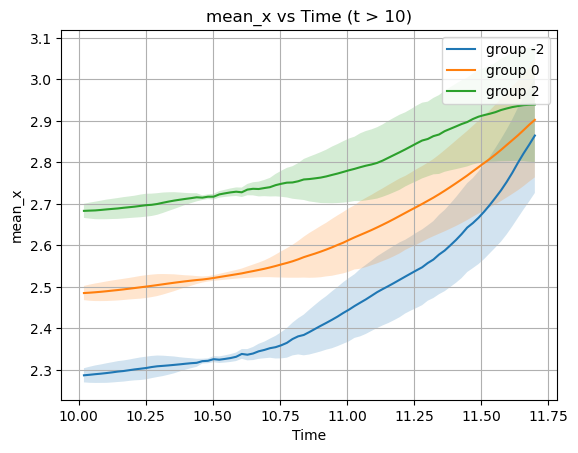

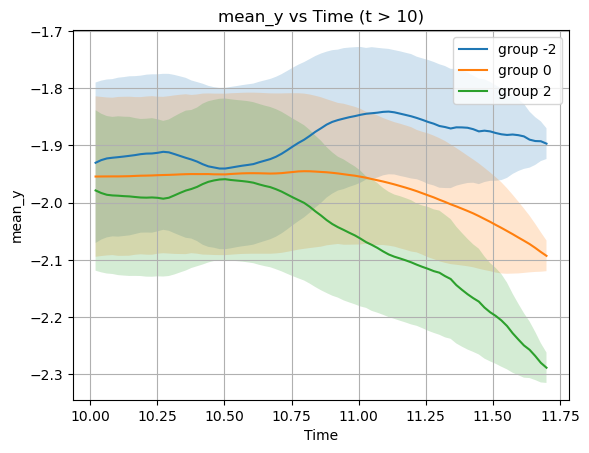

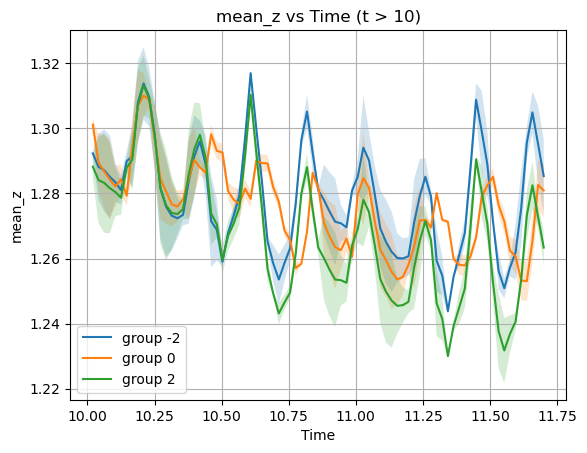

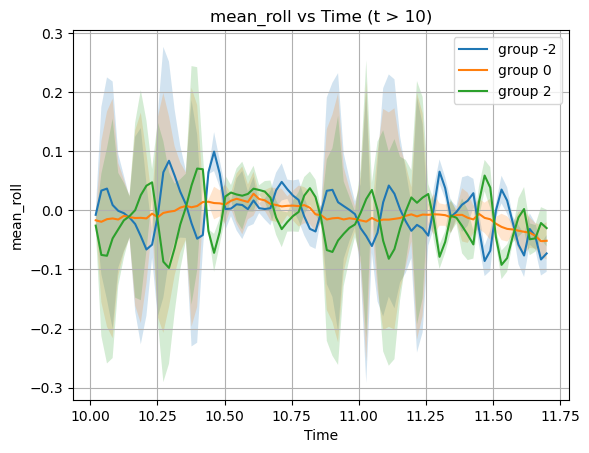

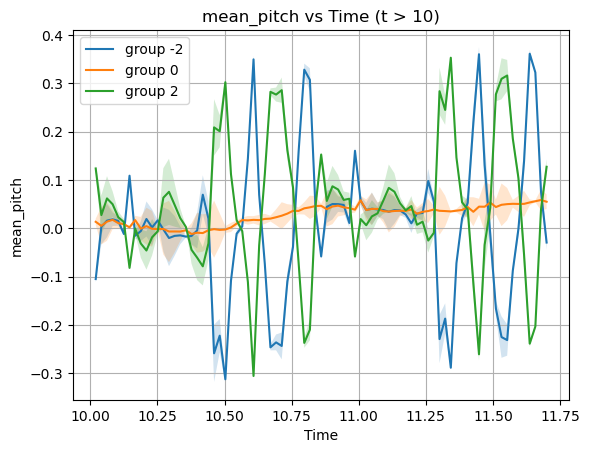

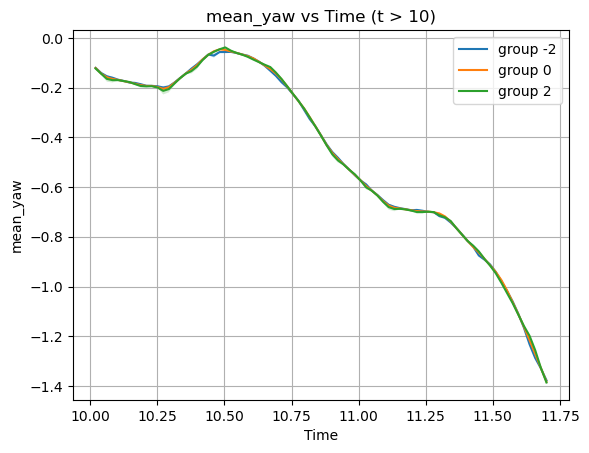

In [7]:
csv_string = data_to_plot
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# === Adjustable time filter ===
time_threshold = 10   # 👈 change this to any value you want

# === Load CSV ===
df = pd.read_csv(StringIO(csv_string))

# Convert numeric columns
df["timestamp"] = pd.to_numeric(df["timestamp"])
df["group_x"] = pd.to_numeric(df["group_x"])

# Filter groups
groups = [-2, 0, 2]
df = df[df["group_x"].isin(groups)]

# 🔥 Filter by time threshold
df = df[df["timestamp"] > time_threshold]

# Sort for clean plotting
df = df.sort_values(["group_x", "timestamp"])

# === Metrics to plot ===
metrics = [
    "mean_x",
    "mean_y",
    "mean_z",
    "mean_roll",
    "mean_pitch",
    "mean_yaw"
]

# === Plot ===
for metric in metrics:
    plt.figure()

    for g in groups:
        
        group_df = df[df["group_x"] == g]

        if group_df.empty:
            continue  # skip if no data after filtering

        t = group_df["timestamp"].to_numpy()
        values = group_df[metric].to_numpy()
        variance_metric = metric.replace("mean", "var")

        if variance_metric in group_df.columns:
            var = group_df[variance_metric].to_numpy()
            std = var ** 0.5
            plt.fill_between(t, values - std, values + std, alpha=0.2)
       

        plt.plot(t, values, label=f"group {g}")

    plt.xlabel("Time")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Time (t > {time_threshold})")
    plt.legend()
    plt.grid(True)
    plt.show()

In [2]:
data_to_plot = """
SKYWEAVE_GROUP_STATS,timestamp,group_x,g.count,mean_x,var_x,mean_y,var_y,mean_z,var_z,mean_roll,var_roll,mean_pitch,var_pitch,mean_yaw,var_yaw
SKYWEAVE_GROUP_STATS,25.199,-2,5,-0.086303,8.67362e-19,-0.048519,0.02,1.29794,0,0,0,0,0,0,0
SKYWEAVE_GROUP_STATS,25.199,0,5,0.113697,0,-0.048519,0.02,1.29794,0,0,0,0,0,0,0
SKYWEAVE_GROUP_STATS,25.199,2,5,0.313697,0,-0.048519,0.02,1.29794,0,0,0,0,0,0,0
SKYWEAVE_GROUP_STATS,25.22,-2,5,-0.084766,2.51503e-08,-0.0484323,0.0199842,1.28415,7.17987e-07,-0.000766287,0.000574434,-0.188086,1.97541e-06,-0.00164352,8.47998e-07
SKYWEAVE_GROUP_STATS,25.22,0,5,0.1137,3.30401e-09,-0.0485877,0.0199902,1.30497,4.62302e-07,-0.000881913,0.000542331,-0.00240471,1.48062e-07,-0.000328082,3.27506e-06
SKYWEAVE_GROUP_STATS,25.22,2,5,0.312175,1.18318e-08,-0.0484733,0.019976,1.28414,5.72645e-07,-0.00101091,0.000569054,0.183536,1.96638e-06,0.000855069,1.20844e-06
SKYWEAVE_GROUP_STATS,25.241,-2,5,-0.0828552,1.61101e-07,-0.0475272,0.0199818,1.27453,2.92517e-06,0.00450215,0.00104232,-0.283813,6.83577e-05,-0.00771471,2.2183e-06
SKYWEAVE_GROUP_STATS,25.241,0,5,0.113724,1.32328e-07,-0.0484555,0.0199877,1.3048,1.05048e-07,-0.00835442,0.000944217,-0.000273412,6.78832e-05,-0.00303989,1.1653e-05
SKYWEAVE_GROUP_STATS,25.241,2,5,0.31037,2.67769e-08,-0.0488732,0.0199777,1.27439,1.83804e-06,-0.0176944,0.00101201,0.278356,3.1173e-05,-0.0022828,1.69123e-06
SKYWEAVE_GROUP_STATS,25.262,-2,5,-0.0828921,1.38114e-06,-0.0451153,0.0199642,1.27303,1.42245e-05,0.0199113,0.000992896,-0.267049,0.000383874,-0.0170524,3.26041e-06
SKYWEAVE_GROUP_STATS,25.262,0,5,0.113951,2.20895e-06,-0.0477827,0.0199859,1.30183,2.33299e-07,-0.00920961,0.000892959,0.00105718,0.000384254,-0.0113376,1.02127e-05
SKYWEAVE_GROUP_STATS,25.262,2,5,0.310787,6.85953e-07,-0.0500267,0.0199608,1.27227,1.49071e-05,-0.0358891,0.000937601,0.263104,0.000313139,-0.012847,1.58166e-06
SKYWEAVE_GROUP_STATS,25.283,-2,5,-0.0849356,9.53529e-06,-0.0418574,0.0199763,1.27852,9.24151e-06,0.0179829,0.000203096,-0.123119,0.00030242,-0.0248172,3.52015e-07
SKYWEAVE_GROUP_STATS,25.283,0,5,0.114291,1.0663e-05,-0.0466391,0.0199857,1.29206,3.08849e-07,-0.00689283,0.000197649,0.00389057,0.000304083,-0.0234224,7.36682e-07
SKYWEAVE_GROUP_STATS,25.283,2,5,0.313424,8.83136e-06,-0.0513882,0.0199713,1.27682,1.52398e-05,-0.0313209,0.000199325,0.127313,0.000288526,-0.024612,2.48716e-07
SKYWEAVE_GROUP_STATS,25.304,-2,5,-0.0849692,2.54672e-05,-0.0379988,0.0199155,1.28192,9.99621e-06,0.0138215,0.00157571,-0.0412765,0.000160879,-0.0365242,6.56937e-07
SKYWEAVE_GROUP_STATS,25.304,0,5,0.11466,2.63385e-05,-0.0453977,0.0199423,1.2888,6.3046e-06,-0.00503039,0.00147708,0.00963554,0.0001966,-0.0370162,1.91014e-07
SKYWEAVE_GROUP_STATS,25.304,2,5,0.314196,2.46381e-05,-0.0528299,0.0199095,1.27942,1.99969e-05,-0.0256911,0.00161595,0.0326002,0.000235412,-0.0366655,3.17527e-07
SKYWEAVE_GROUP_STATS,25.325,-2,5,-0.0841363,5.04187e-05,-0.0342681,0.0199637,1.29521,3.45571e-06,0.00691182,0.00078843,0.14054,8.37372e-05,-0.0498094,3.1704e-06
SKYWEAVE_GROUP_STATS,25.325,0,5,0.114876,4.81126e-05,-0.0441659,0.0199285,1.28027,4.16888e-06,-0.00593989,0.00078481,0.0072608,8.27012e-05,-0.0494424,1.14459e-06
SKYWEAVE_GROUP_STATS,25.325,2,5,0.314198,4.98857e-05,-0.0537989,0.0199581,1.29146,1.20418e-05,-0.0196519,0.000800723,-0.0922533,9.73407e-05,-0.0482507,1.47598e-06
SKYWEAVE_GROUP_STATS,25.346,-2,5,-0.0805889,7.36258e-05,-0.0302436,0.0198995,1.31366,1.65639e-05,-0.0220474,0.00105171,0.293876,0.000173508,-0.0710779,2.8554e-06
SKYWEAVE_GROUP_STATS,25.346,0,5,0.11538,7.6452e-05,-0.0432007,0.0199085,1.2821,2.18985e-06,-0.00179188,0.000962665,0.0101635,0.000174273,-0.0624404,9.40345e-06
SKYWEAVE_GROUP_STATS,25.346,2,5,0.312154,6.90286e-05,-0.0551494,0.0199184,1.30939,8.46834e-07,0.0147207,0.00102001,-0.26421,0.000116509,-0.0600743,1.5393e-06
SKYWEAVE_GROUP_STATS,25.367,-2,5,-0.0795241,0.000115375,-0.0256766,0.0198228,1.32164,4.2005e-05,-0.0399119,0.00101491,0.280308,0.000569313,-0.0908838,5.54141e-06
SKYWEAVE_GROUP_STATS,25.367,0,5,0.116221,0.000126554,-0.0424008,0.0198593,1.29035,3.291e-06,-0.00408542,0.000908789,0.0116149,0.000568549,-0.080702,9.80903e-06
SKYWEAVE_GROUP_STATS,25.367,2,5,0.312835,0.00011053,-0.0579874,0.0198601,1.31721,7.90007e-06,0.0283575,0.000944135,-0.248278,0.000478828,-0.0794057,1.17513e-06
SKYWEAVE_GROUP_STATS,25.388,-2,5,-0.081634,0.000201659,-0.0216144,0.0197647,1.30639,3.37274e-05,-0.0404685,0.000765155,-0.00161926,0.000344622,-0.100859,2.86835e-07
SKYWEAVE_GROUP_STATS,25.388,0,5,0.117376,0.000201284,-0.0417031,0.0197839,1.30797,5.56811e-06,-0.014244,0.000748884,0.0132364,0.000343634,-0.100807,2.04928e-08
SKYWEAVE_GROUP_STATS,25.388,2,5,0.316283,0.000204747,-0.0619014,0.0197915,1.30213,5.10814e-06,0.0122301,0.000762921,0.0190259,0.000358087,-0.101594,8.13201e-08
SKYWEAVE_GROUP_STATS,25.409,-2,5,-0.0799708,0.000291823,-0.0175127,0.01971,1.29232,8.20078e-07,-0.00760862,2.05234e-05,-0.105233,4.38358e-05,-0.120765,8.00216e-08
SKYWEAVE_GROUP_STATS,25.409,0,5,0.11821,0.000292769,-0.0415967,0.0197015,1.30114,4.84106e-06,-0.0168416,2.32233e-05,0.0133494,4.16513e-05,-0.121441,2.67828e-07
SKYWEAVE_GROUP_STATS,25.409,2,5,0.316149,0.000289157,-0.0659361,0.0197044,1.28824,1.19209e-05,-0.0258372,2.56672e-05,0.123735,3.96528e-05,-0.123398,1.73384e-07
SKYWEAVE_GROUP_STATS,25.43,-2,5,-0.0787285,0.000372907,-0.0128992,0.0193263,1.2882,0.00010355,0.0334281,0.0200504,0.00277179,0.00130221,-0.141563,1.22977e-05
SKYWEAVE_GROUP_STATS,25.43,0,5,0.119041,0.000378215,-0.0414892,0.0193737,1.28954,7.49957e-05,-0.019344,0.0185157,0.00500136,0.00149517,-0.144024,9.59236e-06
SKYWEAVE_GROUP_STATS,25.43,2,5,0.316721,0.000368862,-0.070412,0.0192461,1.28412,0.000172919,-0.0754452,0.0188663,0.0272105,0.0016502,-0.14457,1.95706e-05
SKYWEAVE_GROUP_STATS,25.451,-2,5,-0.0772962,0.000443131,-0.00993454,0.0190675,1.28716,0.000157463,0.0368427,0.035405,0.0157131,0.0011805,-0.154639,1.95442e-05
SKYWEAVE_GROUP_STATS,25.451,0,5,0.120048,0.000449384,-0.0414257,0.0190968,1.28679,0.000126501,-0.0149041,0.033178,0.0136228,0.001567,-0.158736,1.11112e-05
SKYWEAVE_GROUP_STATS,25.451,2,5,0.317228,0.000444104,-0.0735219,0.0189674,1.28328,0.000235433,-0.0768453,0.0332332,0.0617318,0.00213282,-0.165138,0.000125061
SKYWEAVE_GROUP_STATS,25.472,-2,5,-0.0760481,0.000492663,-0.00869997,0.0189163,1.28515,0.000161636,0.00901756,0.0437263,0.0184984,0.000192852,-0.16044,1.15645e-05
SKYWEAVE_GROUP_STATS,25.472,0,5,0.121208,0.00050074,-0.0413543,0.0189447,1.28434,0.000153951,-0.0137181,0.0410401,0.0174798,0.000384011,-0.165272,7.44039e-06
SKYWEAVE_GROUP_STATS,25.472,2,5,0.318366,0.000501724,-0.0746569,0.0188752,1.28166,0.000194386,-0.0474427,0.0410295,0.0496892,0.000716821,-0.170197,8.77911e-05
SKYWEAVE_GROUP_STATS,25.493,-2,5,-0.0745812,0.000555226,-0.00771697,0.0193194,1.28346,3.5367e-05,-0.000811963,0.00928925,0.0151064,9.71806e-05,-0.168361,1.26757e-06
SKYWEAVE_GROUP_STATS,25.493,0,5,0.122545,0.000556267,-0.04137,0.0193121,1.28212,3.94393e-05,-0.0154949,0.00913368,0.0105656,0.000121957,-0.169393,4.04634e-07
SKYWEAVE_GROUP_STATS,25.493,2,5,0.319666,0.00055636,-0.0751303,0.0192935,1.28045,5.50319e-05,-0.0320847,0.00911814,0.022797,0.000150028,-0.170235,3.76836e-06
SKYWEAVE_GROUP_STATS,25.514,-2,5,-0.0729131,0.000592901,-0.00663354,0.0193142,1.28103,2.00704e-05,-0.00482019,0.00404831,-0.0119718,6.74869e-06,-0.173363,6.00717e-07
SKYWEAVE_GROUP_STATS,25.514,0,5,0.123997,0.000594259,-0.0411879,0.0193411,1.28437,2.10638e-05,-0.00936992,0.00380037,0.00845139,1.75547e-05,-0.174238,2.06178e-07
SKYWEAVE_GROUP_STATS,25.514,2,5,0.32084,0.000591042,-0.0758806,0.0193109,1.2787,2.76351e-05,-0.0168629,0.00402005,0.0128217,4.14993e-05,-0.17399,3.57197e-07
SKYWEAVE_GROUP_STATS,25.535,-2,5,-0.0710243,0.000630209,-0.00538885,0.0193592,1.28991,9.39499e-06,-0.0122296,0.0011913,0.108763,3.37657e-07,-0.179867,2.54705e-06
SKYWEAVE_GROUP_STATS,25.535,0,5,0.125391,0.000629757,-0.0410023,0.0193319,1.27932,9.37702e-06,-0.0115025,0.00124434,0.00191852,6.20281e-07,-0.178741,1.56372e-07
SKYWEAVE_GROUP_STATS,25.535,2,5,0.321977,0.000631651,-0.0763608,0.0193664,1.28788,8.30695e-06,-0.0098141,0.00122172,-0.0821126,2.96043e-06,-0.17773,2.10514e-06
SKYWEAVE_GROUP_STATS,25.556,-2,5,-0.0697043,0.000646621,-0.00411093,0.0190735,1.29145,9.27606e-05,-0.0230958,0.0218373,-0.0154706,3.45801e-05,-0.181236,5.43689e-07
SKYWEAVE_GROUP_STATS,25.556,0,5,0.126947,0.000651277,-0.0405312,0.019022,1.29418,8.62328e-05,-0.0129703,0.0219669,0.0168444,7.61063e-05,-0.184653,3.88791e-06
SKYWEAVE_GROUP_STATS,25.556,2,5,0.323544,0.000659766,-0.0773749,0.0190555,1.29044,8.29881e-05,0.000331076,0.0219199,-0.000457202,0.000101335,-0.186106,8.18566e-06
SKYWEAVE_GROUP_STATS,25.577,-2,5,-0.0677394,0.000661058,-0.00245283,0.01886,1.30799,0.000160642,-0.0436827,0.0334849,-0.00595091,0.000420584,-0.186486,7.28873e-06
SKYWEAVE_GROUP_STATS,25.577,0,5,0.128621,0.000671337,-0.0401479,0.0188975,1.30701,0.000119131,-0.0126733,0.0317301,-0.000824261,0.000590384,-0.190202,4.74898e-06
SKYWEAVE_GROUP_STATS,25.577,2,5,0.324901,0.000675754,-0.0783021,0.0188678,1.30715,0.000128295,0.0257937,0.0316327,-0.0315978,0.000863131,-0.193548,4.65032e-05
SKYWEAVE_GROUP_STATS,25.598,-2,5,-0.0657748,0.000693109,-0.00147645,0.0190577,1.31382,0.000126024,-0.0662267,0.0125283,0.0191641,0.00131942,-0.192615,6.71253e-06
SKYWEAVE_GROUP_STATS,25.598,0,5,0.130279,0.000705397,-0.0399707,0.0191306,1.3101,4.68844e-05,-0.013609,0.0120015,0.00439191,0.00145214,-0.193514,3.30955e-06
SKYWEAVE_GROUP_STATS,25.598,2,5,0.32632,0.00069833,-0.0785704,0.0190769,1.31326,8.4059e-05,0.0417459,0.0121363,-0.0461013,0.00157488,-0.195159,1.9419e-05
SKYWEAVE_GROUP_STATS,25.619,-2,5,-0.0641745,0.00073892,-0.00127695,0.0191863,1.30964,8.05189e-05,-0.0580653,0.000495871,0.00167533,0.00139501,-0.193154,3.22253e-06
SKYWEAVE_GROUP_STATS,25.619,0,5,0.131968,0.000744143,-0.039707,0.0192423,1.30878,3.69259e-06,-0.00553606,0.000507868,-0.00122014,0.00136106,-0.193391,6.39987e-07
SKYWEAVE_GROUP_STATS,25.619,2,5,0.328068,0.000743183,-0.0781892,0.0192298,1.30916,3.71619e-05,0.0473922,0.000502812,-0.0187675,0.00142936,-0.194591,2.48947e-07
SKYWEAVE_GROUP_STATS,25.64,-2,5,-0.0624776,0.000745335,-0.000109747,0.0188705,1.29776,0.00010636,-0.0100397,0.02913,0.016237,6.35892e-07,-0.194793,8.60265e-07
SKYWEAVE_GROUP_STATS,25.64,0,5,0.133677,0.000754014,-0.0392622,0.0188611,1.29651,0.000104011,-0.0115645,0.0283417,-0.00169558,1.03927e-05,-0.198037,4.54598e-06
SKYWEAVE_GROUP_STATS,25.64,2,5,0.329781,0.000760297,-0.0788011,0.0188638,1.29742,0.000106149,-0.0179107,0.0281037,-0.00629661,3.17839e-05,-0.199945,3.09586e-06
SKYWEAVE_GROUP_STATS,25.661,-2,5,-0.0600834,0.000714196,0.00165244,0.018616,1.28158,0.000245223,0.064477,0.0449976,-0.0024584,0.00205928,-0.199819,3.37614e-05
SKYWEAVE_GROUP_STATS,25.661,0,5,0.135452,0.000735281,-0.0389541,0.0187062,1.2845,0.000152237,-0.00434038,0.0412202,-0.00149669,0.00279368,-0.205231,2.1955e-05
SKYWEAVE_GROUP_STATS,25.661,2,5,0.330747,0.000725177,-0.0803787,0.0185281,1.28157,0.000297581,-0.0869287,0.0415719,0.0632258,0.0037382,-0.213268,0.000209151
SKYWEAVE_GROUP_STATS,25.682,-2,5,-0.0582745,0.000672868,0.000744064,0.0188282,1.27593,0.000236807,0.0839151,0.0281481,-0.0202336,0.0034088,-0.195617,3.22399e-05
SKYWEAVE_GROUP_STATS,25.682,0,5,0.137322,0.000697772,-0.0386874,0.0189414,1.28058,9.74616e-05,-0.00230632,0.0260624,-0.00676914,0.00402408,-0.198633,1.92389e-05
SKYWEAVE_GROUP_STATS,25.682,2,5,0.332715,0.000678598,-0.0787024,0.0187434,1.27633,0.000283922,-0.0974485,0.0262681,0.0753974,0.00467963,-0.206071,0.000171585
SKYWEAVE_GROUP_STATS,25.703,-2,5,-0.0572651,0.000601428,-0.00233022,0.0191662,1.27318,0.000113823,0.0589174,0.0125007,-0.0158156,0.00170014,-0.179632,7.57997e-06
SKYWEAVE_GROUP_STATS,25.703,0,5,0.139236,0.000612834,-0.0383092,0.0192187,1.2767,4.55868e-05,-0.000872686,0.0119577,-0.0066843,0.00187831,-0.180967,4.16002e-06
SKYWEAVE_GROUP_STATS,25.703,2,5,0.335686,0.000605685,-0.0745279,0.0191288,1.27402,0.000128272,-0.0640152,0.0119398,0.0484559,0.00204362,-0.183898,3.26993e-05
SKYWEAVE_GROUP_STATS,25.724,-2,5,-0.0561463,0.000504259,-0.00560212,0.0193867,1.27239,3.90979e-05,0.0315123,0.00602971,-0.0147662,0.000340075,-0.161329,1.22291e-06
SKYWEAVE_GROUP_STATS,25.724,0,5,0.141144,0.000508632,-0.0378514,0.0194094,1.27596,2.30576e-05,0.00461852,0.00582831,-0.00681851,0.000388232,-0.162135,4.92515e-07
SKYWEAVE_GROUP_STATS,25.724,2,5,0.338459,0.000506228,-0.0701561,0.019379,1.27367,3.8615e-05,-0.0239277,0.00586307,0.0208761,0.000423109,-0.16225,1.89095e-06
SKYWEAVE_GROUP_STATS,25.745,-2,5,-0.0548812,0.00040957,-0.00886144,0.0195635,1.27341,1.03298e-05,0.0102711,0.00324712,-0.0173266,4.23627e-06,-0.143395,3.14104e-07
SKYWEAVE_GROUP_STATS,25.745,0,5,0.143002,0.000410879,-0.0374919,0.0195494,1.27817,9.5717e-06,0.00745876,0.00320541,-0.00417591,3.3122e-06,-0.143671,4.44134e-08
SKYWEAVE_GROUP_STATS,25.745,2,5,0.340899,0.000411552,-0.0661463,0.0195641,1.27516,9.49456e-06,0.0051889,0.00323216,0.00277254,2.08739e-06,-0.144314,6.95601e-07
SKYWEAVE_GROUP_STATS,25.766,-2,5,-0.0535814,0.000293595,-0.0118224,0.0191265,1.28363,0.000167557,-0.0218555,0.043452,-0.0159668,0.000305577,-0.124009,9.89607e-06
SKYWEAVE_GROUP_STATS,25.766,0,5,0.144748,0.000300031,-0.0372813,0.0191498,1.28442,0.000148894,0.00523548,0.040917,-0.0118755,0.00048644,-0.128619,6.80462e-06
SKYWEAVE_GROUP_STATS,25.766,2,5,0.342989,0.000302816,-0.0633798,0.0190994,1.28569,0.000182096,0.0422315,0.0407681,-0.044701,0.00084029,-0.133765,9.08159e-05
SKYWEAVE_GROUP_STATS,25.787,-2,5,-0.0521333,0.00020534,-0.0154059,0.0193433,1.29141,0.0001579,-0.0479656,0.0309982,-0.00458751,0.0013891,-0.106692,1.67029e-05
SKYWEAVE_GROUP_STATS,25.787,0,5,0.14647,0.000210546,-0.0373206,0.0193933,1.29032,0.000108895,0.00738037,0.0291868,-0.00926427,0.0017135,-0.110054,1.00927e-05
SKYWEAVE_GROUP_STATS,25.787,2,5,0.344966,0.000207432,-0.059743,0.0192679,1.29361,0.0002071,0.0707744,0.0294344,-0.0609281,0.00217574,-0.115683,0.000106084
SKYWEAVE_GROUP_STATS,25.808,-2,5,-0.0508442,0.000143696,-0.0200329,0.0198303,1.29606,4.08682e-05,-0.0418139,0.000734384,0.0694434,0.00161941,-0.0867375,1.92447e-06
SKYWEAVE_GROUP_STATS,25.808,0,5,0.148013,0.000151752,-0.037324,0.0198257,1.28804,6.16943e-06,0.0141241,0.00073967,-0.00996122,0.00148837,-0.0866621,8.16755e-07
SKYWEAVE_GROUP_STATS,25.808,2,5,0.346785,0.000142082,-0.0547986,0.0197927,1.29804,9.36408e-05,0.0695922,0.000750235,-0.078843,0.00156546,-0.0891688,4.47222e-07
SKYWEAVE_GROUP_STATS,25.829,-2,5,-0.0499214,9.40129e-05,-0.0237886,0.0198357,1.28896,8.221e-05,0.0645555,1.17175e-05,0.0199099,0.00125817,-0.0672848,2.20109e-06
SKYWEAVE_GROUP_STATS,25.829,0,5,0.149492,9.2636e-05,-0.0372921,0.0199002,1.28647,4.05791e-06,0.0145334,1.14111e-05,-0.00414891,0.00123446,-0.0680526,1.06222e-07
SKYWEAVE_GROUP_STATS,25.829,2,5,0.348845,9.59877e-05,-0.0508755,0.019894,1.29109,2.50851e-05,-0.0351697,1.07823e-05,-0.0313345,0.0012308,-0.0681601,1.68703e-07
SKYWEAVE_GROUP_STATS,25.85,-2,5,-0.0458982,3.41286e-05,-0.0257007,0.0197244,1.27148,0.000201064,0.0994402,0.00108748,-0.258969,0.00351031,-0.071341,7.49736e-05
SKYWEAVE_GROUP_STATS,25.85,0,5,0.150721,5.32286e-05,-0.0377109,0.0199269,1.29819,8.85869e-06,0.0123584,0.000764956,-0.00188497,0.00349157,-0.0540494,1.51408e-05
SKYWEAVE_GROUP_STATS,25.85,2,5,0.347977,3.26272e-05,-0.0484418,0.0198492,1.27383,9.086e-05,-0.0718921,0.00103297,0.208812,0.0034149,-0.0561945,1.90607e-05
SKYWEAVE_GROUP_STATS,25.871,-2,5,-0.045047,3.34551e-05,-0.0276034,0.0198667,1.26882,8.92251e-05,0.0622772,0.000522462,-0.222394,0.00118999,-0.0572615,9.13089e-06
SKYWEAVE_GROUP_STATS,25.871,0,5,0.15242,4.19239e-05,-0.0377874,0.0199438,1.2931,7.06149e-06,0.0118351,0.00048746,-0.00340104,0.00118341,-0.0466533,5.32167e-06
SKYWEAVE_GROUP_STATS,25.871,2,5,0.350255,3.16441e-05,-0.0468032,0.0199444,1.27052,1.74276e-05,-0.0364903,0.000506898,0.20082,0.00110763,-0.0460722,7.844e-07
SKYWEAVE_GROUP_STATS,25.892,-2,5,-0.0411116,5.46007e-05,-0.0276025,0.0199274,1.25901,2.35577e-06,0.00213729,0.00128006,-0.312684,5.71624e-05,-0.0572282,2.46071e-06
SKYWEAVE_GROUP_STATS,25.892,0,5,0.154449,4.63072e-05,-0.0378674,0.0199342,1.29257,7.43256e-06,0.00997901,0.00113444,-0.00269435,4.87477e-05,-0.0485401,1.72084e-05
SKYWEAVE_GROUP_STATS,25.892,2,5,0.350292,4.79821e-05,-0.0462668,0.0199041,1.25962,1.86625e-05,0.0234797,0.00125483,0.302259,9.0969e-05,-0.038538,3.66726e-06
SKYWEAVE_GROUP_STATS,25.913,-2,5,-0.0424064,6.24362e-05,-0.0260108,0.0199334,1.26794,7.79217e-07,0.00298531,0.000164288,-0.108529,9.10121e-05,-0.0566297,3.22278e-08
SKYWEAVE_GROUP_STATS,25.913,0,5,0.156692,5.96257e-05,-0.0371328,0.0199322,1.28077,7.27656e-06,0.0162041,0.000160292,0.00160846,9.09266e-05,-0.0545567,5.72751e-07
SKYWEAVE_GROUP_STATS,25.913,2,5,0.355769,6.12869e-05,-0.0476292,0.0199113,1.267,2.12523e-05,0.0301092,0.000163061,0.111711,9.48706e-05,-0.0515765,3.71604e-07
SKYWEAVE_GROUP_STATS,25.934,-2,5,-0.040588,7.46502e-05,-0.0243121,0.0198579,1.27319,1.0355e-05,0.0102669,0.00196386,-0.0113457,5.3143e-05,-0.060994,1.43921e-07
SKYWEAVE_GROUP_STATS,25.934,0,5,0.158893,7.41529e-05,-0.0365707,0.0198834,1.27807,1.511e-05,0.0196415,0.00183309,0.0095616,3.73495e-05,-0.0605447,1.29438e-07
SKYWEAVE_GROUP_STATS,25.934,2,5,0.35833,7.43473e-05,-0.0485892,0.0198547,1.2708,2.22456e-05,0.0268663,0.00195283,0.0167265,1.83547e-05,-0.0607195,4.09972e-07
SKYWEAVE_GROUP_STATS,25.955,-2,5,-0.038426,8.8839e-05,-0.0226679,0.0198671,1.27941,1.51598e-05,0.0090634,0.00331637,0.00378323,3.04281e-05,-0.0668789,2.85154e-07
SKYWEAVE_GROUP_STATS,25.955,0,5,0.161102,8.94102e-05,-0.0360628,0.0198619,1.27682,1.96969e-05,0.0168828,0.00329555,0.0168252,3.05459e-05,-0.0670668,1.53718e-07
SKYWEAVE_GROUP_STATS,25.955,2,5,0.360643,8.96817e-05,-0.049518,0.0198496,1.27562,2.69439e-05,0.0247928,0.00330787,-0.00595983,3.24991e-05,-0.0676204,6.43297e-07
SKYWEAVE_GROUP_STATS,25.976,-2,5,-0.0353696,0.00010578,-0.0213458,0.0198865,1.29686,1.90388e-06,0.00203548,0.000870798,0.144398,7.37257e-05,-0.0718538,1.05124e-06
SKYWEAVE_GROUP_STATS,25.976,0,5,0.16333,0.000108287,-0.035811,0.0198732,1.2815,8.16185e-06,0.0142766,0.000863508,0.0162959,8.10307e-05,-0.0736937,2.62776e-07
SKYWEAVE_GROUP_STATS,25.976,2,5,0.362307,0.000106518,-0.0507046,0.0198808,1.29137,2.18295e-05,0.0277886,0.000882068,-0.111513,0.000103608,-0.0764741,1.4111e-06
SKYWEAVE_GROUP_STATS,25.997,-2,5,-0.0285084,0.000138168,-0.0198393,0.0198379,1.31698,1.52369e-06,0.0167241,0.0015983,0.349623,6.06949e-05,-0.082874,4.54313e-06
SKYWEAVE_GROUP_STATS,25.997,0,5,0.165554,0.000135885,-0.0357583,0.0198422,1.27839,6.43859e-06,0.0280711,0.0013815,0.0173388,5.95336e-05,-0.082984,2.07359e-05
SKYWEAVE_GROUP_STATS,25.997,2,5,0.360915,0.000127844,-0.0523613,0.0198277,1.3103,1.33766e-05,0.0366748,0.0015044,-0.305872,1.61753e-05,-0.0875699,2.86224e-06
SKYWEAVE_GROUP_STATS,26.018,-2,5,-0.030405,0.000184504,-0.0167005,0.0198169,1.30009,2.7508e-07,0.00373534,6.68253e-05,0.0692539,0.000120094,-0.0959101,4.81103e-08
SKYWEAVE_GROUP_STATS,26.018,0,5,0.168392,0.000187173,-0.0358805,0.0198041,1.29005,6.55869e-06,0.0191659,6.66061e-05,0.0167818,0.00011831,-0.0965917,3.62639e-08
SKYWEAVE_GROUP_STATS,26.018,2,5,0.367409,0.000186284,-0.0552954,0.0197951,1.29267,2.22283e-05,0.0344674,6.66505e-05,-0.0353332,0.000116972,-0.0978967,1.9119e-08
SKYWEAVE_GROUP_STATS,26.039,-2,5,-0.0275054,0.000249216,-0.0138921,0.0197391,1.28376,1.26307e-06,0.00224122,0.00031555,-0.0736625,0.000107919,-0.112287,2.34252e-07
SKYWEAVE_GROUP_STATS,26.039,0,5,0.171051,0.000246567,-0.0361142,0.0197423,1.28935,7.40274e-06,0.0169512,0.000301721,0.01929,0.000112393,-0.110783,1.00265e-07
SKYWEAVE_GROUP_STATS,26.039,2,5,0.369282,0.000249964,-0.057915,0.0197115,1.27578,2.22587e-05,0.0318475,0.000315279,0.11154,0.000103168,-0.108115,9.04706e-07
SKYWEAVE_GROUP_STATS,26.06,-2,5,-0.022186,0.00032812,-0.0110746,0.0196591,1.26525,2.33685e-06,0.00367816,0.000849686,-0.246618,3.87279e-05,-0.1324,1.31431e-06
SKYWEAVE_GROUP_STATS,26.06,0,5,0.173782,0.000313982,-0.0363995,0.0196721,1.28925,6.61925e-06,0.0108505,0.000774126,0.0199549,3.6203e-05,-0.125503,8.8888e-06
SKYWEAVE_GROUP_STATS,26.06,2,5,0.368788,0.000316868,-0.0601402,0.0196443,1.25681,1.48185e-05,0.0215229,0.000837816,0.282412,5.02606e-05,-0.117622,2.11901e-06
SKYWEAVE_GROUP_STATS,26.081,-2,5,-0.0189007,0.000400207,-0.00703626,0.0195536,1.25855,3.19503e-05,0.0339422,0.00088817,-0.236319,0.000267393,-0.153117,3.01118e-06
SKYWEAVE_GROUP_STATS,26.081,0,5,0.176613,0.000406761,-0.0361576,0.0195782,1.28191,5.84411e-06,0.00915188,0.000818789,0.0227516,0.000266821,-0.143435,8.4569e-06
SKYWEAVE_GROUP_STATS,26.081,2,5,0.371109,0.000382409,-0.0637203,0.0195982,1.24928,4.89212e-07,-0.0120797,0.000860774,0.276743,0.000208885,-0.139832,9.74719e-07
SKYWEAVE_GROUP_STATS,26.102,-2,5,-0.0146933,0.00052752,-0.00180063,0.0193936,1.25356,5.85476e-05,0.048146,0.000986907,-0.243709,0.000771972,-0.178579,7.75299e-06
SKYWEAVE_GROUP_STATS,26.102,0,5,0.179844,0.000548268,-0.0356398,0.0194371,1.27749,4.74721e-06,0.00667573,0.000888764,0.0259567,0.000777047,-0.167045,1.05037e-05
SKYWEAVE_GROUP_STATS,26.102,2,5,0.373212,0.000499635,-0.0678944,0.0194669,1.24311,1.06669e-05,-0.0317662,0.00093353,0.285808,0.000684924,-0.165663,1.3318e-06
SKYWEAVE_GROUP_STATS,26.123,-2,5,-0.0122115,0.000745233,0.00446815,0.0192157,1.25861,3.09875e-05,0.0357276,0.000267212,-0.11031,0.000378887,-0.199265,1.2173e-06
SKYWEAVE_GROUP_STATS,26.123,0,5,0.183337,0.000752646,-0.0346273,0.0192417,1.26862,2.96195e-06,0.00768725,0.00025723,0.0302381,0.000383792,-0.195372,1.30021e-06
SKYWEAVE_GROUP_STATS,26.123,2,5,0.378083,0.000727151,-0.0730106,0.0192583,1.24649,5.27338e-06,-0.0197228,0.000265637,0.161915,0.000368857,-0.194642,2.74953e-07
SKYWEAVE_GROUP_STATS,26.144,-2,5,-0.00766741,0.000993315,0.011084,0.0189679,1.2632,1.44908e-05,0.0250001,0.000657786,-0.0386268,0.000137222,-0.226188,6.69982e-07
SKYWEAVE_GROUP_STATS,26.144,0,5,0.18712,0.000995329,-0.0336699,0.0189913,1.2657,3.26274e-06,0.00799971,0.000636235,0.0360374,0.000149717,-0.225076,1.67353e-07
SKYWEAVE_GROUP_STATS,26.144,2,5,0.381365,0.000980505,-0.0780788,0.0189902,1.24955,4.10003e-06,-0.00963108,0.000680853,0.0847601,0.00016396,-0.224671,2.51681e-07
SKYWEAVE_GROUP_STATS,26.165,-2,5,-0.00183296,0.00127543,0.0173056,0.0187243,1.27684,8.89367e-06,0.0175992,0.00121373,0.158867,5.59705e-05,-0.252923,3.17197e-06
SKYWEAVE_GROUP_STATS,26.165,0,5,0.190689,0.00126216,-0.0326446,0.0187037,1.25708,5.24243e-06,0.00719529,0.00120275,0.0359081,4.88901e-05,-0.254411,5.77954e-07
SKYWEAVE_GROUP_STATS,26.165,2,5,0.3841,0.00126894,-0.0828754,0.018742,1.26144,5.32178e-06,-0.00271942,0.0011416,-0.0716782,4.64469e-05,-0.254283,3.41783e-06
SKYWEAVE_GROUP_STATS,26.186,-2,5,0.00737159,0.00155118,0.0228259,0.0184362,1.29645,5.94891e-06,-0.01033,0.00102759,0.328271,0.000157971,-0.289763,2.83609e-06
SKYWEAVE_GROUP_STATS,26.186,0,5,0.194666,0.00156587,-0.0322813,0.0184252,1.2584,4.81849e-08,0.0088375,0.000933696,0.0411986,0.000162761,-0.284138,1.05758e-05
SKYWEAVE_GROUP_STATS,26.186,2,5,0.38457,0.00153648,-0.0876635,0.018446,1.28003,5.47306e-06,0.0250427,0.000986207,-0.237392,0.0001052,-0.284551,1.50842e-06
SKYWEAVE_GROUP_STATS,26.207,-2,5,0.0138448,0.00190006,0.0295296,0.0180593,1.30516,2.69895e-05,-0.0313036,0.000862131,0.307238,0.000572753,-0.326779,4.58276e-06
SKYWEAVE_GROUP_STATS,26.207,0,5,0.199306,0.00195532,-0.0323947,0.018039,1.26824,3.71544e-07,0.0044762,0.000770092,0.043286,0.000580337,-0.319047,9.42184e-06
SKYWEAVE_GROUP_STATS,26.207,2,5,0.387433,0.00190336,-0.0944902,0.0180615,1.28808,1.73079e-05,0.0375022,0.000794207,-0.210089,0.0004874,-0.320179,9.47501e-07
SKYWEAVE_GROUP_STATS,26.228,-2,5,0.0171899,0.00240255,0.0367081,0.0175685,1.29255,2.73899e-05,-0.0357562,0.000870814,0.0393119,0.000424056,-0.355945,2.68654e-07
SKYWEAVE_GROUP_STATS,26.228,0,5,0.204598,0.00241735,-0.0329185,0.0175694,1.28631,3.11672e-06,-0.00667735,0.000853211,0.0460441,0.000422979,-0.355773,3.06612e-08
SKYWEAVE_GROUP_STATS,26.228,2,5,0.391774,0.00243986,-0.102515,0.0175473,1.2751,1.29173e-05,0.0225677,0.000863176,0.0462355,0.000435317,-0.356378,1.87292e-07
SKYWEAVE_GROUP_STATS,26.249,-2,5,0.0242644,0.00292276,0.042847,0.0170813,1.28099,5.24139e-07,-0.00225926,0.000141528,-0.0583946,1.92141e-05,-0.392225,9.91671e-08
SKYWEAVE_GROUP_STATS,26.249,0,5,0.208968,0.00292126,-0.0335681,0.0170735,1.28168,2.27994e-06,-0.00832038,0.000152416,0.0464016,1.73427e-05,-0.392591,2.08033e-07
SKYWEAVE_GROUP_STATS,26.249,2,5,0.392811,0.00291281,-0.109799,0.0170879,1.26337,5.23696e-06,-0.0140545,0.000160467,0.152588,1.63044e-05,-0.393561,5.24212e-07
SKYWEAVE_GROUP_STATS,26.27,-2,5,0.0317552,0.00336567,0.0492798,0.0162804,1.27801,0.00011875,0.033134,0.0249632,0.0443758,0.00110885,-0.428614,1.13358e-05
SKYWEAVE_GROUP_STATS,26.27,0,5,0.213255,0.00335917,-0.0341505,0.0163309,1.271,8.86445e-05,-0.0154278,0.0234247,0.0394191,0.00126854,-0.431174,9.98767e-06
SKYWEAVE_GROUP_STATS,26.27,2,5,0.394472,0.00330777,-0.117843,0.0162791,1.26014,0.000165177,-0.0672136,0.0236153,0.0565153,0.00139025,-0.432631,2.05254e-05
SKYWEAVE_GROUP_STATS,26.291,-2,5,0.0391967,0.00381338,0.0540069,0.0157328,1.27445,0.000145618,0.0347394,0.0328587,0.050063,0.00102829,-0.459271,1.49139e-05
SKYWEAVE_GROUP_STATS,26.291,0,5,0.217942,0.00380645,-0.0351113,0.0157694,1.26674,0.000116574,-0.0134754,0.0308734,0.04498,0.00134297,-0.463004,8.40407e-06
SKYWEAVE_GROUP_STATS,26.291,2,5,0.396314,0.00375226,-0.124663,0.0157153,1.25655,0.000205708,-0.0704105,0.0308604,0.0868471,0.00178051,-0.468192,8.81153e-05
SKYWEAVE_GROUP_STATS,26.312,-2,5,0.0463131,0.00415714,0.0571791,0.0151944,1.2713,0.000177824,0.0137185,0.047759,0.0499002,0.000259378,-0.482241,1.01615e-05
SKYWEAVE_GROUP_STATS,26.312,0,5,0.222944,0.00417489,-0.0361846,0.0152237,1.26348,0.000164827,-0.0127728,0.0444175,0.0467884,0.00050457,-0.487534,8.05864e-06
SKYWEAVE_GROUP_STATS,26.312,2,5,0.39915,0.00414614,-0.130176,0.01518,1.25353,0.00021043,-0.050906,0.0443857,0.0802246,0.000893919,-0.492725,8.4767e-05
SKYWEAVE_GROUP_STATS,26.333,-2,5,0.0537363,0.00469412,0.0597256,0.0151975,1.27084,3.1844e-05,0.00720914,0.00799047,0.048197,0.000239412,-0.507779,1.38975e-06
SKYWEAVE_GROUP_STATS,26.333,0,5,0.228256,0.00468106,-0.0375492,0.0152037,1.26256,3.46916e-05,-0.015391,0.00784437,0.0432908,0.000274546,-0.508707,4.44291e-07
SKYWEAVE_GROUP_STATS,26.333,2,5,0.402695,0.00465913,-0.134906,0.0151966,1.25335,6.07889e-05,-0.0396326,0.00783525,0.0586037,0.000308224,-0.509569,3.7311e-06
SKYWEAVE_GROUP_STATS,26.354,-2,5,0.0615286,0.0050745,0.0621442,0.0148473,1.26961,1.33368e-05,0.000875512,0.00282851,0.0108502,8.85713e-05,-0.529413,1.21419e-06
SKYWEAVE_GROUP_STATS,26.354,0,5,0.234014,0.00507703,-0.0388865,0.0148673,1.26613,1.67913e-05,-0.0134237,0.00265776,0.0416338,0.000116311,-0.530288,2.31826e-07
SKYWEAVE_GROUP_STATS,26.354,2,5,0.406057,0.00504479,-0.139865,0.0148578,1.25255,3.26398e-05,-0.029735,0.00282987,0.0610172,0.000153759,-0.530488,5.26701e-07
SKYWEAVE_GROUP_STATS,26.375,-2,5,0.0701614,0.00548952,0.0640929,0.0145243,1.28092,2.58274e-06,-0.00640865,0.000460569,0.160341,3.51019e-05,-0.55236,1.55698e-06
SKYWEAVE_GROUP_STATS,26.375,0,5,0.23948,0.00546196,-0.0401268,0.0145185,1.26049,6.07367e-06,-0.0146759,0.000465379,0.0384457,3.76971e-05,-0.551094,9.31504e-07
SKYWEAVE_GROUP_STATS,26.375,2,5,0.409911,0.00547381,-0.144524,0.0145327,1.26402,1.30266e-05,-0.0238579,0.000470154,-0.0585402,4.34073e-05,-0.54888,1.15135e-06
SKYWEAVE_GROUP_STATS,26.396,-2,5,0.0780127,0.00582007,0.0663683,0.0141018,1.28514,3.25376e-05,-0.0302556,0.00557309,0.0568408,8.87213e-05,-0.573195,2.3932e-06
SKYWEAVE_GROUP_STATS,26.396,0,5,0.246059,0.00582957,-0.0418798,0.0140882,1.27968,2.15097e-05,-0.0169877,0.00551148,0.0579048,8.3478e-05,-0.572615,6.16723e-07
SKYWEAVE_GROUP_STATS,26.396,2,5,0.413859,0.00584993,-0.150192,0.0140846,1.26905,1.82533e-05,-0.00420155,0.00563852,0.0189994,8.71026e-05,-0.573339,3.17313e-06
SKYWEAVE_GROUP_STATS,26.417,-2,5,0.0868039,0.00587325,0.0681945,0.0132579,1.29407,0.000257527,-0.0436565,0.0617091,0.0378249,0.000221827,-0.589304,9.56627e-06
SKYWEAVE_GROUP_STATS,26.417,0,5,0.252244,0.00596445,-0.0436931,0.0132824,1.28472,0.000207705,-0.0190803,0.0560209,0.0377053,0.000485081,-0.596015,1.2766e-05
SKYWEAVE_GROUP_STATS,26.417,2,5,0.417299,0.00600369,-0.15637,0.0132185,1.27808,0.000206963,0.0192285,0.0550365,0.00622911,0.000969369,-0.601113,7.7648e-05
SKYWEAVE_GROUP_STATS,26.438,-2,5,0.0948452,0.00656835,0.0691199,0.0133662,1.29016,8.04918e-05,-0.0603687,0.000139698,0.0403956,0.00114074,-0.614025,2.05278e-06
SKYWEAVE_GROUP_STATS,26.438,0,5,0.258056,0.0066276,-0.0459886,0.0133677,1.28173,5.24854e-06,-0.012877,0.000142192,0.0400166,0.00111444,-0.614196,3.06361e-07
SKYWEAVE_GROUP_STATS,26.438,2,5,0.421268,0.00666271,-0.161125,0.0133352,1.27429,1.97154e-05,0.0345453,0.000144931,0.0245357,0.00113768,-0.614682,1.56944e-07
SKYWEAVE_GROUP_STATS,26.459,-2,5,0.102726,0.0069164,0.0700869,0.01287,1.28002,7.41288e-05,-0.0377396,0.0135795,0.0389296,0.000200068,-0.63189,1.52735e-06
SKYWEAVE_GROUP_STATS,26.459,0,5,0.263847,0.00695342,-0.0480854,0.0128606,1.2717,5.29418e-05,-0.0179818,0.0134071,0.0400402,0.000184091,-0.633428,1.92898e-06
SKYWEAVE_GROUP_STATS,26.459,2,5,0.424897,0.00698204,-0.166413,0.012854,1.26429,4.75851e-05,0.000797338,0.0133518,0.0308175,0.000171371,-0.634148,2.07619e-07
SKYWEAVE_GROUP_STATS,26.48,-2,5,0.111399,0.00716282,0.0715153,0.0123246,1.26928,0.000139818,0.0136194,0.0373066,0.0377722,0.000353674,-0.65244,6.86642e-06
SKYWEAVE_GROUP_STATS,26.48,0,5,0.269825,0.00718074,-0.0502829,0.0123405,1.26275,0.000133042,-0.0156319,0.0350607,0.0354608,0.000531342,-0.656281,7.49046e-06
SKYWEAVE_GROUP_STATS,26.48,2,5,0.427857,0.0071424,-0.172466,0.0123117,1.25366,0.000179942,-0.0515906,0.0350068,0.0567742,0.000735783,-0.659369,2.64586e-05
SKYWEAVE_GROUP_STATS,26.501,-2,5,0.120194,0.00747662,0.0720136,0.0120194,1.26517,0.00016458,0.0420141,0.0353625,0.034187,0.00147884,-0.671137,1.88101e-05
SKYWEAVE_GROUP_STATS,26.501,0,5,0.27619,0.00748486,-0.052725,0.0120577,1.25953,0.000125892,-0.0156828,0.0329287,0.0345204,0.00187094,-0.674853,1.198e-05
SKYWEAVE_GROUP_STATS,26.501,2,5,0.431631,0.00738271,-0.177845,0.0120125,1.24987,0.000247584,-0.0819473,0.0327532,0.0835363,0.00234154,-0.680642,0.000107829
SKYWEAVE_GROUP_STATS,26.522,-2,5,0.12773,0.00765363,0.0707538,0.0118264,1.26211,0.000153313,0.0280816,0.0375573,0.0374598,0.0007714,-0.679459,1.24833e-05
SKYWEAVE_GROUP_STATS,26.522,0,5,0.282739,0.00766654,-0.055313,0.0118506,1.25598,0.00013245,-0.014401,0.035046,0.0357225,0.0010664,-0.683387,8.21647e-06
SKYWEAVE_GROUP_STATS,26.522,2,5,0.437256,0.00760114,-0.181782,0.0118176,1.24711,0.000208734,-0.0655951,0.034693,0.0756188,0.00145582,-0.688371,7.95989e-05
SKYWEAVE_GROUP_STATS,26.543,-2,5,0.134822,0.00790907,0.0684939,0.0118765,1.26016,5.72401e-05,0.00175966,0.0152718,0.0369388,9.16109e-05,-0.684832,1.30257e-06
SKYWEAVE_GROUP_STATS,26.543,0,5,0.289478,0.00791201,-0.058111,0.0118797,1.25359,5.90802e-05,-0.0129998,0.0147959,0.0362006,0.000131274,-0.6864,9.38201e-07
SKYWEAVE_GROUP_STATS,26.543,2,5,0.443973,0.00789603,-0.18485,0.0118718,1.24547,7.45105e-05,-0.0306477,0.0147333,0.0515817,0.000176433,-0.687567,4.92818e-06
SKYWEAVE_GROUP_STATS,26.564,-2,5,0.142311,0.00803324,0.0661703,0.0118364,1.26002,3.85633e-05,-0.0186071,0.00765309,0.0285062,5.04051e-05,-0.688926,1.60439e-07
SKYWEAVE_GROUP_STATS,26.564,0,5,0.296553,0.008052,-0.0609705,0.0118396,1.25435,3.18578e-05,-0.00927175,0.00752024,0.0357945,3.63803e-05,-0.68979,7.39212e-07
SKYWEAVE_GROUP_STATS,26.564,2,5,0.450659,0.00805921,-0.188136,0.0118278,1.24567,2.96395e-05,-0.00153712,0.00757352,0.0372034,2.43796e-05,-0.690004,2.06585e-07
SKYWEAVE_GROUP_STATS,26.585,-2,5,0.150051,0.00813448,0.0637947,0.0118305,1.26071,3.39951e-05,-0.0346506,0.0021476,0.0101428,0.000390389,-0.693109,1.59943e-07
SKYWEAVE_GROUP_STATS,26.585,0,5,0.303849,0.00814887,-0.063995,0.0118253,1.25808,7.22691e-06,-0.00676924,0.00211526,0.0387699,0.000392015,-0.693589,1.74937e-07
SKYWEAVE_GROUP_STATS,26.585,2,5,0.457291,0.00818654,-0.191678,0.0117971,1.24671,1.2266e-05,0.0218432,0.00215913,0.0458381,0.000423571,-0.694605,6.70328e-07
SKYWEAVE_GROUP_STATS,26.606,-2,5,0.157749,0.0078777,0.0608343,0.0114812,1.271,0.000179257,-0.0245571,0.0467122,0.0302798,7.83836e-05,-0.692034,3.20043e-06
SKYWEAVE_GROUP_STATS,26.606,0,5,0.311153,0.00794114,-0.0672566,0.0114735,1.26369,0.000158158,-0.0101935,0.0435412,0.0300061,0.000162921,-0.696763,5.85848e-06
SKYWEAVE_GROUP_STATS,26.606,2,5,0.464169,0.00797649,-0.195851,0.0114367,1.25714,0.000156772,0.0128671,0.0424626,0.00718782,0.00036129,-0.700437,4.5142e-05
SKYWEAVE_GROUP_STATS,26.627,-2,5,0.165356,0.00798977,0.0575013,0.011571,1.27914,0.000131441,-0.0304592,0.0310144,0.031553,0.000234288,-0.695272,3.88292e-06
SKYWEAVE_GROUP_STATS,26.627,0,5,0.318471,0.00804319,-0.0709031,0.0115564,1.27168,0.000108159,-0.0071274,0.0294313,0.0340741,0.000333538,-0.698418,4.04264e-06
SKYWEAVE_GROUP_STATS,26.627,2,5,0.471361,0.00806887,-0.199649,0.0115141,1.26544,0.000114891,0.0216062,0.0289905,0.0135847,0.000480191,-0.70085,2.06329e-05
SKYWEAVE_GROUP_STATS,26.648,-2,5,0.172931,0.00821543,0.0538589,0.0117603,1.28515,3.19797e-05,-0.0428041,0.000285756,0.0979174,0.000629871,-0.699832,3.29331e-07
SKYWEAVE_GROUP_STATS,26.648,0,5,0.325594,0.00827281,-0.0745172,0.0117256,1.27186,1.15581e-06,-0.00748698,0.000288345,0.0356355,0.000610553,-0.698819,1.91099e-07
SKYWEAVE_GROUP_STATS,26.648,2,5,0.478631,0.0082756,-0.2031,0.0117233,1.27147,1.95199e-05,0.027649,0.000283767,-0.0254657,0.000625619,-0.699138,9.72215e-08
SKYWEAVE_GROUP_STATS,26.669,-2,5,0.180186,0.0083251,0.0508323,0.0116658,1.27903,4.80674e-06,0.00476934,0.00118582,0.0552753,6.6352e-05,-0.701133,4.54729e-08
SKYWEAVE_GROUP_STATS,26.669,0,5,0.332829,0.00831363,-0.0780731,0.0116712,1.26956,3.83036e-06,-0.00663361,0.00117508,0.0387175,6.42655e-05,-0.701357,4.88546e-08
SKYWEAVE_GROUP_STATS,26.669,2,5,0.485598,0.00831417,-0.207061,0.0116772,1.26566,7.82225e-06,-0.0176023,0.00116846,-0.00942748,5.69362e-05,-0.700743,5.11266e-07
SKYWEAVE_GROUP_STATS,26.69,-2,5,0.190526,0.00824393,0.046797,0.0116618,1.25933,9.12252e-05,0.0654891,0.00043066,-0.229474,0.0024943,-0.716885,1.78486e-05
SKYWEAVE_GROUP_STATS,26.69,0,5,0.340447,0.00839421,-0.0821637,0.0115995,1.28012,7.88688e-07,-0.00709921,0.000360704,0.0361033,0.00248568,-0.706245,1.38405e-05
SKYWEAVE_GROUP_STATS,26.69,2,5,0.48931,0.00809805,-0.209786,0.0117948,1.24626,0.000102354,-0.0786298,0.000415295,0.283681,0.00237584,-0.71349,1.09193e-05
SKYWEAVE_GROUP_STATS,26.711,-2,5,0.198882,0.00858391,0.0449956,0.0113836,1.25475,3.59021e-05,0.0377948,0.000342666,-0.187062,0.000991906,-0.724027,3.41668e-06
SKYWEAVE_GROUP_STATS,26.711,0,5,0.34802,0.00864472,-0.0859833,0.011354,1.2719,2.29168e-07,-0.00814702,0.000323894,0.0355505,0.00102291,-0.718273,5.72908e-06
SKYWEAVE_GROUP_STATS,26.711,2,5,0.496192,0.00847749,-0.215771,0.0114796,1.24141,4.32791e-05,-0.0535541,0.000343298,0.244865,0.00094948,-0.721687,1.13187e-06
SKYWEAVE_GROUP_STATS,26.732,-2,5,0.210925,0.00912763,0.0424617,0.0108757,1.24383,7.31468e-07,-0.0113103,0.000797978,-0.288819,4.64975e-06,-0.742495,3.81229e-06
SKYWEAVE_GROUP_STATS,26.732,0,5,0.356179,0.00905731,-0.090144,0.0109447,1.27129,3.64783e-07,-0.0116562,0.000710807,0.0348014,1.94606e-06,-0.738864,2.15442e-05
SKYWEAVE_GROUP_STATS,26.732,2,5,0.500096,0.00901894,-0.220811,0.0109536,1.23,9.05823e-08,-0.00874682,0.000811229,0.353011,8.9542e-06,-0.736608,2.44262e-06
SKYWEAVE_GROUP_STATS,26.753,-2,5,0.220563,0.00958419,0.0444592,0.0104149,1.25437,8.11328e-08,-0.00265284,9.45492e-05,-0.0723888,1.25098e-05,-0.76477,5.07659e-08
SKYWEAVE_GROUP_STATS,26.753,0,5,0.364713,0.00957831,-0.0938338,0.0104221,1.25989,6.67403e-07,-0.007815,9.33651e-05,0.0363636,1.24745e-05,-0.764659,4.95063e-07
SKYWEAVE_GROUP_STATS,26.753,2,5,0.508147,0.00956002,-0.231459,0.0104332,1.23925,2.15577e-06,-0.0125694,9.5387e-05,0.1464,1.0461e-05,-0.765086,6.32593e-08
SKYWEAVE_GROUP_STATS,26.774,-2,5,0.233033,0.0100659,0.0443329,0.00987094,1.26107,1.19367e-05,0.00965238,0.00213241,0.0206012,0.000135814,-0.790367,6.82946e-07
SKYWEAVE_GROUP_STATS,26.774,0,5,0.373597,0.0100724,-0.0977993,0.00988739,1.25809,1.03579e-05,-0.00763611,0.00202591,0.0378132,0.000161915,-0.791105,1.98321e-07
SKYWEAVE_GROUP_STATS,26.774,2,5,0.513825,0.0100264,-0.239696,0.00989771,1.24494,2.33401e-05,-0.0263599,0.00215218,0.0535503,0.000192256,-0.790929,2.85848e-07
SKYWEAVE_GROUP_STATS,26.795,-2,5,0.245917,0.010637,0.0437126,0.00932402,1.26786,1.5698e-05,0.0163517,0.00180691,0.052479,0.000417876,-0.816447,3.21743e-07
SKYWEAVE_GROUP_STATS,26.795,0,5,0.382663,0.0106153,-0.101826,0.00935445,1.25789,9.56764e-06,-0.0125262,0.00180484,0.0436873,0.000418824,-0.81668,3.51539e-07
SKYWEAVE_GROUP_STATS,26.795,2,5,0.519497,0.0105834,-0.247445,0.00936336,1.25078,3.6823e-05,-0.0414595,0.00182945,0.0388722,0.000416552,-0.816712,2.80444e-07
SKYWEAVE_GROUP_STATS,26.816,-2,5,0.260133,0.0112189,0.0412294,0.00876642,1.28763,2.08395e-05,0.0290562,0.00059176,0.218498,0.00105222,-0.840035,1.5622e-06
SKYWEAVE_GROUP_STATS,26.816,0,5,0.391922,0.0110877,-0.106037,0.0088919,1.26064,3.03031e-06,-0.0153306,0.000547268,0.0340776,0.000907714,-0.841071,1.72274e-06
SKYWEAVE_GROUP_STATS,26.816,2,5,0.525296,0.0111144,-0.254302,0.00884383,1.26944,5.67735e-05,-0.0576267,0.000572401,-0.11365,0.000837043,-0.835792,1.78342e-06
SKYWEAVE_GROUP_STATS,26.837,-2,5,0.275941,0.0114726,0.0373682,0.00851019,1.30882,2.55276e-05,-0.03148,0.00073392,0.360274,0.000228188,-0.87531,4.70269e-06
SKYWEAVE_GROUP_STATS,26.837,0,5,0.401345,0.0115153,-0.110781,0.00848144,1.26653,3.8034e-06,-0.00595232,0.000647395,0.0446973,0.000267775,-0.863,1.85313e-05
SKYWEAVE_GROUP_STATS,26.837,2,5,0.530114,0.011434,-0.260357,0.00855551,1.29048,1.00343e-06,0.0142841,0.000700937,-0.260952,0.000175135,-0.858931,1.73837e-06
SKYWEAVE_GROUP_STATS,26.858,-2,5,0.286715,0.0117754,0.0386165,0.00806678,1.29913,0.000154351,-0.0856941,0.000654138,0.130952,0.00262713,-0.892033,1.40055e-05
SKYWEAVE_GROUP_STATS,26.858,0,5,0.411547,0.0119969,-0.115804,0.00798416,1.27896,7.0519e-06,-0.0127412,0.000661701,0.0444924,0.00259834,-0.888681,2.00199e-06
SKYWEAVE_GROUP_STATS,26.858,2,5,0.537379,0.0119552,-0.270787,0.00797801,1.28045,6.56204e-05,0.0588942,0.000705672,-0.0344847,0.00252507,-0.88897,4.14243e-06
SKYWEAVE_GROUP_STATS,26.879,-2,5,0.299463,0.0124373,0.0373731,0.00747546,1.28889,0.000102927,-0.068318,0.00116899,-0.0129509,0.00145666,-0.911353,4.60914e-07
SKYWEAVE_GROUP_STATS,26.879,0,5,0.421448,0.0125073,-0.120778,0.00746109,1.28251,9.14468e-06,-0.01504,0.00119835,0.0531084,0.00138988,-0.914712,8.82326e-07
SKYWEAVE_GROUP_STATS,26.879,2,5,0.543037,0.0125754,-0.278929,0.00739885,1.27059,2.86771e-05,0.038533,0.00120562,0.0422206,0.00147406,-0.915997,1.43033e-06
SKYWEAVE_GROUP_STATS,26.9,-2,5,0.314205,0.0130489,0.0345216,0.00696116,1.27134,2.29864e-07,-0.000454264,0.000141417,-0.166081,0.000235848,-0.941269,4.86147e-07
SKYWEAVE_GROUP_STATS,26.9,0,5,0.431407,0.0130421,-0.126212,0.00695312,1.28513,7.18463e-06,-0.0226251,0.000134915,0.0438862,0.000239915,-0.94136,4.8897e-06
SKYWEAVE_GROUP_STATS,26.9,2,5,0.546835,0.012944,-0.28543,0.00702455,1.25265,3.18692e-05,-0.045073,0.000145942,0.277354,0.000220299,-0.946688,6.12543e-07
SKYWEAVE_GROUP_STATS,26.921,-2,5,0.330295,0.0135423,0.0323143,0.00642698,1.25617,3.27755e-05,0.0351672,0.00054526,-0.225329,0.00183662,-0.978492,6.35516e-06
SKYWEAVE_GROUP_STATS,26.921,0,5,0.441225,0.0136315,-0.131394,0.00635641,1.27636,9.00114e-06,-0.0279819,0.000494989,0.0485429,0.00195032,-0.974068,1.35688e-05
SKYWEAVE_GROUP_STATS,26.921,2,5,0.550122,0.0133039,-0.293282,0.00656152,1.23764,0.000132109,-0.0922493,0.000585486,0.309344,0.00180827,-0.985054,1.11993e-05
SKYWEAVE_GROUP_STATS,26.942,-2,5,0.347709,0.0143525,0.0311535,0.00564157,1.25087,9.7111e-06,0.0164956,0.00050715,-0.231561,0.00104467,-1.01766,3.41844e-06
SKYWEAVE_GROUP_STATS,26.942,0,5,0.451928,0.0143928,-0.136887,0.0055939,1.27146,1.22879e-05,-0.0313683,0.000459005,0.0499094,0.00112433,-1.01569,1.47736e-05
SKYWEAVE_GROUP_STATS,26.942,2,5,0.553943,0.0141364,-0.303026,0.00575621,1.23174,9.94445e-05,-0.0807126,0.00053171,0.316166,0.00104385,-1.02613,6.31711e-06
SKYWEAVE_GROUP_STATS,26.963,-2,5,0.365685,0.0152423,0.0319019,0.00475381,1.25716,6.75811e-06,-0.0209646,0.000112501,-0.0878605,6.16621e-05,-1.06018,1.02103e-07
SKYWEAVE_GROUP_STATS,26.963,0,5,0.463087,0.0152261,-0.142397,0.00475613,1.26248,1.75252e-05,-0.0323254,0.000111665,0.0505831,6.3585e-05,-1.06288,1.1179e-06
SKYWEAVE_GROUP_STATS,26.963,2,5,0.559083,0.0151854,-0.315697,0.00478014,1.2368,3.28264e-05,-0.0437992,0.000115232,0.185592,5.68396e-05,-1.067,1.72546e-07
SKYWEAVE_GROUP_STATS,26.984,-2,5,0.385878,0.0159612,0.0307721,0.00393341,1.26192,7.14859e-05,-0.0579732,0.00109604,-0.00124073,0.000284187,-1.10939,2.38782e-06
SKYWEAVE_GROUP_STATS,26.984,0,5,0.474797,0.0160138,-0.148209,0.00394982,1.26067,2.73287e-05,-0.0344355,0.00100031,0.0503016,0.000277138,-1.11115,4.71362e-07
SKYWEAVE_GROUP_STATS,26.984,2,5,0.562801,0.016039,-0.326537,0.00391697,1.2406,7.27103e-06,-0.0120765,0.00106994,0.103794,0.000230583,-1.11298,7.41296e-07
SKYWEAVE_GROUP_STATS,27.005,-2,5,0.407907,0.016648,0.0286428,0.00323114,1.27539,0.000127246,-0.0764304,0.00132136,0.139268,0.00083965,-1.16573,2.00699e-06
SKYWEAVE_GROUP_STATS,27.005,0,5,0.486396,0.0167551,-0.153844,0.0031718,1.25327,3.56613e-05,-0.0363013,0.00137238,0.0504656,0.000721696,-1.16176,3.80936e-06
SKYWEAVE_GROUP_STATS,27.005,2,5,0.566187,0.0168381,-0.337022,0.00318651,1.25345,5.44479e-06,0.00224753,0.00138511,-0.0553853,0.000775618,-1.15878,1.24277e-05
SKYWEAVE_GROUP_STATS,27.026,-2,5,0.432035,0.0175907,0.0229017,0.00239858,1.29559,2.42966e-05,-0.0315449,0.000703088,0.361321,6.3894e-05,-1.23239,3.99206e-06
SKYWEAVE_GROUP_STATS,27.026,0,5,0.498083,0.0174933,-0.159671,0.0024532,1.25304,3.92582e-05,-0.0377174,0.000661232,0.0534074,3.87192e-05,-1.21544,1.53965e-05
SKYWEAVE_GROUP_STATS,27.026,2,5,0.568628,0.0174836,-0.3446,0.00245037,1.27327,5.76393e-05,-0.0489598,0.000724978,-0.239,5.16516e-05,-1.19831,2.88599e-06
SKYWEAVE_GROUP_STATS,27.047,-2,5,0.454619,0.0182165,0.0204978,0.00174689,1.30492,4.26603e-05,-0.0439789,0.000496079,0.322456,6.20718e-06,-1.28746,1.26388e-06
SKYWEAVE_GROUP_STATS,27.047,0,5,0.510637,0.0181707,-0.166362,0.00177322,1.26541,4.71824e-05,-0.0431791,0.000470215,0.0559137,2.84079e-06,-1.27129,1.00166e-05
SKYWEAVE_GROUP_STATS,27.047,2,5,0.570811,0.01816,-0.355442,0.00177714,1.28253,5.29976e-05,-0.0474164,0.000506481,-0.203467,6.92121e-06,-1.25614,1.24741e-06
SKYWEAVE_GROUP_STATS,27.068,-2,5,0.475625,0.0186487,0.0201373,0.00120463,1.29514,0.000141342,-0.0831519,0.000733716,0.0763406,0.000475499,-1.32881,3.42387e-06
SKYWEAVE_GROUP_STATS,27.068,0,5,0.52364,0.0187466,-0.173602,0.00119012,1.28262,5.7737e-05,-0.0522172,0.000715844,0.0583739,0.000473028,-1.32751,1.54773e-06
SKYWEAVE_GROUP_STATS,27.068,2,5,0.571805,0.0188032,-0.367459,0.00117894,1.27278,1.20179e-05,-0.0214556,0.000722615,0.038426,0.000474091,-1.32689,3.6228e-07
SKYWEAVE_GROUP_STATS,27.089,-2,5,0.497603,0.019155,0.0159514,0.000724248,1.28534,0.000126674,-0.0729437,0.000964783,-0.0296117,0.000231461,-1.37715,4.30083e-07
SKYWEAVE_GROUP_STATS,27.089,0,5,0.535406,0.0191986,-0.180321,0.000720233,1.28093,6.83074e-05,-0.0515036,0.000983505,0.0548826,0.000231625,-1.38274,8.51114e-07
SKYWEAVE_GROUP_STATS,27.089,2,5,0.572295,0.019264,-0.376023,0.00070761,1.26337,2.78767e-05,-0.0300399,0.00097675,0.127248,0.000241587,-1.38594,2.72521e-06
SKYWEAVE_GROUP_STATS,27.11,-2,5,0.520687,0.0191588,0.0111328,0.000360834,1.28179,0.00017457,-0.0623073,0.0314725,0.0684449,2.10576e-06,-1.43685,1.22352e-06
SKYWEAVE_GROUP_STATS,27.11,0,5,0.547116,0.019195,-0.186868,0.000356562,1.27117,0.000175867,-0.0643694,0.0303438,0.056044,1.0151e-05,-1.43896,3.75008e-06
SKYWEAVE_GROUP_STATS,27.11,2,5,0.573099,0.0191624,-0.384894,0.000354193,1.26033,0.000192562,-0.0709569,0.0304574,0.0306595,3.94266e-05,-1.4394,6.85828e-06
SKYWEAVE_GROUP_STATS,27.131,-2,5,0.543983,0.0193977,0.00528664,0.000125594,1.27506,0.000150244,-0.0395545,0.0338095,0.0503041,0.000235415,-1.49311,2.74135e-06
SKYWEAVE_GROUP_STATS,27.131,0,5,0.558959,0.0193729,-0.193887,0.000125747,1.26498,0.000191251,-0.0636162,0.032157,0.0434345,0.000356802,-1.49587,5.10166e-06
SKYWEAVE_GROUP_STATS,27.131,2,5,0.57338,0.0192684,-0.39306,0.00012759,1.25418,0.000275054,-0.0924457,0.0318733,0.0537715,0.000475244,-1.4992,1.50538e-05
SKYWEAVE_GROUP_STATS,27.152,-2,5,0.566712,0.0193272,-0.00155445,1.52402e-05,1.2704,0.000195905,-0.036929,0.0474049,0.041555,0.000268019,-1.545,6.16964e-06
SKYWEAVE_GROUP_STATS,27.152,0,5,0.5711,0.0193273,-0.201271,1.50267e-05,1.26145,0.000234995,-0.0634261,0.0441966,0.0368362,0.000466229,-1.54924,1.28305e-05
SKYWEAVE_GROUP_STATS,27.152,2,5,0.574606,0.0191825,-0.4009,1.58572e-05,1.2504,0.000336739,-0.0973639,0.0440593,0.0574924,0.000682481,-1.55466,3.12783e-05
SKYWEAVE_GROUP_STATS,27.173,-2,5,0.588964,0.0198239,-0.00924576,1.21379e-05,1.26962,8.13434e-05,-0.0500905,0.00856571,0.0459596,9.34748e-05,-1.59811,7.06271e-07
SKYWEAVE_GROUP_STATS,27.173,0,5,0.583384,0.019792,-0.208954,1.17503e-05,1.26058,0.000113283,-0.0645149,0.0084152,0.0417277,0.000116133,-1.59869,2.74523e-07
SKYWEAVE_GROUP_STATS,27.173,2,5,0.577641,0.0197399,-0.408623,1.11534e-05,1.25069,0.000157967,-0.0802615,0.00839664,0.049905,0.000132515,-1.59967,1.81286e-06
SKYWEAVE_GROUP_STATS,27.194,-2,5,0.611343,0.0197194,-0.0177067,0.000108254,1.26839,0.000111093,-0.0646351,0.00393123,0.0351591,1.76464e-05,-1.64672,2.27257e-07
SKYWEAVE_GROUP_STATS,27.194,0,5,0.596263,0.0197574,-0.217014,0.000108608,1.26377,9.7019e-05,-0.0597494,0.00373738,0.0453094,7.0584e-06,-1.6479,2.45921e-07
SKYWEAVE_GROUP_STATS,27.194,2,5,0.580658,0.0197321,-0.415932,0.000108705,1.25064,9.26597e-05,-0.0575567,0.00394222,0.0503156,1.21565e-06,-1.64827,3.33481e-07
SKYWEAVE_GROUP_STATS,27.215,-2,5,0.634637,0.0195614,-0.0273252,0.000296005,1.27668,0.000127869,-0.0742296,0.00169501,0.115732,9.95484e-05,-1.70173,9.18687e-07
SKYWEAVE_GROUP_STATS,27.215,0,5,0.60899,0.0195644,-0.224903,0.000302933,1.25943,8.92484e-05,-0.059867,0.00175384,0.0414797,9.86871e-05,-1.69694,1.76514e-06
SKYWEAVE_GROUP_STATS,27.215,2,5,0.584386,0.0196444,-0.423286,0.000304386,1.26008,5.43163e-05,-0.0443858,0.00168895,-0.0469492,0.000137552,-1.69155,1.02433e-05
SKYWEAVE_GROUP_STATS,27.236,-2,5,0.657597,0.0189618,-0.0369124,0.000566177,1.27873,0.000208105,-0.0696209,0.0296625,0.0296787,2.86072e-05,-1.74326,1.75123e-06
SKYWEAVE_GROUP_STATS,27.236,0,5,0.622947,0.0189362,-0.233877,0.000575579,1.27355,0.000185616,-0.0611672,0.0298135,0.0527648,5.02808e-05,-1.74732,1.4358e-05
SKYWEAVE_GROUP_STATS,27.236,2,5,0.587636,0.0189696,-0.430518,0.000585423,1.26353,0.000160096,-0.0507238,0.0293788,0.0430544,6.19578e-05,-1.74901,2.41606e-06
SKYWEAVE_GROUP_STATS,27.257,-2,5,0.681646,0.0185762,-0.0484274,0.000933519,1.29472,0.000230381,-0.0794288,0.0281952,0.0366395,0.000152541,-1.79458,4.39815e-06
SKYWEAVE_GROUP_STATS,27.257,0,5,0.636935,0.0186145,-0.243251,0.000949783,1.28782,0.000173901,-0.0610618,0.0270962,0.0452873,0.000203073,-1.79752,1.12792e-05
SKYWEAVE_GROUP_STATS,27.257,2,5,0.591818,0.0186215,-0.437969,0.000963448,1.28069,0.000129032,-0.0396118,0.0268268,0.0297148,0.000274727,-1.79915,5.09439e-06
SKYWEAVE_GROUP_STATS,27.278,-2,5,0.704828,0.0182301,-0.0601385,0.00138902,1.30072,0.000218062,-0.0912277,0.0170997,0.0472251,0.000336614,-1.84557,6.64885e-06
SKYWEAVE_GROUP_STATS,27.278,0,5,0.650442,0.0183014,-0.252341,0.00141188,1.29206,0.000135193,-0.0642013,0.0163723,0.0415348,0.000395613,-1.84667,6.89902e-06
SKYWEAVE_GROUP_STATS,27.278,2,5,0.596073,0.018298,-0.444712,0.00142277,1.28792,8.10923e-05,-0.0349307,0.0165098,0.0111426,0.000466479,-1.84627,3.78095e-06
SKYWEAVE_GROUP_STATS,27.299,-2,5,0.727031,0.0178824,-0.0717567,0.00196338,1.29542,0.000150284,-0.0813666,0.000546995,0.00874172,0.000305566,-1.89122,2.98092e-06
SKYWEAVE_GROUP_STATS,27.299,0,5,0.664081,0.0179503,-0.261542,0.00197373,1.29404,7.78301e-05,-0.0569336,0.000543014,0.0278828,0.000297341,-1.89245,1.30704e-06
SKYWEAVE_GROUP_STATS,27.299,2,5,0.600693,0.0179746,-0.450878,0.00199261,1.28364,2.94711e-05,-0.0326583,0.00054353,0.0440731,0.000297493,-1.8939,4.21778e-07
SKYWEAVE_GROUP_STATS,27.32,-2,5,0.749578,0.0170679,-0.0837496,0.00254399,1.28406,0.000171803,-0.0727963,0.0238261,0.0455672,3.98596e-05,-1.94009,8.44152e-07
SKYWEAVE_GROUP_STATS,27.32,0,5,0.677186,0.0170435,-0.270108,0.00256141,1.27629,0.000153559,-0.0653526,0.0237517,0.0258181,1.50441e-05,-1.94115,4.26036e-06
SKYWEAVE_GROUP_STATS,27.32,2,5,0.604701,0.0170533,-0.456536,0.00257367,1.27355,0.000145338,-0.0615565,0.023716,0.0175111,3.0385e-06,-1.94297,2.0242e-06
SKYWEAVE_GROUP_STATS,27.341,-2,5,0.772354,0.0161751,-0.0966589,0.0031435,1.26556,0.000198282,-0.0153174,0.0537854,0.0246149,0.000729403,-1.98918,1.41727e-05
SKYWEAVE_GROUP_STATS,27.341,0,5,0.690402,0.0161379,-0.278957,0.00315317,1.2625,0.000239352,-0.0576327,0.0492891,0.0139791,0.00114573,-1.99411,1.25083e-05
SKYWEAVE_GROUP_STATS,27.341,2,5,0.6075,0.0159168,-0.460708,0.00310325,1.25639,0.000409499,-0.111898,0.0495434,0.0565026,0.00168169,-2.00325,0.000170433
SKYWEAVE_GROUP_STATS,27.362,-2,5,0.79368,0.015783,-0.109874,0.00385903,1.26164,0.000107043,0.00473632,0.0287464,0.00928309,0.00152699,-2.0345,1.41915e-05
SKYWEAVE_GROUP_STATS,27.362,0,5,0.703885,0.015728,-0.288336,0.0038544,1.26022,0.000155802,-0.0534776,0.026897,0.00930656,0.00187735,-2.03725,9.15886e-06
SKYWEAVE_GROUP_STATS,27.362,2,5,0.613459,0.0155193,-0.466316,0.00377611,1.25376,0.00037099,-0.118809,0.0270009,0.0662755,0.00220054,-2.04501,0.000139772
SKYWEAVE_GROUP_STATS,27.383,-2,5,0.813454,0.015304,-0.122469,0.00451871,1.25978,5.67552e-05,-0.0165772,0.0137411,0.0162057,0.000513563,-2.07054,4.04937e-06
SKYWEAVE_GROUP_STATS,27.383,0,5,0.717481,0.0152628,-0.297844,0.00450781,1.25752,9.81565e-05,-0.0497546,0.0132846,0.0110092,0.000593354,-2.07164,1.71119e-06
SKYWEAVE_GROUP_STATS,27.383,2,5,0.621253,0.0151732,-0.473033,0.00447237,1.25307,0.000192637,-0.0856306,0.013228,0.041751,0.000668029,-2.07488,2.3954e-05
SKYWEAVE_GROUP_STATS,27.404,-2,5,0.83302,0.014717,-0.13542,0.0051269,1.25853,7.07089e-05,-0.0416221,0.00777852,0.00866072,1.27901e-06,-2.1039,1.51991e-07
SKYWEAVE_GROUP_STATS,27.404,0,5,0.731333,0.0147256,-0.30761,0.00513328,1.25795,6.87707e-05,-0.0409948,0.00757808,0.0111926,1.10605e-07,-2.10495,5.02401e-07
SKYWEAVE_GROUP_STATS,27.404,2,5,0.629445,0.0147003,-0.479626,0.00512649,1.25298,7.1794e-05,-0.0424228,0.00767034,0.0232008,3.06741e-06,-2.10566,2.88404e-07
SKYWEAVE_GROUP_STATS,27.425,-2,5,0.852729,0.0141674,-0.148865,0.00573627,1.25966,9.43535e-05,-0.0640708,0.00202059,-0.00353247,0.000374224,-2.13786,1.02853e-06
SKYWEAVE_GROUP_STATS,27.425,0,5,0.745314,0.014199,-0.317536,0.00575077,1.26036,3.64158e-05,-0.0367363,0.00199773,0.0152017,0.000372709,-2.13848,8.72362e-07
SKYWEAVE_GROUP_STATS,27.425,2,5,0.637712,0.0142114,-0.485988,0.00577523,1.25535,8.18768e-06,-0.0089892,0.0020234,0.0116958,0.000391309,-2.1393,2.24471e-07
SKYWEAVE_GROUP_STATS,27.446,-2,5,0.872284,0.013279,-0.162575,0.0061153,1.2692,0.000214564,-0.0534635,0.0437032,-0.00086938,0.000155971,-2.16721,3.19589e-06
SKYWEAVE_GROUP_STATS,27.446,0,5,0.75938,0.0132731,-0.327648,0.00615564,1.26755,0.000172237,-0.0346095,0.0412978,0.0100197,0.000230164,-2.17137,7.48766e-06
SKYWEAVE_GROUP_STATS,27.446,2,5,0.64601,0.0132255,-0.49238,0.00616818,1.266,0.000148567,-0.00957364,0.0409085,-0.021151,0.000397359,-2.17482,5.33219e-05
SKYWEAVE_GROUP_STATS,27.467,-2,5,0.891158,0.0127923,-0.17623,0.00672737,1.27629,0.000169835,-0.0482749,0.033892,-0.000419435,0.000142265,-2.19854,2.75868e-06
SKYWEAVE_GROUP_STATS,27.467,0,5,0.773254,0.0127914,-0.337747,0.00676207,1.27452,0.000135188,-0.0300164,0.0323149,0.00876871,0.000213253,-2.20193,5.80941e-06
SKYWEAVE_GROUP_STATS,27.467,2,5,0.655021,0.0127454,-0.499035,0.00676445,1.27409,0.000117654,-0.0066018,0.0322344,-0.0179236,0.000337639,-2.20432,2.68818e-05
SKYWEAVE_GROUP_STATS,27.488,-2,5,0.909727,0.0124601,-0.189853,0.00748741,1.28006,5.38553e-05,-0.0518874,0.000880964,0.0585012,0.0003327,-2.23282,2.97686e-07
SKYWEAVE_GROUP_STATS,27.488,0,5,0.787062,0.0124604,-0.347673,0.00751454,1.27468,1.63223e-05,-0.0265096,0.000904059,0.00473658,0.000313444,-2.23083,6.21342e-07
SKYWEAVE_GROUP_STATS,27.488,2,5,0.664573,0.0124945,-0.505648,0.00751989,1.27868,3.94932e-06,-0.0012568,0.000879117,-0.0475309,0.000333352,-2.23005,2.42798e-06
SKYWEAVE_GROUP_STATS,27.509,-2,5,0.928477,0.0118432,-0.203567,0.00808465,1.27036,2.31374e-05,-0.0100684,0.00635596,0.00482744,0.00010269,-2.2617,1.02909e-07
SKYWEAVE_GROUP_STATS,27.509,0,5,0.800973,0.0118271,-0.357643,0.00807878,1.26849,3.02036e-05,-0.0243639,0.00625774,-0.00336546,0.000104766,-2.26185,1.86728e-07
SKYWEAVE_GROUP_STATS,27.509,2,5,0.673438,0.0118126,-0.511703,0.00808092,1.26994,4.60861e-05,-0.0390017,0.0062169,0.000384433,0.000107504,-2.26281,1.81861e-06
SKYWEAVE_GROUP_STATS,27.53,-2,5,0.946416,0.0113271,-0.219729,0.00855223,1.25193,7.82272e-05,0.0567742,0.000876646,-0.217264,0.00304848,-2.30172,2.2238e-05
SKYWEAVE_GROUP_STATS,27.53,0,5,0.814987,0.0112353,-0.367407,0.00874335,1.27497,7.6295e-06,-0.0229528,0.000816319,0.00635518,0.00303088,-2.29561,6.74375e-06
SKYWEAVE_GROUP_STATS,27.53,2,5,0.683201,0.0113132,-0.515247,0.00847168,1.25308,0.00017663,-0.101795,0.00112253,0.170738,0.00300678,-2.30214,3.46095e-05
SKYWEAVE_GROUP_STATS,27.551,-2,5,0.966117,0.0105113,-0.235678,0.00938381,1.24645,7.74294e-05,0.0569676,0.000589402,-0.230419,0.00280127,-2.34404,1.60711e-05
SKYWEAVE_GROUP_STATS,27.551,0,5,0.828825,0.010398,-0.377481,0.00958225,1.27179,3.8113e-06,-0.0194589,0.000571663,-0.00064593,0.00277149,-2.33705,4.84837e-06
SKYWEAVE_GROUP_STATS,27.551,2,5,0.691235,0.0105221,-0.51951,0.00932161,1.24837,0.000147478,-0.0949632,0.000717512,0.200657,0.00266866,-2.34468,1.91266e-05
SKYWEAVE_GROUP_STATS,27.572,-2,5,0.985478,0.00931688,-0.25464,0.0106603,1.23728,6.95832e-07,-0.00293223,0.000811217,-0.319079,9.09675e-05,-2.39317,4.03413e-06
SKYWEAVE_GROUP_STATS,27.572,0,5,0.842468,0.00933037,-0.387995,0.0106581,1.27245,1.90955e-06,-0.0178649,0.000714197,-0.00786438,9.38037e-05,-2.38987,1.75137e-05
SKYWEAVE_GROUP_STATS,27.572,2,5,0.699235,0.00940026,-0.521756,0.0105867,1.23959,8.7027e-06,-0.0298668,0.000805237,0.303713,4.36019e-05,-2.39199,2.30716e-06
SKYWEAVE_GROUP_STATS,27.593,-2,5,1.00959,0.00807772,-0.271722,0.0118959,1.2468,2.94996e-05,-0.0405784,8.54494e-05,-0.117533,0.000489071,-2.44785,4.06362e-07
SKYWEAVE_GROUP_STATS,27.593,0,5,0.856231,0.0081374,-0.399046,0.0118613,1.26051,1.16135e-06,-0.00928592,8.29882e-05,-0.00715594,0.000483715,-2.44956,2.50933e-07
SKYWEAVE_GROUP_STATS,27.593,2,5,0.70268,0.00810117,-0.526407,0.0118904,1.24928,1.16025e-05,0.0222254,8.2465e-05,0.0993931,0.000498272,-2.4488,2.75582e-07
SKYWEAVE_GROUP_STATS,27.614,-2,5,1.03096,0.00683109,-0.291799,0.0129431,1.25258,0.000117343,-0.0665623,0.00677022,-0.0368598,0.00198338,-2.50685,1.14678e-05
SKYWEAVE_GROUP_STATS,27.614,0,5,0.870126,0.00690055,-0.410125,0.0129818,1.25833,3.10167e-05,-0.00457662,0.00681438,0.00212037,0.00184427,-2.50844,3.58538e-06
SKYWEAVE_GROUP_STATS,27.614,2,5,0.709074,0.0068619,-0.528357,0.012953,1.25534,9.09653e-05,0.0541157,0.00732463,0.00262893,0.00159213,-2.50926,3.59863e-06
SKYWEAVE_GROUP_STATS,27.635,-2,5,1.05185,0.00583265,-0.312926,0.0141133,1.25642,7.54646e-05,-0.0652491,0.000101042,-0.0482445,0.0017552,-2.56747,1.37523e-06
SKYWEAVE_GROUP_STATS,27.635,0,5,0.884036,0.00587102,-0.421253,0.0141245,1.26128,2.84526e-07,-0.00633463,9.26675e-05,-0.00596038,0.0016836,-2.56876,8.05559e-08
SKYWEAVE_GROUP_STATS,27.635,2,5,0.716123,0.00585001,-0.529539,0.0141142,1.2591,6.29389e-05,0.0526187,9.08861e-05,0.00874222,0.00177497,-2.56933,8.08997e-07
SKYWEAVE_GROUP_STATS,27.656,-2,5,1.0712,0.00479387,-0.335115,0.015202,1.27813,1.11065e-06,-0.00916868,0.000501908,0.214888,7.25948e-06,-2.63206,9.64746e-07
SKYWEAVE_GROUP_STATS,27.656,0,5,0.898367,0.00479648,-0.432006,0.0151938,1.25634,4.46901e-07,-0.00378184,0.000471389,-0.0166555,1.75063e-05,-2.62988,3.72578e-06
SKYWEAVE_GROUP_STATS,27.656,2,5,0.725734,0.00482783,-0.529141,0.0152043,1.28041,1.17978e-06,0.00300415,0.000516929,-0.204319,3.87269e-05,-2.62956,4.71548e-06
SKYWEAVE_GROUP_STATS,27.677,-2,5,1.09042,0.00369083,-0.357275,0.0162999,1.29696,6.92586e-06,0.0253226,0.000614733,0.263221,0.000169318,-2.69392,1.49863e-06
SKYWEAVE_GROUP_STATS,27.677,0,5,0.912778,0.00375927,-0.442734,0.0162343,1.26981,6.75003e-08,0.00769768,0.000571916,-0.0079586,0.000161464,-2.69305,9.16717e-06
SKYWEAVE_GROUP_STATS,27.677,2,5,0.73558,0.00372704,-0.528426,0.0162689,1.29977,6.97253e-06,-0.0127859,0.000631724,-0.269218,0.000217877,-2.68933,1.80577e-06
SKYWEAVE_GROUP_STATS,27.698,-2,5,1.11145,0.00278889,-0.379255,0.0172024,1.29719,2.60237e-07,0.00537472,0.000321458,0.155332,2.33082e-06,-2.75903,2.46713e-07
SKYWEAVE_GROUP_STATS,27.698,0,5,0.927049,0.00279983,-0.453537,0.0171979,1.27932,3.28699e-07,0.00758227,0.000303226,-0.0059697,1.81781e-06,-2.75835,2.18657e-06
SKYWEAVE_GROUP_STATS,27.698,2,5,0.743054,0.00280656,-0.527801,0.0171825,1.30083,5.11599e-07,0.00883447,0.000314452,-0.181696,4.4447e-07,-2.75804,6.18097e-07
SKYWEAVE_GROUP_STATS,27.719,-2,5,1.13131,0.00195793,-0.401546,0.0180249,1.28575,5.88574e-06,-0.0120907,0.000573666,0.0258349,0.000179069,-2.82338,2.02151e-07
SKYWEAVE_GROUP_STATS,27.719,0,5,0.941379,0.00195902,-0.464163,0.0180292,1.28767,2.90542e-06,0.00664252,0.000594905,-0.0202921,0.000177914,-2.82288,2.18719e-07
SKYWEAVE_GROUP_STATS,27.719,2,5,0.751469,0.00196134,-0.526785,0.0180196,1.28977,1.42679e-05,0.0256826,0.00060722,-0.0349516,0.00018715,-2.82367,1.91125e-07
SKYWEAVE_GROUP_STATS,27.74,-2,5,1.14704,0.00123056,-0.424949,0.0187759,1.26128,3.06116e-06,-0.0182992,0.000517579,-0.241476,0.000226817,-2.8892,1.11871e-06
SKYWEAVE_GROUP_STATS,27.74,0,5,0.95569,0.00126583,-0.474546,0.018724,1.28657,1.45951e-06,0.00232938,0.000504935,-0.0072889,0.000206321,-2.88716,3.92521e-06
SKYWEAVE_GROUP_STATS,27.74,2,5,0.763736,0.00124844,-0.524908,0.0187434,1.26634,1.73423e-05,0.0241124,0.00054136,0.191899,0.000241782,-2.88307,8.58381e-07
SKYWEAVE_GROUP_STATS,27.761,-2,5,1.16211,0.000702501,-0.449606,0.01926,1.23858,1.44992e-05,0.0198094,0.001229,-0.316135,0.000146828,-2.9635,3.74613e-06
SKYWEAVE_GROUP_STATS,27.761,0,5,0.969816,0.000698074,-0.48524,0.0192856,1.27386,2.0946e-06,0.000542371,0.00107526,-0.0141153,0.0001441,-2.9545,1.49376e-05
SKYWEAVE_GROUP_STATS,27.761,2,5,0.776797,0.000721599,-0.522277,0.0192552,1.24379,5.20419e-07,-0.0132136,0.00115362,0.28386,7.4687e-05,-2.95114,2.42634e-06
SKYWEAVE_GROUP_STATS,27.782,-2,5,1.17952,0.000282676,-0.475303,0.0196405,1.23474,5.31581e-05,0.0459652,0.000925047,-0.272115,0.000847311,-3.03812,7.32571e-06
SKYWEAVE_GROUP_STATS,27.782,0,5,0.984143,0.000261711,-0.496676,0.0197242,1.26572,2.65802e-06,0.00258794,0.000817745,-0.0136363,0.000849633,-3.02816,9.51575e-06
SKYWEAVE_GROUP_STATS,27.782,2,5,0.788044,0.000289753,-0.519219,0.0196722,1.23984,1.71767e-05,-0.037563,0.00086103,0.236585,0.000743646,-3.02798,2.24221e-06
SKYWEAVE_GROUP_STATS,27.803,-2,5,1.19718,2.97291e-05,-0.501903,0.0199249,1.2395,3.78601e-05,0.0398743,0.00026532,-0.150439,0.000545619,-3.11004,1.7007e-06
SKYWEAVE_GROUP_STATS,27.803,0,5,0.998451,2.60825e-05,-0.508572,0.0199683,1.25763,2.44663e-06,0.00627298,0.000254193,-0.0118778,0.000549603,-3.10612,1.24788e-06
SKYWEAVE_GROUP_STATS,27.803,2,5,0.79932,2.97883e-05,-0.51574,0.0199538,1.24415,1.03555e-05,-0.0264932,0.000262922,0.119245,0.000524232,-3.10585,4.19285e-07
SKYWEAVE_GROUP_STATS,27.824,-2,5,1.21222,3.50203e-05,-0.52935,0.0199109,1.24403,2.38386e-05,0.0324064,0.000908169,-0.0788768,0.000239774,3.09687,1.06431e-06
SKYWEAVE_GROUP_STATS,27.824,0,5,1.01286,3.70527e-05,-0.520464,0.0199439,1.25531,4.8831e-06,0.00986554,0.000870394,-0.00761562,0.000264118,3.0979,2.8764e-07
SKYWEAVE_GROUP_STATS,27.824,2,5,0.813274,3.53086e-05,-0.511821,0.0199284,1.24823,7.03138e-06,-0.0134094,0.000940249,0.0312422,0.000282646,3.0986,2.45114e-07
SKYWEAVE_GROUP_STATS,27.845,-2,5,1.22548,0.000297971,-0.556469,0.019701,1.25837,1.41688e-05,0.0265371,0.00096464,0.116033,0.000106247,3.02183,2.35471e-06
SKYWEAVE_GROUP_STATS,27.845,0,5,1.0274,0.000292838,-0.532394,0.0196788,1.24724,5.26182e-06,0.0123231,0.000956205,-0.0111755,9.51715e-05,3.01977,6.58314e-07
SKYWEAVE_GROUP_STATS,27.845,2,5,0.829512,0.000299198,-0.508176,0.0197137,1.26164,4.17394e-06,-0.00173928,0.000937723,-0.112385,0.000100839,3.01927,1.99892e-06
SKYWEAVE_GROUP_STATS,27.866,-2,5,1.23498,0.000782398,-0.583241,0.0192051,1.2783,3.84212e-06,-0.0063808,0.00103786,0.273915,0.000243008,2.93701,2.61261e-06
SKYWEAVE_GROUP_STATS,27.866,0,5,1.04201,0.000791986,-0.54373,0.0191963,1.2504,1.33813e-06,0.0165637,0.000959878,-0.00755061,0.00024283,2.94061,9.43438e-06
SKYWEAVE_GROUP_STATS,27.866,2,5,0.849377,0.000760753,-0.504273,0.0192137,1.28115,1.58371e-05,0.0374909,0.00101982,-0.281352,0.000177083,2.93738,1.13769e-06
SKYWEAVE_GROUP_STATS,27.887,-2,5,1.24546,0.00153792,-0.610534,0.0184283,1.28759,1.82378e-05,-0.0236868,0.000918697,0.26143,0.000719237,2.85075,4.53848e-06
SKYWEAVE_GROUP_STATS,27.887,0,5,1.05652,0.00157601,-0.554679,0.0184169,1.26006,1.34893e-06,0.0156417,0.000829323,-0.006899,0.000720333,2.85598,1.00803e-05
SKYWEAVE_GROUP_STATS,27.887,2,5,0.867834,0.00150252,-0.49896,0.0184409,1.29037,3.88777e-05,0.0534691,0.000868086,-0.264329,0.000630749,2.8515,1.85889e-06
SKYWEAVE_GROUP_STATS,27.908,-2,5,1.25735,0.00264232,-0.637925,0.0173495,1.27367,9.96783e-06,-0.0202952,0.000845243,-0.0224432,0.000388958,2.7697,2.04703e-08
SKYWEAVE_GROUP_STATS,27.908,0,5,1.07106,0.0026321,-0.565281,0.0173554,1.2792,3.27909e-06,0.00745224,0.000828701,-0.00559311,0.000387854,2.76999,1.17708e-07
SKYWEAVE_GROUP_STATS,27.908,2,5,0.884698,0.00263633,-0.492665,0.0173396,1.27682,2.8287e-05,0.0355445,0.000844858,0.00230841,0.00040569,2.76941,3.48866e-07
SKYWEAVE_GROUP_STATS,27.929,-2,5,1.26441,0.00389773,-0.663979,0.0161007,1.26131,7.94313e-06,0.0193156,4.06459e-05,-0.121635,7.30488e-05,2.68165,6.36298e-08
SKYWEAVE_GROUP_STATS,27.929,0,5,1.08556,0.003907,-0.575664,0.0160916,1.27375,1.34808e-06,0.00723062,4.64924e-05,-0.00738474,6.99838e-05,2.68373,2.83365e-07
SKYWEAVE_GROUP_STATS,27.929,2,5,0.906447,0.00389773,-0.487476,0.0161106,1.26462,4.13307e-07,-0.00425409,5.04161e-05,0.104857,6.60213e-05,2.68432,4.36787e-07
SKYWEAVE_GROUP_STATS,27.95,-2,5,1.27082,0.00514336,-0.689855,0.0144346,1.25908,0.000181684,0.064652,0.0255101,-0.0179554,0.00157772,2.59777,1.66586e-05
SKYWEAVE_GROUP_STATS,27.95,0,5,1.10009,0.00520624,-0.586096,0.0144785,1.26335,8.90304e-05,0.00682168,0.023801,-0.0160885,0.00176301,2.59545,1.43033e-05
SKYWEAVE_GROUP_STATS,27.95,2,5,0.929457,0.00518785,-0.48206,0.014414,1.26239,0.000140686,-0.054097,0.0239203,0.0148704,0.00190704,2.59393,2.6522e-05
SKYWEAVE_GROUP_STATS,27.971,-2,5,1.27689,0.00655685,-0.713207,0.0129795,1.25684,0.000187026,0.0620419,0.0298532,-0.00558779,0.00123895,2.51941,1.30677e-05
SKYWEAVE_GROUP_STATS,27.971,0,5,1.11486,0.00661538,-0.596216,0.0129981,1.25982,0.000105478,0.0100065,0.0280545,-0.0101419,0.00151049,2.51605,8.26469e-06
SKYWEAVE_GROUP_STATS,27.971,2,5,0.953107,0.00661129,-0.478876,0.012946,1.26024,0.000146633,-0.0489562,0.0275652,0.0315795,0.00188619,2.51228,6.07506e-05
SKYWEAVE_GROUP_STATS,27.992,-2,5,1.28315,0.00783616,-0.734352,0.0114436,1.2537,0.000204415,0.0300667,0.0513898,-0.00680055,9.12345e-05,2.45056,4.54668e-06
SKYWEAVE_GROUP_STATS,27.992,0,5,1.12962,0.00790418,-0.606255,0.0114524,1.25634,0.000175951,0.0132633,0.0475875,-0.00813944,0.000248303,2.44497,9.23989e-06
SKYWEAVE_GROUP_STATS,27.992,2,5,0.976536,0.00792329,-0.477566,0.011419,1.25726,0.00017378,-0.014664,0.0467294,0.0158312,0.0005239,2.44099,4.34617e-05
SKYWEAVE_GROUP_STATS,28.013,-2,5,1.2887,0.00952993,-0.754623,0.0103569,1.25397,4.24331e-05,0.0263769,0.00729383,-0.00488504,8.50755e-05,2.37645,4.93087e-07
SKYWEAVE_GROUP_STATS,28.013,0,5,1.14455,0.00954224,-0.616003,0.0103538,1.25599,3.11856e-05,0.012779,0.00718874,-0.00989665,0.000103373,2.37553,2.31337e-07
SKYWEAVE_GROUP_STATS,28.013,2,5,1.00045,0.00955047,-0.47732,0.0103489,1.25773,2.7654e-05,-0.00207227,0.00714916,-0.00478684,0.000118397,2.37532,5.47827e-07
SKYWEAVE_GROUP_STATS,28.034,-2,5,1.29353,0.0109347,-0.774047,0.00897909,1.25311,2.1778e-05,0.022309,0.00252821,-0.0475681,2.01292e-05,2.30593,1.26236e-06
SKYWEAVE_GROUP_STATS,28.034,0,5,1.15957,0.0109593,-0.62582,0.00898789,1.26044,1.57246e-05,0.015166,0.00239557,-0.0101133,3.14429e-05,2.30609,3.84505e-07
SKYWEAVE_GROUP_STATS,28.034,2,5,1.0254,0.0109408,-0.477585,0.00898247,1.25715,1.25133e-05,0.00609843,0.00256955,0.00961561,5.50026e-05,2.30622,1.72955e-07
SKYWEAVE_GROUP_STATS,28.055,-2,5,1.29807,0.0123614,-0.792518,0.00764566,1.26538,9.06257e-06,0.0184548,0.000459896,0.103234,5.46544e-07,2.23908,1.1716e-06
SKYWEAVE_GROUP_STATS,28.055,0,5,1.17453,0.0123399,-0.635729,0.00763834,1.25481,8.15331e-06,0.0172382,0.000464377,-0.0135354,1.58407e-06,2.23687,1.07774e-06
SKYWEAVE_GROUP_STATS,28.055,2,5,1.05142,0.0123668,-0.478926,0.00764766,1.2694,6.75676e-06,0.0152055,0.000481196,-0.117485,2.69566e-06,2.23578,1.94074e-06
SKYWEAVE_GROUP_STATS,28.076,-2,5,1.30261,0.0136428,-0.810863,0.00630777,1.27089,1.24703e-05,0.00103018,0.00412006,0.0192369,0.000137767,2.16739,1.80474e-06
SKYWEAVE_GROUP_STATS,28.076,0,5,1.19028,0.0136347,-0.645454,0.00630599,1.27401,2.00722e-05,0.0172526,0.00405707,0.00161159,0.000121595,2.16783,1.47753e-07
SKYWEAVE_GROUP_STATS,28.076,2,5,1.07798,0.0136214,-0.479972,0.00630199,1.27538,3.80498e-05,0.0328572,0.00416446,-0.0430448,0.000127015,2.16573,3.97668e-06
SKYWEAVE_GROUP_STATS,28.097,-2,5,1.30644,0.0141997,-0.827911,0.00490117,1.27805,0.000234566,0.0015264,0.0653326,-0.00423681,7.91067e-05,2.1035,7.15518e-06
SKYWEAVE_GROUP_STATS,28.097,0,5,1.20578,0.0143169,-0.655123,0.00489831,1.27884,0.00021824,0.0173646,0.0591045,-0.0110186,0.000242499,2.09668,1.51397e-05
SKYWEAVE_GROUP_STATS,28.097,2,5,1.10601,0.0142948,-0.481832,0.00487135,1.28234,0.000248335,0.0452765,0.0580925,-0.024306,0.000527919,2.09128,3.43613e-05
SKYWEAVE_GROUP_STATS,28.118,-2,5,1.31014,0.0160919,-0.843684,0.00391601,1.27136,8.46972e-07,-0.000740762,0.000201966,-0.0224231,0.000325533,2.02932,4.56015e-08
SKYWEAVE_GROUP_STATS,28.118,0,5,1.22164,0.016075,-0.664419,0.00392293,1.276,9.51058e-06,0.0244385,0.000202211,-0.0108418,0.000317504,2.02964,1.65784e-07
SKYWEAVE_GROUP_STATS,28.118,2,5,1.13303,0.0160493,-0.48517,0.0039163,1.27555,4.33478e-05,0.0495005,0.000197864,-0.00461031,0.000319334,2.02949,4.47293e-07
SKYWEAVE_GROUP_STATS,28.139,-2,5,1.3135,0.0169507,-0.858713,0.00287735,1.25993,4.61904e-05,0.00134132,0.0126804,0.00193656,0.00015377,1.9636,5.33555e-07
SKYWEAVE_GROUP_STATS,28.139,0,5,1.23711,0.0169468,-0.673836,0.0028654,1.25999,5.57138e-05,0.0180772,0.0127073,-0.011098,0.000119714,1.96182,1.25077e-06
SKYWEAVE_GROUP_STATS,28.139,2,5,1.16102,0.0169555,-0.488919,0.00286567,1.26397,7.30023e-05,0.0328505,0.0126406,-0.0254507,0.000101588,1.96064,4.05885e-08
SKYWEAVE_GROUP_STATS,28.16,-2,5,1.31624,0.0174146,-0.872915,0.00196756,1.24744,0.000176858,0.0361908,0.0425838,-0.0235821,4.01755e-05,1.89538,8.0405e-06
SKYWEAVE_GROUP_STATS,28.16,0,5,1.25305,0.0175102,-0.68323,0.00195988,1.25114,0.000154403,0.0251452,0.0398288,-0.0166191,0.000102577,1.89145,1.34613e-05
SKYWEAVE_GROUP_STATS,28.16,2,5,1.19028,0.0174988,-0.493353,0.00194769,1.25131,0.000145096,0.00820751,0.0399667,-0.0117584,0.000199263,1.88896,7.85007e-06
SKYWEAVE_GROUP_STATS,28.181,-2,5,1.3195,0.0182566,-0.886141,0.00126393,1.24553,0.000165195,0.0496782,0.0317205,-0.015693,0.000301722,1.82625,7.39305e-06
SKYWEAVE_GROUP_STATS,28.181,0,5,1.26942,0.0183304,-0.692554,0.00125472,1.24802,0.000120947,0.0231894,0.0301637,-0.0190652,0.00041017,1.82332,1.07246e-05
SKYWEAVE_GROUP_STATS,28.181,2,5,1.21973,0.0183385,-0.498858,0.00124603,1.24929,0.000109022,-0.00674449,0.0297929,-0.00841429,0.00049915,1.82148,7.38834e-06
SKYWEAVE_GROUP_STATS,28.202,-2,5,1.32376,0.0186471,-0.898211,0.000712505,1.2423,0.000194866,0.0411752,0.0444469,-0.0176704,9.09296e-05,1.76383,9.47065e-06
SKYWEAVE_GROUP_STATS,28.202,0,5,1.28602,0.0187302,-0.701822,0.0007034,1.2449,0.000163953,0.025294,0.0417842,-0.0217733,0.000186859,1.75944,2.05593e-05
SKYWEAVE_GROUP_STATS,28.202,2,5,1.24888,0.0187337,-0.505318,0.000695463,1.24614,0.000149381,0.00391223,0.0413781,-0.0140934,0.000296553,1.75656,8.96975e-06
SKYWEAVE_GROUP_STATS,28.223,-2,5,1.32857,0.0194727,-0.909455,0.000326737,1.24113,6.89253e-05,0.0325571,0.0128098,-0.0142652,9.52688e-06,1.6995,5.48907e-07
SKYWEAVE_GROUP_STATS,28.223,0,5,1.30309,0.0194924,-0.711105,0.00032471,1.24391,6.16339e-05,0.0273611,0.012522,-0.0164167,1.97841e-05,1.69817,1.70748e-06
SKYWEAVE_GROUP_STATS,28.223,2,5,1.27771,0.0194903,-0.512726,0.000323144,1.24527,5.5073e-05,0.0204592,0.0125379,-0.015036,3.08548e-05,1.69763,8.85863e-07
SKYWEAVE_GROUP_STATS,28.244,-2,5,1.33354,0.0197932,-0.91999,8.82772e-05,1.24144,3.84025e-05,0.0270528,0.00693289,-0.0186748,1.72323e-05,1.63766,7.17987e-08
SKYWEAVE_GROUP_STATS,28.244,0,5,1.3203,0.0198051,-0.720499,8.83317e-05,1.24576,4.33059e-05,0.0322286,0.00679133,-0.0121914,9.67441e-06,1.63711,4.21657e-07
SKYWEAVE_GROUP_STATS,28.244,2,5,1.30698,0.0197832,-0.520955,8.80493e-05,1.2459,4.80227e-05,0.0357998,0.00690574,-0.0124039,3.79809e-06,1.63689,4.21731e-07
SKYWEAVE_GROUP_STATS,28.265,-2,5,1.33875,0.0199791,-0.929862,6.48333e-07,1.24316,1.17427e-05,0.0209107,0.00214582,-0.0243742,9.12382e-05,1.57591,3.1316e-08
SKYWEAVE_GROUP_STATS,28.265,0,5,1.33777,0.0199579,-0.729945,6.99492e-07,1.2489,2.45877e-05,0.0343953,0.00212854,-0.00905983,8.86135e-05,1.57638,7.04892e-08
SKYWEAVE_GROUP_STATS,28.265,2,5,1.33662,0.0199453,-0.529973,6.76977e-07,1.24788,4.51018e-05,0.0479809,0.00214615,-0.00517827,9.36592e-05,1.57591,8.31714e-07
SKYWEAVE_GROUP_STATS,28.286,-2,5,1.34465,0.0193318,-0.939161,5.46725e-05,1.25353,0.000172633,0.0213112,0.0459142,-0.00701938,4.09262e-05,1.51904,5.1477e-06
SKYWEAVE_GROUP_STATS,28.286,0,5,1.35567,0.0193488,-0.739461,5.75375e-05,1.2561,0.000174318,0.0318835,0.0433772,-0.00397003,9.31454e-05,1.51497,1.27905e-05
SKYWEAVE_GROUP_STATS,28.286,2,5,1.36738,0.0193033,-0.539791,5.89516e-05,1.25853,0.000197592,0.0485398,0.0427538,-0.0238658,0.0001983,1.51002,2.15126e-05
SKYWEAVE_GROUP_STATS,28.307,-2,5,1.35084,0.0193057,-0.947561,0.000252288,1.26169,0.000123577,0.012432,0.0333633,-0.007321,0.000176212,1.45662,2.95196e-06
SKYWEAVE_GROUP_STATS,28.307,0,5,1.37411,0.0193048,-0.748943,0.000256047,1.26363,0.000135383,0.032924,0.0317304,-0.00276479,0.000261034,1.45377,7.02295e-06
SKYWEAVE_GROUP_STATS,28.307,2,5,1.39791,0.0192253,-0.550396,0.000256535,1.26689,0.000178255,0.0578074,0.0316181,-0.02134,0.000367755,1.45021,1.42337e-05
SKYWEAVE_GROUP_STATS,28.328,-2,5,1.3577,0.0193866,-0.955247,0.000610191,1.26661,4.01104e-06,0.00622786,0.000611903,0.0410778,0.000331813,1.39586,9.8292e-07
SKYWEAVE_GROUP_STATS,28.328,0,5,1.3926,0.0193578,-0.758368,0.000612426,1.26438,2.5426e-05,0.0315296,0.00062626,-0.0129158,0.000315758,1.3946,3.39973e-07
SKYWEAVE_GROUP_STATS,28.328,2,5,1.42779,0.019336,-0.561693,0.00060515,1.27181,7.22301e-05,0.0568936,0.000612618,-0.0641904,0.000333715,1.3925,2.68932e-07
SKYWEAVE_GROUP_STATS,28.349,-2,5,1.36401,0.0188111,-0.962101,0.00108732,1.25813,6.28346e-05,0.0458097,0.00463113,-0.0244651,0.000112665,1.33334,2.00748e-06
SKYWEAVE_GROUP_STATS,28.349,0,5,1.41094,0.0188253,-0.767702,0.00109077,1.25964,3.82833e-05,0.0309163,0.00457951,-0.0181733,0.000109183,1.33362,6.33755e-07
SKYWEAVE_GROUP_STATS,28.349,2,5,1.45801,0.018838,-0.573356,0.00109579,1.26349,2.28604e-05,0.0161961,0.00457345,-0.010925,0.00010713,1.33314,4.812e-07
SKYWEAVE_GROUP_STATS,28.37,-2,5,1.36995,0.01811,-0.965484,0.00160154,1.2403,0.000251659,0.110708,0.000800284,-0.238883,0.00308828,1.25216,5.76267e-05
SKYWEAVE_GROUP_STATS,28.37,0,5,1.42998,0.0182319,-0.777612,0.00172523,1.26688,2.49547e-05,0.0282979,0.000691149,-0.0106138,0.0031287,1.27034,7.90054e-06
SKYWEAVE_GROUP_STATS,28.37,2,5,1.48819,0.018309,-0.588313,0.00162261,1.24595,4.28539e-05,-0.0511223,0.000882096,0.187311,0.00309985,1.27136,1.18118e-05
SKYWEAVE_GROUP_STATS,28.391,-2,5,1.37545,0.0172737,-0.970214,0.00246671,1.23643,0.000230712,0.104611,0.000604048,-0.236584,0.00279709,1.18179,4.08515e-05
SKYWEAVE_GROUP_STATS,28.391,0,5,1.44867,0.0173465,-0.787105,0.00261272,1.26331,2.26625e-05,0.0263036,0.000571096,-0.0107899,0.00283221,1.19904,6.99551e-06
SKYWEAVE_GROUP_STATS,28.391,2,5,1.52019,0.0174637,-0.602479,0.00249544,1.24192,3.55067e-05,-0.048997,0.000685719,0.190088,0.00272827,1.20037,4.26843e-06
SKYWEAVE_GROUP_STATS,28.412,-2,5,1.38046,0.0161271,-0.971195,0.00380452,1.22855,4.66878e-05,0.0446034,0.000797975,-0.324179,0.000141426,1.1003,4.73015e-06
SKYWEAVE_GROUP_STATS,28.412,0,5,1.46762,0.0161463,-0.796297,0.00382021,1.26452,1.93219e-05,0.0235225,0.000722384,-0.0135206,0.000162901,1.11709,1.60189e-05
SKYWEAVE_GROUP_STATS,28.412,2,5,1.55251,0.0162339,-0.619326,0.00376365,1.23321,4.33575e-06,0.00793725,0.0008068,0.291488,0.000111666,1.12704,1.74675e-06
SKYWEAVE_GROUP_STATS,28.433,-2,5,1.38303,0.0146405,-0.975309,0.00536417,1.23824,2.90673e-07,-0.00476608,9.54641e-05,-0.128974,0.000469857,1.0268,7.58067e-08
SKYWEAVE_GROUP_STATS,28.433,0,5,1.48598,0.0146759,-0.804771,0.0053103,1.2534,1.53465e-05,0.0256667,9.26396e-05,-0.0101311,0.000463215,1.02915,1.47571e-06
SKYWEAVE_GROUP_STATS,28.433,2,5,1.58831,0.0146096,-0.633576,0.00532702,1.24172,6.77226e-05,0.0567261,9.22276e-05,0.105288,0.000476458,1.03411,1.46506e-06
SKYWEAVE_GROUP_STATS,28.454,-2,5,1.38735,0.0128839,-0.975079,0.0069558,1.24495,6.19611e-05,-0.0440223,0.00640223,-0.0389718,0.00223199,0.94274,6.55435e-06
SKYWEAVE_GROUP_STATS,28.454,0,5,1.50464,0.012953,-0.813559,0.00693388,1.25117,4.03831e-05,0.0222353,0.00641767,0.00206105,0.00216176,0.942578,6.19028e-06
SKYWEAVE_GROUP_STATS,28.454,2,5,1.6219,0.0128273,-0.651867,0.00690149,1.24731,0.000186435,0.0865361,0.00683631,0.0110443,0.00193905,0.942144,9.92536e-06
SKYWEAVE_GROUP_STATS,28.475,-2,5,1.39229,0.0113196,-0.973015,0.00866304,1.24931,3.98076e-05,-0.0477628,5.81116e-05,-0.0571594,0.00216049,0.854621,4.54345e-07
SKYWEAVE_GROUP_STATS,28.475,0,5,1.52346,0.0113531,-0.822453,0.00863349,1.25444,8.44855e-06,0.0175904,5.32692e-05,-0.000226486,0.00207617,0.854052,1.37324e-06
SKYWEAVE_GROUP_STATS,28.475,2,5,1.65458,0.0112679,-0.671794,0.00861592,1.25032,0.000147706,0.0833322,4.59309e-05,0.0209887,0.00221712,0.854246,4.91575e-06
SKYWEAVE_GROUP_STATS,28.496,-2,5,1.3993,0.00957236,-0.968993,0.0104223,1.27198,5.6429e-06,0.0143788,0.000354587,0.227907,1.28531e-06,0.766964,1.18941e-06
SKYWEAVE_GROUP_STATS,28.496,0,5,1.54183,0.00958415,-0.831818,0.0103991,1.24755,5.38387e-06,0.014074,0.000331979,-0.0100422,4.3751e-07,0.764681,5.08827e-06
SKYWEAVE_GROUP_STATS,28.496,2,5,1.68488,0.00962617,-0.694802,0.0104128,1.27125,6.95726e-06,0.0161446,0.000364536,-0.209248,7.32998e-06,0.762286,6.1333e-06
SKYWEAVE_GROUP_STATS,28.517,-2,5,1.40671,0.00767708,-0.964926,0.0122993,1.29157,2.57955e-05,0.0425634,0.000453065,0.261099,0.000311775,0.676961,1.51792e-06
SKYWEAVE_GROUP_STATS,28.517,0,5,1.56053,0.00778494,-0.841633,0.0122086,1.26384,2.74513e-06,0.0176612,0.000426226,0.0023875,0.000298062,0.674107,6.90218e-06
SKYWEAVE_GROUP_STATS,28.517,2,5,1.71476,0.00774248,-0.718302,0.0122688,1.29001,3.77897e-06,-0.00845546,0.000474741,-0.242633,0.000350296,0.675396,1.65037e-06
SKYWEAVE_GROUP_STATS,28.538,-2,5,1.41385,0.0060207,-0.96033,0.0139671,1.29615,1.72429e-06,0.0131431,0.000390036,0.19111,1.08054e-06,0.582124,5.02238e-07
SKYWEAVE_GROUP_STATS,28.538,0,5,1.57937,0.00604728,-0.851374,0.0139501,1.27298,1.34465e-06,0.01268,0.000356091,0.0101822,6.77371e-07,0.582063,3.19257e-06
SKYWEAVE_GROUP_STATS,28.538,2,5,1.74501,0.00605267,-0.742334,0.0139341,1.29417,9.00132e-07,0.0110854,0.000373781,-0.194676,2.49323e-06,0.581901,9.74345e-07
SKYWEAVE_GROUP_STATS,28.559,-2,5,1.42171,0.0044357,-0.95536,0.0155496,1.2846,6.50492e-06,-0.0136193,0.000509161,0.0428458,0.000171606,0.490061,1.79875e-07
SKYWEAVE_GROUP_STATS,28.559,0,5,1.59815,0.00443256,-0.861169,0.0155586,1.28315,2.36463e-06,0.00464315,0.000530671,-0.00726901,0.000169341,0.490603,2.71866e-07
SKYWEAVE_GROUP_STATS,28.559,2,5,1.77456,0.00443005,-0.766959,0.0155561,1.28157,1.18963e-05,0.0231503,0.000546304,-0.0147252,0.000179221,0.490002,2.08328e-07
SKYWEAVE_GROUP_STATS,28.58,-2,5,1.43434,0.0029821,-0.948277,0.0170226,1.25982,6.5843e-06,-0.0239042,0.000440786,-0.220621,0.000170043,0.399095,1.18246e-06
SKYWEAVE_GROUP_STATS,28.58,0,5,1.6169,0.00302383,-0.871184,0.0169695,1.28079,1.73577e-07,-0.00589449,0.00043981,0.0155411,0.000155688,0.399607,3.58228e-06
SKYWEAVE_GROUP_STATS,28.58,2,5,1.79932,0.00300001,-0.793933,0.0170096,1.2569,6.80576e-06,0.012961,0.000483199,0.205641,0.000182354,0.401494,1.10223e-06
SKYWEAVE_GROUP_STATS,28.601,-2,5,1.44874,0.00181281,-0.939336,0.0181581,1.2368,3.89861e-06,0.00537659,0.00123036,-0.307617,0.000176485,0.299776,4.23358e-06
SKYWEAVE_GROUP_STATS,28.601,0,5,1.63575,0.0018097,-0.880851,0.018176,1.26919,7.58185e-07,-0.0149414,0.001066,0.00874881,0.000170287,0.304782,1.83197e-05
SKYWEAVE_GROUP_STATS,28.601,2,5,1.82215,0.00185558,-0.822218,0.0181153,1.23305,8.68425e-06,-0.0306918,0.00116547,0.320606,8.7574e-05,0.303384,3.07033e-06
SKYWEAVE_GROUP_STATS,28.622,-2,5,1.46089,0.000843795,-0.929259,0.0191251,1.2363,1.23072e-05,0.0182035,0.00075196,-0.233631,0.00064544,0.199889,2.85972e-06
SKYWEAVE_GROUP_STATS,28.622,0,5,1.65442,0.000821599,-0.889602,0.0191668,1.26105,2.76834e-06,-0.0187471,0.000680833,0.0111254,0.00064253,0.203122,7.90765e-06
SKYWEAVE_GROUP_STATS,28.622,2,5,1.84744,0.000867797,-0.850223,0.0190754,1.23162,4.17246e-05,-0.0542308,0.000720138,0.249536,0.000560995,0.198415,2.79399e-06
SKYWEAVE_GROUP_STATS,28.643,-2,5,1.47499,0.000197852,-0.917429,0.0197934,1.23987,1.93713e-06,0.00501331,0.000296267,-0.139547,0.000375428,0.0978323,3.59509e-07
SKYWEAVE_GROUP_STATS,28.643,0,5,1.67314,0.000192527,-0.89794,0.0197984,1.25436,6.75227e-06,-0.0226071,0.00028405,0.0139065,0.000376352,0.0975744,1.62721e-06
SKYWEAVE_GROUP_STATS,28.643,2,5,1.87087,0.00020435,-0.878941,0.0197493,1.23411,4.07669e-05,-0.0499596,0.000293242,0.162266,0.000353818,0.0939003,1.10148e-06
SKYWEAVE_GROUP_STATS,28.664,-2,5,1.49221,1.20021e-06,-0.904412,0.019975,1.24458,3.37044e-06,-0.00943451,0.000581598,-0.0617444,0.000126691,-0.0073815,1.93672e-07
SKYWEAVE_GROUP_STATS,28.664,0,5,1.69195,1.32375e-06,-0.906001,0.0199777,1.25176,1.42403e-05,-0.0257121,0.000556796,0.0173929,0.00013735,-0.00892045,3.95534e-07
SKYWEAVE_GROUP_STATS,28.664,2,5,1.89135,9.22364e-07,-0.908028,0.0199412,1.2379,3.71538e-05,-0.0425873,0.000595518,0.0772639,0.000148278,-0.0102773,8.58409e-07
SKYWEAVE_GROUP_STATS,28.685,-2,5,1.51267,0.000261713,-0.890943,0.0197328,1.25951,1.52749e-05,-0.0211626,0.000999795,0.13612,4.02329e-05,-0.117815,2.68638e-06
SKYWEAVE_GROUP_STATS,28.685,0,5,1.71053,0.000257258,-0.914113,0.0196943,1.24316,2.49824e-05,-0.0294932,0.000982914,0.0179945,3.44551e-05,-0.114699,5.64778e-07
SKYWEAVE_GROUP_STATS,28.685,2,5,1.90896,0.000259858,-0.936477,0.0197201,1.25184,3.66656e-05,-0.0378445,0.000933283,-0.0952679,3.20506e-05,-0.110623,2.29007e-06
SKYWEAVE_GROUP_STATS,28.706,-2,5,1.53837,0.00094429,-0.87759,0.0189822,1.27991,6.58772e-05,-0.0523133,0.00104649,0.301072,0.000173758,-0.238844,3.60142e-06
SKYWEAVE_GROUP_STATS,28.706,0,5,1.72935,0.000956435,-0.922275,0.0190046,1.24658,3.03303e-05,-0.0305327,0.000958606,0.0204572,0.000177538,-0.221987,8.97229e-06
SKYWEAVE_GROUP_STATS,28.706,2,5,1.9222,0.000932093,-0.964569,0.0190494,1.27176,9.75408e-06,-0.0146322,0.00101423,-0.253349,0.000120511,-0.211615,2.06928e-06
SKYWEAVE_GROUP_STATS,28.727,-2,5,1.56391,0.0020708,-0.864299,0.0177921,1.2894,0.00012358,-0.074894,0.000920051,0.291184,0.000576674,-0.354017,1.0225e-05
SKYWEAVE_GROUP_STATS,28.727,0,5,1.74858,0.002126,-0.930426,0.0178303,1.25624,4.05459e-05,-0.0369928,0.000818738,0.0205656,0.000589282,-0.334321,1.10665e-05
SKYWEAVE_GROUP_STATS,28.727,2,5,1.93553,0.00206588,-0.994019,0.0179148,1.28138,3.09817e-06,-0.00475902,0.000850556,-0.240277,0.000498875,-0.324429,1.08376e-06
SKYWEAVE_GROUP_STATS,28.748,-2,5,1.58807,0.00370766,-0.851923,0.0161746,1.27522,0.000121257,-0.0777018,0.000815113,0.00156457,0.00038523,-0.446905,1.46776e-06
SKYWEAVE_GROUP_STATS,28.748,0,5,1.76849,0.00371831,-0.938312,0.0162229,1.27581,5.09647e-05,-0.0501236,0.000798223,0.0204977,0.000383652,-0.447704,6.75093e-07
SKYWEAVE_GROUP_STATS,28.748,2,5,1.94857,0.00374727,-1.02502,0.016248,1.2678,1.11607e-05,-0.0222529,0.000814502,0.0311045,0.000401319,-0.448831,5.07304e-07
SKYWEAVE_GROUP_STATS,28.769,-2,5,1.61812,0.0056331,-0.841471,0.0143371,1.26243,3.83735e-05,-0.0451696,4.43967e-05,-0.100609,5.31239e-05,-0.555788,4.4313e-07
SKYWEAVE_GROUP_STATS,28.769,0,5,1.7875,0.00562895,-0.947265,0.014314,1.2703,5.84204e-05,-0.0551607,4.91261e-05,0.0171427,5.10147e-05,-0.561028,5.03356e-07
SKYWEAVE_GROUP_STATS,28.769,2,5,1.95595,0.00560865,-1.05383,0.0143201,1.25581,8.16673e-05,-0.0654566,5.27907e-05,0.131641,4.80408e-05,-0.567445,8.52717e-08
SKYWEAVE_GROUP_STATS,28.79,-2,5,1.65051,0.00756877,-0.831242,0.0120923,1.26039,9.44342e-05,-0.00506022,0.0255299,0.00332666,0.00135979,-0.673408,1.34246e-05
SKYWEAVE_GROUP_STATS,28.79,0,5,1.80648,0.00756588,-0.956195,0.0120565,1.25988,0.000150321,-0.0590619,0.0238892,0.00628065,0.00154955,-0.675762,1.15185e-05
SKYWEAVE_GROUP_STATS,28.79,2,5,1.96203,0.00746041,-1.08159,0.01194,1.25459,0.000340692,-0.116412,0.0241437,0.0324331,0.00167477,-0.67883,4.55528e-05
SKYWEAVE_GROUP_STATS,28.811,-2,5,1.68405,0.00963959,-0.823978,0.00997062,1.25846,0.000111852,-0.0124775,0.029726,0.0150975,0.000956657,-0.780428,1.41293e-05
SKYWEAVE_GROUP_STATS,28.811,0,5,1.82577,0.00962405,-0.96497,0.00992907,1.25694,0.000167812,-0.0585318,0.0280233,0.0107407,0.00118937,-0.783309,9.65879e-06
SKYWEAVE_GROUP_STATS,28.811,2,5,1.96704,0.0095311,-1.10633,0.00984208,1.25354,0.000335674,-0.111015,0.0275482,0.0437276,0.00146787,-0.788826,8.18088e-05
SKYWEAVE_GROUP_STATS,28.832,-2,5,1.71811,0.0113984,-0.819421,0.00783923,1.25516,0.00023011,-0.046582,0.0522023,0.00895078,2.87743e-05,-0.877291,2.18356e-06
SKYWEAVE_GROUP_STATS,28.832,0,5,1.84534,0.0114604,-0.973715,0.00782885,1.25387,0.000237251,-0.0569333,0.0484541,0.0103936,0.000124381,-0.882912,9.44382e-06
SKYWEAVE_GROUP_STATS,28.832,2,5,1.97189,0.0114407,-1.12857,0.00778755,1.25104,0.000288051,-0.0778406,0.0476342,0.0249375,0.000307171,-0.887815,3.41573e-05
SKYWEAVE_GROUP_STATS,28.853,-2,5,1.75399,0.0137032,-0.816202,0.00615136,1.25532,7.56032e-05,-0.0497216,0.00717288,0.0117182,3.34645e-05,-0.981214,5.04379e-07
SKYWEAVE_GROUP_STATS,28.853,0,5,1.86514,0.0136939,-0.982478,0.00614201,1.25374,9.39335e-05,-0.0584779,0.00708764,0.00745811,4.57085e-05,-0.981759,1.94631e-07
SKYWEAVE_GROUP_STATS,28.853,2,5,1.97621,0.0136793,-1.1488,0.00613286,1.25208,0.000118745,-0.0684206,0.00705828,0.00717042,5.46204e-05,-0.981941,5.68698e-07
SKYWEAVE_GROUP_STATS,28.874,-2,5,1.79108,0.015452,-0.814778,0.00442275,1.25402,6.33099e-05,-0.05214,0.00249343,-0.0319618,8.1802e-06,-1.0777,7.09421e-07
SKYWEAVE_GROUP_STATS,28.874,0,5,1.88551,0.0154687,-0.990943,0.004425,1.25869,7.22254e-05,-0.056823,0.0023582,0.0048349,1.52918e-05,-1.0803,3.33987e-07
SKYWEAVE_GROUP_STATS,28.874,2,5,1.97935,0.0154269,-1.16738,0.00442082,1.25179,8.89936e-05,-0.063528,0.00253409,0.0266198,3.32034e-05,-1.08172,6.09731e-07
SKYWEAVE_GROUP_STATS,28.895,-2,5,1.82992,0.0170348,-0.814856,0.00291899,1.26611,5.89554e-05,-0.054296,0.000356443,0.106792,1.69229e-08,-1.18416,7.72641e-07
SKYWEAVE_GROUP_STATS,28.895,0,5,1.90549,0.01701,-0.999422,0.00291753,1.25256,5.89431e-05,-0.053861,0.000354841,0.000599072,1.00884e-07,-1.17844,1.01808e-06
SKYWEAVE_GROUP_STATS,28.895,2,5,1.98251,0.0170381,-1.18349,0.00292073,1.2647,6.0469e-05,-0.0547573,0.00036816,-0.0987187,4.13399e-07,-1.17237,1.50086e-06
SKYWEAVE_GROUP_STATS,28.916,-2,5,1.86886,0.0182037,-0.816005,0.00167085,1.27179,9.88165e-05,-0.0698066,0.00314567,0.0347735,0.000145396,-1.27951,4.24634e-06
SKYWEAVE_GROUP_STATS,28.916,0,5,1.92677,0.0182425,-1.00742,0.00167295,1.27189,5.92955e-05,-0.05311,0.00306942,0.0119883,0.000129952,-1.27757,9.49805e-07
SKYWEAVE_GROUP_STATS,28.916,2,5,1.98457,0.0182643,-1.19888,0.00167521,1.27162,3.22291e-05,-0.0370893,0.00314417,-0.0373559,0.000133604,-1.27616,1.14041e-06
SKYWEAVE_GROUP_STATS,28.937,-2,5,1.90866,0.0182601,-0.819425,0.000740736,1.27734,0.000318876,-0.0640778,0.0679807,0.00673024,4.89655e-05,-1.36996,1.14406e-05
SKYWEAVE_GROUP_STATS,28.937,0,5,1.9475,0.0184252,-1.01561,0.000732505,1.27613,0.000267948,-0.0518065,0.061359,-0.00042315,0.000175518,-1.37653,2.00115e-05
SKYWEAVE_GROUP_STATS,28.937,2,5,1.98549,0.0184306,-1.212,0.000724926,1.27792,0.000229011,-0.0273503,0.0606823,-0.0140125,0.000440446,-1.38155,2.31068e-05
SKYWEAVE_GROUP_STATS,28.958,-2,5,1.94769,0.0197214,-0.825169,0.000189479,1.2686,9.19764e-05,-0.0638839,0.000529548,-0.0156315,0.000225472,-1.47174,1.30343e-06
SKYWEAVE_GROUP_STATS,28.958,0,5,1.96754,0.0197715,-1.02411,0.000191766,1.27284,4.47049e-05,-0.0429929,0.000525925,-0.004382,0.000219525,-1.47213,5.24428e-07
SKYWEAVE_GROUP_STATS,28.958,2,5,1.98708,0.0197974,-1.22309,0.000191116,1.26992,1.51182e-05,-0.0223733,0.000521221,0.00571251,0.000216447,-1.47285,2.48598e-07
SKYWEAVE_GROUP_STATS,28.979,-2,5,1.98686,0.0198025,-0.832586,7.02757e-08,1.25572,0.000100897,-0.0625933,0.0105462,0.0119731,0.000118764,-1.56793,1.10043e-06
SKYWEAVE_GROUP_STATS,28.979,0,5,1.98729,0.019814,-1.03263,2.76993e-08,1.25387,7.29563e-05,-0.0480173,0.0107058,-0.00664135,9.03743e-05,-1.56829,2.11131e-06
SKYWEAVE_GROUP_STATS,28.979,2,5,1.98781,0.0198563,-1.2326,3.96885e-08,1.25776,5.48519e-05,-0.035092,0.0106706,-0.0194006,7.63781e-05,-1.56861,6.14582e-08
SKYWEAVE_GROUP_STATS,29,-2,5,2.02622,0.0193103,-0.841965,0.00016956,1.2426,0.000152485,-0.02616,0.0375136,-0.0134629,3.41036e-05,-1.66284,1.56891e-06
SKYWEAVE_GROUP_STATS,29,0,5,2.00731,0.0193465,-1.04102,0.000174097,1.24607,0.000158079,-0.0360377,0.0354058,-0.0141368,7.85053e-05,-1.66658,8.2672e-06
SKYWEAVE_GROUP_STATS,29,2,5,1.9878,0.0192541,-1.24006,0.000175822,1.24542,0.000186523,-0.0505545,0.0359902,-0.0114585,0.000151051,-1.66883,6.01772e-06
SKYWEAVE_GROUP_STATS,29.021,-2,5,2.06544,0.0189342,-0.853066,0.000692066,1.24005,0.000107174,-0.0112553,0.0289438,-0.00883808,0.000244642,-1.7604,2.29639e-06
SKYWEAVE_GROUP_STATS,29.021,0,5,2.02733,0.0189083,-1.04939,0.000700277,1.2419,0.00012327,-0.0350034,0.0277649,-0.0178338,0.000336625,-1.76276,4.33856e-06
SKYWEAVE_GROUP_STATS,29.021,2,5,1.98879,0.0188282,-1.24563,0.000704427,1.24356,0.000173214,-0.0625457,0.0274179,-0.00241115,0.000434531,-1.76588,1.39816e-05
SKYWEAVE_GROUP_STATS,29.042,-2,5,2.10339,0.0178806,-0.865809,0.00148668,1.23514,0.000176907,-0.00565213,0.0488616,-0.011725,0.000180644,-1.85142,3.61613e-06
SKYWEAVE_GROUP_STATS,29.042,0,5,2.0473,0.0178803,-1.05776,0.00150741,1.23806,0.000178204,-0.0274361,0.0455915,-0.021117,0.000345212,-1.85602,1.40725e-05
SKYWEAVE_GROUP_STATS,29.042,2,5,1.99043,0.0177633,-1.24949,0.00151261,1.23941,0.000225055,-0.0574703,0.0452701,0.00378304,0.000580022,-1.86147,3.904e-05
SKYWEAVE_GROUP_STATS,29.063,-2,5,2.14035,0.0172408,-0.879888,0.00264241,1.2348,3.4898e-05,0.000532707,0.00907129,-0.0139264,0.000209518,-1.94477,1.0859e-06
SKYWEAVE_GROUP_STATS,29.063,0,5,2.06717,0.0172217,-1.06596,0.00264956,1.23829,4.26595e-05,-0.0207107,0.00886105,-0.0178973,0.00024775,-1.94566,3.78098e-07
SKYWEAVE_GROUP_STATS,29.063,2,5,1.99384,0.0171738,-1.25201,0.00264872,1.23993,7.19805e-05,-0.0436191,0.00884546,-0.000994965,0.000280476,-1.94668,3.61621e-06
SKYWEAVE_GROUP_STATS,29.084,-2,5,2.17661,0.0159707,-0.895338,0.00396484,1.23523,1.69042e-05,0.00748123,0.00398798,-0.0257043,0.000129664,-2.0335,5.88089e-07
SKYWEAVE_GROUP_STATS,29.084,0,5,2.08731,0.0159684,-1.07412,0.00397543,1.24179,1.96597e-05,-0.00935402,0.00383308,-0.0193881,0.000156501,-2.03441,1.26498e-07
SKYWEAVE_GROUP_STATS,29.084,2,5,1.99784,0.0159318,-1.25294,0.00396542,1.2411,3.69157e-05,-0.0278257,0.00392997,0.00165952,0.000185569,-2.03458,1.12828e-06
SKYWEAVE_GROUP_STATS,29.105,-2,5,2.2121,0.0144792,-0.91186,0.00547833,1.23785,1.60321e-05,0.0148418,0.00430443,-0.038368,0.000147497,-2.12173,5.58788e-07
SKYWEAVE_GROUP_STATS,29.105,0,5,2.1074,0.014452,-1.08214,0.00549103,1.24495,1.45647e-05,-0.00191055,0.00429765,-0.0161781,0.000135558,-2.12225,5.01115e-07
SKYWEAVE_GROUP_STATS,29.105,2,5,2.00255,0.0144625,-1.25246,0.00549729,1.24444,2.38825e-05,-0.0180025,0.00433181,0.00844174,0.000130563,-2.12298,7.33948e-08
SKYWEAVE_GROUP_STATS,29.126,-2,5,2.2474,0.0125116,-0.929967,0.00696852,1.24932,0.000154209,-0.0146775,0.0414149,-0.0288624,0.000125712,-2.21146,2.61393e-06
SKYWEAVE_GROUP_STATS,29.126,0,5,2.12739,0.0124891,-1.08994,0.00698883,1.25341,0.000141561,0.00245757,0.0394461,-0.0135666,0.000193311,-2.21517,7.83272e-06
SKYWEAVE_GROUP_STATS,29.126,2,5,2.00693,0.0124386,-1.24959,0.00698404,1.25668,0.000150601,0.0248845,0.0391873,-0.0318423,0.000308584,-2.21912,3.1325e-05
SKYWEAVE_GROUP_STATS,29.147,-2,5,2.28135,0.0108619,-0.949666,0.00869867,1.25843,0.000169472,-0.0518069,0.0317624,-0.0156635,0.00161701,-2.30489,1.45194e-05
SKYWEAVE_GROUP_STATS,29.147,0,5,2.14709,0.0108745,-1.09758,0.00872759,1.26001,0.00011027,0.00744562,0.0297754,-0.0119195,0.00191946,-2.30791,1.058e-05
SKYWEAVE_GROUP_STATS,29.147,2,5,2.01252,0.010795,-1.24502,0.00862011,1.26643,0.000211525,0.0731697,0.0299664,-0.0689032,0.00224454,-2.31332,0.000116019
SKYWEAVE_GROUP_STATS,29.168,-2,5,2.31309,0.00927373,-0.969181,0.010699,1.264,4.65766e-05,-0.0415325,0.00146871,0.0594207,0.00190758,-2.39332,3.95371e-06
SKYWEAVE_GROUP_STATS,29.168,0,5,2.1668,0.00922891,-1.10506,0.0107287,1.25839,1.05073e-05,0.0186246,0.00151772,-0.0334527,0.00172397,-2.39252,1.82036e-06
SKYWEAVE_GROUP_STATS,29.168,2,5,2.02064,0.00929847,-1.2406,0.0106279,1.27195,0.000118248,0.0792143,0.00161181,-0.0991592,0.00196521,-2.39562,1.08869e-06
SKYWEAVE_GROUP_STATS,29.189,-2,5,2.34463,0.00748241,-0.990146,0.0124158,1.25692,0.000119792,0.0763297,7.57615e-05,-0.0127312,0.0015803,-2.48276,4.06569e-06
SKYWEAVE_GROUP_STATS,29.189,0,5,2.18662,0.00750086,-1.11251,0.0124858,1.25936,9.42858e-06,0.0202673,7.51834e-05,-0.0183433,0.0015547,-2.4827,4.83628e-07
SKYWEAVE_GROUP_STATS,29.189,2,5,2.02864,0.00747005,-1.23476,0.0125291,1.26564,2.35633e-05,-0.0356266,7.47115e-05,-0.0280264,0.0015595,-2.48335,2.16941e-07
SKYWEAVE_GROUP_STATS,29.21,-2,5,2.37325,0.00591355,-1.01638,0.0136854,1.24007,0.000335859,0.128296,0.00166523,-0.299146,0.00523941,-2.60411,0.000162218
SKYWEAVE_GROUP_STATS,29.21,0,5,2.20658,0.00575666,-1.11905,0.0142056,1.27225,2.02939e-05,0.0194952,0.00142462,-0.0111321,0.00520679,-2.57798,1.74351e-05
SKYWEAVE_GROUP_STATS,29.21,2,5,2.03965,0.00596188,-1.22463,0.0138796,1.24947,0.000112335,-0.0835896,0.00216044,0.19278,0.00504017,-2.57896,3.5466e-05
SKYWEAVE_GROUP_STATS,29.231,-2,5,2.40388,0.00403709,-1.04054,0.0157286,1.2406,0.000217682,0.101086,0.000510626,-0.222624,0.00254181,-2.69778,3.52075e-05
SKYWEAVE_GROUP_STATS,29.231,0,5,2.22623,0.00394653,-1.12666,0.0160208,1.26683,2.37995e-05,0.027349,0.000498451,-0.0191268,0.00251163,-2.68279,7.52729e-06
SKYWEAVE_GROUP_STATS,29.231,2,5,2.04836,0.00405749,-1.21494,0.0159116,1.24969,2.79593e-05,-0.0434943,0.000606442,0.156923,0.00243422,-2.68091,2.42794e-06
SKYWEAVE_GROUP_STATS,29.252,-2,5,2.42978,0.00224517,-1.06991,0.0177068,1.231,3.31883e-05,0.03529,0.00102537,-0.333511,5.85833e-06,-2.8156,2.83928e-06
SKYWEAVE_GROUP_STATS,29.252,0,5,2.24555,0.00227338,-1.13397,0.0176883,1.26879,2.93518e-05,0.0293439,0.00090846,-0.0224498,4.07217e-06,-2.79871,1.73096e-05
SKYWEAVE_GROUP_STATS,29.252,2,5,2.06103,0.00228871,-1.20158,0.0176721,1.23914,2.94847e-05,0.0315563,0.00101313,0.288724,3.07047e-06,-2.78404,3.21406e-06
SKYWEAVE_GROUP_STATS,29.273,-2,5,2.45914,0.0009487,-1.09892,0.0190487,1.24072,3.06295e-06,0.00943758,0.000165305,-0.12845,0.000455983,-2.92347,1.35115e-07
SKYWEAVE_GROUP_STATS,29.273,0,5,2.26482,0.000972402,-1.1423,0.0189949,1.25745,3.49475e-05,0.0393016,0.000157525,-0.0184293,0.000452785,-2.91958,1.71725e-06
SKYWEAVE_GROUP_STATS,29.273,2,5,2.07033,0.000956746,-1.18697,0.0189391,1.2476,0.000103564,0.0700953,0.000159562,0.091641,0.00046465,-2.91345,2.95676e-06
SKYWEAVE_GROUP_STATS,29.294,-2,5,2.48285,0.000194435,-1.12987,0.0197182,1.24717,1.75946e-05,-0.00575625,0.00354372,-0.0407259,0.00135197,-3.0401,5.45782e-07
SKYWEAVE_GROUP_STATS,29.294,0,5,2.28419,0.000201869,-1.15012,0.019695,1.25492,5.60735e-05,0.0454676,0.00349906,-0.00424569,0.00129401,-3.03885,4.24294e-06
SKYWEAVE_GROUP_STATS,29.294,2,5,2.08541,0.000198414,-1.17073,0.0195513,1.25272,0.000193404,0.0951328,0.00371515,-0.00409522,0.00115725,-3.03983,5.38532e-06
SKYWEAVE_GROUP_STATS,29.315,-2,5,2.50335,7.19016e-06,-1.16132,0.0200068,1.25172,2.00629e-06,-0.00803869,0.000411519,-0.0491594,0.00134318,3.12242,1.86802e-06
SKYWEAVE_GROUP_STATS,29.315,0,5,2.30358,6.23e-06,-1.15751,0.0199406,1.25702,4.55354e-05,0.0433751,0.000400416,-0.00935087,0.00126962,3.12301,4.08932e-06
SKYWEAVE_GROUP_STATS,29.315,2,5,2.10375,6.53174e-06,-1.15398,0.0198178,1.25544,0.000193192,0.0946451,0.000407025,0.00629537,0.00132694,3.12327,6.32496e-06
SKYWEAVE_GROUP_STATS,29.336,-2,5,2.51941,0.000384115,-1.19159,0.0195954,1.27436,2.61169e-05,0.0358032,0.000322323,0.240628,5.57707e-05,3.01033,1.8907e-06
SKYWEAVE_GROUP_STATS,29.336,0,5,2.32343,0.000384779,-1.16499,0.0195659,1.25053,4.54674e-05,0.0469688,0.000301972,-0.0147025,8.40347e-05,3.00149,6.31517e-06
SKYWEAVE_GROUP_STATS,29.336,2,5,2.12764,0.000372892,-1.13637,0.0195766,1.27588,7.63199e-05,0.0622022,0.000341193,-0.214656,0.000118666,2.99118,2.02916e-06
SKYWEAVE_GROUP_STATS,29.357,-2,5,2.53424,0.00138147,-1.22175,0.0185664,1.29126,5.42344e-05,0.0599863,0.000609313,0.252517,8.17856e-06,2.8875,1.15401e-06
SKYWEAVE_GROUP_STATS,29.357,0,5,2.34337,0.00135992,-1.17128,0.0185915,1.26503,4.71254e-05,0.0553275,0.000578325,-0.00183306,7.27003e-06,2.87726,6.63048e-06
SKYWEAVE_GROUP_STATS,29.357,2,5,2.15302,0.00135957,-1.11869,0.0185991,1.29159,3.83758e-05,0.0515359,0.000622972,-0.243577,1.72371e-05,2.86717,1.64542e-06
SKYWEAVE_GROUP_STATS,29.378,-2,5,2.547,0.00288113,-1.2522,0.0170867,1.2948,2.81438e-05,0.0425157,0.000366679,0.183738,6.80715e-05,2.75825,2.53967e-07
SKYWEAVE_GROUP_STATS,29.378,0,5,2.36315,0.00288138,-1.17749,0.017074,1.274,4.79374e-05,0.0537753,0.000345235,0.00286659,6.67667e-05,2.75162,2.77482e-06
SKYWEAVE_GROUP_STATS,29.378,2,5,2.17984,0.00285273,-1.10114,0.0170651,1.29406,7.2265e-05,0.065794,0.000356936,-0.175473,5.95399e-05,2.74286,7.66945e-07
SKYWEAVE_GROUP_STATS,29.399,-2,5,2.55712,0.00485228,-1.28195,0.015125,1.28467,1.73844e-05,0.0291577,0.00047102,0.0307334,0.000222874,2.62746,6.03504e-07
SKYWEAVE_GROUP_STATS,29.399,0,5,2.38306,0.00484938,-1.18342,0.0150955,1.28319,4.9539e-05,0.0499219,0.000482031,-0.000313827,0.000218813,2.62627,4.67183e-07
SKYWEAVE_GROUP_STATS,29.399,2,5,2.20905,0.00483937,-1.08485,0.0150631,1.2828,9.95119e-05,0.0708814,0.000483534,-0.0263317,0.000225823,2.62428,1.97628e-07
SKYWEAVE_GROUP_STATS,29.42,-2,5,2.56136,0.00719287,-1.30874,0.0128002,1.26123,2.62568e-05,0.0318953,0.000411984,-0.216429,8.55538e-05,2.48945,1.74047e-06
SKYWEAVE_GROUP_STATS,29.42,0,5,2.40309,0.00712373,-1.18941,0.0128269,1.28276,4.70656e-05,0.0430732,0.000408349,0.00952847,7.03627e-05,2.50147,5.36724e-06
SKYWEAVE_GROUP_STATS,29.42,2,5,2.24349,0.0071355,-1.07223,0.0127991,1.25856,7.4552e-05,0.057219,0.000444267,0.219815,8.98292e-05,2.51435,1.05247e-06
SKYWEAVE_GROUP_STATS,29.441,-2,5,2.56222,0.00955701,-1.33398,0.0103159,1.23953,0.000128228,0.0769397,0.000794002,-0.296975,0.000560827,2.34864,1.12783e-05
SKYWEAVE_GROUP_STATS,29.441,0,5,2.42279,0.00964873,-1.19586,0.0103138,1.27045,4.25429e-05,0.0380835,0.000695448,0.0103356,0.000616347,2.37223,1.83747e-05
SKYWEAVE_GROUP_STATS,29.441,2,5,2.28112,0.00951429,-1.06079,0.0104704,1.23562,3.74595e-06,0.00662442,0.000750355,0.309606,0.000486488,2.38459,1.90712e-06
SKYWEAVE_GROUP_STATS,29.462,-2,5,2.56235,0.0121553,-1.35878,0.00765657,1.23739,0.000188266,0.0942943,0.000519298,-0.242101,0.00149538,2.21596,2.17805e-05
SKYWEAVE_GROUP_STATS,29.462,0,5,2.44207,0.012349,-1.20231,0.00761926,1.26239,3.5332e-05,0.0353294,0.000460557,0.0158807,0.00159699,2.23601,1.3328e-05
SKYWEAVE_GROUP_STATS,29.462,2,5,2.31993,0.0121771,-1.04813,0.0078157,1.23169,4.11648e-06,-0.020106,0.000522541,0.256709,0.00149607,2.2422,8.3626e-07
SKYWEAVE_GROUP_STATS,29.483,-2,5,2.56014,0.0148837,-1.38149,0.00501491,1.24276,0.000104405,0.069644,0.000161938,-0.124304,0.000665563,2.08719,4.25624e-06
SKYWEAVE_GROUP_STATS,29.483,0,5,2.46107,0.0149709,-1.20858,0.00500698,1.25494,2.53523e-05,0.0321947,0.000156335,0.0199608,0.000686747,2.0953,2.23131e-06
SKYWEAVE_GROUP_STATS,29.483,2,5,2.36114,0.0149204,-1.03684,0.00508243,1.23485,3.20882e-07,-0.00428211,0.000169026,0.155462,0.000663077,2.09871,1.01034e-07
SKYWEAVE_GROUP_STATS,29.504,-2,5,2.55459,0.0171624,-1.39997,0.00278133,1.24808,3.89524e-05,0.0427703,0.000656562,-0.0567375,9.94284e-05,1.95089,1.71066e-06
SKYWEAVE_GROUP_STATS,29.504,0,5,2.48025,0.0171943,-1.21448,0.00278475,1.25289,1.84401e-05,0.0282681,0.000629548,0.0219858,0.000105697,1.95364,1.52072e-07
SKYWEAVE_GROUP_STATS,29.504,2,5,2.40548,0.0171666,-1.02967,0.00280206,1.23816,6.24999e-06,0.0134675,0.00068591,0.0790112,0.000118608,1.95529,3.55004e-07
SKYWEAVE_GROUP_STATS,29.525,-2,5,2.54741,0.0188536,-1.41373,0.00114144,1.26365,1.22255e-05,0.0236931,0.000888351,0.144567,7.24358e-08,1.81513,2.14068e-06
SKYWEAVE_GROUP_STATS,29.525,0,5,2.49951,0.0188212,-1.22064,0.00114098,1.2442,1.1987e-05,0.0234153,0.000886738,0.0216702,8.85059e-08,1.81254,7.69623e-07
SKYWEAVE_GROUP_STATS,29.525,2,5,2.45186,0.0188656,-1.02664,0.00114196,1.25177,1.18397e-05,0.023443,0.000879016,-0.0881899,6.53219e-08,1.81084,5.07734e-06
SKYWEAVE_GROUP_STATS,29.546,-2,5,2.5387,0.0198037,-1.42086,0.000197354,1.28469,1.67586e-07,0.00289793,0.000756489,0.319824,9.76017e-05,1.66753,2.5136e-06
SKYWEAVE_GROUP_STATS,29.546,0,5,2.51953,0.0197861,-1.22624,0.000193937,1.24828,2.97474e-06,0.0187627,0.000727054,0.0298909,0.000130069,1.66935,9.96224e-06
SKYWEAVE_GROUP_STATS,29.546,2,5,2.50031,0.0197871,-1.02946,0.000203498,1.27154,1.51316e-05,0.034587,0.000773255,-0.244995,0.000110483,1.66603,2.24896e-06
SKYWEAVE_GROUP_STATS,29.567,-2,5,2.52996,0.0199421,-1.42625,4.24394e-05,1.29539,6.17695e-06,-0.0128543,0.000756022,0.322737,0.000225713,1.51701,2.40332e-06
SKYWEAVE_GROUP_STATS,29.567,0,5,2.53992,0.0199374,-1.23125,4.64554e-05,1.25758,4.02753e-07,0.0107956,0.000701576,0.0349384,0.000259122,1.522,1.2249e-05
SKYWEAVE_GROUP_STATS,29.567,2,5,2.54956,0.0199451,-1.03392,4.03122e-05,1.28153,1.36283e-05,0.033094,0.000743113,-0.241493,0.000219335,1.52017,8.59998e-07
SKYWEAVE_GROUP_STATS,29.588,-2,5,2.52136,0.0192316,-1.43175,0.000762467,1.28058,8.53068e-06,-0.0194995,0.000532052,0.0198718,0.000138288,1.37375,3.4314e-08
SKYWEAVE_GROUP_STATS,29.588,0,5,2.5605,0.0192334,-1.23555,0.00076455,1.27797,1.08932e-06,-0.00320705,0.000520322,0.0359907,0.000135242,1.37382,6.45747e-09
SKYWEAVE_GROUP_STATS,29.588,2,5,2.59959,0.0192292,-1.03969,0.00077215,1.2664,4.77398e-06,0.0131672,0.000534032,0.0459715,0.000141844,1.37351,4.52793e-08
SKYWEAVE_GROUP_STATS,29.609,-2,5,2.51389,0.017721,-1.42881,0.0022819,1.26633,4.00814e-07,-0.00568843,6.922e-05,-0.0880992,2.37367e-05,1.22619,2.47199e-07
SKYWEAVE_GROUP_STATS,29.609,0,5,2.58137,0.0177176,-1.24077,0.00228048,1.27117,2.33157e-06,-0.0124386,7.55474e-05,0.0380216,2.24717e-05,1.22597,2.22471e-07
SKYWEAVE_GROUP_STATS,29.609,2,5,2.64875,0.0177397,-1.05353,0.00227156,1.25245,6.00557e-06,-0.0191105,8.10136e-05,0.153841,2.3129e-05,1.22479,5.8447e-07
SKYWEAVE_GROUP_STATS,29.63,-2,5,2.50765,0.0153101,-1.42209,0.00435471,1.26481,9.93786e-05,0.00453106,0.0266816,0.041765,0.000286355,1.08,6.16515e-06
SKYWEAVE_GROUP_STATS,29.63,0,5,2.60222,0.0153276,-1.24597,0.0043611,1.25981,9.59283e-05,-0.0206904,0.024848,0.0293316,0.000361755,1.07756,4.84069e-06
SKYWEAVE_GROUP_STATS,29.63,2,5,2.6971,0.0152543,-1.07011,0.00432933,1.25134,0.000132811,-0.0493452,0.0254239,0.0283956,0.000476201,1.0763,8.20479e-06
SKYWEAVE_GROUP_STATS,29.651,-2,5,2.50446,0.012725,-1.41142,0.00690183,1.26543,0.000111904,0.00358804,0.0305914,0.0429358,0.000325721,0.934794,6.34076e-06
SKYWEAVE_GROUP_STATS,29.651,0,5,2.62355,0.0127068,-1.25087,0.00689833,1.25921,0.000115958,-0.0236254,0.0292527,0.0288008,0.00043836,0.932165,3.17457e-06
SKYWEAVE_GROUP_STATS,29.651,2,5,2.74298,0.0126485,-1.09059,0.0068617,1.25277,0.000162577,-0.0558088,0.0290853,0.050532,0.000580265,0.928504,3.63854e-05
SKYWEAVE_GROUP_STATS,29.672,-2,5,2.50459,0.00991284,-1.39792,0.00950974,1.26272,0.00016632,-0.000671459,0.0457506,0.0381768,0.00025707,0.794872,1.00079e-05
SKYWEAVE_GROUP_STATS,29.672,0,5,2.64509,0.00989652,-1.2557,0.00952598,1.2579,0.000168406,-0.0261247,0.0429143,0.0256486,0.00043292,0.790619,7.58436e-06
SKYWEAVE_GROUP_STATS,29.672,2,5,2.78604,0.00982345,-1.11401,0.00945656,1.25122,0.000223127,-0.0602636,0.0428911,0.0576957,0.000693201,0.785253,8.0975e-05
SKYWEAVE_GROUP_STATS,29.693,-2,5,2.50816,0.00740216,-1.38204,0.012521,1.26201,2.60118e-05,0.00135667,0.00664368,0.0290276,0.00049792,0.654166,2.32408e-06
SKYWEAVE_GROUP_STATS,29.693,0,5,2.66686,0.00739955,-1.26048,0.0124938,1.25787,4.36598e-05,-0.0307264,0.00652862,0.0225375,0.00054006,0.653478,8.94084e-07
SKYWEAVE_GROUP_STATS,29.693,2,5,2.82563,0.00738636,-1.13907,0.0124307,1.252,0.000105661,-0.0641374,0.00651556,0.0433971,0.000572664,0.6521,7.60178e-06
SKYWEAVE_GROUP_STATS,29.714,-2,5,2.51498,0.00492222,-1.36394,0.0150284,1.25976,8.81627e-06,0.000813334,0.00187245,-0.0247609,0.000569139,0.51921,1.00106e-06
SKYWEAVE_GROUP_STATS,29.714,0,5,2.68861,0.004914,-1.2649,0.0150322,1.2623,2.90125e-05,-0.0336845,0.00175176,0.0145569,0.000611219,0.517418,6.32889e-07
SKYWEAVE_GROUP_STATS,29.714,2,5,2.86218,0.00492532,-1.16638,0.0149232,1.25144,9.95981e-05,-0.0688566,0.00186232,0.0541119,0.000636339,0.516864,4.02228e-06
SKYWEAVE_GROUP_STATS,29.735,-2,5,2.52516,0.00279139,-1.34409,0.0172275,1.26966,2.43171e-06,-0.000976638,0.000551528,0.10169,0.000571466,0.382024,2.00059e-06
SKYWEAVE_GROUP_STATS,29.735,0,5,2.71019,0.0028143,-1.26961,0.017148,1.25638,2.49791e-05,-0.0344307,0.000529199,0.0174757,0.000570222,0.383849,1.66079e-06
SKYWEAVE_GROUP_STATS,29.735,2,5,2.89526,0.002792,-1.19435,0.0171375,1.26305,9.57785e-05,-0.0692909,0.000512011,-0.0461111,0.000632031,0.386126,5.8125e-07
SKYWEAVE_GROUP_STATS,29.756,-2,5,2.53791,0.00120783,-1.32274,0.0186778,1.27314,4.67157e-05,-0.0321394,0.00875561,0.0134406,1.49538e-05,0.249262,2.55908e-07
SKYWEAVE_GROUP_STATS,29.756,0,5,2.73176,0.00120215,-1.27338,0.0186561,1.27312,5.32402e-05,-0.0380252,0.00859642,0.0134687,2.1147e-05,0.248654,1.06749e-06
SKYWEAVE_GROUP_STATS,29.756,2,5,2.92561,0.0012032,-1.22429,0.0186625,1.2686,6.28926e-05,-0.0448407,0.00855211,-0.0158272,1.94796e-05,0.24945,8.18118e-06
SKYWEAVE_GROUP_STATS,29.777,-2,5,2.55448,0.000253943,-1.29892,0.0189837,1.28302,0.000281276,-0.0711182,0.0509709,-0.00160486,0.00042629,0.113651,1.23738e-05
SKYWEAVE_GROUP_STATS,29.777,0,5,2.75324,0.000246807,-1.27728,0.0191032,1.2804,0.000198896,-0.0387878,0.0472544,3.0633e-05,0.000716518,0.10803,8.7274e-06
SKYWEAVE_GROUP_STATS,29.777,2,5,2.9521,0.00024175,-1.25626,0.0190865,1.2803,0.000171978,0.00534662,0.0472047,-0.0324246,0.00118879,0.103926,7.52138e-05
SKYWEAVE_GROUP_STATS,29.798,-2,5,2.57523,1.12048e-05,-1.27615,0.019783,1.28213,0.0002134,-0.100789,0.00111704,0.0303821,0.00226377,-0.0281296,1.21109e-05
SKYWEAVE_GROUP_STATS,29.798,0,5,2.77485,1.30427e-05,-1.28181,0.0199473,1.27691,2.93518e-05,-0.0334963,0.00113778,0.00448089,0.00224241,-0.0271375,3.57283e-06
SKYWEAVE_GROUP_STATS,29.798,2,5,2.97449,1.167e-05,-1.28721,0.0199664,1.28104,2.39116e-05,0.0336527,0.00114004,-0.0448149,0.00225778,-0.0271437,1.00415e-06
SKYWEAVE_GROUP_STATS,29.819,-2,5,2.59902,0.000509826,-1.25406,0.0193847,1.27584,7.53779e-05,-0.053011,0.00253261,0.0221471,0.000241399,-0.160975,3.60078e-07
SKYWEAVE_GROUP_STATS,29.819,0,5,2.79644,0.000512963,-1.28607,0.0194108,1.27423,3.67269e-05,-0.0316923,0.00259274,-0.00340395,0.000217961,-0.16055,1.33469e-06
SKYWEAVE_GROUP_STATS,29.819,2,5,2.99383,0.000513217,-1.31801,0.0194494,1.27624,1.5954e-05,-0.0104629,0.00261696,-0.0426905,0.000232711,-0.16002,3.72351e-06
SKYWEAVE_GROUP_STATS,29.84,-2,5,2.62693,0.00162906,-1.23162,0.0180453,1.26391,9.97765e-05,0.0159479,0.0251882,0.000771753,0.00116095,-0.295303,1.27541e-05
SKYWEAVE_GROUP_STATS,29.84,0,5,2.81804,0.001641,-1.29024,0.018009,1.26568,0.000110297,-0.0342141,0.0241754,-0.00883977,0.00137612,-0.297995,7.76578e-06
SKYWEAVE_GROUP_STATS,29.84,2,5,3.00901,0.00163578,-1.3493,0.0178739,1.26568,0.000239602,-0.0897683,0.0240329,0.0291574,0.00161035,-0.302677,6.52303e-05
SKYWEAVE_GROUP_STATS,29.861,-2,5,2.65825,0.00320619,-1.21122,0.016238,1.2505,0.000188891,0.0472865,0.0396101,-0.0145966,0.00254789,-0.425732,3.58782e-05
SKYWEAVE_GROUP_STATS,29.861,0,5,2.83972,0.00325627,-1.29444,0.0162334,1.25526,0.000150299,-0.0284411,0.036271,-0.0106713,0.0032638,-0.430409,2.41682e-05
SKYWEAVE_GROUP_STATS,29.861,2,5,3.02077,0.00320724,-1.37848,0.0160011,1.25364,0.000393763,-0.116563,0.0363099,0.0596873,0.00413078,-0.440245,0.000255204
SKYWEAVE_GROUP_STATS,29.882,-2,5,2.69089,0.00512453,-1.19451,0.0143652,1.24611,0.00015501,0.0308753,0.0371782,-0.0138252,0.00136035,-0.543391,2.0756e-05
SKYWEAVE_GROUP_STATS,29.882,0,5,2.86153,0.00517196,-1.29841,0.0143466,1.25041,0.000139907,-0.0248465,0.0343966,-0.0128519,0.00180097,-0.54749,1.23096e-05
SKYWEAVE_GROUP_STATS,29.882,2,5,3.0318,0.00513536,-1.40293,0.0142052,1.25023,0.000285507,-0.0903325,0.0340627,0.0419126,0.00233222,-0.5543,0.000136873
SKYWEAVE_GROUP_STATS,29.903,-2,5,2.72491,0.00733838,-1.18032,0.0124842,1.24523,4.95858e-05,-0.00423301,0.0130458,-0.00971915,0.00014521,-0.654717,1.67304e-06
SKYWEAVE_GROUP_STATS,29.903,0,5,2.8834,0.00734964,-1.30224,0.0124667,1.24829,5.77884e-05,-0.0222291,0.0126718,-0.0121653,0.000187076,-0.656076,7.35387e-07
SKYWEAVE_GROUP_STATS,29.903,2,5,3.04181,0.00734726,-1.42432,0.0124363,1.25018,8.40131e-05,-0.0426845,0.012558,0.00361869,0.000230787,-0.657309,6.0541e-06
SKYWEAVE_GROUP_STATS,29.924,-2,5,2.761,0.0095325,-1.16757,0.0103131,1.245,5.85097e-05,-0.0334518,0.00770742,-0.0293941,0.000219208,-0.763247,1.13271e-06
SKYWEAVE_GROUP_STATS,29.924,0,5,2.90536,0.00954816,-1.30582,0.0103416,1.25005,3.55219e-05,-0.0132527,0.00754755,-0.0127147,0.000183864,-0.764415,1.36722e-06
SKYWEAVE_GROUP_STATS,29.924,2,5,3.04969,0.00954796,-1.44424,0.0103403,1.25071,2.96815e-05,0.00481459,0.00764049,-0.0134071,0.000145017,-0.764742,9.36211e-07
SKYWEAVE_GROUP_STATS,29.945,-2,5,2.79888,0.0117303,-1.15626,0.0082088,1.24625,7.38228e-05,-0.0573425,0.0017667,-0.0510563,0.00107609,-0.872095,3.00699e-07
SKYWEAVE_GROUP_STATS,29.945,0,5,2.92727,0.0117237,-1.30937,0.00825086,1.25307,8.11404e-06,-0.0109577,0.00174731,-0.0140138,0.00105712,-0.873477,3.27274e-07
SKYWEAVE_GROUP_STATS,29.945,2,5,3.05558,0.0117324,-1.46264,0.0082479,1.25252,2.90166e-05,0.0361572,0.0017875,-0.00238295,0.00113744,-0.874118,9.97283e-07
SKYWEAVE_GROUP_STATS,29.966,-2,5,2.8374,0.0133258,-1.14683,0.006063,1.25687,0.00016515,-0.0164994,0.0446179,-0.0166744,1.87108e-05,-0.975644,1.41403e-06
SKYWEAVE_GROUP_STATS,29.966,0,5,2.94897,0.0133887,-1.31281,0.00605479,1.25997,0.000150944,-0.00901715,0.0417549,-0.0217114,5.61877e-05,-0.979935,5.27809e-06
SKYWEAVE_GROUP_STATS,29.966,2,5,3.06001,0.0134078,-1.47913,0.00604431,1.26343,0.000146249,0.00591396,0.0405926,-0.0361326,0.000159673,-0.983226,2.62666e-05
SKYWEAVE_GROUP_STATS,29.987,-2,5,2.87704,0.0152454,-1.13947,0.00425844,1.2657,0.000128423,-0.0013852,0.0355112,-0.0133698,9.99811e-06,-1.08235,1.90435e-06
SKYWEAVE_GROUP_STATS,29.987,0,5,2.97043,0.0153013,-1.31631,0.00424808,1.2687,0.000122345,-0.00301466,0.0338479,-0.0160665,1.87316e-06,-1.08592,6.62858e-06
SKYWEAVE_GROUP_STATS,29.987,2,5,3.06339,0.0153145,-1.49338,0.00423653,1.27256,0.000120967,0.00068648,0.03351,-0.0147835,1.81259e-05,-1.08827,2.45895e-06
SKYWEAVE_GROUP_STATS,30.008,-2,5,2.91793,0.0172684,-1.13415,0.00273463,1.27078,4.38523e-06,-0.0160324,0.000404019,0.0330515,0.00012536,-1.19239,1.93374e-07
SKYWEAVE_GROUP_STATS,30.008,0,5,2.99184,0.0172703,-1.31997,0.00273209,1.26984,1.51626e-06,-0.000559608,0.000411592,-0.016375,0.000119106,-1.19229,6.03529e-08
SKYWEAVE_GROUP_STATS,30.008,2,5,3.06567,0.0172647,-1.50564,0.0027402,1.27777,7.99384e-06,0.014843,0.000403831,-0.0654881,0.000124796,-1.19256,3.11072e-07
SKYWEAVE_GROUP_STATS,30.029,-2,5,2.95967,0.0184931,-1.13097,0.0014411,1.26279,1.95187e-05,0.00523286,0.00512161,-0.0174277,7.18887e-07,-1.2984,3.48771e-07
SKYWEAVE_GROUP_STATS,30.029,0,5,3.01342,0.018493,-1.32363,0.00143843,1.26498,1.89509e-05,0.00406214,0.00507035,-0.0208095,8.2342e-07,-1.29891,2.1784e-07
SKYWEAVE_GROUP_STATS,30.029,2,5,3.06707,0.0185042,-1.51626,0.001437,1.26982,1.85353e-05,0.0027206,0.00504898,-0.0353254,9.8579e-07,-1.29933,4.70987e-07
SKYWEAVE_GROUP_STATS,30.05,-2,5,3.00298,0.0193784,-1.13162,0.000560374,1.24581,4.94483e-05,0.0499659,0.000633132,-0.208737,0.000717089,-1.41391,5.79078e-06
SKYWEAVE_GROUP_STATS,30.05,0,5,3.0346,0.0194515,-1.32708,0.000536191,1.27007,3.56575e-06,0.0105646,0.000574897,-0.0203457,0.000725897,-1.40717,4.3705e-06
SKYWEAVE_GROUP_STATS,30.05,2,5,3.06719,0.0194005,-1.52315,0.000561123,1.25276,1.59979e-05,-0.0285174,0.00061512,0.158065,0.000800094,-1.40714,4.33556e-06
SKYWEAVE_GROUP_STATS,30.071,-2,5,3.04716,0.0198744,-1.13455,6.24536e-05,1.23949,5.55672e-05,0.0496928,0.000624403,-0.298169,0.000654668,-1.53289,4.642e-06
SKYWEAVE_GROUP_STATS,30.071,0,5,3.05592,0.0199261,-1.33044,5.32053e-05,1.27278,5.1167e-06,0.00948213,0.000580566,-0.0158411,0.000735051,-1.52018,1.03199e-05
SKYWEAVE_GROUP_STATS,30.071,2,5,3.06634,0.0199261,-1.52741,6.56909e-05,1.24627,9.36632e-06,-0.0283294,0.000611044,0.251229,0.000679083,-1.51847,6.04206e-07
SKYWEAVE_GROUP_STATS,30.092,-2,5,3.09207,0.0198871,-1.13853,9.31478e-05,1.23819,1.41556e-05,0.0227858,0.00066943,-0.299746,2.81367e-05,-1.64916,1.84196e-06
SKYWEAVE_GROUP_STATS,30.092,0,5,3.07765,0.0198873,-1.33409,9.1436e-05,1.27168,6.85108e-06,0.0125344,0.000632589,-0.016069,3.84697e-05,-1.6394,1.22778e-05
SKYWEAVE_GROUP_STATS,30.092,2,5,3.06498,0.0199082,-1.53079,8.67224e-05,1.24414,2.26453e-06,0.00529562,0.000687321,0.259838,2.46785e-05,-1.633,1.25331e-06
SKYWEAVE_GROUP_STATS,30.113,-2,5,3.13806,0.019272,-1.14279,0.000727589,1.2448,3.08114e-06,0.0100918,0.000150926,-0.155477,3.00653e-05,-1.76501,9.51658e-08
SKYWEAVE_GROUP_STATS,30.113,0,5,3.09994,0.019274,-1.33801,0.000718034,1.26306,7.95096e-06,0.0174458,0.000150688,-0.0132424,2.8741e-05,-1.76183,1.09866e-06
SKYWEAVE_GROUP_STATS,30.113,2,5,3.06255,0.019267,-1.53378,0.000720446,1.24961,1.53138e-05,0.0255861,0.000155509,0.125978,3.20436e-05,-1.75799,1.62538e-07
SKYWEAVE_GROUP_STATS,30.134,-2,5,3.18381,0.0180458,-1.15197,0.00191104,1.25028,6.69338e-06,0.00119306,0.00145822,-0.0431316,0.000193179,-1.88495,1.87435e-07
SKYWEAVE_GROUP_STATS,30.134,0,5,3.1221,0.0180829,-1.34177,0.00189733,1.26105,1.51098e-05,0.020472,0.00131989,-0.0143808,0.000182171,-1.88432,6.58656e-07
SKYWEAVE_GROUP_STATS,30.134,2,5,3.06084,0.0180239,-1.53188,0.00189689,1.25364,3.68831e-05,0.0382388,0.00139698,0.0340714,0.000133967,-1.88308,1.86823e-06
SKYWEAVE_GROUP_STATS,30.155,-2,5,3.22881,0.0164232,-1.16417,0.00354058,1.25818,1.62709e-05,-0.00632309,0.00396303,-0.0291626,0.000399488,-2.0064,2.37291e-06
SKYWEAVE_GROUP_STATS,30.155,0,5,3.14438,0.0164028,-1.34545,0.00353522,1.26008,2.47853e-05,0.0221133,0.00392942,-0.00400216,0.000396654,-2.00668,1.8329e-07
SKYWEAVE_GROUP_STATS,30.155,2,5,3.05993,0.0163725,-1.52672,0.00353049,1.26048,6.56043e-05,0.0506526,0.00390675,-0.0038151,0.000405644,-2.00688,1.18325e-06
SKYWEAVE_GROUP_STATS,30.176,-2,5,3.27192,0.0144211,-1.18011,0.00558062,1.27992,3.15726e-06,-0.0129241,0.00063527,0.16173,0.000521679,-2.12903,1.90519e-06
SKYWEAVE_GROUP_STATS,30.176,0,5,3.16657,0.0143494,-1.34876,0.00561836,1.2626,1.16523e-05,0.0192638,0.000650412,-0.0141437,0.000522337,-2.13011,1.00696e-06
SKYWEAVE_GROUP_STATS,30.176,2,5,3.06073,0.0144191,-1.51714,0.00556564,1.28048,6.4326e-05,0.053151,0.000689107,-0.159192,0.000640396,-2.13487,4.79867e-06
SKYWEAVE_GROUP_STATS,30.197,-2,5,3.3122,0.0118513,-1.20074,0.00812104,1.30166,1.56319e-05,0.0360227,0.000848392,0.324642,2.2955e-05,-2.25499,4.28291e-06
SKYWEAVE_GROUP_STATS,30.197,0,5,3.18838,0.011933,-1.3521,0.0080492,1.26699,1.03001e-05,0.0307124,0.000761946,0.00118449,1.62697e-05,-2.25848,1.86086e-05
SKYWEAVE_GROUP_STATS,30.197,2,5,3.06384,0.0119543,-1.50313,0.00805568,1.30122,4.98519e-06,0.0240848,0.000890008,-0.312451,3.98971e-05,-2.26232,3.27125e-06
SKYWEAVE_GROUP_STATS,30.218,-2,5,3.35573,0.00924752,-1.2194,0.0107212,1.29203,3.56576e-05,0.044487,5.66557e-05,0.101756,0.000178652,-2.38886,2.73905e-07
SKYWEAVE_GROUP_STATS,30.218,0,5,3.21001,0.00928964,-1.3556,0.0107033,1.27949,1.09527e-05,0.0253852,5.48515e-05,0.00184746,0.00017798,-2.39144,2.68797e-07
SKYWEAVE_GROUP_STATS,30.218,2,5,3.06391,0.00927623,-1.49154,0.0107305,1.29079,4.04762e-07,0.00625227,5.41764e-05,-0.093166,0.000183639,-2.39284,8.35163e-08
SKYWEAVE_GROUP_STATS,30.239,-2,5,3.39455,0.00671263,-1.24319,0.0132257,1.27983,4.22081e-05,0.0440342,0.000842661,-0.0171227,0.000201985,-2.52335,3.74281e-07
SKYWEAVE_GROUP_STATS,30.239,0,5,3.23154,0.00671513,-1.35898,0.0132584,1.2838,1.42227e-05,0.0234869,0.000827523,-0.00349116,0.000215436,-2.52368,1.43614e-07
SKYWEAVE_GROUP_STATS,30.239,2,5,3.06872,0.00672645,-1.47491,0.0132429,1.2777,3.05008e-06,0.00255497,0.000845823,0.0341302,0.000221512,-2.52277,2.03052e-07
SKYWEAVE_GROUP_STATS,30.26,-2,5,3.42865,0.00437956,-1.27064,0.015565,1.25985,5.06528e-05,0.0456698,0.000434046,-0.218714,0.000344035,-2.66625,2.46031e-06
SKYWEAVE_GROUP_STATS,30.26,0,5,3.25309,0.00436052,-1.36222,0.0156236,1.28253,1.17543e-05,0.0178832,0.000412364,0.00837925,0.000349407,-2.65568,4.13181e-06
SKYWEAVE_GROUP_STATS,30.26,2,5,3.07842,0.00443257,-1.45505,0.015574,1.25733,1.0058e-07,-0.00771964,0.000432504,0.221243,0.000317502,-2.65189,7.80925e-07
SKYWEAVE_GROUP_STATS,30.281,-2,5,3.46011,0.00231992,-1.29992,0.0176345,1.24346,3.03917e-05,0.0329508,0.000874403,-0.276393,0.000128979,-2.80636,3.11226e-06
SKYWEAVE_GROUP_STATS,30.281,0,5,3.27474,0.00232058,-1.36584,0.0176613,1.27259,1.05645e-05,0.0144935,0.000790079,0.0077388,0.000129983,-2.79426,1.12533e-05
SKYWEAVE_GROUP_STATS,30.281,2,5,3.09044,0.00236513,-1.43345,0.0176264,1.24012,1.7067e-06,0.00145755,0.000855511,0.288614,7.58336e-05,-2.78744,1.94935e-06
SKYWEAVE_GROUP_STATS,30.302,-2,5,3.48945,0.000806322,-1.33108,0.0191634,1.23849,1.5817e-05,0.0217146,0.000930485,-0.266709,3.0407e-05,-2.94844,2.04448e-06
SKYWEAVE_GROUP_STATS,30.302,0,5,3.29636,0.000814285,-1.36988,0.0191706,1.26659,8.33656e-06,0.0121284,0.000843287,0.00975118,2.99803e-05,-2.9387,1.11319e-05
SKYWEAVE_GROUP_STATS,30.302,2,5,3.10423,0.000829042,-1.41027,0.0191525,1.23403,4.2593e-06,0.00733899,0.000914268,0.286042,9.79131e-06,-2.93166,2.23036e-06
SKYWEAVE_GROUP_STATS,30.323,-2,5,3.51707,6.21243e-05,-1.36369,0.0199229,1.24507,1.36658e-05,0.022752,0.000217453,-0.119775,4.72164e-05,-3.08926,2.09567e-07
SKYWEAVE_GROUP_STATS,30.323,0,5,3.318,6.19119e-05,-1.37443,0.0199345,1.25768,5.39918e-06,0.0127382,0.000212034,0.0134563,4.78106e-05,-3.08593,8.77178e-07
SKYWEAVE_GROUP_STATS,30.323,2,5,3.11939,6.43876e-05,-1.3858,0.0199336,1.2393,1.03652e-06,0.00360878,0.000216495,0.146731,4.21496e-05,-3.08372,1.5377e-07
SKYWEAVE_GROUP_STATS,30.344,-2,5,3.53847,0.000164793,-1.39731,0.0197866,1.25039,1.66941e-05,0.0260578,0.00106067,-0.0328781,8.48822e-05,3.04964,4.08916e-07
SKYWEAVE_GROUP_STATS,30.344,0,5,3.33946,0.000166058,-1.37891,0.0198158,1.25567,6.20802e-06,0.0123926,0.00100064,0.018109,0.000102826,3.05019,1.543e-07
SKYWEAVE_GROUP_STATS,30.344,2,5,3.14073,0.000161928,-1.36079,0.0198046,1.24352,3.94414e-06,-0.00264965,0.00106904,0.053554,0.000126901,3.0508,1.72364e-07
SKYWEAVE_GROUP_STATS,30.365,-2,5,3.55464,0.00111953,-1.43016,0.0188892,1.26501,1.1641e-05,0.0234949,0.000907551,0.147998,9.76844e-05,2.90571,2.59629e-06
SKYWEAVE_GROUP_STATS,30.365,0,5,3.36108,0.00110498,-1.38342,0.018873,1.24782,4.31423e-06,0.00988391,0.000889181,0.0180325,8.87971e-05,2.90393,9.8644e-07
SKYWEAVE_GROUP_STATS,30.365,2,5,3.16701,0.0011143,-1.33647,0.0189061,1.25698,4.26268e-06,-0.00380773,0.000869569,-0.0906213,9.71799e-05,2.90385,2.39064e-06
SKYWEAVE_GROUP_STATS,30.386,-2,5,3.56406,0.00279909,-1.46132,0.0171952,1.28495,5.859e-06,-0.010462,0.000899684,0.30268,0.000176499,2.75123,2.54033e-06
SKYWEAVE_GROUP_STATS,30.386,0,5,3.38243,0.00281525,-1.38731,0.0171823,1.25145,1.01939e-07,0.00971977,0.000829761,0.0209723,0.000183937,2.75652,9.74796e-06
SKYWEAVE_GROUP_STATS,30.386,2,5,3.19939,0.00277064,-1.31315,0.0172193,1.27639,7.28052e-06,0.0273881,0.000882628,-0.252074,0.000127989,2.75558,1.4763e-06
SKYWEAVE_GROUP_STATS,30.407,-2,5,3.57149,0.00513919,-1.49185,0.0148192,1.29458,3.61174e-05,-0.0374639,0.000764196,0.292608,0.000778795,2.59498,6.19304e-06
SKYWEAVE_GROUP_STATS,30.407,0,5,3.40345,0.00522961,-1.39077,0.0147731,1.26114,3.91466e-07,0.00440094,0.000681499,0.0214193,0.000803693,2.6038,1.09402e-05
SKYWEAVE_GROUP_STATS,30.407,2,5,3.23382,0.00511596,-1.28961,0.0148492,1.286,2.52207e-05,0.0438438,0.000714873,-0.238227,0.00069863,2.60202,1.12757e-06
SKYWEAVE_GROUP_STATS,30.428,-2,5,3.57825,0.00810707,-1.52139,0.0118671,1.28034,3.19277e-05,-0.0385395,0.000965688,0.00200958,0.000491136,2.45046,1.63518e-07
SKYWEAVE_GROUP_STATS,30.428,0,5,3.4241,0.00811421,-1.39389,0.0118743,1.28042,3.46967e-06,-0.00750122,0.00094743,0.0218402,0.000486901,2.45031,4.48459e-08
SKYWEAVE_GROUP_STATS,30.428,2,5,3.27014,0.0081443,-1.26645,0.0118504,1.27229,1.45805e-05,0.023857,0.000961366,0.0331954,0.000508549,2.44973,1.93233e-07
SKYWEAVE_GROUP_STATS,30.449,-2,5,3.57812,0.0111753,-1.54624,0.00883685,1.26804,2.16918e-07,0.00103789,9.23038e-05,-0.0927747,7.49378e-05,2.29726,2.26957e-07
SKYWEAVE_GROUP_STATS,30.449,0,5,3.4454,0.011175,-1.39692,0.00882483,1.275,2.78949e-06,-0.0110857,0.000100736,0.0172862,7.27497e-05,2.29707,3.24991e-07
SKYWEAVE_GROUP_STATS,30.449,2,5,3.31309,0.0111573,-1.24779,0.00884694,1.26073,1.09556e-05,-0.0229771,0.000103836,0.130829,6.89459e-05,2.2956,4.09914e-07
SKYWEAVE_GROUP_STATS,30.47,-2,5,3.57483,0.0137409,-1.56815,0.00584422,1.2657,0.000141346,0.0402293,0.0288096,-0.000565486,0.00150574,2.14428,1.78984e-05
SKYWEAVE_GROUP_STATS,30.47,0,5,3.46676,0.0137929,-1.40005,0.00585079,1.26466,0.000102372,-0.0165952,0.0270191,0.00598524,0.00167557,2.14224,1.37596e-05
SKYWEAVE_GROUP_STATS,30.47,2,5,3.35908,0.0136845,-1.23176,0.00582995,1.25932,0.000201505,-0.0754863,0.0270678,0.0288736,0.00174043,2.14021,2.86148e-05
SKYWEAVE_GROUP_STATS,30.491,-2,5,3.57081,0.0162255,-1.58499,0.00340624,1.26235,0.000107534,0.0178627,0.0274213,0.0115583,0.000552993,1.99862,5.11005e-06
SKYWEAVE_GROUP_STATS,30.491,0,5,3.48824,0.0162437,-1.40287,0.00339998,1.26,0.000100429,-0.0171168,0.0260897,0.00879585,0.000684026,1.9962,4.26649e-06
SKYWEAVE_GROUP_STATS,30.491,2,5,3.40607,0.0161997,-1.2206,0.00338991,1.25697,0.000151406,-0.0559247,0.0254482,0.0275029,0.000809792,1.9935,2.09722e-05
SKYWEAVE_GROUP_STATS,30.512,-2,5,3.56632,0.0176755,-1.59736,0.00153706,1.25726,0.000212491,-0.0258643,0.0558398,0.00330999,0.000101696,1.8626,1.16877e-05
SKYWEAVE_GROUP_STATS,30.512,0,5,3.5096,0.0177847,-1.40555,0.0015259,1.25587,0.000192134,-0.0160978,0.0522604,0.00499274,1.40652e-05,1.85644,2.35858e-05
SKYWEAVE_GROUP_STATS,30.512,2,5,3.45373,0.0177916,-1.21351,0.00151394,1.25302,0.000190184,-0.0157525,0.051781,-0.000139578,9.40858e-06,1.85235,7.87134e-06
SKYWEAVE_GROUP_STATS,30.533,-2,5,3.55975,0.0194933,-1.60605,0.000410285,1.25701,3.1207e-05,-0.0157579,0.00690017,0.00857007,1.86365e-06,1.71494,9.93262e-08
SKYWEAVE_GROUP_STATS,30.533,0,5,3.53111,0.0194949,-1.40809,0.00040903,1.25571,3.25889e-05,-0.018189,0.00684176,0.00428919,5.34147e-06,1.71428,2.8239e-07
SKYWEAVE_GROUP_STATS,30.533,2,5,3.50256,0.019491,-1.21012,0.000408336,1.25412,3.53325e-05,-0.0216948,0.00684506,0.00021622,8.41414e-06,1.71418,2.62282e-07
SKYWEAVE_GROUP_STATS,30.554,-2,5,3.55292,0.0199433,-1.61049,2.80827e-07,1.25529,9.90371e-06,-0.00174441,0.00223797,-0.0263001,0.000116578,1.57451,6.74932e-07
SKYWEAVE_GROUP_STATS,30.554,0,5,3.55234,0.019958,-1.41064,2.15798e-07,1.26119,1.47275e-05,-0.0177551,0.00209868,-0.00179749,0.000141564,1.57323,1.81912e-07
SKYWEAVE_GROUP_STATS,30.554,2,5,3.55198,0.019908,-1.21084,3.30492e-07,1.25382,3.37891e-05,-0.0355842,0.00224073,0.02865,0.000180759,1.57279,1.35909e-06
SKYWEAVE_GROUP_STATS,30.575,-2,5,3.54632,0.0196301,-1.61096,0.000378466,1.26634,2.29637e-06,0.0072594,0.000279344,0.0832413,0.000279271,1.43309,5.71626e-07
SKYWEAVE_GROUP_STATS,30.575,0,5,3.57369,0.0196125,-1.41329,0.000369693,1.25448,6.49095e-06,-0.0160151,0.000270992,-0.0026679,0.000278577,1.43413,8.90863e-07
SKYWEAVE_GROUP_STATS,30.575,2,5,3.60053,0.0196078,-1.21555,0.000377696,1.26635,3.36779e-05,-0.0401131,0.000276555,-0.0772012,0.000301758,1.43615,2.94301e-07
SKYWEAVE_GROUP_STATS,30.596,-2,5,3.53992,0.0184516,-1.60831,0.00150147,1.27181,1.23234e-05,-0.00689819,0.00423428,0.0212142,6.07357e-05,1.29341,1.1302e-06
SKYWEAVE_GROUP_STATS,30.596,0,5,3.59468,0.0184484,-1.41592,0.00150347,1.27254,1.57665e-05,-0.0188926,0.00411479,0.0085592,8.32225e-05,1.29313,5.10723e-07
SKYWEAVE_GROUP_STATS,30.596,2,5,3.64945,0.0184351,-1.22359,0.00150321,1.27367,2.67956e-05,-0.0324283,0.00414361,-0.0503739,8.50714e-05,1.29438,5.01754e-06
SKYWEAVE_GROUP_STATS,30.617,-2,5,3.53361,0.0160014,-1.6009,0.00316065,1.27786,0.0002556,-0.03636,0.0638788,-0.0123619,0.00014944,1.15371,4.09364e-06
SKYWEAVE_GROUP_STATS,30.617,0,5,3.61558,0.0160375,-1.41845,0.00320027,1.27836,0.00021504,-0.0161252,0.0586452,-0.00312573,0.000331275,1.14711,1.78002e-05
SKYWEAVE_GROUP_STATS,30.617,2,5,3.6984,0.0159387,-1.2364,0.00319925,1.28095,0.000213797,0.015377,0.0588094,-0.0279456,0.000685308,1.14108,6.22734e-05
SKYWEAVE_GROUP_STATS,30.638,-2,5,3.53023,0.0141899,-1.58997,0.00572017,1.27189,0.000106999,-0.0685645,0.000449668,-0.00128727,0.00176766,1.00581,4.7656e-06
SKYWEAVE_GROUP_STATS,30.638,0,5,3.63722,0.0142502,-1.42116,0.0057431,1.27272,5.3728e-06,-0.00965718,0.000462307,-0.0141162,0.00173198,1.00627,1.16819e-06
SKYWEAVE_GROUP_STATS,30.638,2,5,3.74416,0.0142617,-1.25239,0.00572238,1.27596,4.26913e-05,0.0497794,0.000464563,-0.0281883,0.0018312,1.00555,4.12766e-07
SKYWEAVE_GROUP_STATS,30.659,-2,5,3.52905,0.0114095,-1.57607,0.00835539,1.25934,8.2971e-05,-0.0381123,0.0159366,-0.015452,0.000300714,0.866371,2.62884e-06
SKYWEAVE_GROUP_STATS,30.659,0,5,3.65873,0.0114182,-1.42381,0.00837182,1.2618,5.91322e-05,-0.0138994,0.0156912,-0.0144708,0.000275249,0.864701,3.88169e-06
SKYWEAVE_GROUP_STATS,30.659,2,5,3.78855,0.0114151,-1.27167,0.0083709,1.26455,5.84601e-05,0.00882696,0.015657,-0.0123432,0.000241722,0.863578,6.68102e-07
SKYWEAVE_GROUP_STATS,30.68,-2,5,3.52984,0.00859867,-1.55823,0.0109412,1.24963,0.000145665,0.0286811,0.0353884,-0.011289,0.000641304,0.722435,1.0563e-05
SKYWEAVE_GROUP_STATS,30.68,0,5,3.68018,0.00856904,-1.42654,0.0109926,1.25444,0.000123752,-0.00941943,0.033318,-0.0206973,0.000855309,0.718762,7.66733e-06
SKYWEAVE_GROUP_STATS,30.68,2,5,3.83089,0.00848501,-1.29522,0.0109382,1.25573,0.000179969,-0.0542781,0.0333538,0.0129605,0.00112383,0.715161,5.40474e-05
SKYWEAVE_GROUP_STATS,30.701,-2,5,3.5346,0.00605566,-1.53876,0.0135222,1.24693,0.000180284,0.061032,0.029019,-0.0175151,0.00219061,0.582962,1.90963e-05
SKYWEAVE_GROUP_STATS,30.701,0,5,3.7016,0.0060165,-1.42942,0.0136159,1.25308,0.000101804,-0.00763183,0.0271828,-0.0213211,0.00256173,0.579806,1.19496e-05
SKYWEAVE_GROUP_STATS,30.701,2,5,3.86893,0.00593708,-1.32052,0.0134974,1.25388,0.000232718,-0.0829813,0.0270009,0.0384026,0.00292902,0.573974,0.000127358
SKYWEAVE_GROUP_STATS,30.722,-2,5,3.54349,0.00385608,-1.51992,0.0156567,1.24419,0.000160479,0.0374632,0.036147,-0.0104616,0.000767122,0.457294,1.48032e-05
SKYWEAVE_GROUP_STATS,30.722,0,5,3.72308,0.00382761,-1.43232,0.0157186,1.24947,0.000125032,-0.00417475,0.0339188,-0.0170138,0.00102592,0.453563,6.57645e-06
SKYWEAVE_GROUP_STATS,30.722,2,5,3.90293,0.00378162,-1.34519,0.0156496,1.25192,0.000179675,-0.0536914,0.0335274,0.0256401,0.00135693,0.448819,9.22451e-05
SKYWEAVE_GROUP_STATS,30.743,-2,5,3.55569,0.00213776,-1.50087,0.0176649,1.24243,5.47261e-05,0.00312776,0.0145375,-0.0161574,6.23704e-06,0.335174,9.23877e-07
SKYWEAVE_GROUP_STATS,30.743,0,5,3.74458,0.00213195,-1.43531,0.0176776,1.2473,5.32601e-05,-0.00127115,0.0141702,-0.0179541,1.7945e-05,0.333638,7.51557e-07
SKYWEAVE_GROUP_STATS,30.743,2,5,3.93358,0.00212422,-1.36988,0.0176653,1.25088,5.48265e-05,-0.00853512,0.0141162,-0.00647476,3.64669e-05,0.332932,3.64522e-06
SKYWEAVE_GROUP_STATS,30.764,-2,5,3.57063,0.000883036,-1.48075,0.0189944,1.24216,3.74632e-05,-0.0186077,0.00742211,-0.0301238,0.000259324,0.214581,2.43706e-07
SKYWEAVE_GROUP_STATS,30.764,0,5,3.76596,0.000888568,-1.43827,0.0190131,1.24845,2.8351e-05,0.00354051,0.00732486,-0.0200285,0.000224666,0.213679,9.13358e-07
SKYWEAVE_GROUP_STATS,30.764,2,5,3.96138,0.000889543,-1.39583,0.0189928,1.25119,3.76477e-05,0.0237256,0.00740014,-0.023243,0.000184082,0.21351,3.53854e-07
SKYWEAVE_GROUP_STATS,30.785,-2,5,3.58839,0.000171138,-1.46002,0.0198105,1.24251,2.68488e-05,-0.0301026,0.00219797,-0.0625058,0.000674645,0.0939935,6.90711e-08
SKYWEAVE_GROUP_STATS,30.785,0,5,3.78721,0.000176957,-1.44134,0.0198006,1.25254,5.55744e-06,0.00688548,0.00215147,-0.0223192,0.000681834,0.0938789,2.53089e-07
SKYWEAVE_GROUP_STATS,30.785,2,5,3.98625,0.000176053,-1.42265,0.0197867,1.2519,4.11711e-05,0.0451538,0.00221759,-0.00394607,0.000759891,0.0925388,1.3485e-06
SKYWEAVE_GROUP_STATS,30.806,-2,5,3.60836,9.90321e-06,-1.43998,0.0193921,1.25307,0.000162754,0.00386312,0.0448968,-0.0335058,6.0392e-06,-0.0204892,3.70376e-06
SKYWEAVE_GROUP_STATS,30.806,0,5,3.80824,1.10542e-05,-1.44471,0.0194238,1.25766,0.000153938,0.00460982,0.0424959,-0.0395329,1.07946e-05,-0.0249766,1.10248e-05
SKYWEAVE_GROUP_STATS,30.806,2,5,4.00814,1.16156e-05,-1.45002,0.0194056,1.26244,0.00015787,0.014451,0.0423437,-0.0634837,9.40635e-05,-0.0286459,7.69578e-05
SKYWEAVE_GROUP_STATS,30.827,-2,5,3.63112,0.000388262,-1.41982,0.0192189,1.26217,0.000109061,-0.00668457,0.0295832,-0.0325721,0.00010808,-0.14116,4.76093e-06
SKYWEAVE_GROUP_STATS,30.827,0,5,3.82901,0.000391509,-1.44842,0.0192273,1.2665,0.000105469,0.00969104,0.0283974,-0.0310242,0.000181107,-0.144268,3.46979e-06
SKYWEAVE_GROUP_STATS,30.827,2,5,4.02686,0.000391315,-1.47739,0.0191939,1.27138,0.000123866,0.0320516,0.0284459,-0.049883,0.000302922,-0.147045,3.10355e-05
SKYWEAVE_GROUP_STATS,30.848,-2,5,3.65673,0.00132796,-1.40038,0.0186605,1.27,2.52467e-05,-0.0381346,0.000178338,0.0467734,0.00124948,-0.262105,4.95913e-07
SKYWEAVE_GROUP_STATS,30.848,0,5,3.84973,0.00133744,-1.45213,0.01866,1.26636,4.14455e-06,0.0113798,0.000176947,-0.0204046,0.00120136,-0.262039,4.92308e-07
SKYWEAVE_GROUP_STATS,30.848,2,5,4.04233,0.00130425,-1.50397,0.0186401,1.27863,7.88826e-05,0.0605434,0.00017629,-0.0884535,0.0012123,-0.264018,1.12938e-06
SKYWEAVE_GROUP_STATS,30.869,-2,5,3.68464,0.00276698,-1.38146,0.017231,1.26756,6.5567e-06,0.0198867,8.16397e-05,0.0327326,3.31318e-06,-0.380523,7.04517e-09
SKYWEAVE_GROUP_STATS,30.869,0,5,3.8703,0.00276491,-1.45579,0.0172344,1.26515,4.7969e-06,0.0172143,8.14655e-05,-0.0123081,3.81499e-06,-0.381246,1.29632e-08
SKYWEAVE_GROUP_STATS,30.869,2,5,4.05558,0.00276633,-1.53017,0.0172347,1.27572,3.34315e-06,0.0147118,8.2415e-05,-0.0940693,2.98977e-06,-0.38223,1.91792e-08
SKYWEAVE_GROUP_STATS,30.89,-2,5,3.71847,0.00444504,-1.36374,0.0153954,1.24951,0.000146295,0.086942,0.000422747,-0.265555,0.0023403,-0.518572,3.32681e-05
SKYWEAVE_GROUP_STATS,30.89,0,5,3.8904,0.00462314,-1.4598,0.0153661,1.27819,7.38894e-06,0.0153525,0.000315897,-0.0169461,0.00233716,-0.503243,1.1248e-05
SKYWEAVE_GROUP_STATS,30.89,2,5,4.06383,0.00447381,-1.55525,0.0154655,1.25663,5.10999e-05,-0.0537527,0.000379294,0.214999,0.00229791,-0.505173,6.78278e-06
SKYWEAVE_GROUP_STATS,30.911,-2,5,3.75274,0.00684753,-1.346,0.0130509,1.24345,0.000102772,0.0682398,0.000391343,-0.233983,0.00137422,-0.645047,1.04001e-05
SKYWEAVE_GROUP_STATS,30.911,0,5,3.91122,0.00698753,-1.46375,0.0130059,1.27005,7.70839e-06,0.0135059,0.000362745,-0.0133193,0.00141315,-0.633679,6.34571e-06
SKYWEAVE_GROUP_STATS,30.911,2,5,4.0711,0.00686771,-1.58094,0.0131153,1.24935,2.17119e-05,-0.0391095,0.000385376,0.193393,0.00130987,-0.633191,6.98582e-07
SKYWEAVE_GROUP_STATS,30.932,-2,5,3.79311,0.00977552,-1.33083,0.010218,1.23341,1.21291e-05,0.0190164,0.000824243,-0.335563,1.09055e-05,-0.785039,4.08373e-06
SKYWEAVE_GROUP_STATS,30.932,0,5,3.93211,0.0097273,-1.46786,0.0102719,1.27003,7.70495e-06,0.0113646,0.000724268,-0.0107758,1.51238e-05,-0.772713,2.12463e-05
SKYWEAVE_GROUP_STATS,30.932,2,5,4.07321,0.0096686,-1.60393,0.0103054,1.23734,5.19475e-06,0.00904079,0.00081748,0.309786,1.80738e-06,-0.763757,2.48409e-06
SKYWEAVE_GROUP_STATS,30.953,-2,5,3.83247,0.0125811,-1.3132,0.00741449,1.24561,8.79188e-06,0.0190933,6.92694e-05,-0.10339,3.34916e-06,-0.918355,3.16027e-08
SKYWEAVE_GROUP_STATS,30.953,0,5,3.95375,0.0125789,-1.47161,0.00741915,1.25807,6.69824e-06,0.0163835,6.92035e-05,-0.00497615,3.61625e-06,-0.916093,2.89294e-07
SKYWEAVE_GROUP_STATS,30.953,2,5,4.07552,0.012573,-1.62977,0.00742489,1.24709,5.01261e-06,0.0142145,7.08158e-05,0.0947823,2.60525e-06,-0.914037,3.44704e-08
SKYWEAVE_GROUP_STATS,30.974,-2,5,3.87714,0.0151211,-1.30115,0.00478266,1.2535,2.53557e-05,0.017718,0.00383688,-0.00350028,7.56047e-07,-1.05833,6.69479e-07
SKYWEAVE_GROUP_STATS,30.974,0,5,3.97502,0.0151432,-1.47548,0.00478787,1.25687,2.33509e-05,0.0159704,0.00367131,0.00261592,3.33284e-06,-1.05901,5.27079e-07
SKYWEAVE_GROUP_STATS,30.974,2,5,4.07301,0.0151237,-1.64975,0.00478551,1.25247,2.19106e-05,0.0121362,0.00388178,0.00316293,1.40299e-05,-1.05882,1.06276e-06
SKYWEAVE_GROUP_STATS,30.995,-2,5,3.92402,0.0173658,-1.29293,0.00260531,1.26221,9.44215e-06,0.0113106,0.00122951,0.0344768,4.02422e-07,-1.20078,2.43418e-07
SKYWEAVE_GROUP_STATS,30.995,0,5,3.99627,0.0173775,-1.47928,0.00260682,1.25564,9.86334e-06,0.012512,0.00118676,0.0101175,5.49995e-07,-1.2014,1.02854e-07
SKYWEAVE_GROUP_STATS,30.995,2,5,4.06843,0.0173613,-1.66579,0.00260583,1.25871,1.10967e-05,0.0141736,0.0012246,-0.0214461,1.85632e-06,-1.20189,3.99795e-07
SKYWEAVE_GROUP_STATS,31.016,-2,5,3.97272,0.0189997,-1.28979,0.00101115,1.28193,5.61575e-06,0.00890131,0.00099339,0.188439,7.20235e-06,-1.343,8.02063e-06
SKYWEAVE_GROUP_STATS,31.016,0,5,4.01746,0.0189528,-1.48321,0.00100697,1.26101,7.65705e-06,0.0130774,0.00105882,-0.00263729,1.26453e-05,-1.34439,2.26445e-06
SKYWEAVE_GROUP_STATS,31.016,2,5,4.06211,0.0190107,-1.67737,0.00101359,1.27562,1.14113e-05,0.0186929,0.00114299,-0.146733,2.60284e-05,-1.34527,1.56321e-05
SKYWEAVE_GROUP_STATS,31.037,-2,5,4.02291,0.01987,-1.29311,0.000129059,1.30619,1.25105e-07,0.00667788,0.000896463,0.344306,3.05836e-05,-1.4925,3.23392e-06
SKYWEAVE_GROUP_STATS,31.037,0,5,4.03848,0.0198481,-1.4874,0.000132013,1.26802,1.78501e-06,0.016592,0.000832125,0.019122,4.77361e-05,-1.49001,1.90467e-05
SKYWEAVE_GROUP_STATS,31.037,2,5,4.05434,0.019851,-1.68326,0.000138884,1.29817,6.3816e-06,0.0252804,0.000914638,-0.291986,2.66218e-05,-1.49149,2.44805e-06
SKYWEAVE_GROUP_STATS,31.058,-2,5,4.07314,0.0199122,-1.29342,8.65374e-05,1.29935,4.17989e-06,-0.0120725,8.447e-05,0.127098,0.000238611,-1.63862,8.92005e-08
SKYWEAVE_GROUP_STATS,31.058,0,5,4.05968,0.0199092,-1.49204,9.07231e-05,1.28188,1.13497e-06,0.0098469,8.30859e-05,0.0232944,0.000241542,-1.63823,4.57786e-07
SKYWEAVE_GROUP_STATS,31.058,2,5,4.04613,0.0199005,-1.69131,8.81681e-05,1.2896,1.71812e-05,0.0315566,8.37684e-05,-0.0741102,0.000234456,-1.6394,1.70046e-07
SKYWEAVE_GROUP_STATS,31.079,-2,5,4.12329,0.0190697,-1.30124,0.000908796,1.2882,9.08595e-06,-0.0180391,0.000763255,0.00592148,0.000280363,-1.78533,2.25875e-07
SKYWEAVE_GROUP_STATS,31.079,0,5,4.08067,0.0190808,-1.49665,0.000911427,1.28696,2.78135e-06,0.00541206,0.00075622,0.0194178,0.000277566,-1.78553,5.17964e-07
SKYWEAVE_GROUP_STATS,31.079,2,5,4.03816,0.0190463,-1.69178,0.000919668,1.27699,1.85982e-05,0.0287901,0.000760562,0.0444859,0.000272234,-1.78574,5.28161e-07
SKYWEAVE_GROUP_STATS,31.1,-2,5,4.17204,0.0174457,-1.31556,0.00255691,1.26785,6.50949e-06,-0.022221,0.000370608,-0.19841,0.000231104,-1.93399,8.66526e-07
SKYWEAVE_GROUP_STATS,31.1,0,5,4.10154,0.0174809,-1.50115,0.00251463,1.28578,1.78606e-07,-0.00139232,0.000374101,0.0289023,0.000213619,-1.93325,5.31706e-06
SKYWEAVE_GROUP_STATS,31.1,2,5,4.03204,0.0174543,-1.68559,0.00255045,1.2558,1.12982e-05,0.0201979,0.000416839,0.252376,0.000230448,-1.92897,1.32951e-06
SKYWEAVE_GROUP_STATS,31.121,-2,5,4.21997,0.0151425,-1.33422,0.00484105,1.25012,1.54169e-06,0.0022085,0.000767826,-0.263938,3.8603e-05,-2.08939,2.83229e-06
SKYWEAVE_GROUP_STATS,31.121,0,5,4.12263,0.0151694,-1.50574,0.00482129,1.27557,6.30369e-08,-0.00770354,0.000717459,0.0317544,4.16029e-05,-2.08451,1.35845e-05
SKYWEAVE_GROUP_STATS,31.121,2,5,4.02691,0.0152275,-1.67585,0.00478055,1.23727,1.28763e-06,-0.0150395,0.000808716,0.321289,1.97988e-05,-2.08336,1.89492e-06
SKYWEAVE_GROUP_STATS,31.142,-2,5,4.26717,0.0122915,-1.3566,0.00767725,1.2453,9.28716e-06,0.0152857,0.000702642,-0.245345,0.000355799,-2.24652,3.66535e-06
SKYWEAVE_GROUP_STATS,31.142,0,5,4.14407,0.0122884,-1.51104,0.0077041,1.26908,7.71102e-07,-0.0129414,0.00063637,0.033664,0.000358606,-2.24133,1.08077e-05
SKYWEAVE_GROUP_STATS,31.142,2,5,4.02258,0.0123991,-1.66407,0.00758113,1.2315,1.85796e-05,-0.0391194,0.000696761,0.308282,0.000286015,-2.24392,1.8434e-06
SKYWEAVE_GROUP_STATS,31.163,-2,5,4.31325,0.00910268,-1.38221,0.0108956,1.25186,3.85328e-07,0.000397163,0.000153708,-0.0979149,0.000113136,-2.40174,1.48882e-07
SKYWEAVE_GROUP_STATS,31.163,0,5,4.16584,0.00910338,-1.51679,0.0108969,1.26,2.64578e-06,-0.0147801,0.000150502,0.0358429,0.000113825,-2.40173,8.3694e-07
SKYWEAVE_GROUP_STATS,31.163,2,5,4.01917,0.00913841,-1.65048,0.0108508,1.23708,1.35867e-05,-0.0296076,0.000155683,0.168808,0.000103395,-2.40349,2.7697e-07
SKYWEAVE_GROUP_STATS,31.184,-2,5,4.35462,0.00599342,-1.41335,0.013968,1.25684,1.05097e-05,-0.0196313,0.000917836,-0.0104862,2.01272e-06,-2.56126,2.23271e-07
SKYWEAVE_GROUP_STATS,31.184,0,5,4.18739,0.00600679,-1.52292,0.0139813,1.25829,9.11975e-06,-0.0183817,0.000845313,0.0348924,3.94361e-07,-2.56225,7.00399e-08
SKYWEAVE_GROUP_STATS,31.184,2,5,4.02065,0.00600146,-1.63191,0.0139563,1.24158,9.53088e-06,-0.0183118,0.000920377,0.0788907,1.19415e-06,-2.56244,3.10902e-07
SKYWEAVE_GROUP_STATS,31.205,-2,5,4.39085,0.00333624,-1.44847,0.0166565,1.27133,2.72902e-05,-0.0320383,0.000771915,0.162306,7.95695e-05,-2.7266,1.46184e-06
SKYWEAVE_GROUP_STATS,31.205,0,5,4.2092,0.00331554,-1.52888,0.0166556,1.24964,1.31836e-05,-0.0191587,0.000769412,0.0342616,7.20053e-05,-2.72255,7.9198e-07
SKYWEAVE_GROUP_STATS,31.205,2,5,4.02682,0.0033331,-1.61041,0.0166962,1.25605,5.08163e-06,-0.00699201,0.000772707,-0.088228,7.83813e-05,-2.72052,4.52974e-06
SKYWEAVE_GROUP_STATS,31.226,-2,5,4.42013,0.00127929,-1.4868,0.0186914,1.29049,2.59587e-05,-0.0304548,0.000877832,0.311542,3.30682e-05,-2.89897,2.00324e-06
SKYWEAVE_GROUP_STATS,31.226,0,5,4.23042,0.00128293,-1.53509,0.0186937,1.25465,1.564e-05,-0.0199896,0.000810512,0.036058,3.4819e-05,-2.88668,7.51915e-06
SKYWEAVE_GROUP_STATS,31.226,2,5,4.03906,0.00129948,-1.58591,0.0186978,1.27582,9.11527e-06,-0.0142027,0.000867351,-0.22997,1.58875e-05,-2.87847,2.05263e-06
SKYWEAVE_GROUP_STATS,31.247,-2,5,4.44594,0.000154721,-1.52583,0.0197967,1.30099,3.5159e-05,-0.0365003,0.00106283,0.318731,4.88184e-05,-3.06889,2.59171e-06
SKYWEAVE_GROUP_STATS,31.247,0,5,4.2512,0.000155685,-1.54144,0.0198173,1.2636,2.07343e-05,-0.023688,0.000946434,0.0348083,4.91414e-05,-3.0549,1.12658e-05
SKYWEAVE_GROUP_STATS,31.247,2,5,4.05452,0.000162063,-1.55974,0.0198134,1.28762,1.1788e-05,-0.0169089,0.00100807,-0.245168,1.97111e-05,-3.0448,2.07576e-06
SKYWEAVE_GROUP_STATS,31.268,-2,5,4.47076,0.000129915,-1.56425,0.0198229,1.28436,5.34992e-05,-0.0516476,0.000560821,0.00672847,0.000133394,3.06036,2.37824e-07
SKYWEAVE_GROUP_STATS,31.268,0,5,4.27134,0.000130334,-1.54806,0.0198433,1.28393,2.5392e-05,-0.035662,0.000547211,0.030095,0.000131594,3.05973,7.16126e-08
SKYWEAVE_GROUP_STATS,31.268,2,5,4.07227,0.000133506,-1.53154,0.0198676,1.27276,7.81705e-06,-0.019533,0.000562706,0.0479637,0.000139319,3.0586,1.58006e-07
SKYWEAVE_GROUP_STATS,31.289,-2,5,4.4858,0.00122036,-1.60256,0.0187641,1.2687,2.41069e-05,-0.0381283,0.000109916,-0.109434,2.73826e-06,2.89532,1.65938e-07
SKYWEAVE_GROUP_STATS,31.289,0,5,4.29226,0.00121756,-1.55351,0.01876,1.27669,2.73512e-05,-0.0401154,0.00011029,0.0257823,2.2284e-06,2.89124,3.44387e-07
SKYWEAVE_GROUP_STATS,31.289,2,5,4.09944,0.00121458,-1.50376,0.0187659,1.25953,3.02456e-05,-0.0422316,0.00011452,0.144335,1.66102e-06,2.88692,1.67745e-07
SKYWEAVE_GROUP_STATS,31.31,-2,5,4.49575,0.00322684,-1.64033,0.0164949,1.26603,7.6438e-05,-0.0193295,0.0182729,0.0114611,0.000199287,2.72384,6.09351e-06
SKYWEAVE_GROUP_STATS,31.31,0,5,4.31309,0.00323597,-1.55899,0.0165125,1.26565,9.22179e-05,-0.0413912,0.0168433,0.0167609,0.000301021,2.72153,3.22665e-06
SKYWEAVE_GROUP_STATS,31.31,2,5,4.13065,0.00321031,-1.47727,0.0164425,1.25943,0.000148521,-0.0683624,0.0175218,0.0176158,0.000441216,2.72178,4.60603e-06
SKYWEAVE_GROUP_STATS,31.331,-2,5,4.49997,0.00589365,-1.67534,0.0135966,1.26802,0.000142448,-0.00503862,0.0389388,0.0188083,0.000362966,2.55774,1.05915e-05
SKYWEAVE_GROUP_STATS,31.331,0,5,4.33346,0.00591301,-1.56457,0.0135758,1.26659,0.000155896,-0.034827,0.0365762,0.0116117,0.000576227,2.55356,6.5449e-06
SKYWEAVE_GROUP_STATS,31.331,2,5,4.16729,0.00589341,-1.45332,0.013505,1.26423,0.000233203,-0.0732191,0.0361597,0.034015,0.000849279,2.54916,5.77498e-05
SKYWEAVE_GROUP_STATS,31.352,-2,5,4.50001,0.0089365,-1.70634,0.0105095,1.26624,0.000151645,0.00421435,0.0413369,0.00207702,0.000486877,2.39461,1.01156e-05
SKYWEAVE_GROUP_STATS,31.352,0,5,4.35377,0.00897335,-1.56999,0.0104906,1.26703,0.000158943,-0.0303261,0.0385638,0.00143349,0.000742526,2.3903,7.73025e-06
SKYWEAVE_GROUP_STATS,31.352,2,5,4.20798,0.008935,-1.43315,0.0104222,1.26551,0.000243348,-0.0735703,0.0380233,0.0316363,0.00105707,2.38542,6.83013e-05
SKYWEAVE_GROUP_STATS,31.373,-2,5,4.49698,0.0123344,-1.73305,0.00755548,1.26429,3.32776e-05,0.0021527,0.00868332,-0.0048678,0.000423857,2.23354,1.84057e-06
SKYWEAVE_GROUP_STATS,31.373,0,5,4.37406,0.0123332,-1.57532,0.00753768,1.26602,4.6806e-05,-0.0275212,0.00849639,-0.00703644,0.000465743,2.23265,9.57947e-07
SKYWEAVE_GROUP_STATS,31.373,2,5,4.25125,0.0123046,-1.41748,0.00751098,1.26661,9.87577e-05,-0.0585762,0.00840652,0.007975,0.000499206,2.23151,6.00304e-06
SKYWEAVE_GROUP_STATS,31.394,-2,5,4.49099,0.015236,-1.75566,0.00468927,1.26135,1.55239e-05,-0.00152419,0.00326068,-0.0513186,0.000130892,2.07707,2.0252e-06
SKYWEAVE_GROUP_STATS,31.394,0,5,4.3942,0.0152603,-1.58087,0.00468247,1.26897,2.30097e-05,-0.018636,0.00306749,-0.0169228,0.000161978,2.07604,1.93848e-07
SKYWEAVE_GROUP_STATS,31.394,2,5,4.29754,0.0152128,-1.40583,0.00467595,1.26668,4.69273e-05,-0.0376203,0.00323788,0.00935304,0.000201157,2.07547,1.23298e-06
SKYWEAVE_GROUP_STATS,31.415,-2,5,4.48268,0.0176722,-1.77413,0.00234152,1.27115,3.26709e-06,-0.00510614,0.00057917,0.098126,3.73566e-05,1.91893,2.87344e-06
SKYWEAVE_GROUP_STATS,31.415,0,5,4.41441,0.0176354,-1.58642,0.0023426,1.26331,6.80476e-06,-0.0132153,0.000597275,-0.0245346,3.51458e-05,1.92033,5.62054e-07
SKYWEAVE_GROUP_STATS,31.415,2,5,4.3459,0.0176733,-1.39926,0.0023362,1.27906,1.29883e-05,-0.0215872,0.000609138,-0.11948,3.50014e-05,1.92267,2.43899e-06
SKYWEAVE_GROUP_STATS,31.436,-2,5,4.47294,0.0191796,-1.78878,0.000732299,1.27348,3.60008e-05,-0.0270915,0.007198,-0.022664,0.0001586,1.76347,1.72131e-06
SKYWEAVE_GROUP_STATS,31.436,0,5,4.43458,0.0191648,-1.59266,0.00073464,1.28206,2.54226e-05,-0.00992421,0.00719188,-0.0123292,0.000135904,1.76378,9.05945e-07
SKYWEAVE_GROUP_STATS,31.436,2,5,4.39635,0.019183,-1.39633,0.0007362,1.28442,2.69264e-05,0.00637095,0.00728703,-0.0414012,0.000138378,1.76279,3.09368e-06
SKYWEAVE_GROUP_STATS,31.457,-2,5,4.46199,0.0192055,-1.79841,2.91071e-05,1.28324,0.000211749,-0.0199013,0.0569381,-0.0253022,9.34988e-05,1.61135,7.32558e-06
SKYWEAVE_GROUP_STATS,31.457,0,5,4.45476,0.0192972,-1.5986,2.757e-05,1.28856,0.000187241,-0.0030913,0.0522098,-0.0291239,0.000238475,1.60575,1.31226e-05
SKYWEAVE_GROUP_STATS,31.457,2,5,4.44841,0.0192415,-1.3988,2.74467e-05,1.29618,0.000195941,0.0237701,0.0518297,-0.0490709,0.000483879,1.60057,3.37514e-05
SKYWEAVE_GROUP_STATS,31.478,-2,5,4.45175,0.0197111,-1.80275,0.000282208,1.27936,1.06328e-05,-0.0174335,0.00107079,-0.0348858,0.000299594,1.4519,6.22724e-08
SKYWEAVE_GROUP_STATS,31.478,0,5,4.47546,0.0197169,-1.6043,0.0002782,1.28695,4.22128e-06,0.00675815,0.00106751,-0.0363856,0.000296204,1.45194,7.67489e-08
SKYWEAVE_GROUP_STATS,31.478,2,5,4.49918,0.0197055,-1.40585,0.000274014,1.29415,2.11444e-05,0.0308956,0.00107414,-0.0434527,0.000297996,1.45161,4.26015e-07
SKYWEAVE_GROUP_STATS,31.499,-2,5,4.4424,0.0184201,-1.80248,0.00144072,1.27067,4.00752e-05,-0.00578592,0.0104644,-0.0372039,0.000176579,1.30006,3.18772e-07
SKYWEAVE_GROUP_STATS,31.499,0,5,4.49598,0.0184179,-1.60992,0.00143745,1.27845,4.20656e-05,0.0122312,0.0105105,-0.0416057,0.000149423,1.2989,1.66437e-06
SKYWEAVE_GROUP_STATS,31.499,2,5,4.54966,0.018415,-1.41743,0.0014316,1.287,5.52273e-05,0.0289714,0.0105373,-0.0477277,0.000134955,1.29837,1.59286e-07
SKYWEAVE_GROUP_STATS,31.52,-2,5,4.43363,0.0162162,-1.79754,0.00331091,1.26005,0.000144961,0.0269422,0.0357846,-0.0392009,3.51764e-05,1.14619,9.69076e-07
SKYWEAVE_GROUP_STATS,31.52,0,5,4.51645,0.0162104,-1.61568,0.00333885,1.26909,0.000129705,0.0172244,0.0341854,-0.049444,7.92647e-05,1.14251,8.21351e-06
SKYWEAVE_GROUP_STATS,31.52,2,5,4.59973,0.0161534,-1.43397,0.00335462,1.2774,0.000122634,0.00235464,0.0340023,-0.0397333,0.000158899,1.13971,7.64504e-06
SKYWEAVE_GROUP_STATS,31.541,-2,5,4.42708,0.0136906,-1.78856,0.00572193,1.25501,0.000239053,0.0684071,0.040207,-0.0433788,0.000851232,0.990596,1.06985e-05
SKYWEAVE_GROUP_STATS,31.541,0,5,4.53713,0.0136845,-1.622,0.00581063,1.26543,0.000148344,0.0245794,0.0375514,-0.0528944,0.00113326,0.986329,1.39333e-05
SKYWEAVE_GROUP_STATS,31.541,2,5,4.6477,0.0135716,-1.45566,0.00583851,1.27296,0.000148722,-0.026936,0.0371339,-0.0112112,0.00149048,0.982592,6.83468e-05
SKYWEAVE_GROUP_STATS,31.562,-2,5,4.42485,0.0110107,-1.7774,0.00850778,1.2525,0.000220721,0.074133,0.0306139,-0.0413113,0.000852305,0.843433,8.1929e-06
SKYWEAVE_GROUP_STATS,31.562,0,5,4.55804,0.0109911,-1.62871,0.00860608,1.26294,0.000124817,0.0309832,0.0289538,-0.0511928,0.00105552,0.840044,8.60463e-06
SKYWEAVE_GROUP_STATS,31.562,2,5,4.69158,0.0109077,-1.4802,0.00863621,1.27081,0.000110867,-0.0179703,0.0285232,-0.00985337,0.0013093,0.837517,4.82811e-05
SKYWEAVE_GROUP_STATS,31.583,-2,5,4.4264,0.0083023,-1.7645,0.0114275,1.24986,0.000126086,0.0585528,0.0159954,-0.0421093,0.000201245,0.702567,1.64889e-06
SKYWEAVE_GROUP_STATS,31.583,0,5,4.57905,0.00828741,-1.63571,0.01148,1.26006,8.45493e-05,0.0375733,0.0154933,-0.0482239,0.000253027,0.700668,1.72224e-06
SKYWEAVE_GROUP_STATS,31.583,2,5,4.73184,0.00825473,-1.50694,0.0114999,1.26828,6.06794e-05,0.0137555,0.015373,-0.0250768,0.000315944,0.700285,6.66989e-06
SKYWEAVE_GROUP_STATS,31.604,-2,5,4.43099,0.00569371,-1.74961,0.0141698,1.24942,6.5987e-05,0.0465204,0.00678269,-0.0472075,1.28678e-06,0.563149,2.3308e-07
SKYWEAVE_GROUP_STATS,31.604,0,5,4.59996,0.00569244,-1.64311,0.0141834,1.25998,6.18588e-05,0.0444443,0.00666497,-0.0463209,4.19634e-06,0.562332,2.83113e-07
SKYWEAVE_GROUP_STATS,31.604,2,5,4.76902,0.00568402,-1.53649,0.0141786,1.26759,5.60674e-05,0.0408432,0.00669385,-0.0381938,9.70048e-06,0.56269,1.35162e-07
SKYWEAVE_GROUP_STATS,31.625,-2,5,4.43887,0.00340828,-1.73301,0.0165522,1.24996,3.46755e-05,0.0401462,0.00317547,-0.0669888,5.5047e-05,0.423364,2.46165e-07
SKYWEAVE_GROUP_STATS,31.625,0,5,4.62077,0.00340939,-1.65111,0.0165149,1.26424,5.2004e-05,0.0507938,0.00311176,-0.0420081,5.60181e-05,0.424684,1.89772e-07
SKYWEAVE_GROUP_STATS,31.625,2,5,4.8029,0.00340976,-1.56859,0.0165076,1.26754,7.64373e-05,0.0621953,0.0031696,-0.0314053,6.80831e-05,0.423904,1.55744e-06
SKYWEAVE_GROUP_STATS,31.646,-2,5,4.44978,0.00158082,-1.71593,0.0178269,1.26105,0.000185522,0.0380378,0.0434613,-0.0505784,4.47157e-05,0.28836,4.71643e-06
SKYWEAVE_GROUP_STATS,31.646,0,5,4.64154,0.00157046,-1.65963,0.0178379,1.26909,0.000196608,0.0493781,0.0410894,-0.0455355,0.000107081,0.284292,6.94584e-06
SKYWEAVE_GROUP_STATS,31.646,2,5,4.83349,0.00156237,-1.6039,0.0177702,1.27755,0.000239084,0.0683747,0.0408754,-0.0677016,0.000233032,0.279512,5.47151e-05
SKYWEAVE_GROUP_STATS,31.667,-2,5,4.46459,0.000441625,-1.69788,0.019178,1.26994,0.000113793,0.0207341,0.0288031,-0.0448287,0.000461594,0.14784,1.18983e-05
SKYWEAVE_GROUP_STATS,31.667,0,5,4.66231,0.000441891,-1.66885,0.0191371,1.27659,0.000155836,0.0530801,0.0275504,-0.0424948,0.000604418,0.144982,7.59051e-06
SKYWEAVE_GROUP_STATS,31.667,2,5,4.86005,0.000444257,-1.64029,0.0189975,1.28492,0.000262517,0.0912798,0.0277031,-0.0708924,0.000788105,0.14028,6.27585e-05
SKYWEAVE_GROUP_STATS,31.688,-2,5,4.48321,2.65098e-06,-1.68014,0.0200115,1.27737,2.09357e-06,0.00590086,0.000277916,0.0382374,0.00122908,0.0122785,1.88993e-06
SKYWEAVE_GROUP_STATS,31.688,0,5,4.68304,2.43771e-06,-1.67791,0.019933,1.27575,6.36287e-05,0.054832,0.00027556,-0.0330431,0.00116407,0.00940337,3.53582e-06
SKYWEAVE_GROUP_STATS,31.688,2,5,4.88234,4.25514e-06,-1.67656,0.0198056,1.29038,0.000217363,0.103635,0.000273037,-0.100355,0.00119193,0.00436558,4.86315e-06
SKYWEAVE_GROUP_STATS,31.709,-2,5,4.5052,0.000320279,-1.66178,0.0195743,1.27402,0.000113924,0.0769246,4.61664e-05,0.0165731,0.000197927,-0.125962,7.34946e-07
SKYWEAVE_GROUP_STATS,31.709,0,5,4.70357,0.000320715,-1.68714,0.0196217,1.27433,6.18954e-05,0.0569848,4.66558e-05,-0.0250329,0.000198157,-0.12859,4.77116e-07
SKYWEAVE_GROUP_STATS,31.709,2,5,4.90156,0.00032678,-1.71301,0.0196565,1.28504,2.59728e-05,0.0374323,4.72903e-05,-0.0838667,0.000190146,-0.131229,5.06339e-07
SKYWEAVE_GROUP_STATS,31.73,-2,5,4.53468,0.00125712,-1.64261,0.0183425,1.25678,0.000373629,0.140298,0.000723969,-0.276996,0.00339614,-0.2983,0.000110013
SKYWEAVE_GROUP_STATS,31.73,0,5,4.72342,0.00139228,-1.69743,0.0185367,1.28686,6.30825e-05,0.0521058,0.000498193,-0.0193908,0.00339977,-0.270485,2.56319e-05
SKYWEAVE_GROUP_STATS,31.73,2,5,4.91431,0.00129758,-1.74945,0.0186747,1.26532,1.65641e-05,-0.0305931,0.000619838,0.209388,0.00332853,-0.264755,3.60858e-06
SKYWEAVE_GROUP_STATS,31.751,-2,5,4.56457,0.00317977,-1.62444,0.0165623,1.25337,0.000254558,0.110316,0.000428049,-0.218488,0.00180121,-0.439308,2.96396e-05
SKYWEAVE_GROUP_STATS,31.751,0,5,4.74426,0.00330714,-1.70687,0.0166357,1.27821,5.70452e-05,0.0474426,0.000399364,-0.012564,0.00181345,-0.421115,1.08945e-05
SKYWEAVE_GROUP_STATS,31.751,2,5,4.92571,0.00322422,-1.78718,0.016779,1.25896,1.28767e-06,-0.0120611,0.000428576,0.176222,0.00171969,-0.414852,3.98238e-07
SKYWEAVE_GROUP_STATS,31.772,-2,5,4.6029,0.00604555,-1.60789,0.0138997,1.24298,5.53938e-05,0.0482261,0.000985785,-0.328781,8.07276e-06,-0.60317,3.92062e-06
SKYWEAVE_GROUP_STATS,31.772,0,5,4.76511,0.00600008,-1.71691,0.0139588,1.27838,4.80657e-05,0.0403306,0.000865753,-0.00586617,9.1498e-06,-0.5812,2.00242e-05
SKYWEAVE_GROUP_STATS,31.772,2,5,4.92996,0.00595467,-1.8227,0.0139791,1.24481,4.39903e-05,0.0409615,0.000970537,0.312168,3.74747e-07,-0.562579,2.63817e-06
SKYWEAVE_GROUP_STATS,31.793,-2,5,4.64045,0.0092053,-1.59045,0.0107694,1.25538,3.00758e-05,0.0367764,8.47933e-05,-0.0939646,6.46022e-06,-0.749952,1.89651e-08
SKYWEAVE_GROUP_STATS,31.793,0,5,4.78677,0.00919164,-1.72623,0.0107791,1.26604,3.57851e-05,0.0402069,8.42942e-05,0.00487505,6.19565e-06,-0.745481,3.07575e-07
SKYWEAVE_GROUP_STATS,31.793,2,5,4.93375,0.00918802,-1.8611,0.0107723,1.25285,4.22919e-05,0.0444053,8.60273e-05,0.105018,7.43728e-06,-0.740773,9.61631e-08
SKYWEAVE_GROUP_STATS,31.814,-2,5,4.68514,0.0123962,-1.57833,0.00750994,1.2636,3.05873e-05,0.0267081,0.00325319,0.00866031,3.53121e-05,-0.908667,3.33328e-07
SKYWEAVE_GROUP_STATS,31.814,0,5,4.80796,0.0124073,-1.73613,0.00751625,1.26412,3.92719e-05,0.0339978,0.00312926,0.0191953,2.18735e-05,-0.908742,4.53396e-07
SKYWEAVE_GROUP_STATS,31.814,2,5,4.93091,0.0123906,-1.89369,0.0075033,1.25685,4.79866e-05,0.0393041,0.00332142,0.0175071,9.21656e-06,-0.908906,8.27388e-07
SKYWEAVE_GROUP_STATS,31.835,-2,5,4.73344,0.0154006,-1.57073,0.00457266,1.27223,9.42794e-06,0.00985461,0.00128047,0.0494427,7.41926e-05,-1.07145,2.26365e-07
SKYWEAVE_GROUP_STATS,31.835,0,5,4.82905,0.0154116,-1.74614,0.00456241,1.26291,1.9162e-05,0.0224655,0.00124119,0.0288579,7.77778e-05,-1.07226,5.82184e-08
SKYWEAVE_GROUP_STATS,31.835,2,5,4.92459,0.0153892,-1.92185,0.00455456,1.26142,3.60797e-05,0.0353951,0.00126142,-0.00208355,8.41114e-05,-1.07321,8.5203e-07
SKYWEAVE_GROUP_STATS,31.856,-2,5,4.78504,0.0178351,-1.56956,0.00218061,1.29247,4.02137e-06,-0.00752209,0.000688416,0.208208,0.000284651,-1.23611,4.5141e-06
SKYWEAVE_GROUP_STATS,31.856,0,5,4.85003,0.017828,-1.75648,0.00214231,1.26655,8.01618e-06,0.0164504,0.00073557,0.0185444,0.000295745,-1.23668,2.53079e-06
SKYWEAVE_GROUP_STATS,31.856,2,5,4.91522,0.017844,-1.94494,0.00216349,1.27763,3.68084e-05,0.0417402,0.000805532,-0.127431,0.000364546,-1.23963,7.91935e-06
SKYWEAVE_GROUP_STATS,31.877,-2,5,4.83923,0.0194669,-1.57569,0.000537695,1.31581,3.36e-07,0.00187139,0.00081453,0.362037,2.97631e-05,-1.40977,2.96904e-06
SKYWEAVE_GROUP_STATS,31.877,0,5,4.87082,0.0194447,-1.76725,0.000541995,1.27365,5.559e-07,0.0121764,0.000754226,0.042966,4.98231e-05,-1.40593,1.7516e-05
SKYWEAVE_GROUP_STATS,31.877,2,5,4.90334,0.0194393,-1.96187,0.000554486,1.29838,3.93881e-06,0.0210169,0.000822372,-0.262511,2.94091e-05,-1.40612,2.25429e-06
SKYWEAVE_GROUP_STATS,31.898,-2,5,4.89338,0.0200008,-1.58019,6.28263e-07,1.30977,4.0106e-06,-0.0120263,8.14983e-05,0.161482,4.47563e-05,-1.57887,5.17213e-08
SKYWEAVE_GROUP_STATS,31.898,0,5,4.89188,0.0200024,-1.77866,7.95278e-07,1.2864,4.38024e-07,-0.00237916,8.03913e-05,0.0487684,4.64718e-05,-1.57749,5.4017e-07
SKYWEAVE_GROUP_STATS,31.898,2,5,4.89065,0.0200061,-1.9785,7.332e-07,1.28988,4.87338e-07,0.00693327,8.06789e-05,-0.0574956,4.32888e-05,-1.57702,3.78334e-08
SKYWEAVE_GROUP_STATS,31.919,-2,5,4.94799,0.0193521,-1.59328,0.000614739,1.29886,1.29788e-05,-0.0211279,0.00111647,0.0531107,2.27084e-05,-1.74793,8.45022e-08
SKYWEAVE_GROUP_STATS,31.919,0,5,4.91276,0.0193645,-1.79004,0.000617509,1.29147,8.30728e-06,-0.0147829,0.00110202,0.0444656,2.03225e-05,-1.74825,4.57001e-07
SKYWEAVE_GROUP_STATS,31.919,2,5,4.87749,0.0193531,-1.98637,0.000619884,1.27728,5.62659e-06,-0.00874781,0.00112097,0.0519123,1.74618e-05,-1.74845,2.47433e-07
SKYWEAVE_GROUP_STATS,31.94,-2,5,5.00123,0.0176668,-1.61387,0.0023277,1.27849,1.36359e-05,-0.0300941,0.000386666,-0.151645,2.9332e-06,-1.91608,1.21054e-06
SKYWEAVE_GROUP_STATS,31.94,0,5,4.9335,0.0176676,-1.80122,0.00231366,1.28888,1.16308e-05,-0.0281649,0.000401525,0.058305,1.55771e-06,-1.91934,2.89721e-06
SKYWEAVE_GROUP_STATS,31.94,2,5,4.86589,0.017698,-1.98616,0.00231538,1.25648,1.00543e-05,-0.027066,0.000455006,0.255872,2.04729e-06,-1.92298,2.95244e-06
SKYWEAVE_GROUP_STATS,31.961,-2,5,5.05272,0.0149817,-1.64118,0.00499072,1.25737,1.25003e-05,-0.0318701,0.000815719,-0.24942,4.41734e-05,-2.08987,3.18136e-06
SKYWEAVE_GROUP_STATS,31.961,0,5,4.95432,0.0150045,-1.81252,0.00496383,1.27907,2.30379e-05,-0.041394,0.000763688,0.0552901,4.62343e-05,-2.095,1.56424e-05
SKYWEAVE_GROUP_STATS,31.961,2,5,4.85648,0.0150636,-1.98005,0.00491394,1.23535,3.48094e-05,-0.0514089,0.000864175,0.352484,2.32804e-05,-2.10426,2.01261e-06
SKYWEAVE_GROUP_STATS,31.982,-2,5,5.10338,0.0116091,-1.6736,0.00835639,1.25191,1.824e-05,-0.0370555,0.000692534,-0.226148,0.000108158,-2.26903,2.35832e-06
SKYWEAVE_GROUP_STATS,31.982,0,5,4.97566,0.0116216,-1.82483,0.00833595,1.27182,3.96494e-05,-0.0518712,0.000634505,0.0535216,0.000106078,-2.27636,1.25945e-05
SKYWEAVE_GROUP_STATS,31.982,2,5,4.84858,0.011689,-1.97215,0.00824762,1.23008,6.56967e-05,-0.0676818,0.000701556,0.332128,6.97908e-05,-2.28884,1.8762e-06
SKYWEAVE_GROUP_STATS,32.003,-2,5,5.15214,0.00795721,-1.71136,0.0120014,1.25776,4.31842e-05,-0.0498851,0.000146599,-0.0806399,3.30523e-05,-2.45473,9.67401e-08
SKYWEAVE_GROUP_STATS,32.003,0,5,4.99737,0.0079595,-1.83763,0.0119861,1.26248,5.9641e-05,-0.0579863,0.000144998,0.0520408,3.28457e-05,-2.46084,9.74946e-07
SKYWEAVE_GROUP_STATS,32.003,2,5,4.84292,0.00797828,-1.96169,0.01195,1.23653,7.77181e-05,-0.0664977,0.000149589,0.185381,2.80165e-05,-2.46814,3.0803e-07
SKYWEAVE_GROUP_STATS,32.024,-2,5,5.19456,0.00456509,-1.75554,0.0153152,1.26183,8.75163e-05,-0.0655638,0.0011487,0.00839712,2.70199e-06,-2.64213,2.11509e-07
SKYWEAVE_GROUP_STATS,32.024,0,5,5.01902,0.00457632,-1.85128,0.0153361,1.2606,8.29466e-05,-0.0641894,0.00105517,0.0460279,5.11934e-07,-2.64479,3.5499e-08
SKYWEAVE_GROUP_STATS,32.024,2,5,4.84379,0.00457258,-1.94571,0.0153087,1.24211,8.36357e-05,-0.0642664,0.0011492,0.084579,1.67421e-06,-2.64667,2.94859e-07
SKYWEAVE_GROUP_STATS,32.045,-2,5,5.23019,0.00192979,-1.80462,0.0179678,1.27516,0.000124877,-0.0762017,0.000718748,0.170759,3.68934e-05,-2.8386,1.15972e-06
SKYWEAVE_GROUP_STATS,32.045,0,5,5.04097,0.00191974,-1.86469,0.0179684,1.25225,0.000100127,-0.0665529,0.000704659,0.0406603,3.29793e-05,-2.82847,1.01531e-06
SKYWEAVE_GROUP_STATS,32.045,2,5,4.85119,0.00193067,-1.92714,0.0180249,1.25773,7.89857e-05,-0.0585324,0.000705687,-0.0843134,3.37636e-05,-2.82018,5.33034e-06
SKYWEAVE_GROUP_STATS,32.066,-2,5,5.25714,0.000327994,-1.85693,0.0195293,1.29274,0.000139865,-0.0804051,0.000931,0.308408,4.12916e-05,-3.04106,2.25705e-06
SKYWEAVE_GROUP_STATS,32.066,0,5,5.06254,0.00032885,-1.87914,0.019554,1.25735,0.000111178,-0.066651,0.000858341,0.0354538,4.40308e-05,-3.01561,7.14192e-06
SKYWEAVE_GROUP_STATS,32.066,2,5,4.86639,0.000337397,-1.90622,0.0195774,1.27842,8.94312e-05,-0.0609787,0.000914399,-0.22874,2.18584e-05,-2.99505,2.26824e-06
SKYWEAVE_GROUP_STATS,32.087,-2,5,5.27883,7.47572e-05,-1.90947,0.0197429,1.30176,0.000169691,-0.089271,0.00108857,0.30867,0.00012337,3.04897,5.18295e-06
SKYWEAVE_GROUP_STATS,32.087,0,5,5.08373,7.69399e-05,-1.89405,0.0198024,1.26617,0.000117157,-0.0681858,0.00096904,0.0272037,0.000127475,3.07657,1.09826e-05
SKYWEAVE_GROUP_STATS,32.087,2,5,4.88658,7.07028e-05,-1.88371,0.019839,1.29135,7.78146e-05,-0.056319,0.0010259,-0.248938,8.07338e-05,3.09829,2.06535e-06
SKYWEAVE_GROUP_STATS,32.108,-2,5,5.2979,0.00125903,-1.95999,0.0185637,1.28373,0.000186472,-0.0967434,0.000644997,-0.0105824,0.00022274,2.88771,1.47012e-06
SKYWEAVE_GROUP_STATS,32.108,0,5,5.10423,0.00126076,-1.9098,0.0186244,1.28636,0.000114213,-0.0759565,0.000630773,0.0161161,0.000221271,2.88583,8.99191e-07
SKYWEAVE_GROUP_STATS,32.108,2,5,4.91096,0.00127428,-1.85883,0.0186788,1.27781,5.90858e-05,-0.0549374,0.000649253,0.0360776,0.000233895,2.88378,1.106e-06
SKYWEAVE_GROUP_STATS,32.129,-2,5,5.30589,0.00370843,-2.00882,0.0162149,1.26719,8.81217e-05,-0.0699836,9.03549e-05,-0.127344,1.24025e-05,2.70366,2.97994e-07
SKYWEAVE_GROUP_STATS,32.129,0,5,5.12558,0.00370425,-1.92348,0.0162012,1.27912,0.000101736,-0.0743007,9.06984e-05,0.004335,1.16378e-05,2.69528,4.28332e-07
SKYWEAVE_GROUP_STATS,32.129,2,5,4.94604,0.00369509,-1.83662,0.0162027,1.26617,0.000115413,-0.0793407,9.41017e-05,0.123123,1.03892e-05,2.68675,7.64023e-08
SKYWEAVE_GROUP_STATS,32.15,-2,5,5.3076,0.0069013,-2.05608,0.0127785,1.2636,9.90743e-05,-0.0328221,0.0219127,-0.0173887,0.000543282,2.50607,8.3332e-06
SKYWEAVE_GROUP_STATS,32.15,0,5,5.1469,0.00691775,-1.93718,0.0127379,1.26791,0.000156024,-0.0677489,0.0203305,-0.0141102,0.000684596,2.50374,6.21295e-06
SKYWEAVE_GROUP_STATS,32.15,2,5,4.98649,0.00686343,-1.81777,0.0126269,1.26739,0.000285292,-0.106743,0.0207853,-0.00311879,0.000827734,2.50255,1.57461e-05
SKYWEAVE_GROUP_STATS,32.171,-2,5,5.30348,0.0104723,-2.09843,0.00907945,1.26288,0.000130379,-0.0194124,0.0338741,-0.0157856,0.000512036,2.31874,9.50549e-06
SKYWEAVE_GROUP_STATS,32.171,0,5,5.16789,0.0104937,-1.9515,0.00902582,1.26759,0.000170948,-0.0537545,0.0318791,-0.0210247,0.00070456,2.31543,6.67716e-06
SKYWEAVE_GROUP_STATS,32.171,2,5,5.03268,0.0104576,-1.80421,0.00893956,1.27131,0.000284525,-0.0946061,0.0311596,5.14919e-07,0.000923881,2.3112,5.18025e-05
SKYWEAVE_GROUP_STATS,32.192,-2,5,5.29563,0.0137772,-2.13478,0.00556572,1.25937,0.000181154,-0.0225221,0.0473622,-0.0352084,9.63472e-05,2.13826,3.66756e-06
SKYWEAVE_GROUP_STATS,32.192,0,5,5.18881,0.0138453,-1.96582,0.00554002,1.2665,0.000189474,-0.0393893,0.0440791,-0.0328919,0.000227203,2.13336,8.06221e-06
SKYWEAVE_GROUP_STATS,32.192,2,5,5.08261,0.0138333,-1.79641,0.00549339,1.27202,0.000236847,-0.0646891,0.0431122,-0.0193326,0.000404559,2.12925,2.59985e-05
SKYWEAVE_GROUP_STATS,32.213,-2,5,5.2845,0.0171132,-2.16557,0.00278537,1.25746,3.2946e-05,-0.0144028,0.00768962,-0.0383086,7.00846e-05,1.95446,4.18172e-07
SKYWEAVE_GROUP_STATS,32.213,0,5,5.20979,0.017115,-1.98019,0.00277308,1.26561,4.21924e-05,-0.0266636,0.00758956,-0.0422924,8.59123e-05,1.95376,1.8122e-07
SKYWEAVE_GROUP_STATS,32.213,2,5,5.13516,0.0171107,-1.79478,0.0027608,1.27381,5.92175e-05,-0.0399754,0.00753114,-0.0422266,9.62407e-05,1.95349,6.02905e-07
SKYWEAVE_GROUP_STATS,32.234,-2,5,5.27114,0.0191087,-2.19026,0.000821033,1.25409,1.29697e-05,-0.00670691,0.00273303,-0.0829881,5.4793e-06,1.77594,8.12241e-07
SKYWEAVE_GROUP_STATS,32.234,0,5,5.23068,0.0191371,-1.99509,0.000820043,1.27005,1.3116e-05,-0.0104911,0.00255955,-0.0507082,1.10059e-05,1.77491,3.60913e-07
SKYWEAVE_GROUP_STATS,32.234,2,5,5.19021,0.019102,-1.79929,0.000818644,1.2736,1.71142e-05,-0.0165134,0.00274947,-0.0286648,2.9921e-05,1.77459,5.54267e-07
SKYWEAVE_GROUP_STATS,32.255,-2,5,5.25666,0.0199987,-2.20952,1.34541e-05,1.2652,1.08482e-06,0.00248472,0.000216552,0.0439057,9.25877e-06,1.59676,4.6485e-07
SKYWEAVE_GROUP_STATS,32.255,0,5,5.25152,0.0199766,-2.00969,1.36289e-05,1.26268,1.85703e-06,0.00693638,0.000216145,-0.0563229,7.12436e-06,1.59637,1.05316e-06
SKYWEAVE_GROUP_STATS,32.255,2,5,5.24641,0.0200042,-1.81134,1.41277e-05,1.28707,3.16761e-06,0.010867,0.000225647,-0.157871,6.96259e-06,1.59619,1.12881e-06
SKYWEAVE_GROUP_STATS,32.276,-2,5,5.24231,0.0195126,-2.22337,0.000462612,1.27026,6.78624e-06,-0.00278181,0.00256601,-0.0243004,0.000296152,1.41733,1.1174e-06
SKYWEAVE_GROUP_STATS,32.276,0,5,5.27281,0.0195148,-2.02604,0.000454901,1.28187,1.73855e-05,0.0210833,0.00251217,-0.0483538,0.000279505,1.41771,2.734e-07
SKYWEAVE_GROUP_STATS,32.276,2,5,5.30342,0.0194878,-1.82878,0.000445088,1.29405,5.10213e-05,0.0448261,0.00260593,-0.10169,0.000285925,1.41513,4.68865e-06
SKYWEAVE_GROUP_STATS,32.297,-2,5,5.22915,0.0171554,-2.23052,0.00197124,1.27506,0.000248562,0.0203637,0.0673968,-0.0659557,5.58543e-05,1.24475,2.61411e-06
SKYWEAVE_GROUP_STATS,32.297,0,5,5.29405,0.0172002,-2.04164,0.00199049,1.2859,0.000242071,0.0341131,0.0614805,-0.0645499,0.000201321,1.23786,1.26629e-05
SKYWEAVE_GROUP_STATS,32.297,2,5,5.36,0.0170634,-1.85327,0.00196692,1.2995,0.000293322,0.0623128,0.062156,-0.094203,0.00055823,1.22958,0.000127709
SKYWEAVE_GROUP_STATS,32.318,-2,5,5.2188,0.0152719,-2.23119,0.00471719,1.26547,1.23336e-05,0.0244118,0.000850626,-0.0689946,0.00044467,1.06266,3.20282e-07
SKYWEAVE_GROUP_STATS,32.318,0,5,5.31584,0.0152844,-2.05702,0.00467135,1.28095,5.36855e-05,0.0536407,0.00084881,-0.062491,0.000436683,1.06321,1.15678e-06
SKYWEAVE_GROUP_STATS,32.318,2,5,5.41276,0.0152457,-1.88234,0.0046297,1.28988,0.000128691,0.0826919,0.000846682,-0.0488819,0.00043211,1.06366,2.21653e-06
SKYWEAVE_GROUP_STATS,32.339,-2,5,5.21138,0.0119688,-2.22675,0.00785508,1.25216,7.38665e-05,0.0335672,0.0121474,-0.0418316,0.000273233,0.890485,2.07745e-06
SKYWEAVE_GROUP_STATS,32.339,0,5,5.33726,0.0119378,-2.07154,0.00782259,1.26169,0.000119809,0.0563973,0.0122664,-0.0582101,0.000230165,0.888293,2.05099e-06
SKYWEAVE_GROUP_STATS,32.339,2,5,5.46332,0.011937,-1.91687,0.00778595,1.27597,0.000179901,0.077516,0.0123195,-0.0780817,0.000210386,0.885792,8.87085e-07
SKYWEAVE_GROUP_STATS,32.36,-2,5,5.20769,0.00837115,-2.21769,0.0109569,1.24054,0.000294586,0.0905001,0.0401643,-0.0558029,9.14837e-05,0.713754,3.43531e-06
SKYWEAVE_GROUP_STATS,32.36,0,5,5.35905,0.0083646,-2.08761,0.0110464,1.25356,0.00023743,0.0751054,0.0379676,-0.0609511,0.000174901,0.70896,1.25663e-05
SKYWEAVE_GROUP_STATS,32.36,2,5,5.51071,0.00831229,-1.95753,0.0110635,1.26262,0.000185308,0.0527857,0.0381858,-0.0401678,0.00034301,0.708212,9.62576e-06
SKYWEAVE_GROUP_STATS,32.381,-2,5,5.20928,0.00523106,-2.20624,0.0141562,1.24015,0.000410188,0.127761,0.0244988,-0.0414226,0.00108639,0.537368,9.55879e-06
SKYWEAVE_GROUP_STATS,32.381,0,5,5.3811,0.00521716,-2.10472,0.0143474,1.25119,0.000210777,0.0797658,0.0234643,-0.0513896,0.00125294,0.533904,1.34783e-05
SKYWEAVE_GROUP_STATS,32.381,2,5,5.55311,0.00518271,-2.00329,0.0144493,1.25999,9.98998e-05,0.0273587,0.0230909,-0.0163141,0.00146076,0.533559,1.76768e-05
SKYWEAVE_GROUP_STATS,32.402,-2,5,5.21681,0.00261783,-2.19347,0.016504,1.2371,0.000484969,0.130776,0.0431161,-0.0357195,0.000790091,0.371237,1.36682e-05
SKYWEAVE_GROUP_STATS,32.402,0,5,5.40324,0.00259717,-2.12209,0.0167234,1.24734,0.000293875,0.0881915,0.0402038,-0.040038,0.00110345,0.366281,1.43113e-05
SKYWEAVE_GROUP_STATS,32.402,2,5,5.58991,0.00256668,-2.05099,0.0168138,1.25444,0.000168639,0.0361105,0.0395949,0.00384421,0.00155957,0.364943,5.68487e-05
SKYWEAVE_GROUP_STATS,32.423,-2,5,5.22987,0.000866398,-2.18092,0.0187424,1.23776,0.000304044,0.117411,0.00953293,-0.0349856,0.000315285,0.206607,2.5423e-06
SKYWEAVE_GROUP_STATS,32.423,0,5,5.42548,0.000859809,-2.14028,0.0188545,1.24632,0.000197391,0.0915234,0.00929718,-0.0353771,0.000364459,0.205391,2.99563e-06
SKYWEAVE_GROUP_STATS,32.423,2,5,5.62118,0.000853955,-2.09951,0.0189295,1.25251,0.000112894,0.0636316,0.00924938,-0.0139598,0.000413263,0.206592,1.00728e-06
SKYWEAVE_GROUP_STATS,32.444,-2,5,5.24796,4.80626e-05,-2.16799,0.0196769,1.23988,0.000214072,0.10472,0.00502025,-0.0389128,1.63575e-05,0.0455075,3.94828e-07
SKYWEAVE_GROUP_STATS,32.444,0,5,5.44758,4.74793e-05,-2.1591,0.019719,1.24861,0.00018939,0.0982837,0.00486599,-0.0292354,2.66463e-05,0.045621,5.24613e-07
SKYWEAVE_GROUP_STATS,32.444,2,5,5.64734,4.71925e-05,-2.14969,0.0197293,1.25172,0.000160705,0.0900855,0.00495673,-0.0234697,3.99306e-05,0.0465087,7.69513e-07
SKYWEAVE_GROUP_STATS,32.465,-2,5,5.27095,0.000245776,-2.15564,0.019584,1.24414,0.000156074,0.0908919,0.00333219,-0.0347545,2.21702e-05,-0.114463,1.28086e-07
SKYWEAVE_GROUP_STATS,32.465,0,5,5.46956,0.000245212,-2.17851,0.0195499,1.25088,0.000180475,0.0978558,0.00330444,-0.0195081,2.42177e-05,-0.113382,1.38967e-07
SKYWEAVE_GROUP_STATS,32.465,2,5,5.66831,0.000245164,-2.201,0.0195279,1.25272,0.000209472,0.105398,0.00332149,-0.0188492,2.77739e-05,-0.113972,1.79868e-06
SKYWEAVE_GROUP_STATS,32.486,-2,5,5.29866,0.0013811,-2.14482,0.0179772,1.25705,0.000246927,0.0711394,0.0422609,-0.0254151,0.000126389,-0.2722,1.0499e-05
SKYWEAVE_GROUP_STATS,32.486,0,5,5.49117,0.00138952,-2.19907,0.0179276,1.25972,0.000296082,0.0895583,0.0399817,-0.0194304,0.000249154,-0.276329,1.0213e-05
SKYWEAVE_GROUP_STATS,32.486,2,5,5.68352,0.00138679,-2.25387,0.0178106,1.26201,0.000404931,0.117267,0.0398467,-0.0428643,0.000461489,-0.282639,9.70554e-05
SKYWEAVE_GROUP_STATS,32.507,-2,5,5.33139,0.00336889,-2.13595,0.0161455,1.26799,0.00015541,0.0366902,0.035107,-0.00483603,0.000948624,-0.432168,2.52605e-05
SKYWEAVE_GROUP_STATS,32.507,0,5,5.51269,0.00337157,-2.22015,0.0160511,1.267,0.000257335,0.0833523,0.0329429,-0.00528222,0.00125704,-0.43604,1.986e-05
SKYWEAVE_GROUP_STATS,32.507,2,5,5.69362,0.003325,-2.30507,0.0158301,1.26932,0.000493554,0.138718,0.0331142,-0.0481489,0.00163474,-0.444314,0.000155075
SKYWEAVE_GROUP_STATS,32.528,-2,5,5.36797,0.00616442,-2.13032,0.0138384,1.27498,1.46565e-05,0.0231765,0.0012831,0.0675647,0.00171169,-0.58539,7.58418e-06
SKYWEAVE_GROUP_STATS,32.528,0,5,5.53416,0.00616926,-2.24092,0.0136847,1.26601,0.000126724,0.0801704,0.00129537,-0.000298116,0.00155154,-0.590398,7.83164e-06
SKYWEAVE_GROUP_STATS,32.528,2,5,5.69974,0.00608452,-2.35256,0.0135925,1.27255,0.00036333,0.136866,0.00128663,-0.0594889,0.00164657,-0.596182,9.9111e-06
SKYWEAVE_GROUP_STATS,32.549,-2,5,5.40898,0.00916903,-2.12584,0.0105925,1.2682,0.000239985,0.106649,0.00156563,0.00591004,0.000825643,-0.749475,8.73234e-06
SKYWEAVE_GROUP_STATS,32.549,0,5,5.55549,0.0092166,-2.26187,0.0106758,1.26449,9.73592e-05,0.066023,0.00155944,0.013809,0.000813361,-0.748457,3.72867e-06
SKYWEAVE_GROUP_STATS,32.549,2,5,5.70193,0.00925219,-2.39802,0.010729,1.26236,2.03238e-05,0.0258375,0.00157319,0.0159904,0.000794772,-0.748878,1.33396e-06
SKYWEAVE_GROUP_STATS,32.57,-2,5,5.45831,0.0118019,-2.12616,0.00752354,1.25226,0.00065181,0.180369,0.00173506,-0.247212,0.00751153,-0.9476,0.000309751
SKYWEAVE_GROUP_STATS,32.57,0,5,5.57606,0.0124139,-2.28377,0.00749868,1.27588,7.14455e-05,0.0492627,0.00159923,0.0322066,0.00784492,-0.912289,5.00966e-05
SKYWEAVE_GROUP_STATS,32.57,2,5,5.69631,0.0119801,-2.43834,0.00790626,1.2434,9.34629e-05,-0.0770472,0.00258226,0.252894,0.00762363,-0.910021,3.42041e-05
SKYWEAVE_GROUP_STATS,32.591,-2,5,5.50669,0.0152672,-2.12841,0.00433815,1.25663,0.000392383,0.136677,0.00100557,-0.139862,0.00467094,-1.10304,9.05486e-05
SKYWEAVE_GROUP_STATS,32.591,0,5,5.59764,0.0156265,-2.30507,0.0043256,1.26916,4.08311e-05,0.0378874,0.00104797,0.0350983,0.00469029,-1.0873,1.60148e-05
SKYWEAVE_GROUP_STATS,32.591,2,5,5.68975,0.0154126,-2.47993,0.00453138,1.24416,5.87637e-05,-0.0588541,0.00138831,0.188957,0.00454704,-1.08629,9.79248e-06
SKYWEAVE_GROUP_STATS,32.612,-2,5,5.56301,0.0182657,-2.13874,0.00170016,1.24654,4.92748e-05,0.0461778,0.000610264,-0.280024,0.00021529,-1.29135,3.55144e-06
SKYWEAVE_GROUP_STATS,32.612,0,5,5.61896,0.0182836,-2.32753,0.00169835,1.27283,1.53266e-05,0.0208264,0.000571295,0.0389449,0.000272637,-1.27486,1.93164e-05
SKYWEAVE_GROUP_STATS,32.612,2,5,5.67671,0.0182334,-2.51305,0.00176668,1.23091,7.01716e-07,-0.000614521,0.000639011,0.354347,0.000231567,-1.26619,2.19725e-06
SKYWEAVE_GROUP_STATS,32.633,-2,5,5.6204,0.019795,-2.15087,0.000209656,1.2571,5.8768e-06,-0.0183934,8.45329e-05,-0.0654927,0.000340881,-1.46715,7.63895e-08
SKYWEAVE_GROUP_STATS,32.633,0,5,5.64107,0.0197913,-2.34962,0.000213333,1.26058,1.80405e-06,0.00785453,8.2271e-05,0.0452023,0.00034288,-1.46692,5.79677e-07
SKYWEAVE_GROUP_STATS,32.633,2,5,5.66198,0.0197802,-2.54708,0.000201303,1.23803,2.51173e-05,0.0347827,8.17122e-05,0.156692,0.000354361,-1.4643,7.07915e-07
SKYWEAVE_GROUP_STATS,32.654,-2,5,5.68009,0.0196423,-2.17341,0.000150318,1.26375,0.000125635,-0.0720157,0.00537421,0.0256782,0.00200621,-1.65645,1.19816e-05
SKYWEAVE_GROUP_STATS,32.654,0,5,5.66299,0.0197592,-2.37236,0.000157906,1.25796,2.63849e-05,-0.00945019,0.00541196,0.0623546,0.00193702,-1.65759,3.53753e-06
SKYWEAVE_GROUP_STATS,32.654,2,5,5.64574,0.0196804,-2.57083,0.000174358,1.24253,7.94176e-05,0.0513229,0.00572546,0.0617671,0.00175345,-1.65849,3.78218e-06
SKYWEAVE_GROUP_STATS,32.675,-2,5,5.73974,0.0184026,-2.20359,0.00147003,1.26729,0.000152557,-0.0907326,8.48324e-05,0.00463202,0.00186773,-1.84683,4.7435e-06
SKYWEAVE_GROUP_STATS,32.675,0,5,5.68492,0.0184858,-2.39564,0.00150153,1.26039,1.45874e-05,-0.0301252,7.65435e-05,0.0554222,0.00176976,-1.84986,1.00095e-06
SKYWEAVE_GROUP_STATS,32.675,2,5,5.63001,0.0184517,-2.5871,0.00155482,1.24435,2.22993e-05,0.03047,7.22945e-05,0.0927957,0.00188015,-1.85005,2.2895e-07
SKYWEAVE_GROUP_STATS,32.696,-2,5,5.79706,0.015865,-2.24392,0.0041004,1.28877,3.53829e-05,-0.0470999,0.000429364,0.292193,9.47687e-06,-2.05488,2.96941e-06
SKYWEAVE_GROUP_STATS,32.696,0,5,5.70693,0.0158732,-2.41795,0.00407444,1.25249,4.10343e-05,-0.047503,0.000402799,0.0465628,2.44424e-06,-2.04213,5.41206e-06
SKYWEAVE_GROUP_STATS,32.696,2,5,5.61764,0.0159265,-2.59589,0.00407856,1.26516,4.26308e-05,-0.0492403,0.000432235,-0.159216,2.42144e-07,-2.03124,7.38459e-06
SKYWEAVE_GROUP_STATS,32.717,-2,5,5.8515,0.0122944,-2.28949,0.00768354,1.30623,3.02773e-05,-0.0360536,0.000365137,0.310516,0.000277437,-2.25353,2.12079e-06
SKYWEAVE_GROUP_STATS,32.717,0,5,5.72935,0.0123818,-2.44217,0.00754646,1.26846,7.50749e-05,-0.056138,0.00034772,0.0558982,0.000253382,-2.23685,1.07426e-05
SKYWEAVE_GROUP_STATS,32.717,2,5,5.60813,0.0123375,-2.59963,0.00754953,1.28341,0.000142635,-0.0810747,0.000392417,-0.182739,0.000287793,-2.21816,1.40956e-06
SKYWEAVE_GROUP_STATS,32.738,-2,5,5.90208,0.00851741,-2.33932,0.0113605,1.30988,0.000117873,-0.0745148,0.000360864,0.240697,2.28755e-06,-2.44734,6.4645e-07
SKYWEAVE_GROUP_STATS,32.738,0,5,5.75164,0.00854287,-2.46629,0.0113506,1.27733,0.000112162,-0.0700589,0.000327215,0.057315,2.09002e-06,-2.43159,3.03425e-06
SKYWEAVE_GROUP_STATS,32.738,2,5,5.60189,0.00855557,-2.59754,0.0113332,1.28911,0.000108461,-0.0695122,0.000343283,-0.146683,2.19232e-07,-2.41508,8.39895e-07
SKYWEAVE_GROUP_STATS,32.759,-2,5,5.94766,0.00491602,-2.3922,0.0148598,1.29664,0.000222679,-0.104182,0.000473135,0.0790474,0.000193169,-2.62783,1.39712e-06
SKYWEAVE_GROUP_STATS,32.759,0,5,5.77395,0.0049173,-2.49098,0.0149344,1.28752,0.00014881,-0.0846569,0.000491751,0.0318756,0.000188879,-2.62305,2.33233e-06
SKYWEAVE_GROUP_STATS,32.759,2,5,5.60027,0.00491795,-2.58975,0.0149984,1.27802,8.91676e-05,-0.0651981,0.000504302,0.0260503,0.00019957,-2.62315,2.53313e-06
SKYWEAVE_GROUP_STATS,32.78,-2,5,5.98374,0.00202737,-2.44931,0.0177598,1.26985,0.000228254,-0.114486,0.000452956,-0.190965,0.000102571,-2.79634,1.25236e-06
SKYWEAVE_GROUP_STATS,32.78,0,5,5.79606,0.0020584,-2.51468,0.0177682,1.28506,0.000173156,-0.098994,0.00045558,0.0442172,9.39505e-05,-2.81753,3.35002e-06
SKYWEAVE_GROUP_STATS,32.78,2,5,5.60842,0.00204396,-2.57583,0.0178533,1.25544,0.000124327,-0.0866794,0.000501688,0.235242,0.000112792,-2.83415,4.03974e-06
SKYWEAVE_GROUP_STATS,32.801,-2,5,6.0125,0.000346003,-2.51046,0.0195278,1.24487,0.000105482,-0.0839466,0.00128458,-0.285752,0.000348437,-2.99007,3.14272e-06
SKYWEAVE_GROUP_STATS,32.801,0,5,5.81785,0.000337892,-2.53818,0.0194598,1.2733,0.000193173,-0.108121,0.00112028,0.0257266,0.000334699,-3.01414,2.19071e-05
SKYWEAVE_GROUP_STATS,32.801,2,5,5.62409,0.000366287,-2.55974,0.019324,1.23452,0.000294406,-0.137586,0.0012147,0.329972,0.000228367,-3.04631,7.31546e-06
SKYWEAVE_GROUP_STATS,32.822,-2,5,6.03696,9.71214e-05,-2.57623,0.0198221,1.24172,6.85601e-05,-0.0666064,0.000763742,-0.224182,0.000913541,3.08365,2.28713e-06
SKYWEAVE_GROUP_STATS,32.822,0,5,5.83961,0.000106585,-2.56332,0.0196888,1.26492,0.000202667,-0.108151,0.000702228,0.0148453,0.000902075,3.06558,1.60132e-05
SKYWEAVE_GROUP_STATS,32.822,2,5,5.6433,8.64853e-05,-2.54559,0.0195027,1.23578,0.000402356,-0.153675,0.000754903,0.241891,0.000821986,3.03944,2.0735e-05
SKYWEAVE_GROUP_STATS,32.843,-2,5,6.05264,0.00151965,-2.64351,0.018383,1.24197,9.82231e-05,-0.07493,0.000289586,-0.148842,0.000451133,2.87159,1.63454e-06
SKYWEAVE_GROUP_STATS,32.843,0,5,5.86113,0.00153152,-2.58943,0.0182744,1.25827,0.000199886,-0.104304,0.00028008,0.00330203,0.000449873,2.85896,5.70307e-06
SKYWEAVE_GROUP_STATS,32.843,2,5,5.67059,0.00148939,-2.53226,0.0181772,1.24057,0.000335439,-0.135268,0.000292261,0.147186,0.000426888,2.84327,7.96735e-06
SKYWEAVE_GROUP_STATS,32.864,-2,5,6.05894,0.00438964,-2.70953,0.0154625,1.24359,0.000137077,-0.0833518,0.000503778,-0.089582,8.14424e-05,2.65918,2.05061e-07
SKYWEAVE_GROUP_STATS,32.864,0,5,5.8824,0.00439144,-2.61648,0.0154298,1.25537,0.000182793,-0.0960669,0.000482716,-0.00781373,8.68732e-05,2.652,8.74771e-07
SKYWEAVE_GROUP_STATS,32.864,2,5,5.70655,0.00436177,-2.52169,0.0153863,1.24687,0.000238031,-0.109626,0.000519505,0.0529099,9.50746e-05,2.64619,2.23315e-06
SKYWEAVE_GROUP_STATS,32.885,-2,5,6.05648,0.00819531,-2.77257,0.011668,1.25553,0.000155871,-0.0851982,0.00109431,0.098333,3.03755e-08,2.43565,2.78356e-06
SKYWEAVE_GROUP_STATS,32.885,0,5,5.90387,0.0081771,-2.64366,0.0116477,1.24701,0.000156083,-0.0844946,0.00110176,-0.0237874,8.14794e-09,2.44592,6.4427e-07
SKYWEAVE_GROUP_STATS,32.885,2,5,5.75021,0.00820118,-2.51679,0.0116758,1.26307,0.00015503,-0.084854,0.00107059,-0.13782,2.9257e-07,2.45655,5.39977e-06
SKYWEAVE_GROUP_STATS,32.906,-2,5,6.04484,0.0123057,-2.82895,0.00753414,1.27366,0.000178506,-0.0913552,0.000654773,0.257909,0.000169537,2.20799,4.4424e-06
SKYWEAVE_GROUP_STATS,32.906,0,5,5.9251,0.0123374,-2.67197,0.00755534,1.24928,0.000113221,-0.0680616,0.000619872,-0.0319528,0.000206978,2.23658,1.21021e-05
SKYWEAVE_GROUP_STATS,32.906,2,5,5.80233,0.0122808,-2.51946,0.00766434,1.28516,6.39656e-05,-0.0524898,0.000676006,-0.313428,0.000162855,2.25839,5.131e-06
SKYWEAVE_GROUP_STATS,32.927,-2,5,6.03001,0.0160683,-2.88004,0.00377665,1.28083,0.000166972,-0.0883942,0.00051543,0.230337,0.000478932,1.9991,7.41698e-06
SKYWEAVE_GROUP_STATS,32.927,0,5,5.94576,0.0161623,-2.70103,0.00377247,1.25948,7.12971e-05,-0.0533618,0.000481166,-0.0402614,0.000536021,2.02241,1.1479e-05
SKYWEAVE_GROUP_STATS,32.927,2,5,5.85879,0.0161006,-2.5257,0.00388969,1.29617,1.60646e-05,-0.0234831,0.000512689,-0.301546,0.000486194,2.03674,1.97077e-06
SKYWEAVE_GROUP_STATS,32.948,-2,5,6.01332,0.0188362,-2.92457,0.00107636,1.26603,9.565e-05,-0.0681007,0.000829837,-0.0557207,0.000382334,1.80894,1.24247e-06
SKYWEAVE_GROUP_STATS,32.948,0,5,5.96612,0.0188706,-2.73054,0.00109402,1.27856,3.54428e-05,-0.0408065,0.000815969,-0.0460155,0.000378455,1.80866,5.98278e-07
SKYWEAVE_GROUP_STATS,32.948,2,5,5.91913,0.0189003,-2.53617,0.00110381,1.28496,5.59817e-06,-0.0133615,0.000827703,-0.0395911,0.000388848,1.80802,3.89915e-07
SKYWEAVE_GROUP_STATS,32.969,-2,5,5.99263,0.0199971,-2.95759,1.20104e-05,1.25318,3.26977e-06,-0.0110968,0.000100804,-0.16082,3.58583e-05,1.59692,3.44104e-07
SKYWEAVE_GROUP_STATS,32.969,0,5,5.98752,0.0199856,-2.75879,1.11969e-05,1.2737,8.91008e-06,-0.0192643,0.000111089,-0.0513996,3.4274e-05,1.5955,2.20294e-07
SKYWEAVE_GROUP_STATS,32.969,2,5,5.98276,0.0199901,-2.55895,1.13235e-05,1.27441,1.71763e-05,-0.0273704,0.000111685,0.0568157,3.42218e-05,1.59343,5.58506e-07
SKYWEAVE_GROUP_STATS,32.99,-2,5,5.97144,0.0189801,-2.98304,0.000644936,1.25053,0.000133903,0.0363957,0.0280853,-0.0567516,0.000689802,1.3838,6.95846e-06
SKYWEAVE_GROUP_STATS,32.99,0,5,6.009,0.0190102,-2.78704,0.00067022,1.26337,9.45356e-05,-0.00222318,0.0262012,-0.0635618,0.000803318,1.38124,8.13511e-06
SKYWEAVE_GROUP_STATS,32.99,2,5,6.04697,0.0189098,-2.59093,0.000686543,1.273,0.000125639,-0.0434648,0.0262948,-0.0577554,0.000905194,1.37968,1.19071e-05
SKYWEAVE_GROUP_STATS,33.011,-2,5,5.95335,0.0167,-3.0001,0.00285881,1.24927,0.000160209,0.0455542,0.0321991,-0.0529608,0.000219757,1.1753,2.62578e-06
SKYWEAVE_GROUP_STATS,33.011,0,5,6.03077,0.0166925,-2.81599,0.00289692,1.26056,0.000122638,0.0230832,0.0307101,-0.0631055,0.000320823,1.17197,7.03931e-06
SKYWEAVE_GROUP_STATS,33.011,2,5,6.10861,0.0166369,-2.63205,0.00292599,1.27174,0.000109268,-0.00427189,0.0301647,-0.0432853,0.000449919,1.16933,1.66583e-05
SKYWEAVE_GROUP_STATS,33.032,-2,5,5.93953,0.013209,-3.00981,0.00613081,1.24703,0.000228317,0.0532146,0.0474128,-0.0469809,1.39455e-05,0.972004,1.49654e-06
SKYWEAVE_GROUP_STATS,33.032,0,5,6.05277,0.0131968,-2.84525,0.00617703,1.25819,0.000204659,0.0467264,0.0448731,-0.0581906,5.85634e-05,0.96668,1.22585e-05
SKYWEAVE_GROUP_STATS,33.032,2,5,6.16655,0.0131306,-2.681,0.00619754,1.26852,0.000180278,0.0323128,0.0444675,-0.0409268,0.000175201,0.963404,2.09475e-05

"""

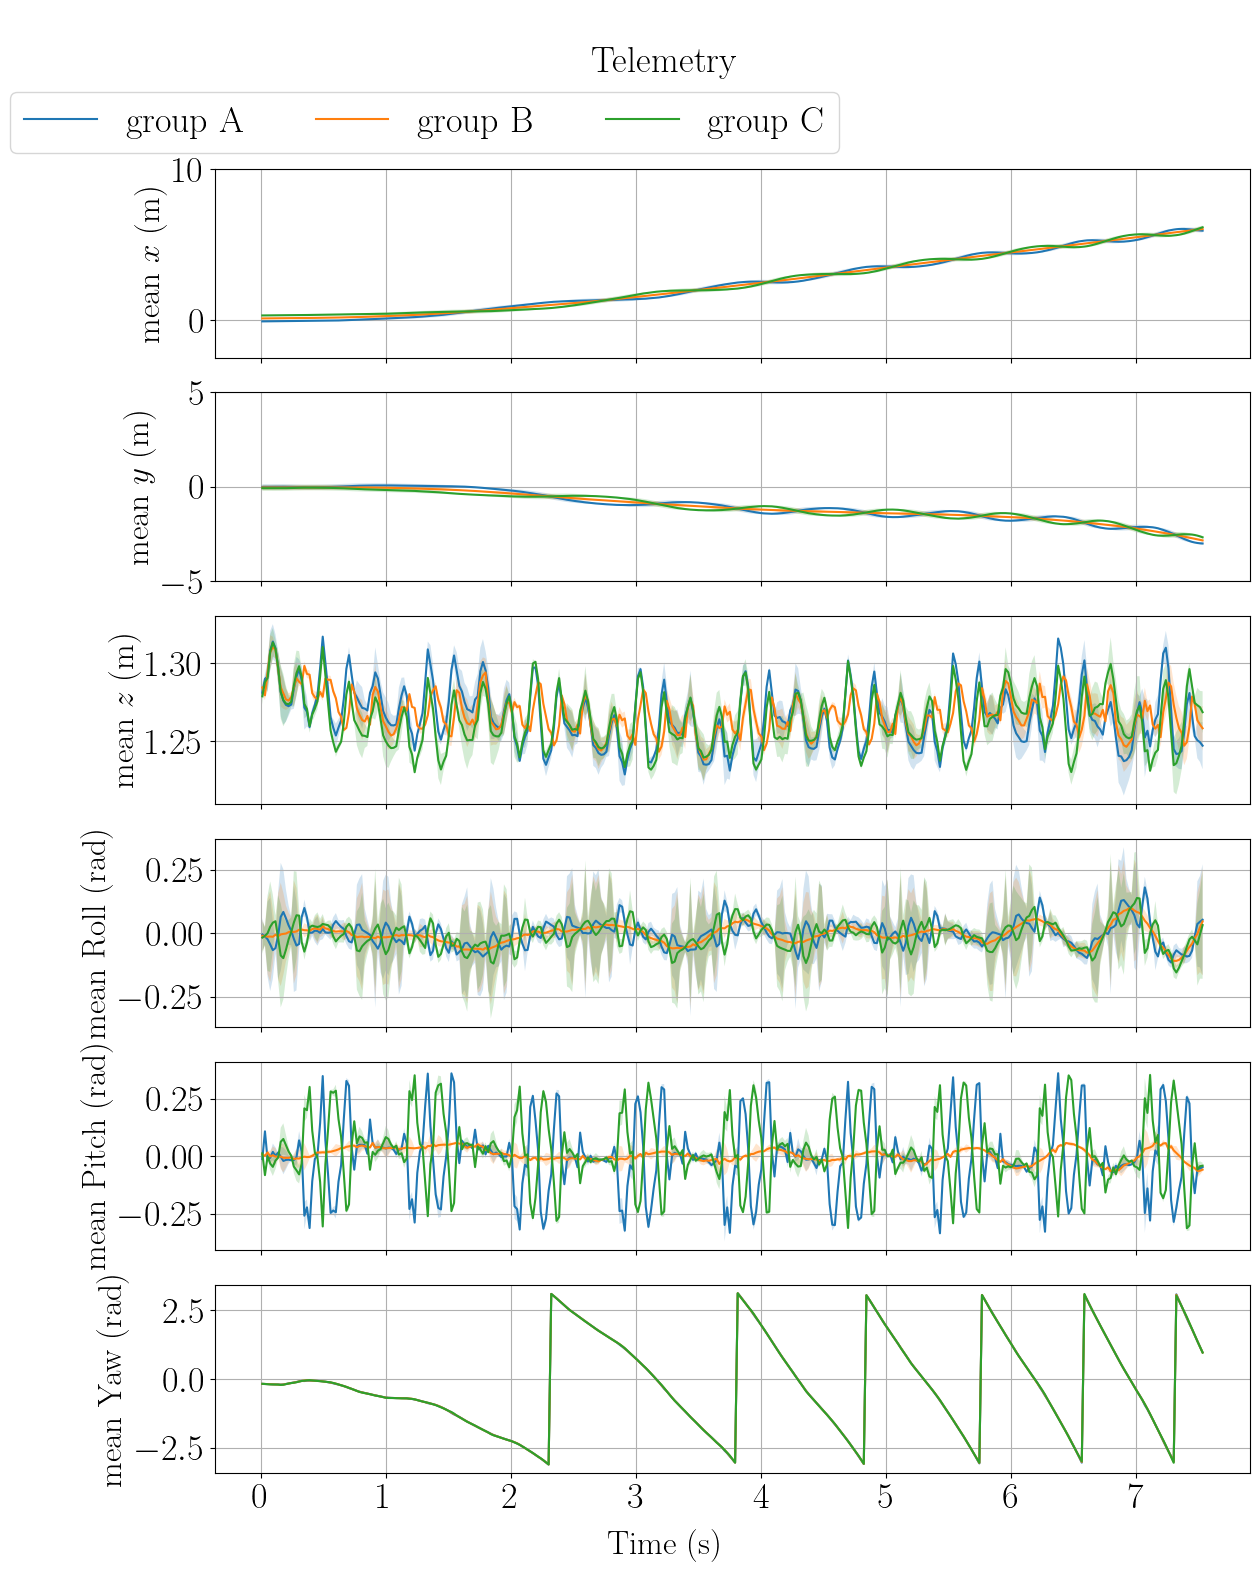

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from io import StringIO
import math

csv_string = data_to_plot

# ==============================
# Adjustable parameters
# ==============================
time_threshold = 25.5
fig_width = 12
fig_height = 16

USE_LATEX = True  # set True only if you installed TeX

TITLE_SIZE = 26
LABEL_SIZE = 24
TICK_SIZE  = 26
LEGEND_SIZE = 26

Y_RANGES = {
    "mean_x": (-2.5, 10.0),
    "mean_y": (-5.0, 5.0),
}

Y_LABELS = {
    "mean_x": r"mean $x \;(\mathrm{m})$",
    "mean_y": r"mean $y\;(\mathrm{m})$",
    "mean_z": r"mean $z\;(\mathrm{m})$",
    "mean_roll": r"mean $\mathrm{Roll}\;(\mathrm{rad})$",
    "mean_pitch": r"mean ${\mathrm{Pitch}}\;(\mathrm{rad})$",
    "mean_yaw": r"mean ${\mathrm{Yaw}}\;(\mathrm{rad})$",
}

# Optional: one global title at the top (set to None to disable)
FIG_TITLE = "\nTelemetry"  # e.g. r"$\mathrm{My\ Plot\ Title}$"

# ==============================
# Style (MUST be before plt.subplots)
# ==============================
mpl.rcParams.update({
    "text.usetex": USE_LATEX,
    "font.family": "serif" if USE_LATEX else "sans-serif",

    "axes.labelsize": LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
})

def tex_escape(s: str) -> str:
    return s.replace("_", r"\_")

# ==============================
# Load CSV
# ==============================
df = pd.read_csv(StringIO(csv_string))
df["timestamp"] = pd.to_numeric(df["timestamp"])
df["group_x"] = pd.to_numeric(df["group_x"])

groups = [-2, 0, 2]
df = df[df["group_x"].isin(groups)]
df = df[df["timestamp"] > time_threshold]
df["timestamp"] -= time_threshold
df = df.sort_values(["group_x", "timestamp"])

metrics = ["mean_x", "mean_y", "mean_z", "mean_roll", "mean_pitch", "mean_yaw"]

# ==============================
# Create subplot grid (shared x-axis)
# ==============================
n_metrics = len(metrics)
n_cols = 1
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(fig_width, fig_height),
    sharex=True  # ✅ one common time axis
)
axes = axes.flatten()

# ==============================
# Plot + collect legend ONCE
# ==============================
handles, labels = [], []

for i, metric in enumerate(metrics):
    ax = axes[i]

    for g in groups:
        group_df = df[df["group_x"] == g]
        if group_df.empty:
            continue

        t = group_df["timestamp"].to_numpy()
        values = group_df[metric].to_numpy()

        variance_metric = metric.replace("mean", "var")
        if variance_metric in group_df.columns:
            var = group_df[variance_metric].to_numpy()
            std = var ** 0.5
            ax.fill_between(t, values - std, values + std, alpha=0.2)

        # line, = ax.plot(t, values, label=f"group {g}")
        if g == -2:
            line, = ax.plot(t, values, label=f"group A")
        elif g == 0:
            line, = ax.plot(t, values, label=f"group B")
        elif g == 2:
            line, = ax.plot(t, values, label=f"group C")

        # only collect legend entries from first subplot
        if i == 0:
            handles.append(line)
            if g == -2:
                labels.append(f"group A")
            elif g == 0:
                labels.append(f"group B")
            elif g == 2:
                labels.append(f"group C")

    # y-label (acts like the subplot “title”)
    # safe_metric = tex_escape(metric) if USE_LATEX else metric
    # ax.set_ylabel(rf"$\mathrm{{{safe_metric}}}$" if USE_LATEX else metric, fontsize=LABEL_SIZE)
    if metric in Y_LABELS:
        ax.set_ylabel(Y_LABELS[metric], fontsize=LABEL_SIZE)
    else:
        ax.set_ylabel(metric, fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True)

    if metric in Y_RANGES:
        ax.set_ylim(*Y_RANGES[metric])

# Hide unused subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ✅ One x-axis label for the whole figure
fig.supxlabel(r"$\mathrm{Time\ (s)}$" if USE_LATEX else "Time (s)", fontsize=LABEL_SIZE)

# ✅ Optional one title at the top
if FIG_TITLE is not None:
    fig.suptitle(FIG_TITLE, fontsize=TITLE_SIZE)

# ✅ One legend for all plots
# fig.legend(
#     handles, labels,
#     loc="upper center",
#     ncol=len(groups),
#     fontsize=LEGEND_SIZE
# )
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.4, 0.94),
    ncol=len(groups),
    fontsize=LEGEND_SIZE
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
# Leave room at top for legend (and maybe title)
top_space = 0.98 if FIG_TITLE is None else 0.95
plt.tight_layout(rect=[0, 0, 1, top_space])

plt.show()